# Monash Solar Farm — Data Loading

**Purpose of this notebook: load every data file in the project into a named
variable, and nothing else.** No analysis, no modelling. By the end you have all
the raw material in memory and know what each variable holds.

## What the project is

Monash's Clayton campus has a microgrid: six buildings that consume electricity,
six rooftop solar installations that generate it, and batteries that store it.
The project has two parts.

| | Part 1 — Predict | Part 2 — Optimise |
|---|---|---|
| **Task** | Forecast electricity demand for 6 buildings and solar production from 6 arrays | Schedule battery charge/discharge and lecture activities |
| **Resolution** | Every 15 minutes | Every 15 minutes |
| **Target period** | October 2020 (Phase 1) or November 2020 (Phase 2) | Same months |
| **Scored by** | Mean MASE across all 12 series | Cost: peak-demand tariff + activity values |

Part 2 consumes the forecasts from Part 1 — you decide when to charge the battery
(when solar is plentiful or prices are low) and when to discharge it (when demand
peaks or prices are high).

## The files

| File | What it is |
|---|---|
| `phase_1_data.tsf` | The 12 series, history up to **30 Sep 2020**. Training data for predicting October. |
| `phase_2_data.tsf` | The same 12 series, up to **31 Oct 2020**. Training data for predicting November. |
| `nov_data.tsf` | The same 12 series, up to **30 Nov 2020**. Contains the **answers** for both October and November. |
| `ERA5_Weather_Data_Monash.csv` | Hourly weather near campus, 2010–2021. Supplied by the unit because the Bureau of Meteorology only lets you download daily data. |
| `phase_1_instances/`, `phase_2_instances_utc.zip` | Part 2 optimisation problems — buildings, batteries and activities to schedule. |

The three `.tsf` files are **nested snapshots of the same 12 series**, not different
data. `nov_data.tsf` contains everything the other two contain, plus more months.

## 1. Imports and file paths

In [1]:
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 50)

# This notebook lives in the project root; the data sits in MonashSolarFarm/.
DATA = Path.cwd() / "MonashSolarFarm"
if not DATA.exists():
    DATA = Path.cwd()          # in case the notebook is moved next to the data
assert (DATA / "nov_data.tsf").exists(), f"could not find the data under {DATA}"

# Timestamps inside the data files are UTC. Melbourne is UTC+10 in winter and
# UTC+11 during daylight saving, which is in force across October and November -
# exactly the period we forecast. Converting to this timezone makes pandas handle
# the changeover for us.
LOCAL_TZ = "Australia/Melbourne"

print("data folder:", DATA)
for f in sorted(DATA.iterdir()):
    if f.suffix in {".tsf", ".csv", ".zip"} or f.is_dir():
        size = f.stat().st_size / 1e6
        print(f"  {f.name:36s} {size:8.2f} MB")

data folder: /Users/pahansenevirathne/Documents/data challenges 4/MonashSolarFarm
  ERA5_Weather_Data_Monash.csv            10.28 MB
  ERA5_Weather_Data_Monash.zip             2.26 MB
  IDCJAC0010_86338_1800.zip                0.02 MB
  Predict_eval_and_data_R_scripts          0.00 MB
  final_test_data.zip                      0.52 MB
  nov_data.tsf                             3.09 MB
  phase_1_data.tsf                         2.82 MB
  phase_1_data.zip                         0.46 MB
  phase_1_instances                        0.00 MB
  phase_1_instances.zip                    0.02 MB
  phase_2_data.tsf                         2.95 MB
  phase_2_data.zip                         0.49 MB
  phase_2_instances_utc.zip                0.02 MB


## 2. The `.tsf` files (building demand and solar production)

`.tsf` is a plain-text time-series format. It looks like this:

```
# comment lines
@relation energy_demand
@frequency 15_minutes
@missing true
@equallength false
@data
Building0:2016-07-03 21-30-00:283.8,283.8,283.8,606,606,?,306,...
Solar0:2020-04-25 14-00-00:0,0,0,0.12,...
```

After `@data`, each line is one complete time series in the form
**`Name : start_timestamp : comma-separated values`**.

Three consequences worth understanding before writing the parser:

- `@equallength false` — every series has a **different length**.
- Each series carries its **own start timestamp**, so they do not begin on the
  same date. There is no date column; you reconstruct dates by counting 15-minute
  steps forward from that start.
- `@missing true` — a `?` means a missing reading, which becomes `NaN`.

In [2]:
def load_tsf(path):
    """
    Read a .tsf file.

    Returns a dict of {series_name: pandas Series}, each with a proper
    15-minute UTC DatetimeIndex reconstructed from its own start timestamp.
    """
    series = {}
    with open(path) as fh:
        for line in fh:
            line = line.rstrip("\n")

            # Skip comments, blank lines, and the @tag header lines.
            if not line or line.startswith("#") or line.startswith("@"):
                continue

            # Everything after @data has the shape  name:timestamp:v1,v2,v3,...
            name, timestamp, values = line.split(":", 2)

            # "2016-07-03 21-30-00"  ->  a real timestamp, tagged as UTC
            start = pd.Timestamp(datetime.strptime(timestamp, "%Y-%m-%d %H-%M-%S"), tz="UTC")

            # "?" marks a missing reading
            numbers = [np.nan if v == "?" else float(v) for v in values.split(",")]

            # Build the dates by stepping forward 15 minutes at a time
            index = pd.date_range(start=start, periods=len(numbers), freq="15min", tz="UTC")

            series[name] = pd.Series(numbers, index=index, name=name)
    return series


# Load all three snapshots.
tsf_files = {
    "phase1": DATA / "phase_1_data.tsf",   # history to 30 Sep 2020
    "phase2": DATA / "phase_2_data.tsf",   # history to 31 Oct 2020
    "nov":    DATA / "nov_data.tsf",       # history to 30 Nov 2020 (the answers)
}
tsf = {label: load_tsf(path) for label, path in tsf_files.items()}

for label, series in tsf.items():
    ends = max(s.index[-1] for s in series.values())
    print(f"{label:7s} {len(series)} series, ending {ends.tz_convert(LOCAL_TZ):%Y-%m-%d %H:%M} local")

phase1  12 series, ending 2020-10-01 09:45 local
phase2  12 series, ending 2020-11-01 10:45 local
nov     12 series, ending 2020-12-01 10:45 local


In [3]:
# Turn the fullest snapshot into one wide table: rows = 15-minute stamps,
# columns = the 12 series. pandas aligns them on the union of their timestamps,
# filling NaN where a series had not started yet.
df = pd.DataFrame(tsf["nov"]).asfreq("15min").tz_convert(LOCAL_TZ)

# Two convenient groupings. Note there is NO Building2 - the numbering skips it,
# in the data and in the Part 2 optimisation instances alike.
BUILDINGS = [c for c in df.columns if c.startswith("Building")]
SOLAR = [c for c in df.columns if c.startswith("Solar")]

print("buildings:", BUILDINGS)
print("solar    :", SOLAR)
print(f"\nshape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"span : {df.index[0]:%Y-%m-%d %H:%M} -> {df.index[-1]:%Y-%m-%d %H:%M} (local time)")
df.head()

buildings: ['Building0', 'Building1', 'Building3', 'Building4', 'Building5', 'Building6']
solar    : ['Solar0', 'Solar1', 'Solar2', 'Solar3', 'Solar4', 'Solar5']

shape: 166,639 rows x 12 columns
span : 2016-03-01 15:15 -> 2020-12-01 10:45 (local time)


,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 15:15:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 15:30:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 15:45:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 16:00:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 16:15:00+11:00,NaN,NaN,1293.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# What each series actually contains. Read this before doing anything else -
# the series are far less uniform than "12 series at 15 minutes" suggests.
summary = pd.DataFrame({
    "start (local)": [tsf["nov"][c].index[0].tz_convert(LOCAL_TZ).strftime("%Y-%m-%d") for c in df.columns],
    "n readings":    [len(tsf["nov"][c]) for c in df.columns],
    "missing %":     [round(100 * tsf["nov"][c].isna().mean(), 1) for c in df.columns],
    "min":           [round(tsf["nov"][c].min(), 2) for c in df.columns],
    "max":           [round(tsf["nov"][c].max(), 2) for c in df.columns],
    "mean":          [round(tsf["nov"][c].mean(), 2) for c in df.columns],
}, index=df.columns)
summary.index.name = "series"
summary

,start (local),n readings,missing %,min,max,mean
series,,,,,,
Building0,2016-07-04,154666,30.7,0.1,6781.50,224.57
Building1,2019-01-10,66339,0.1,1.5,83.50,11.22
Building3,2016-03-01,166639,0.3,85.0,8556.00,512.83
Building4,2019-07-03,49613,40.3,1.0,5.00,1.32
Building5,2019-07-26,47428,73.3,1.0,62.00,24.64
Building6,2019-07-25,47513,4.8,0.2,102.20,30.67
Solar0,2020-04-26,21064,0.0,0.0,53.27,6.25
Solar1,2019-01-01,67244,0.0,0.0,13.04,2.02
Solar2,2019-06-06,52264,0.0,0.0,13.96,1.99


A few things to notice in that table, because they shape everything later:

- **History lengths differ wildly.** Building3 starts in March 2016; Solar0 starts
  in April 2020, giving it only about five months of history before the forecast
  window.
- **Scale differs by three orders of magnitude.** Building4 never leaves the
  1–5 kW range while Building3 reaches 8,556 kW. Never plot them on shared axes.
- **Missingness is severe for two series** — Building4 around 40% and Building5
  around 73%.
- **Nothing is ever negative.** Buildings cannot consume negative power and panels
  cannot generate it, so your forecasts should not go negative either.

### Marking the forecast windows — and a daylight-saving trap

`df` now holds October and November 2020, the periods you are supposed to be
predicting. Splitting them off explicitly makes it hard to train on the answers
by accident.

**Define the boundaries in UTC, not local time.** The forecast horizons are fixed
step counts — Phase 1 is 2,976 fifteen-minute steps (31 × 96), Phase 2 is 2,880
(30 × 96) — counted forward from where each training file ends, and the files are
stamped in UTC.

Melbourne moved to daylight saving on **4 October 2020**, so the *local* calendar
month of October contains only 23 hours on that day and therefore **2,972** steps,
not 2,976. Slicing by local calendar month silently gives you four rows too few
and a submission that fails validation. Slicing on UTC instants gives the right
count. Because the index is timezone-aware, comparing it against UTC timestamps
works directly — pandas compares absolute instants regardless of display timezone.

In [5]:
# UTC boundaries - see the note above on why these must not be local-time months.
OCT = (pd.Timestamp("2020-10-01", tz="UTC"), pd.Timestamp("2020-11-01", tz="UTC"))
NOV = (pd.Timestamp("2020-11-01", tz="UTC"), pd.Timestamp("2020-12-01", tz="UTC"))

train = df.loc[df.index < OCT[0]]                               # everything to 30 Sep
test_oct = df.loc[(df.index >= OCT[0]) & (df.index < OCT[1])]    # Phase 1 answers
test_nov = df.loc[(df.index >= NOV[0]) & (df.index < NOV[1])]    # Phase 2 answers

for label, part in [("train", train), ("test_oct", test_oct), ("test_nov", test_nov)]:
    last_utc = part.index[-1].tz_convert("UTC")
    print(f"{label:8s} {len(part):>7,} rows   ends {part.index[-1]:%Y-%m-%d %H:%M} local "
          f"= {last_utc:%Y-%m-%d %H:%M} UTC")

# train ends 2020-10-01 09:45 in Melbourne time, which is still 2020-09-30 23:45
# UTC - the last step before the Phase 1 window opens. No October data leaks in.
print(f"\ntest_oct expected 2,976 = 31 x 96   -> {'OK' if len(test_oct) == 2976 else 'MISMATCH'}")
print(f"test_nov expected 2,880 = 30 x 96   -> {'OK' if len(test_nov) == 2880 else 'MISMATCH'}")

# The trap, demonstrated: the same month sliced by local calendar date.
local_oct = df.loc["2020-10"]
print(f"\nSliced as a local calendar month instead: {len(local_oct):,} rows "
      f"({2976 - len(local_oct)} short, because 4 Oct 2020 lost an hour to DST)")

train    160,783 rows   ends 2020-10-01 09:45 local = 2020-09-30 23:45 UTC
test_oct   2,976 rows   ends 2020-11-01 10:45 local = 2020-10-31 23:45 UTC
test_nov   2,880 rows   ends 2020-12-01 10:45 local = 2020-11-30 23:45 UTC

test_oct expected 2,976 = 31 x 96   -> OK
test_nov expected 2,880 = 30 x 96   -> OK

Sliced as a local calendar month instead: 2,972 rows (4 short, because 4 Oct 2020 lost an hour to DST)


## 3. ERA5 weather

Hourly reanalysis weather for a single point (-37.91, 145.13) beside the Clayton
campus, covering 2010 to mid-2021 — so both forecast months are covered.

"Reanalysis" means this is the weather that **actually happened**, reconstructed
after the fact, not a forecast made in advance. It is a legitimate input for this
project, but be aware it hands your model perfect knowledge of future weather,
which a real operational forecaster would never have.

The most useful column is `surface_solar_radiation` — it is close to a direct
physical driver of solar panel output.

In [6]:
era5 = pd.read_csv(DATA / "ERA5_Weather_Data_Monash.csv")
print("columns as they appear in the file:")
for c in era5.columns:
    print("   ", c)

# The timestamp column is UTC; convert to Melbourne local time so it lines up
# with df above.
era5["datetime (UTC)"] = pd.to_datetime(era5["datetime (UTC)"], utc=True)
era5 = era5.set_index("datetime (UTC)").sort_index().tz_convert(LOCAL_TZ)
era5.index.name = "timestamp"

# Several columns are the same value on every row (the location, the model name).
# They carry no information, so drop them.
constant_cols = [c for c in era5.columns if era5[c].nunique(dropna=False) <= 1]
print("\ndropping constant columns:", constant_cols)
era5 = era5.drop(columns=constant_cols)

# Shorten "temperature (degC)" to "temperature" etc.
era5.columns = [c.split(" (")[0] for c in era5.columns]

print(f"\nshape: {era5.shape[0]:,} rows x {era5.shape[1]} columns")
print(f"span : {era5.index[0]:%Y-%m-%d} -> {era5.index[-1]:%Y-%m-%d}")
print("missing values:", int(era5.isna().sum().sum()))
era5.head()

columns as they appear in the file:
    datetime (UTC)
    coordinates (lat,lon)
    model (name)
    model elevation (surface)
    utc_offset (hrs)
    temperature (degC)
    dewpoint_temperature (degC)
    wind_speed (m/s)
    mean_sea_level_pressure (Pa)
    relative_humidity ((0-1))
    surface_solar_radiation (W/m^2)
    surface_thermal_radiation (W/m^2)
    total_cloud_cover (0-1)

dropping constant columns: ['coordinates (lat,lon)', 'model (name)', 'model elevation (surface)', 'utc_offset (hrs)']

shape: 100,057 rows x 8 columns
span : 2010-01-01 -> 2021-06-01
missing values: 0


,temperature,dewpoint_temperature,wind_speed,mean_sea_level_pressure,relative_humidity,surface_solar_radiation,surface_thermal_radiation,total_cloud_cover
timestamp,,,,,,,,
2010-01-01 11:00:00+11:00,18.26,16.39,2.60,101046.38,0.89,287.01,408.35,1.0
2010-01-01 12:00:00+11:00,18.67,16.29,2.91,101037.96,0.86,360.79,411.02,1.0
2010-01-01 13:00:00+11:00,18.16,15.89,3.26,101017.26,0.87,291.54,410.67,1.0
2010-01-01 14:00:00+11:00,18.46,15.33,3.17,101022.56,0.82,357.11,410.95,1.0
2010-01-01 15:00:00+11:00,18.53,15.11,2.95,100940.03,0.80,459.91,410.00,0.9


In [7]:
era5.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature,100057.0,14.80,5.58,0.86,10.83,13.92,18.00,40.36
dewpoint_temperature,100057.0,9.50,3.60,-2.32,6.86,9.09,11.86,22.94
wind_speed,100057.0,3.91,2.05,0.02,2.30,3.67,5.28,13.23
mean_sea_level_pressure,100057.0,101613.13,925.85,96725.92,101169.94,101703.71,102201.65,103397.53
relative_humidity,100057.0,0.73,0.16,0.12,0.62,0.76,0.85,1.09
surface_solar_radiation,100057.0,182.92,265.32,0.00,0.00,7.22,316.23,1112.14
surface_thermal_radiation,100057.0,324.62,32.93,232.15,300.51,322.90,347.15,458.76
total_cloud_cover,100057.0,0.59,0.36,0.00,0.27,0.65,0.94,1.00


### Relationships between the raw weather variables

Before using these as model inputs it is worth seeing how they relate to each
other. Three views, each answering something the others cannot:

- **A clustermap**, which reorders the variables so that mutually-correlated ones
  sit together. This is the one that answers "which of these are saying the same
  thing?" — the practical question for feature selection.
- **A pair grid**, showing each joint distribution as a density rather than a
  single coefficient. A correlation of 0.0 can hide a strong curved relationship,
  and only the scatter reveals it.
- **Focused fits** against `surface_solar_radiation`, the variable that actually
  drives solar output.

All three use **daylight hours only**. At night radiation is pinned at zero, which
would put a large spike at the origin of every panel and distort every correlation
involving it.

weather variables: ['temperature', 'dewpoint_temperature', 'wind_speed', 'mean_sea_level_pressure', 'relative_humidity', 'surface_solar_radiation', 'surface_thermal_radiation', 'total_cloud_cover']
47,755 daylight hours; plotting a 4,000-row sample


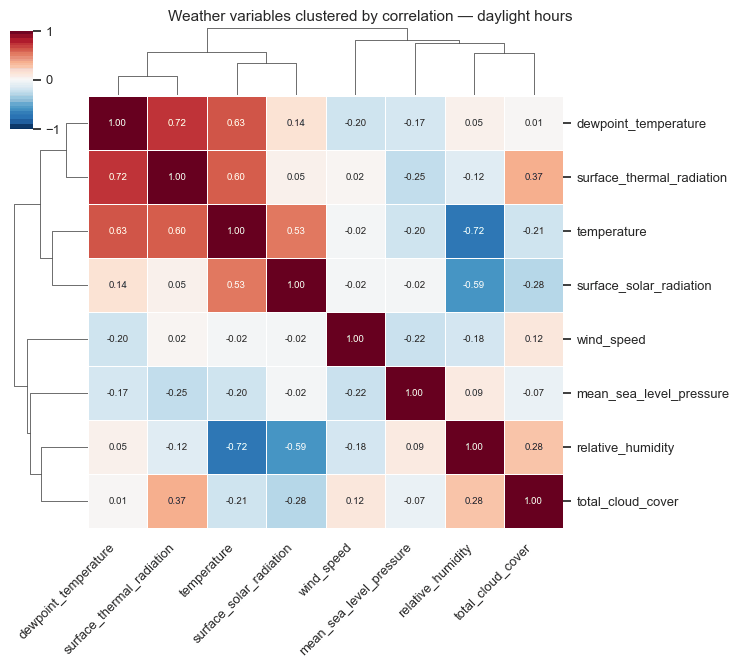

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# The 8 weather variables left after the constant columns were dropped above.
WEATHER = list(era5.columns)
print("weather variables:", WEATHER)

sns.set_theme(style="white", font_scale=0.85)

# Daylight only, and a sample for plotting - 100k points would be an unreadable
# smear and slow to render.
day_weather = era5.loc[era5["surface_solar_radiation"] > 20, WEATHER]
sample = day_weather.sample(n=min(4000, len(day_weather)), random_state=0)
print(f"{len(day_weather):,} daylight hours; plotting a {len(sample):,}-row sample")

corr = day_weather.corr()
g = sns.clustermap(
    corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, linecolor="white",
    figsize=(7.5, 7), cbar_pos=(0.02, 0.83, 0.03, 0.14),
    dendrogram_ratio=0.14)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.figure.suptitle("Weather variables clustered by correlation — daylight hours",
                  x=0.5, y=1.0, fontsize=11)
plt.show()

The dendrogram is the useful part. Branches that join close to the left are near-
duplicates, and keeping both gives a linear model unstable coefficients while
giving a tree nothing extra. The pairs to look for are **temperature with
dewpoint** and **radiation with cloud cover** — physically linked, and flagged in
the literature review as the classic redundancy in this feature set.

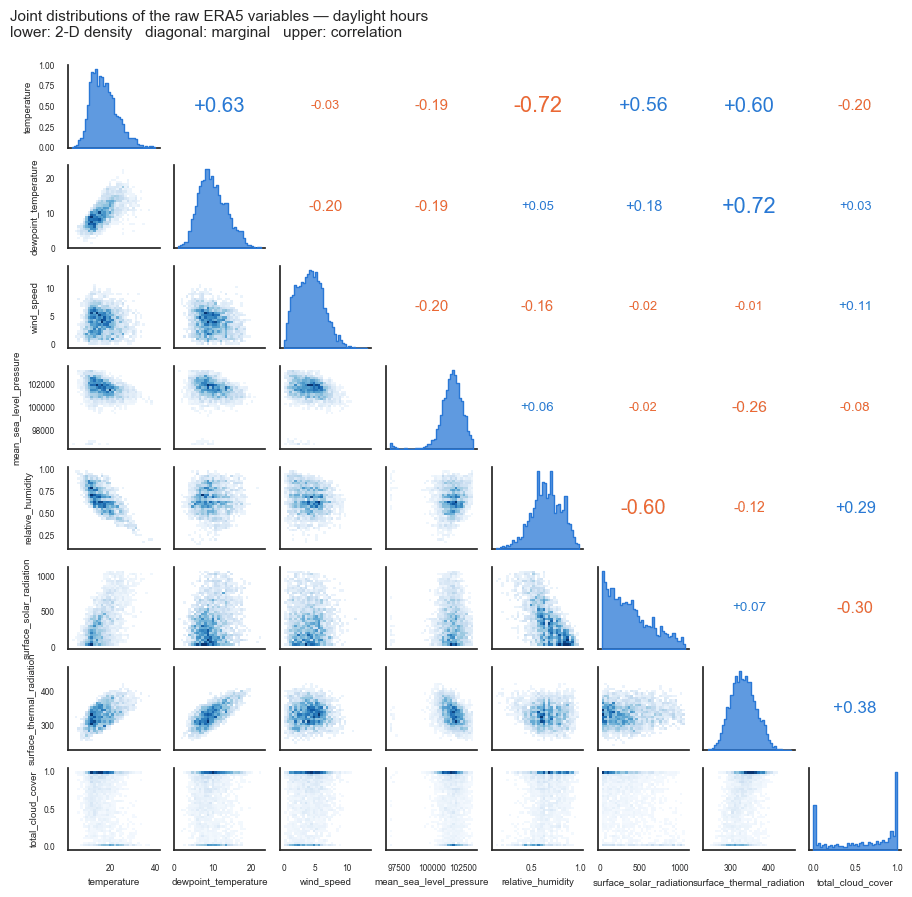

In [9]:
def corr_label(x, y, **kws):
    """Annotate the upper triangle with the correlation coefficient."""
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"{r:+.2f}", xy=(0.5, 0.5), xycoords="axes fraction",
                ha="center", va="center",
                fontsize=9 + abs(r) * 9,
                color="#2a78d6" if r > 0 else "#eb6834")
    ax.set_axis_off()


grid = sns.PairGrid(sample, diag_sharey=False, height=1.15, corner=False)
grid.map_lower(sns.histplot, bins=32, cmap="Blues", cbar=False, pthresh=0.02)
grid.map_diag(sns.histplot, color="#2a78d6", bins=40, element="step", fill=True)
grid.map_upper(corr_label)
for ax in grid.axes.flatten():
    ax.tick_params(labelsize=6)
    ax.set_xlabel(ax.get_xlabel(), fontsize=7)
    ax.set_ylabel(ax.get_ylabel(), fontsize=7)
grid.figure.suptitle(
    "Joint distributions of the raw ERA5 variables — daylight hours\n"
    "lower: 2-D density   diagonal: marginal   upper: correlation",
    x=0.01, ha="left", fontsize=11)
grid.figure.subplots_adjust(top=0.92)
plt.show()

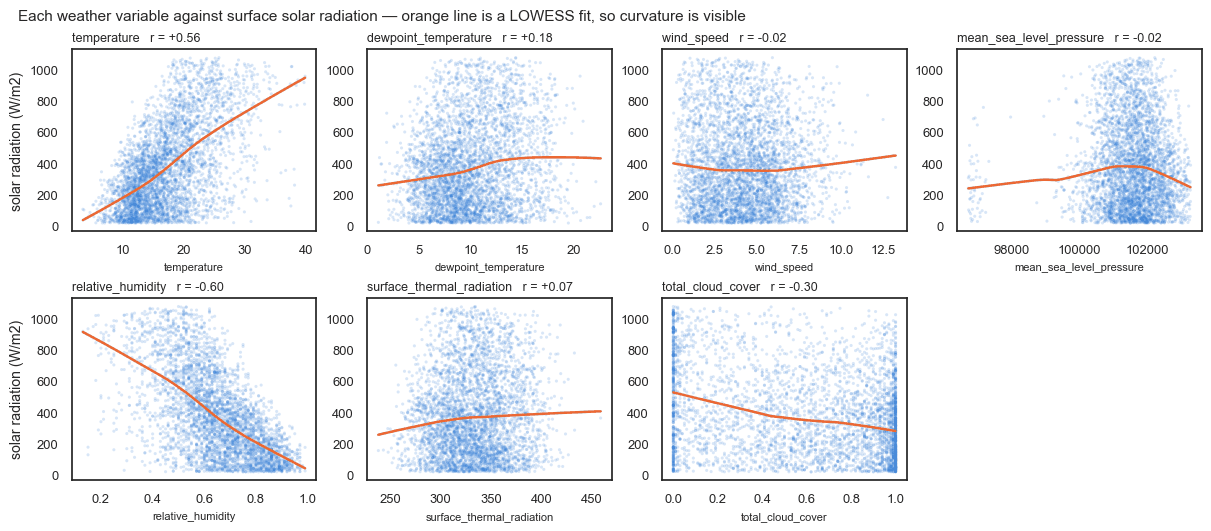

In [10]:
# What actually relates to the driver of solar output?
others = [c for c in WEATHER if c != "surface_solar_radiation"]
fig, axes = plt.subplots(2, 4, figsize=(12, 5.2), constrained_layout=True)

for ax, col in zip(axes.ravel(), others):
    sns.regplot(data=sample, x=col, y="surface_solar_radiation", ax=ax,
                scatter_kws={"s": 5, "alpha": 0.18, "color": "#2a78d6",
                             "edgecolors": "none"},
                line_kws={"color": "#eb6834", "lw": 1.8},
                lowess=True)
    r = sample[col].corr(sample["surface_solar_radiation"])
    ax.set_title(f"{col}   r = {r:+.2f}", loc="left", fontsize=9)
    ax.set_ylabel("solar radiation (W/m2)" if ax in axes[:, 0] else "")
    ax.set_xlabel(col, fontsize=8)

axes.ravel()[-1].set_visible(len(others) == 8)
fig.suptitle("Each weather variable against surface solar radiation — "
             "orange line is a LOWESS fit, so curvature is visible",
             x=0.01, ha="left", fontsize=11)
plt.show()

sns.set_theme(style="white")   # leave the theme in a known state for later cells
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "legend.frameon": False,
})

**What to take from these.**

The LOWESS fits are the point of the last panel: a near-zero correlation
coefficient does not mean "no relationship", it means "no *linear* relationship".
Where the orange line curves, a linear model cannot use that variable but a tree
or a network can — which is part of why Ridge scored 0.99 MASE in section 12 while
the forest reached 0.72.

For feature selection, the clustermap and the permutation importance in section
11a agree: `dewpoint_temperature` sits in the same branch as `temperature`, and
`wind_speed` and `mean_sea_level_pressure` are near-independent of radiation and
scored at or below zero importance. Those are the drop candidates.

## 4. Part 2 optimisation instances

These describe the scheduling problems. Each file is a small text spec where the
first letter of a line says what the line is:

| Line | Meaning |
|---|---|
| `ppoi 6 6 2 50 20` | Header: 6 buildings, 6 solar arrays, 2 batteries, 50 recurring activities, 20 once-off activities |
| `b 0 1 0` | Building 0 has 1 small room and 0 large rooms |
| `s 2 3` | Solar array 2 is attached to Building 3 |
| `c 0 1 150 75 0.85` | Battery 0 sits at Building 1: 150 kWh capacity, 75 kW max power, 85% round-trip efficiency |
| `r 0 3 S 170 5 0` | Recurring activity 0 needs 3 small rooms, draws 170 kW, lasts 5 steps (75 min), has 0 prerequisites |
| `a 0 1 L 289 9 38 24 1 14` | Once-off activity 0 needs 1 large room, 289 kW, 9 steps, worth \$38, \$24 penalty if scheduled out of hours, 1 prerequisite (activity 14) |

Recurring activities are lectures: they **must** be scheduled, on weekdays between
09:00 and 17:00. Once-off activities are optional — you earn their value by
scheduling them, and lose part of it if you place them outside office hours.

In [11]:
def load_instance(text):
    """Parse one optimisation instance file into a dict of DataFrames."""
    head, buildings, solar, batteries, recurring, once_off = None, [], [], [], [], []

    for line in text.splitlines():
        parts = line.split()
        if not parts:
            continue
        kind, rest = parts[0], parts[1:]

        if kind == "ppoi":
            head = dict(zip(["n_buildings", "n_solar", "n_batteries",
                             "n_recurring", "n_once_off"], map(int, rest)))
        elif kind == "b":
            buildings.append(dict(zip(["building", "small_rooms", "large_rooms"], map(int, rest))))
        elif kind == "s":
            solar.append(dict(zip(["solar", "building"], map(int, rest))))
        elif kind == "c":
            batteries.append({"battery": int(rest[0]), "building": int(rest[1]),
                              "capacity_kwh": float(rest[2]), "max_power_kw": float(rest[3]),
                              "efficiency": float(rest[4])})
        elif kind in ("r", "a"):
            # Both activity types start the same way; once-off adds value + penalty.
            act = {"activity": int(rest[0]), "n_rooms": int(rest[1]), "room_size": rest[2],
                   "load_kw": float(rest[3]), "duration_steps": int(rest[4])}
            tail = rest[5:]
            if kind == "a":
                act["value"], act["penalty"] = float(tail[0]), float(tail[1])
                tail = tail[2:]
            # Remaining fields: a count of prerequisites, then that many activity ids.
            act["precedences"] = [int(x) for x in tail[1:1 + int(tail[0])]]
            (recurring if kind == "r" else once_off).append(act)

    return {"header": head,
            "buildings": pd.DataFrame(buildings),
            "solar": pd.DataFrame(solar),
            "batteries": pd.DataFrame(batteries),
            "recurring": pd.DataFrame(recurring),
            "once_off": pd.DataFrame(once_off)}


instances = {}

# Phase 1 instances are already extracted into a folder.
for path in sorted((DATA / "phase_1_instances").glob("*.txt")):
    instances[path.stem] = load_instance(path.read_text())

# Phase 2 instances are still zipped - read them without extracting.
with zipfile.ZipFile(DATA / "phase_2_instances_utc.zip") as zf:
    for name in sorted(n for n in zf.namelist() if n.endswith(".txt")):
        instances[Path(name).stem] = load_instance(zf.read(name).decode())

print(f"loaded {len(instances)} instances\n")
pd.DataFrame({k: v["header"] for k, v in instances.items()}).T

loaded 20 instances



,n_buildings,n_solar,n_batteries,n_recurring,n_once_off
phase1_instance_large_0,6,6,2,200,100
phase1_instance_large_1,6,6,2,200,100
phase1_instance_large_2,6,6,2,200,100
phase1_instance_large_3,6,6,2,200,100
phase1_instance_large_4,6,6,2,200,100
phase1_instance_small_0,6,6,2,50,20
phase1_instance_small_1,6,6,2,50,20
phase1_instance_small_2,6,6,2,50,20
phase1_instance_small_3,6,6,2,50,20
phase1_instance_small_4,6,6,2,50,20


In [12]:
# Look at one instance to see the structure.
inst = instances["phase1_instance_small_0"]

print("BATTERIES")
print(inst["batteries"].to_string(index=False))
print("\nSOLAR -> BUILDING mapping")
print(inst["solar"].to_string(index=False))
print("\nRECURRING activities (first 5 of "
      f"{len(inst['recurring'])}) - these MUST all be scheduled")
print(inst["recurring"].head().to_string(index=False))
print("\nONCE-OFF activities (first 5 of "
      f"{len(inst['once_off'])}) - optional, worth money")
print(inst["once_off"].head().to_string(index=False))

BATTERIES
 battery  building  capacity_kwh  max_power_kw  efficiency
       0         1         150.0          75.0        0.85
       1         3         420.0          60.0        0.60

SOLAR -> BUILDING mapping
 solar  building
     0         0
     1         1
     2         3
     3         4
     4         5
     5         6

RECURRING activities (first 5 of 50) - these MUST all be scheduled
 activity  n_rooms room_size  load_kw  duration_steps                                       precedences
        0        3         S    253.0               7                    [2, 9, 22, 24, 27, 32, 43, 45]
        1        2         S    364.0               6                                                []
        2        2         S    242.0               4                                  [24, 35, 42, 45]
        3        1         S    261.0               5 [0, 2, 4, 19, 21, 29, 30, 35, 42, 43, 44, 47, 48]
        4        2         S    378.0               4                          

## 5. Sanity check

One plot, purely to confirm the data loaded correctly and the timezone is right.
If solar production peaks around the middle of the day, the timestamps are being
interpreted properly. If it peaked at 2am, the timezone handling would be wrong.

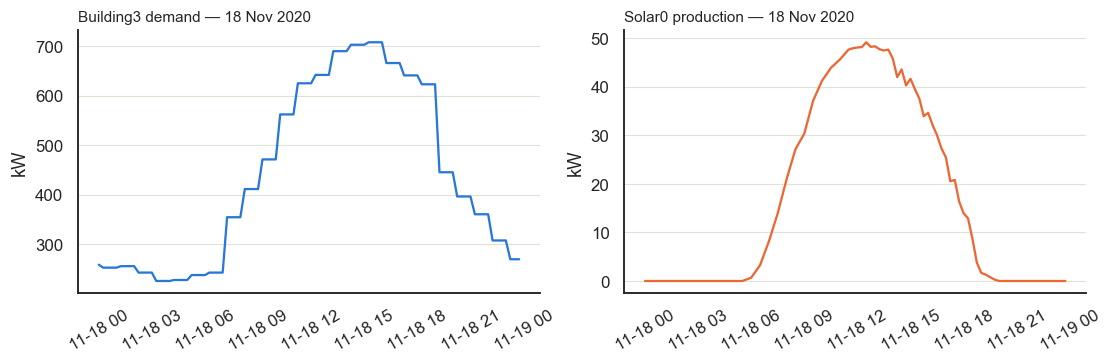

Average solar output peaks at 12:00 local time (looks correct)


In [13]:
import matplotlib.pyplot as plt

day = df.loc["2020-11-18"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)

axes[0].plot(day.index, day["Building3"], color="#2a78d6")
axes[0].set_title("Building3 demand — 18 Nov 2020", loc="left")
axes[0].set_ylabel("kW")

axes[1].plot(day.index, day["Solar0"], color="#eb6834")
axes[1].set_title("Solar0 production — 18 Nov 2020", loc="left")
axes[1].set_ylabel("kW")

for ax in axes:
    ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="x", rotation=30)
plt.show()

peak_hour = df["Solar0"].groupby(df.index.hour).mean().idxmax()
print(f"Average solar output peaks at {peak_hour}:00 local time "
      f"({'looks correct' if 10 <= peak_hour <= 15 else 'SUSPICIOUS - check the timezone'})")

## 6. What you now have

| Variable | Contents |
|---|---|
| `df` | Wide table, 15-minute local-time index, all 12 series. The main object. |
| `train` / `test_oct` / `test_nov` | `df` split at the forecast boundaries |
| `tsf` | `{"phase1", "phase2", "nov"}` → dict of individual Series, if you need a single series at its own natural length |
| `BUILDINGS` / `SOLAR` | Column-name lists for the two groups |
| `era5` | Hourly weather, local-time index, constant columns removed |
| `instances` | 20 optimisation problems (10 phase 1, 10 phase 2), each a dict of DataFrames |
| `load_tsf` / `load_instance` | The two parsers, reusable in later notebooks |

**Where to go next.** The natural next step is exploring one thing at a time:
what a typical day and week look like, how demand differs between weekday and
weekend, how solar output tracks `surface_solar_radiation`, and how much of each
series is missing. Do that in a separate notebook and keep this one as the clean
loading step you can re-run any time.

A fuller exploratory pass already exists at
`MonashSolarFarm/01_eda_usage_weather.ipynb` if you want to compare notes, though
everything in it is reproducible from the variables above.

---

# 7. Missing data

This is the first thing to look at, because it decides which series you can model
seriously and which you cannot.

It matters more here than in most projects for one specific reason: **the score is
the mean MASE across all 12 series, weighted equally.** Building3 averages 513 kW
and Building4 averages 1.3 kW, but both count for exactly one twelfth of your
result. So a series that is 73% missing is not a small problem you can ignore —
it is one twelfth of your grade, and it will be the hardest twelfth to earn.

Four questions, in order:

1. **How much** is missing from each series?
2. **When** is it missing — spread out, or concentrated in particular periods?
3. **What shape** are the gaps — scattered single readings, or long outages?
4. **Is anything missing inside the months we have to predict?**

Question 3 is the one that determines what you actually do. Scattered single-step
dropouts can be interpolated with a clear conscience. A gap of several months
cannot — filling it would mean inventing data, and any model trained on it would
be learning your interpolation rather than the building.

In [14]:
import matplotlib.pyplot as plt

# A muted, consistent look for the charts in this section.
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.axisbelow": True, "legend.frameon": False,
})

# IMPORTANT: `df` spans 2016-2020, but most series only start in 2019. Those
# leading NaNs are not missing data - the sensor did not exist yet. `lifespan`
# marks, for each series, the window between its own first and last reading, so
# that "missing" only ever counts holes inside a series' actual lifetime.
lifespan = pd.DataFrame(
    {c: (df.index >= tsf["nov"][c].index[0].tz_convert(LOCAL_TZ))
        & (df.index <= tsf["nov"][c].index[-1].tz_convert(LOCAL_TZ))
     for c in df.columns},
    index=df.index,
)

# True where a reading is genuinely absent; NaN outside the series' lifetime.
gaps = df.isna().astype(float).where(lifespan)

missing_pct = (gaps.mean() * 100).round(1)
print(missing_pct.to_string())

series
Building0    30.7
Building1     0.1
Building3     0.3
Building4    40.3
Building5    73.3
Building6     4.8
Solar0        0.0
Solar1        0.0
Solar2        0.0
Solar3        0.0
Solar4        0.0
Solar5        0.0


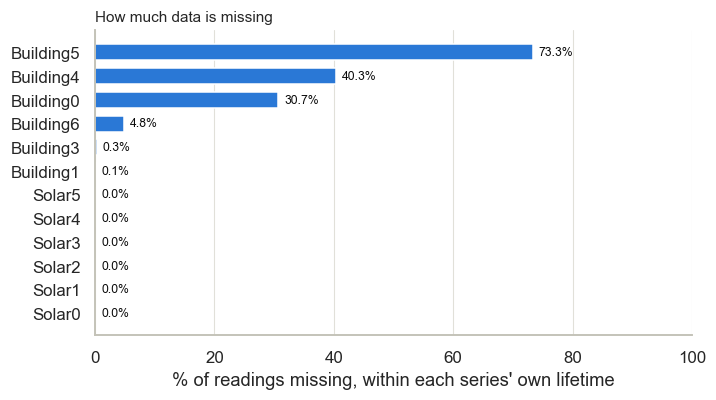

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))
order = missing_pct.sort_values()
bars = ax.barh(order.index, order.to_numpy(), color=BLUE, height=0.68)
for y, v in enumerate(order.to_numpy()):
    ax.text(v + 1, y, f"{v}%", va="center", fontsize=8, color=INK)
ax.set_xlim(0, 100)
ax.set_xlabel("% of readings missing, within each series' own lifetime")
ax.set_title("How much data is missing", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

**All six solar series are 100% complete.** Whatever logs the panels never drops a
reading, so solar is purely a modelling problem with no data-repair work attached.

The buildings split into three groups: Building1, Building3 and Building6 are
essentially complete; Building0 is missing about a third; and Building4 and
Building5 are missing 40% and 73%. But the percentage alone is misleading — the
next two charts show why Building0 and Building4, which look comparably bad here,
need completely different treatment.

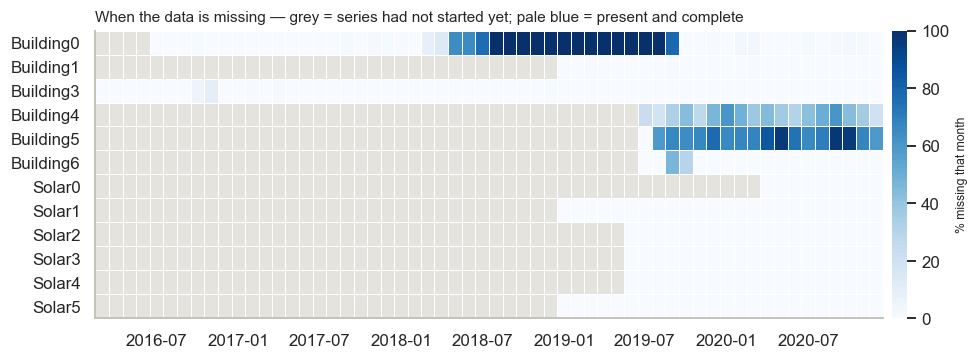

In [16]:
# WHEN is the data missing?
monthly = gaps.resample("MS").mean() * 100

# Grey means "this series did not exist yet", which is different from a pale blue
# "existed and lost nothing". Without this the solar rows and the empty years
# would look identical.
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#e5e3de")

fig, ax = plt.subplots(figsize=(11, 3.4))
mesh = ax.pcolormesh(monthly.index, np.arange(len(monthly.columns)),
                     np.ma.masked_invalid(monthly.T.to_numpy()),
                     cmap=cmap, vmin=0, vmax=100, shading="nearest",
                     edgecolors="white", linewidth=0.4)
ax.set_yticks(np.arange(len(monthly.columns)), monthly.columns)
ax.invert_yaxis()
ax.grid(False)
cb = fig.colorbar(mesh, ax=ax, pad=0.01)
cb.set_label("% missing that month", fontsize=8)
cb.outline.set_visible(False)
ax.set_title("When the data is missing — grey = series had not started yet; "
             "pale blue = present and complete", loc="left")
plt.show()

Now the difference is obvious. **Building0's missing data is one enormous dark
block** running from mid-2018 to late-2019 — not a data-quality problem so much as
a period where the meter was simply off. Building4 and Building5, by contrast, are
a consistent medium blue across their whole lifetime: their loss is spread evenly
rather than concentrated.

In [17]:
# WHAT SHAPE are the gaps? Measure the length of each run of consecutive NaNs.
def gap_lengths(series):
    isna = series.isna().to_numpy()
    if not isna.any():
        return np.array([], dtype=int)
    # Find where runs of True start and stop.
    edges = np.diff(np.concatenate(([0], isna.view(np.int8), [0])))
    return np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)


rows = []
for c in df.columns:
    lengths = gap_lengths(tsf["nov"][c])
    if len(lengths) == 0:
        rows.append({"series": c, "n gaps": 0, "median gap": 0, "longest gap": "-",
                     "gaps >= 1 day": 0, "% of loss in long gaps": 0.0})
        continue
    long_gaps = lengths[lengths >= 96]          # 96 steps = one full day
    rows.append({
        "series": c,
        "n gaps": len(lengths),
        "median gap": int(np.median(lengths)),          # in 15-min steps
        "longest gap": f"{lengths.max() / 96:.1f} days",
        "gaps >= 1 day": int(len(long_gaps)),
        "% of loss in long gaps": round(100 * long_gaps.sum() / lengths.sum(), 1),
    })

pd.DataFrame(rows).set_index("series")

,n gaps,median gap,longest gap,gaps >= 1 day,% of loss in long gaps
series,,,,,
Building0,62,10,441.2 days,6,97.4
Building1,9,3,0.3 days,0,0.0
Building3,23,1,4.7 days,1,79.2
Building4,11696,1,0.3 days,0,0.0
Building5,363,50,14.9 days,91,68.2
Building6,21,2,23.2 days,1,98.1
Solar0,0,0,-,0,0.0
Solar1,0,0,-,0,0.0
Solar2,0,0,-,0,0.0


**This table is the one that decides what you do.** Read the last column — it says
what fraction of each series' missing data sits in gaps of a day or longer.

- **Building0** — 62 gaps, but 97% of the loss is in long ones, and the longest is
  **441 days**. This is a structural outage. Do not interpolate it; instead train
  only on the segment after it ends. A 441-day hole is also long enough that the
  building's usage pattern may have genuinely changed across it, so bridging the
  two eras assumes something you have not checked.
- **Building6** — the same story in miniature: 98% of its small loss is a single
  23-day outage. Once you drop or ignore that window, the series is clean.
- **Building4** — the opposite: 11,696 separate gaps with a **median length of 1
  step**, and none reaching a day. These are isolated dropped readings and
  interpolate cleanly. Its 40% headline number is much less alarming than it looks.
- **Building5** — the genuinely hard case. Not one outage but 91 separate gaps of a
  day or more, scattered throughout. There is no clean segment to retreat to.

Building0's longest gap: 2018-07-10 -> 2019-09-24  (441 days)


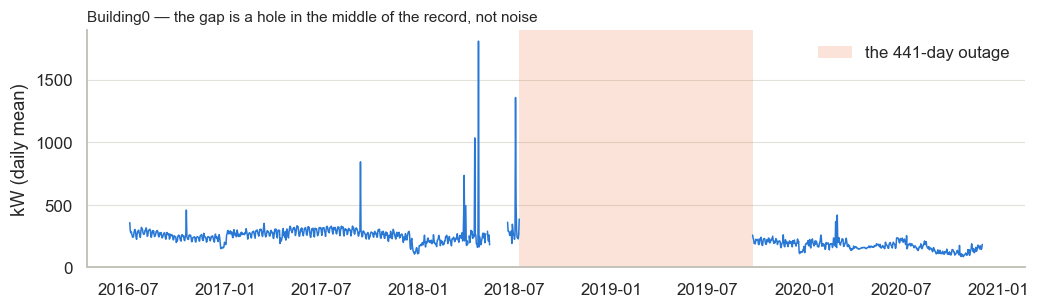


Usable history after the outage: 2019-09-24 onwards, 41,255 readings, 1.0% missing


In [18]:
# Look directly at Building0's outage rather than trusting the summary.
b0 = tsf["nov"]["Building0"].tz_convert(LOCAL_TZ)
lengths = gap_lengths(b0)
isna = b0.isna().to_numpy()
starts = np.flatnonzero(np.diff(np.concatenate(([0], isna.view(np.int8), [0]))) == 1)
biggest = starts[lengths.argmax()]

print(f"Building0's longest gap: {b0.index[biggest]:%Y-%m-%d} -> "
      f"{b0.index[biggest + lengths.max() - 1]:%Y-%m-%d}  ({lengths.max() / 96:.0f} days)")

fig, ax = plt.subplots(figsize=(11, 2.8))
daily = b0.resample("D").mean()
ax.plot(daily.index, daily.to_numpy(), color=BLUE, lw=1.0)
ax.axvspan(b0.index[biggest], b0.index[biggest + lengths.max() - 1],
           color=ORANGE, alpha=0.18, lw=0, label="the 441-day outage")
ax.set_ylabel("kW (daily mean)")
ax.set_title("Building0 — the gap is a hole in the middle of the record, not noise",
             loc="left")
ax.grid(True, axis="y"); ax.legend(loc="upper right")
plt.show()

usable = b0.loc[b0.index[biggest + lengths.max()]:]
print(f"\nUsable history after the outage: {usable.index[0]:%Y-%m-%d} onwards, "
      f"{usable.notna().sum():,} readings, {100 * usable.isna().mean():.1f}% missing")

In [19]:
# Finally: is anything missing inside the months we are scored on?
scored = pd.DataFrame({
    "Oct 2020 missing %": (test_oct.isna().mean() * 100).round(1),
    "Nov 2020 missing %": (test_nov.isna().mean() * 100).round(1),
})
scored

,Oct 2020 missing %,Nov 2020 missing %
series,,
Building0,2.1,1.9
Building1,0.0,0.0
Building3,0.0,0.2
Building4,43.2,35.8
Building5,95.5,66.7
Building6,0.1,0.2
Solar0,0.0,0.0
Solar1,0.0,0.0
Solar2,0.0,0.0


**Building5 is ~96% absent in October and ~67% in November** — the ground truth
you are scored against barely exists. Building4 is 40%-ish missing in both.

This changes how you should think about those two series. You are not being
measured on how well you track a signal; you are being measured on a handful of
surviving points. Sophisticated modelling has little to grip, and an elaborate
model can easily score *worse* than a flat seasonal average by being confidently
wrong on the few readings that count.

## What to do — a per-series plan

| Series | Missing | Treatment |
|---|---|---|
| Solar0–5 | 0% | Nothing needed |
| Building1, Building3 | ~0% | Nothing needed |
| Building6 | 4.8% | Drop the single 23-day outage; interpolate the rest |
| Building4 | 40% | Interpolate — gaps are single steps. Check it is a real load, not a stuck sensor |
| Building0 | 31% | Train only on post-outage data (2019-10 onwards); do not bridge the gap |
| Building5 | 73% | Simple, robust forecast (seasonal profile). Do not over-model |

**A rule worth adopting:** interpolate short gaps, truncate around long ones, and
never interpolate across a gap longer than the seasonal cycle you are trying to
learn. Filling a week-long hole with a straight line teaches the model that
demand is flat for a week.

**One caution for later.** When you interpolate, do it on the training data only,
and never fill forwards across the boundary into October or November. Filling test
gaps with interpolated values would mean scoring your model against numbers you
invented.

---

# 8. All 12 series on one time axis

Section 7 answered *how much* is missing per series. This section answers a
different question: **when is each series available, relative to the others?**

That matters for anything that learns across series — a global model, a shared
embedding, or even just a fair comparison — because those need a window where the
relevant series all exist simultaneously. A series can be 100% complete and still
be nearly useless for cross-learning if it only starts a few months before the
forecast window.

In [20]:
# Daily coverage: what fraction of each day's 96 readings is present.
present = (~df.isna()).resample("D").mean()

# Which days fall inside each series' own lifetime (vs. before it ever started).
existed = lifespan.resample("D").max().astype(bool)

# Mask the pre-start period so it renders as grey rather than as "0% present".
coverage = present.where(existed)

# When does every series exist at once? That is the binding constraint on any
# model that learns across all 12 together.
starts = pd.Series({c: tsf["nov"][c].index[0].tz_convert(LOCAL_TZ) for c in df.columns})
all_start = starts.max()
buildings_start = starts[BUILDINGS].max()

print("First reading of each series:")
print(starts.sort_values().dt.strftime("%Y-%m-%d").to_string())
print(f"\nAll 6 buildings coexist from : {buildings_start:%Y-%m-%d}")
print(f"All 12 series coexist from   : {all_start:%Y-%m-%d}  "
      f"({(pd.Timestamp('2020-10-01', tz=LOCAL_TZ) - all_start).days} days before the Oct window)")

First reading of each series:
Building3    2016-03-01
Building0    2016-07-04
Solar1       2019-01-01
Building1    2019-01-10
Solar5       2019-01-16
Solar2       2019-06-06
Solar3       2019-06-06
Solar4       2019-06-06
Building4    2019-07-03
Building6    2019-07-25
Building5    2019-07-26
Solar0       2020-04-26

All 6 buildings coexist from : 2019-07-26
All 12 series coexist from   : 2020-04-26  (158 days before the Oct window)


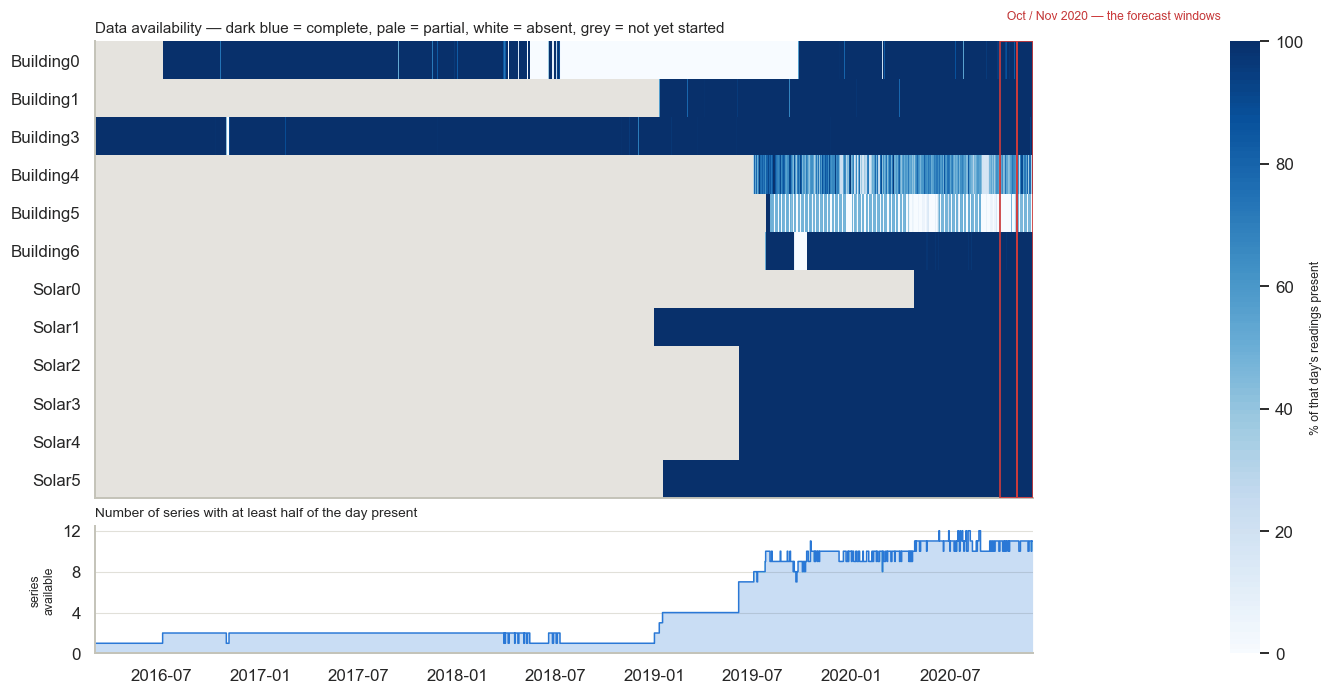

In [21]:
fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.2), height_ratios=[5, 1.4], sharex=True,
    constrained_layout=True)

cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#e5e3de")            # grey = series did not exist yet

mesh = ax.pcolormesh(coverage.index, np.arange(len(coverage.columns)),
                     np.ma.masked_invalid(coverage.T.to_numpy()) * 100,
                     cmap=cmap, vmin=0, vmax=100, shading="nearest")
ax.set_yticks(np.arange(len(coverage.columns)), coverage.columns)
ax.invert_yaxis()
ax.grid(False)

# Mark the two months we have to forecast.
for lo, hi in (OCT, NOV):
    ax.axvspan(lo, hi, facecolor="none", edgecolor="#d03b3b", lw=1.1, zorder=5)
ax.text(OCT[0], -1.0, "  Oct / Nov 2020 — the forecast windows",
        color="#d03b3b", fontsize=8, va="bottom")

cb = fig.colorbar(mesh, ax=[ax, ax2], pad=0.01)
cb.set_label("% of that day's readings present", fontsize=8)
cb.outline.set_visible(False)
ax.set_title("Data availability — dark blue = complete, pale = partial, "
             "white = absent, grey = not yet started", loc="left")

# How many series are usable on any given day?
usable = (coverage.fillna(0) >= 0.5).sum(axis=1)
ax2.fill_between(usable.index, usable.to_numpy(), step="mid", color="#2a78d6", alpha=0.25, lw=0)
ax2.plot(usable.index, usable.to_numpy(), color="#2a78d6", lw=1.0, drawstyle="steps-mid")
ax2.set_ylim(0, 12.5)
ax2.set_yticks([0, 4, 8, 12])
ax2.set_ylabel("series\navailable", fontsize=8)
ax2.grid(True, axis="y")
ax2.set_title("Number of series with at least half of the day present", loc="left", fontsize=9)
plt.show()

**What the chart shows.**

Read down any vertical line to see which series existed at that moment. The two
red rectangles are the months you have to forecast.

The most consequential fact is the **staircase on the left**: the series switch on
at very different dates, so the amount of history they share is far smaller than
any individual series' length suggests. Building3 has nearly five years, but the
window where *all twelve* overlap is only the last few months before the forecast
period — Solar0 is the binding constraint, and it is the newest series by a wide
margin.

The bottom strip makes the practical consequence concrete: the count of usable
series only reaches its maximum quite late. If you build a single model across all
12 series, that late date is all the training data it can have. Two ways around it:
train per series (each uses its own full history), or train across a *subset*
chosen so the shared window is long enough to be worth having.

The other thing worth noticing is that **Building4 and Building5 are pale
throughout** rather than dark-with-white-holes. Their loss is not concentrated in
an era you can cut away — it is spread through every month they exist, which is
exactly what made them different from Building0 in the previous section.

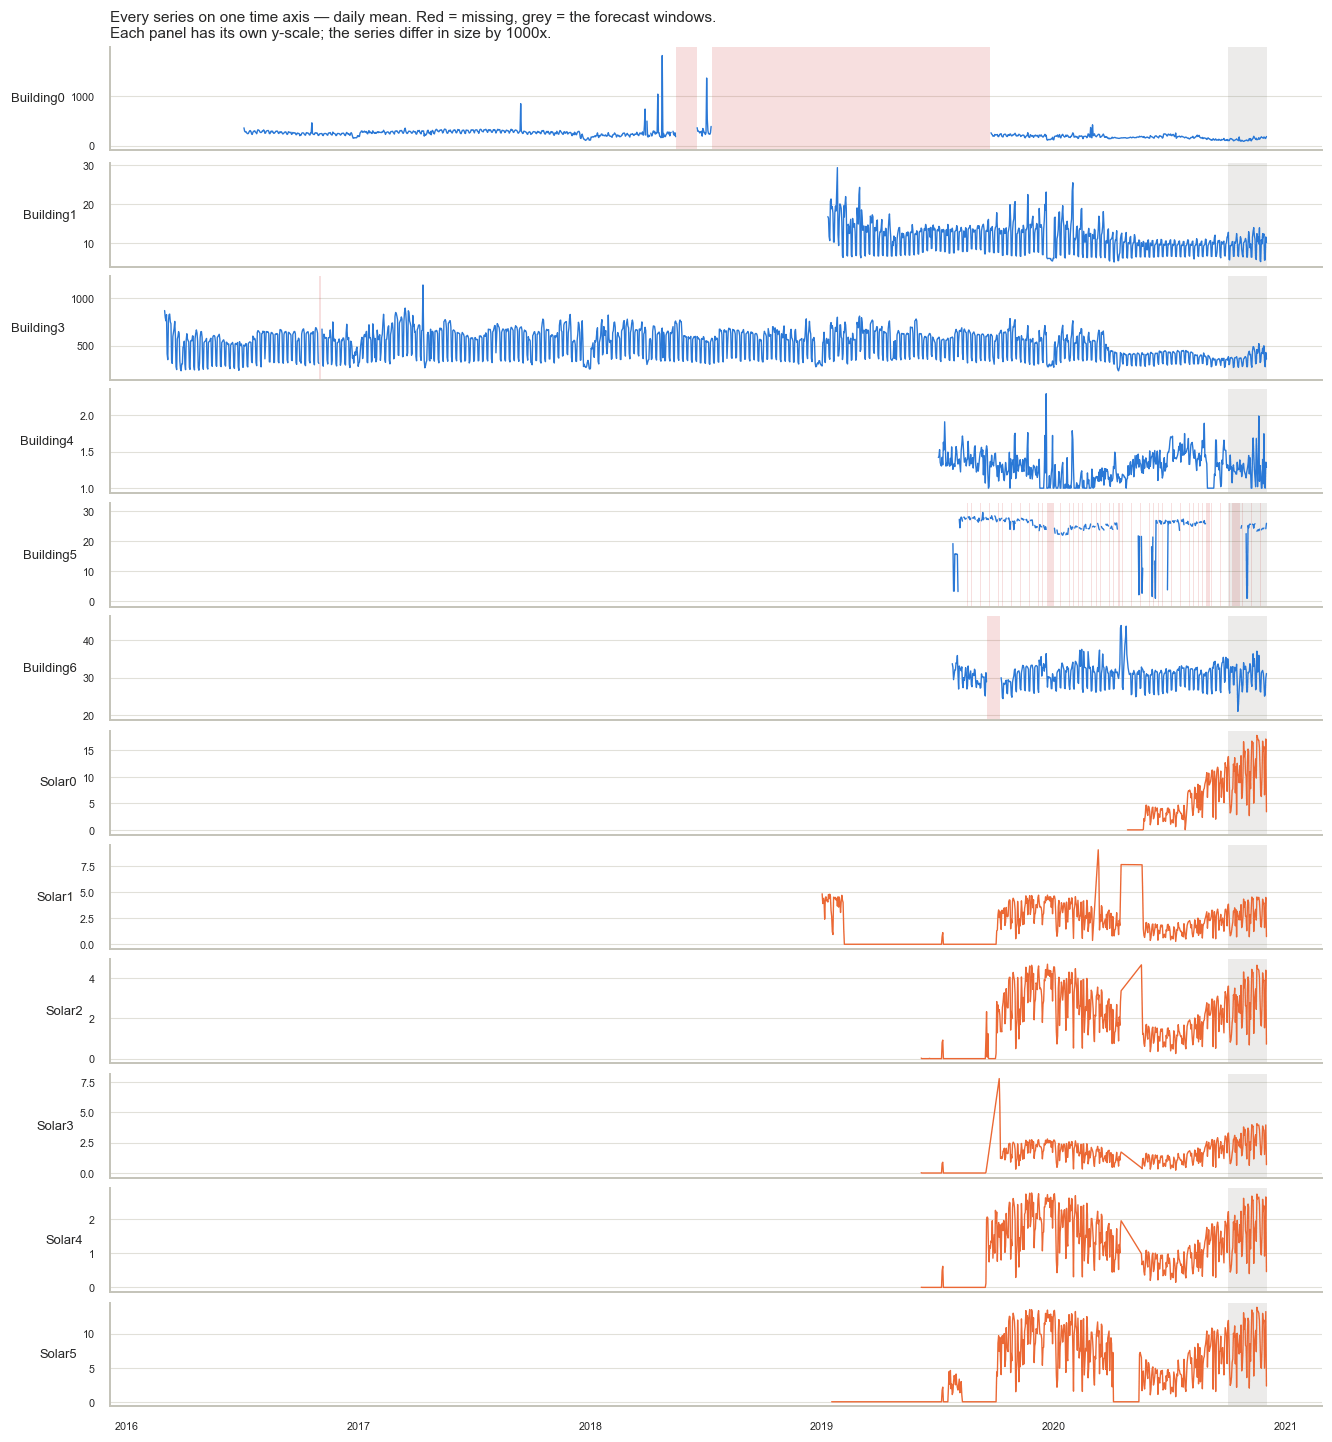

In [22]:
# The same time axis, now showing the actual values. Gaps appear as breaks in the
# line, so you can see the data and its holes together.
fig, axes = plt.subplots(len(df.columns), 1, figsize=(12, 13), sharex=True,
                         constrained_layout=True)

daily_mean = df.resample("D").mean()

for ax, col in zip(axes, df.columns):
    colour = "#2a78d6" if col.startswith("Building") else "#eb6834"
    ax.plot(daily_mean.index, daily_mean[col].to_numpy(), color=colour, lw=0.9)

    # Shade days that are entirely absent but inside the series' lifetime.
    absent = (coverage[col] == 0)
    if absent.any():
        ax.fill_between(coverage.index, 0, 1, where=absent.to_numpy(),
                        transform=ax.get_xaxis_transform(),
                        color="#d03b3b", alpha=0.16, lw=0)

    for lo, hi in (OCT, NOV):
        ax.axvspan(lo, hi, color="#898781", alpha=0.16, lw=0)

    ax.set_ylabel(col, rotation=0, ha="right", va="center", fontsize=8.5)
    ax.grid(True, axis="y")
    ax.tick_params(labelsize=7)

axes[0].set_title("Every series on one time axis — daily mean. Red = missing, "
                  "grey = the forecast windows.\nEach panel has its own y-scale; "
                  "the series differ in size by 1000x.", loc="left", fontsize=10)
plt.show()

Each panel keeps its own y-scale deliberately. Building4 peaks around 5 kW and
Building3 around 8,556 kW, so a shared scale would flatten ten of the twelve
panels into flat lines, and a second y-axis would make two unrelated scales look
comparable. The trade-off is that you can compare *shape* and *timing* down the
column, but not magnitude — for magnitude, read the summary table in section 2.

Lined up this way, three things stand out that were invisible series-by-series:

- **The solar series move together**, with the same seasonal envelope, because
  they sit on one campus under one sky. That is exactly the redundancy a global
  model across the solar panels could exploit — and unlike the buildings, they
  share a long clean overlap.
- **Building0's outage sits in the middle of its record**, while Building4's and
  Building5's red is stippled throughout theirs.
- **Nothing is missing from the forecast windows for the solar series or for
  Buildings 1, 3 and 6** — the grey bands are clean for eight of the twelve.

Window where all 12 series exist: 2020-04-26 -> 2020-12-01 (21,064 rows, 219 days)


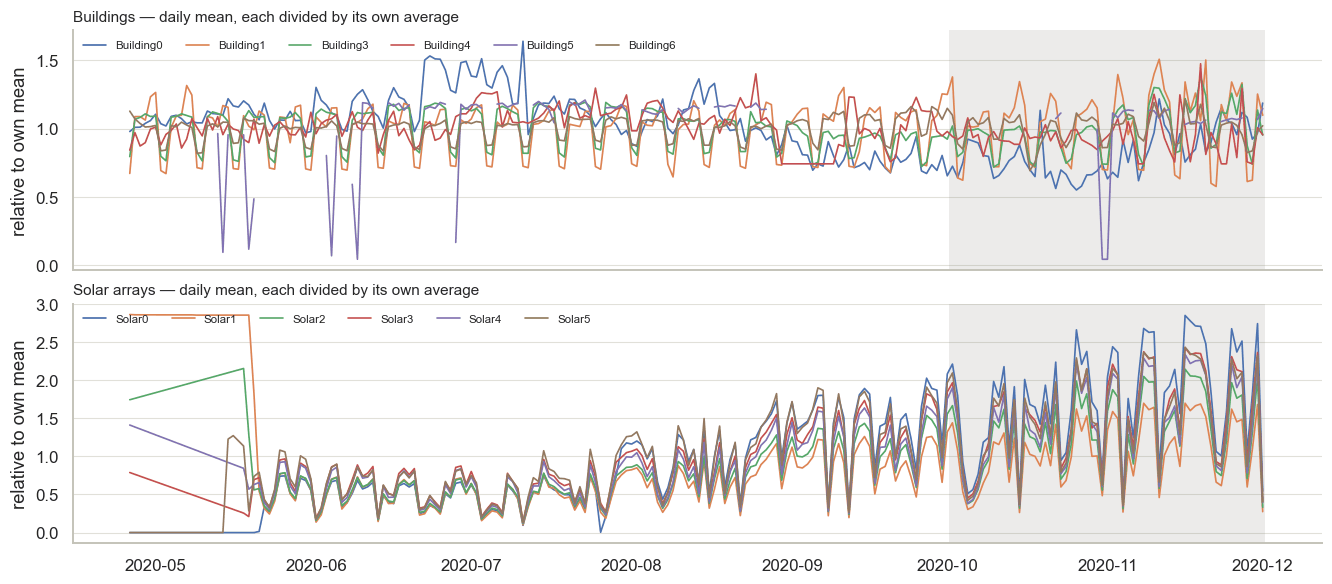

In [23]:
# Zoom on the window where all 12 series coexist - the realistic span for any
# model that learns across every series at once.
recent = df.loc[all_start:]

fig, axes = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True, constrained_layout=True)

for col in BUILDINGS:
    s = recent[col].resample("D").mean()
    axes[0].plot(s.index, (s / s.mean()).to_numpy(), lw=1.1, label=col)
for col in SOLAR:
    s = recent[col].resample("D").mean()
    axes[1].plot(s.index, (s / s.mean()).to_numpy(), lw=1.1, label=col)

for ax, title in zip(axes, ["Buildings", "Solar arrays"]):
    for lo, hi in (OCT, NOV):
        ax.axvspan(lo, hi, color="#898781", alpha=0.16, lw=0)
    ax.set_title(f"{title} — daily mean, each divided by its own average", loc="left")
    ax.set_ylabel("relative to own mean")
    ax.grid(True, axis="y")
    ax.legend(ncol=6, fontsize=7.5, loc="upper left")

print(f"Window where all 12 series exist: {all_start:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d} "
      f"({len(recent):,} rows, {(df.index[-1] - all_start).days} days)")
plt.show()

Dividing each series by its own mean is what makes them comparable on one axis
without a second y-scale. Now the question "do these move together?" is answerable
by eye: the solar arrays track each other closely, while the buildings are far
more independent — they respond to their own occupancy rather than to a shared
driver.

That difference is a genuine modelling result, not just a picture. It suggests
pooling the solar series is likely to help, and pooling the buildings is likely to
hurt.

---

# 9. Hidden bad data — "complete" is not the same as "correct"

Section 7 concluded that all six solar series are 100% complete. That is true and
also misleading. **A reading being present does not make it valid.** The `?`
markers only tell you where the data provider *knew* a value was absent; they say
nothing about periods where a sensor reported confidently wrong numbers.

Solar gives us a free way to check, because physics supplies a ground truth:
**a solar panel produces exactly zero at night.** Any non-zero reading between
22:00 and 04:00 local time is impossible, so it is a defect — no modelling
assumptions required.

This kind of physically-grounded validity check is worth more than any outlier
statistic, because it cannot produce a false positive.

In [24]:
# Solar output at night must be zero. 22:00-04:00 is dark year-round in Melbourne
# even at the summer solstice, so this test is safe in both seasons.
night = df.between_time("22:00", "04:00")[SOLAR]
night_max = night.groupby(night.index.normalize()).max()

bad_days = night_max > 0.01          # tolerance for float noise
report = pd.DataFrame({
    "days with output at night": bad_days.sum(),
    "days observed": night_max.notna().sum(),
})
report["% of days invalid"] = (100 * report.iloc[:, 0] / report.iloc[:, 1]).round(1)
report["first bad day"] = [
    f"{bad_days.index[bad_days[c].fillna(False)][0]:%Y-%m-%d}" if bad_days[c].any() else "-"
    for c in SOLAR]
report["last bad day"] = [
    f"{bad_days.index[bad_days[c].fillna(False)][-1]:%Y-%m-%d}" if bad_days[c].any() else "-"
    for c in SOLAR]
report

,days with output at night,days observed,% of days invalid,first bad day,last bad day
series,,,,,
Solar0,26,220,11.8,2020-05-24,2020-10-05
Solar1,47,701,6.7,2020-03-02,2020-05-20
Solar2,39,545,7.2,2019-10-09,2020-05-19
Solar3,62,545,11.4,2019-09-16,2020-05-19
Solar4,35,545,6.4,2020-04-15,2020-05-19
Solar5,0,686,0.0,-,-


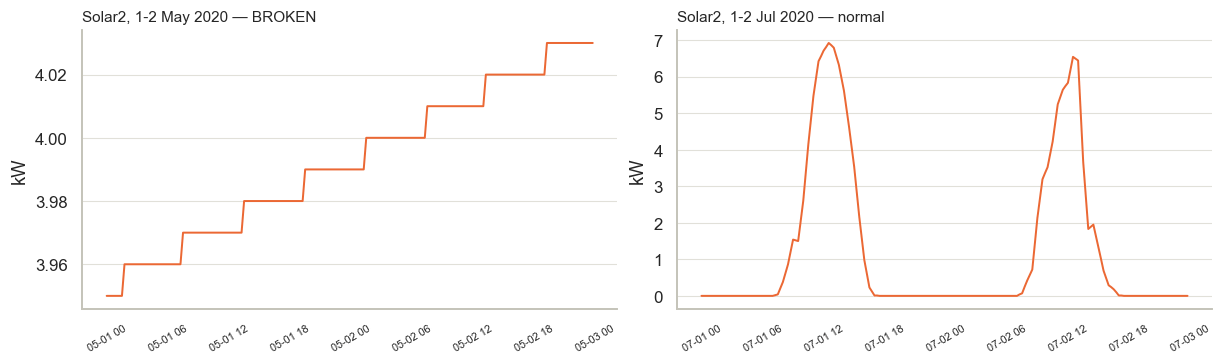

2020-05-01 00:00:00+10:00    3.95
2020-05-01 00:15:00+10:00    3.95
2020-05-01 00:30:00+10:00    3.95
2020-05-01 00:45:00+10:00    3.95
2020-05-01 01:00:00+10:00    3.95
2020-05-01 01:15:00+10:00    3.95
2020-05-01 01:30:00+10:00    3.95
2020-05-01 01:45:00+10:00    3.96
2020-05-01 02:00:00+10:00    3.96
2020-05-01 02:15:00+10:00    3.96
2020-05-01 02:30:00+10:00    3.96
2020-05-01 02:45:00+10:00    3.96
2020-05-01 03:00:00+10:00    3.96
Freq: 15min


In [25]:
# Look at the worst offender directly. Two days from the middle of Solar2's
# affected period, plotted against a known-good period for comparison.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)

for ax, (span, label) in zip(axes, [
        (slice("2020-05-01", "2020-05-02"), "Solar2, 1-2 May 2020 — BROKEN"),
        (slice("2020-07-01", "2020-07-02"), "Solar2, 1-2 Jul 2020 — normal")]):
    seg = df.loc[span, "Solar2"]
    ax.plot(seg.index, seg.to_numpy(), color="#eb6834", lw=1.3)
    ax.set_title(label, loc="left")
    ax.set_ylabel("kW")
    ax.grid(True, axis="y")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
plt.show()

print(df.loc["2020-05-01 00:00":"2020-05-01 03:00", "Solar2"].to_string())

**The broken panel has no day/night cycle at all.** It sits around 3.95–4.03 kW
and creeps upward monotonically, including all through the night. That is not
power output — it looks like a **cumulative energy counter** (kWh accumulated
since reset) that has been written into a column that is supposed to hold
instantaneous kW, or a sensor stuck in a fault mode.

Crucially, **none of it is flagged with `?`**. It is silently wrong. Had we
trained on it, the model would have learned that Solar2 sometimes generates 4 kW
at 3am.

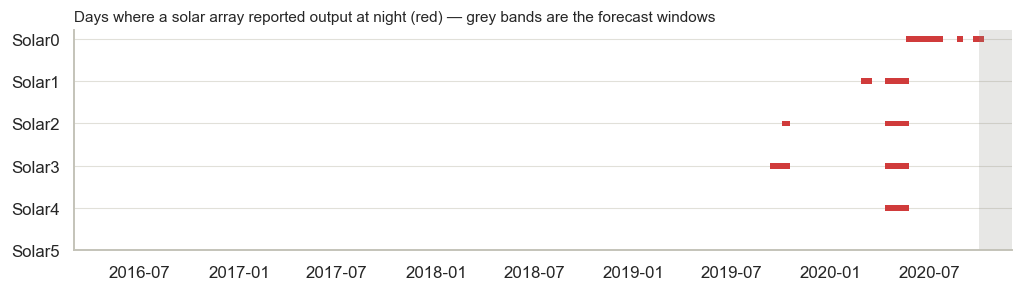

Invalid days falling inside October/November 2020:
series
Solar0    2
Solar1    0
Solar2    0
Solar3    0
Solar4    0
Solar5    0


In [26]:
# When are the defects, and do any land in the months we forecast?
fig, ax = plt.subplots(figsize=(11, 2.6))
for i, col in enumerate(SOLAR):
    days = bad_days.index[bad_days[col].fillna(False)]
    if len(days):
        ax.scatter(days, np.full(len(days), i), s=14, marker="s",
                   color="#d03b3b", edgecolors="none")
ax.set_yticks(range(len(SOLAR)), SOLAR)
ax.invert_yaxis()
for lo, hi in (OCT, NOV):
    ax.axvspan(lo, hi, color="#898781", alpha=0.2, lw=0)
ax.set_xlim(df.index[0], df.index[-1])
ax.grid(True, axis="y")
ax.set_title("Days where a solar array reported output at night (red) — "
             "grey bands are the forecast windows", loc="left")
plt.show()

in_window = bad_days.loc[(bad_days.index >= OCT[0]) & (bad_days.index < NOV[1])].sum()
print("Invalid days falling inside October/November 2020:")
print(in_window.to_string())

**The good news is the timing.** Almost all of the corruption sits in 2019 and the
first half of 2020, and only Solar0 has any inside the forecast windows. So this
damages your *training* data rather than the data you are scored against.

**What to do.** Treat these periods as missing rather than deleting the series:
set the affected days to `NaN` before training so the model never sees them. That
is a two-line fix once you have the `bad_days` table above.

**The wider lesson for the report.** The `?` markers are the provider's account of
what is missing, and they are incomplete. Before trusting any series, test it
against something you know must be true:

- Solar output is zero at night, and never exceeds the array's physical capacity.
- Building demand is never negative, and a real building is never *perfectly*
  flat for hours — a long run of identical values means a stuck sensor, not
  steady consumption. (Recall from section 2 that Building4 only ever reports
  values between 1.0 and 5.0 — worth applying exactly this suspicion to.)
- Readings should not jump by more than the equipment physically can.

Each of those is a rule you can state before looking at the data, which is what
separates a data-quality check from post-hoc outlier removal.

---

# 10. Preparing solar + weather for a production model

The goal: one tidy table where each row is *one array at one hourly stamp*, with
the production we want to predict alongside the weather that explains it.

## Decision 1 — resample solar down to hourly

Solar is recorded every **15 minutes**; ERA5 is **hourly**. They cannot be joined
until they share a resolution, and there are two directions: downsample solar, or
interpolate ERA5 up.

**We downsample solar to hourly.** Since this project is not being run as the
original competition, there is no 15-minute submission format forcing our hand,
and the objective — predict solar production — is unchanged by the choice of
resolution.

Going hourly buys three things:

- **The weather join becomes exact.** At 15 minutes we would have to *invent*
  intermediate weather values by interpolation. At hourly resolution each ERA5
  record lines up with exactly one solar bucket, with nothing approximated.
- **Less noise in the target.** A 15-minute reading catches individual clouds
  crossing the panel, which is close to unpredictable from a reanalysis grid
  point. Averaging to the hour removes variance the weather data was never able
  to explain.
- **Four times fewer rows**, which makes every model faster to fit.

The cost is real but small, and the next cell measures it rather than assuming it.

In [27]:
# What does hourly averaging discard? Compare the true 15-minute series against
# the hourly step-function that replaces it.
print("Variance of the 15-minute signal retained by the hourly average:\n")
for c in SOLAR:
    s = df[c].dropna()
    expanded = s.resample("h").mean().reindex(s.index, method="ffill")
    r2 = 1 - ((s - expanded) ** 2).sum() / ((s - s.mean()) ** 2).sum()
    print(f"  {c}:  R^2 = {r2:.4f}   ({100 * (1 - r2):.1f}% is sub-hourly detail)")

Variance of the 15-minute signal retained by the hourly average:

  Solar0:  R^2 = 0.9788   (2.1% is sub-hourly detail)
  Solar1:  R^2 = 0.9873   (1.3% is sub-hourly detail)
  Solar2:  R^2 = 0.9830   (1.7% is sub-hourly detail)
  Solar3:  R^2 = 0.9832   (1.7% is sub-hourly detail)
  Solar4:  R^2 = 0.9829   (1.7% is sub-hourly detail)
  Solar5:  R^2 = 0.9825   (1.8% is sub-hourly detail)


Only 1.3–2.1% of the variation is sub-hourly. That is the part driven by
individual clouds — precisely the part a single hourly reanalysis grid point was
never going to predict — so we lose very little that was actually forecastable.

## Decision 2 — line the two clocks up

ERA5's radiation variables are **accumulations over the preceding hour**, stamped
at the *end* of the period. A record labelled `12:00` describes the sunlight that
fell between 11:00 and 12:00.

Pandas resampling labels buckets by their *left* edge, so the solar bucket
covering that same span is labelled `11:00`. The two describe an identical hour
under different names, and joining on the raw label pairs each ERA5 record with
the wrong hour of production.

Shifting ERA5 back by exactly 60 minutes makes the labels agree — and because
both then refer to the same clock hour, this is an **exact interval match with no
interpolation at all**. The cell below verifies it against the data.

In [28]:
ERA5_SHIFT = pd.Timedelta(hours=-1)   # accumulations are stamped at the END of their hour

# Solar5 is the reference: section 9 showed it is the only array with no invalid
# night-time readings, so it is the cleanest yardstick.
probe = df["Solar5"].loc["2019-07-01":"2020-11-30"].resample("h").mean()
radiation = era5["surface_solar_radiation"]

for label, shift in [("raw label (no shift)", pd.Timedelta(0)),
                     ("shifted back one hour", ERA5_SHIFT)]:
    aligned = radiation.copy()
    aligned.index = aligned.index + shift
    paired = pd.DataFrame({"production": probe,
                           "radiation": aligned.reindex(probe.index)}).dropna()
    print(f"{label:24s} corr = {paired['production'].corr(paired['radiation']):.5f}  "
          f"({len(paired):,} paired hours)")

raw label (no shift)     corr = 0.80626  (12,455 paired hours)
shifted back one hour    corr = 0.85782  (12,455 paired hours)


The corrected join is markedly better, and it is better for a reason we could
state in advance rather than something discovered by search. That distinction
matters in the write-up: this is a fix derived from how ERA5 is defined, not a
parameter tuned until the number improved.

## Decision 3 — arrays that were switched off report zero, not missing

Now that production and radiation share a clock, a third problem becomes visible,
and it is the largest one in this section.

Section 7 found the solar series to be 100% complete, and section 9 found
nonsense night-time values in five of them. This is a third failure mode: hours
where the sun was **demonstrably bright** and the array returned **exactly zero**.
A panel under 800 W/m² of sunshine does not produce nothing. The array was off —
under maintenance, not yet commissioned, or disconnected — and the logger recorded
a confident zero instead of a missing value.

In [29]:
BRIGHT_WM2 = 200        # above this the sun is definitely up and shining
MIN_BRIGHT_HOURS = 4    # a day needs this many bright hours before we judge it

# How often is the sun bright while an array reports exactly nothing?
probe_weather = era5.copy()
probe_weather.index = probe_weather.index + ERA5_SHIFT
rad_h = probe_weather["surface_solar_radiation"]

rows = []
for name in SOLAR:
    hourly = df[name].resample("h").mean()
    paired = pd.DataFrame({"p": hourly, "r": rad_h.reindex(hourly.index)}).dropna()
    bright = paired[paired["r"] > BRIGHT_WM2]
    zero = bright["p"] == 0
    by_day = bright.groupby(bright.index.normalize())
    dead_days = (by_day["p"].apply(lambda g: (g == 0).all()) & (by_day.size() >= MIN_BRIGHT_HOURS))
    rows.append({
        "array": name,
        "bright hours": len(bright),
        "zero while bright": int(zero.sum()),
        "%": round(100 * zero.mean(), 1),
        "fully offline days": int(dead_days.sum()),
    })
pd.DataFrame(rows).set_index("array")

,bright hours,zero while bright,%,fully offline days
array,,,,
Solar0,1470,131,8.9,19
Solar1,5420,1638,30.2,218
Solar2,4116,677,16.4,95
Solar3,4116,559,13.6,85
Solar4,4116,560,13.6,84
Solar5,5252,1963,37.4,251


**Between 9% and 37% of bright hours** are affected, which is far too large to
ignore — and the pattern says plainly that these are outages rather than scattered
glitches. On 231 of the 234 affected dates, *every single* bright hour is zero: the
array was down for the whole day, not flickering.

Two details confirm the reading. The longest run for Solar5 is 1,297 consecutive
bright hours. And the block starting **29 August 2019 appears in five arrays at
once** — a site-wide event, not six independent sensor faults.

Most of it sits in 2019, when the arrays were being commissioned, which is also
why Solar0 opens with 25 days of pure zeros. **None of it falls in October or
November 2020**, so the forecast windows are clean; the damage is confined to
training data.

The rule below marks a day offline when the sun was bright for at least four hours
and the array returned exactly zero in every one of them, then blanks that day.
Note this is deliberately conservative: it needs a *whole day* of evidence, so a
genuinely dark stormy day can never trigger it.

## Building the table

In [30]:
# The ERA5 grid point, from the "coordinates" column dropped back in section 3.
LAT, LON = -37.91, 145.13
MIN_READINGS_PER_HOUR = 3   # of a possible 4; below this the hourly mean is unreliable
# BRIGHT_WM2 and MIN_BRIGHT_HOURS were defined with the offline analysis above.


def solar_elevation(timestamps):
    """Sun elevation in degrees. A pure function of time and place, so it is
    always available for future timestamps - no weather forecast required."""
    utc = timestamps.tz_convert("UTC")
    doy = utc.dayofyear.to_numpy()
    hours = utc.hour.to_numpy() + utc.minute.to_numpy() / 60
    g = 2 * np.pi / 365.25 * (doy - 1 + (hours - 12) / 24)
    declination = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g)
                   - 0.006758 * np.cos(2 * g) + 0.000907 * np.sin(2 * g)
                   - 0.002697 * np.cos(3 * g) + 0.001480 * np.sin(3 * g))
    eq_time = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                        - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    hour_angle = np.deg2rad(((hours * 60 + eq_time + 4 * LON) % 1440) / 4 - 180)
    lat = np.deg2rad(LAT)
    sin_elev = (np.sin(lat) * np.sin(declination)
                + np.cos(lat) * np.cos(declination) * np.cos(hour_angle))
    return np.rad2deg(np.arcsin(np.clip(sin_elev, -1, 1)))


def build_solar_dataset(arrays=SOLAR, drop_invalid=True):
    """One row per (array, hour): hourly mean production plus aligned weather."""

    # --- Target: 15-minute production -> hourly mean kW -----------------------
    # Mean, not sum: these are power readings (kW), so the hourly mean is the
    # average power over that hour. A sum would silently change the units.
    production = {}
    for name in arrays:
        s = df[name].copy()

        # Section 9: days where an array reported output at night are sensor
        # faults. Blank the whole day - a faulty sensor's daytime readings are
        # not trustworthy either.
        if drop_invalid and name in bad_days.columns:
            faulty = bad_days.index[bad_days[name].fillna(False)]
            s = s.mask(s.index.normalize().isin(faulty))

        hourly = s.resample("h").mean()
        # Discard hours built from too few surviving 15-minute readings.
        hourly = hourly.where(s.resample("h").count() >= MIN_READINGS_PER_HOUR)
        production[name] = hourly

    production = pd.DataFrame(production)
    index = production.index

    # --- Weather: shift onto the hour it actually describes, then align -------
    shifted = era5.copy()
    shifted.index = shifted.index + ERA5_SHIFT
    weather = shifted.reindex(index)          # exact match, no interpolation

    # --- Remove offline periods ----------------------------------------------
    # An array that is switched off reports 0, not NaN. A day where the sun was
    # bright for hours and the array returned exactly zero every time was not a
    # dark day - the array was down. Left in, these teach the model that full
    # sunshine sometimes yields nothing.
    if drop_invalid:
        bright = weather["surface_solar_radiation"] > BRIGHT_WM2
        day_of = pd.Series(index.normalize(), index=index)
        for name in arrays:
            p = production[name]
            judged = p.notna() & bright
            counts = pd.DataFrame({
                "day": day_of, "bright": judged, "zero": judged & (p == 0),
            }).groupby("day")[["bright", "zero"]].sum()
            offline = counts.index[(counts["bright"] >= MIN_BRIGHT_HOURS)
                                   & (counts["zero"] == counts["bright"])]
            production[name] = p.mask(day_of.isin(offline))

    # --- Solar geometry, evaluated at the MIDPOINT of each hour ---------------
    # The bucket labelled 11:00 spans 11:00-12:00, so the sun position that
    # represents it is the one at 11:30. Using the label would bias every
    # elevation by half an hour.
    midpoints = index + pd.Timedelta(minutes=30)
    elevation = solar_elevation(midpoints)
    sin_elev = np.sin(np.deg2rad(elevation))

    weather["solar_elevation"] = elevation
    weather["is_daylight"] = (elevation > 0).astype(int)
    # Clear-sky irradiance: what a cloudless sky would deliver at this sun angle.
    weather["clear_sky_ghi"] = 1361 * np.clip(sin_elev, 0, None) * 0.75
    # Clear-sky index: how much of that actually arrived. Divides out the daily
    # and seasonal envelope, leaving the cloud-driven part - the only genuinely
    # uncertain component. Undefined at night (0/0), where 0 is the sane fill:
    # none expected, none arrived. Night predictions are clamped to zero anyway.
    weather["clear_sky_index"] = (
        weather["surface_solar_radiation"] / weather["clear_sky_ghi"].replace(0, np.nan)
    ).clip(0, 1.5).fillna(0.0)

    # Recent radiation history - cloud cover persists over a few hours.
    for lag in (1, 2, 3):
        weather[f"radiation_lag_{lag}h"] = weather["surface_solar_radiation"].shift(lag)
    weather["radiation_roll_3h"] = weather["surface_solar_radiation"].rolling(3).mean()

    # Calendar terms, encoded cyclically so 23:00 and 00:00 sit adjacent.
    weather["tod_sin"] = np.sin(2 * np.pi * index.hour / 24)
    weather["tod_cos"] = np.cos(2 * np.pi * index.hour / 24)
    weather["doy_sin"] = np.sin(2 * np.pi * index.dayofyear / 365.25)
    weather["doy_cos"] = np.cos(2 * np.pi * index.dayofyear / 365.25)

    # --- Stack the arrays into long format ------------------------------------
    frames = []
    for name in arrays:
        part = weather.copy()
        part.insert(0, "array", name)
        part.insert(1, "production_kw", production[name])
        frames.append(part)

    out = pd.concat(frames).sort_index()
    out.index.name = "hour"
    return out


solar_data = build_solar_dataset()
print(f"{len(solar_data):,} rows x {solar_data.shape[1]} columns "
      f"({solar_data['array'].nunique()} arrays, hourly)")
print(f"span: {solar_data.index.min():%Y-%m-%d %H:%M} -> {solar_data.index.max():%Y-%m-%d %H:%M}")
solar_data.head()

249,960 rows x 22 columns (6 arrays, hourly)
span: 2016-03-01 15:00 -> 2020-12-01 10:00


,array,production_kw,temperature,dewpoint_temperature,wind_speed,mean_sea_level_pressure,relative_humidity,surface_solar_radiation,surface_thermal_radiation,total_cloud_cover,solar_elevation,is_daylight,clear_sky_ghi,clear_sky_index,radiation_lag_1h,radiation_lag_2h,radiation_lag_3h,radiation_roll_3h,tod_sin,tod_cos,doy_sin,doy_cos
hour,,,,,,,,,,,,,,,,,,,,,,
2016-03-01 15:00:00+11:00,Solar0,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar2,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar5,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar4,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar1,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137


In [31]:
# Confirm the resampling behaved: production should still be non-negative, and
# the hourly peak should land near the middle of the day.
check = solar_data.dropna(subset=["production_kw"])
peak_hour = check.groupby(check.index.hour)["production_kw"].mean().idxmax()
print(f"negative production values : {(check['production_kw'] < 0).sum()}")
print(f"peak production hour       : {peak_hour}:00 local "
      f"({'plausible' if 10 <= peak_hour <= 14 else 'SUSPICIOUS'})")
print(f"peak solar-elevation hour  : {check.groupby(check.index.hour)['solar_elevation'].mean().idxmax()}:00")

usable = check.groupby("array").size()
pd.DataFrame({"usable hours": usable,
              "hours dropped (absent or faulty)": solar_data.groupby("array").size() - usable})

negative production values : 0
peak production hour       : 12:00 local (plausible)
peak solar-elevation hour  : 12:00


,usable hours,hours dropped (absent or faulty)
array,,
Solar0,4187,37473
Solar1,10450,31210
Solar2,9850,31810
Solar3,9539,32121
Solar4,10210,31450
Solar5,10426,31234


## Splitting for training

The same UTC boundaries as section 2. ERA5 covers October and November in full, so
the test splits already have their features populated — only the target needs
predicting.

In [32]:
model_df = solar_data.dropna(subset=["production_kw", "surface_solar_radiation"])

solar_train = model_df.loc[model_df.index < NOV[0]]   # October is now training data
solar_oct = model_df.loc[(model_df.index >= OCT[0]) & (model_df.index < OCT[1])]
solar_nov = model_df.loc[(model_df.index >= NOV[0]) & (model_df.index < NOV[1])]

for label, part in [("train", solar_train), ("October (val)", solar_oct),
                    ("November (test)", solar_nov)]:
    print(f"{label:9s} {len(part):>7,} rows   "
          f"{part.index.min():%Y-%m-%d} -> {part.index.max():%Y-%m-%d}")
print(f"\nNovember, the only scored month: 6 arrays x 720 hours = {6 * 720:,} at most")
print("October is inside the training window; it is held out only where a "
      "validation month is needed (feature pruning, blend weight, early stopping).")

FEATURES = [c for c in model_df.columns if c not in ("array", "production_kw")]
print(f"\n{len(FEATURES)} feature columns:")
print("  " + ", ".join(FEATURES))

train      50,342 rows   2019-01-01 -> 2020-11-01
October (val)   4,417 rows   2020-10-01 -> 2020-11-01
November (test)   4,320 rows   2020-11-01 -> 2020-12-01

November, the only scored month: 6 arrays x 720 hours = 4,320 at most
October is inside the training window; it is held out only where a validation month is needed (feature pruning, blend weight, early stopping).

20 feature columns:
  temperature, dewpoint_temperature, wind_speed, mean_sea_level_pressure, relative_humidity, surface_solar_radiation, surface_thermal_radiation, total_cloud_cover, solar_elevation, is_daylight, clear_sky_ghi, clear_sky_index, radiation_lag_1h, radiation_lag_2h, radiation_lag_3h, radiation_roll_3h, tod_sin, tod_cos, doy_sin, doy_cos


### Check the feature matrix is usable

A single `NaN` in the predictors stops most scikit-learn estimators, and the
failure surfaces much later with an unhelpful message. Assert it here instead.

In [33]:
nulls = model_df[FEATURES].isna().sum()
print("Columns still containing nulls:" if nulls.any() else "No nulls in any feature column.")
if nulls.any():
    print(nulls[nulls > 0].to_string())

rows_with_nulls = int(model_df[FEATURES].isna().any(axis=1).sum())
print(f"rows with at least one null feature: {rows_with_nulls:,} of {len(model_df):,}")

assert rows_with_nulls == 0, "clean the remaining nulls before modelling"
print("\nFeature matrix is model-ready.")

No nulls in any feature column.
rows with at least one null feature: 0 of 54,662

Feature matrix is model-ready.


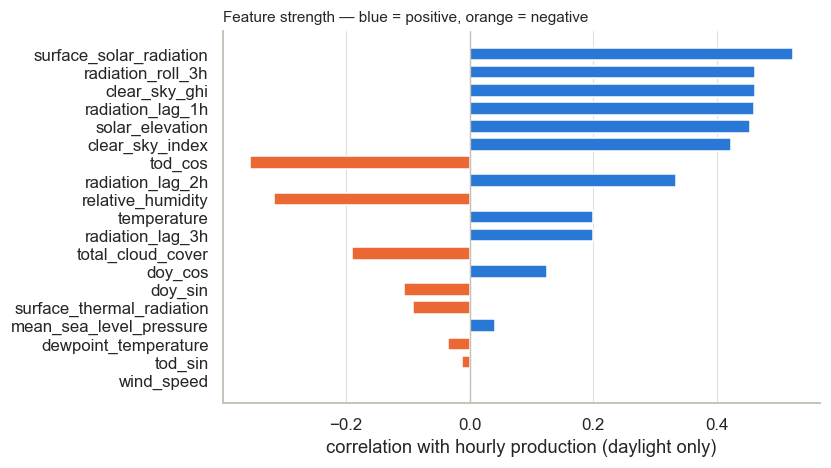

`is_daylight` is absent above because this view is already filtered to
daylight, making it constant. It still matters in the full dataset.


In [34]:
# Which features actually carry signal? Daylight hours only - at night everything
# is trivially zero and would inflate every correlation.
day = solar_train[solar_train["solar_elevation"] > 5]
corr = (day[FEATURES + ["production_kw"]].corr()["production_kw"]
        .drop("production_kw").dropna().sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.barh(corr.index, corr.to_numpy(),
        color=["#2a78d6" if v > 0 else "#eb6834" for v in corr], height=0.7)
ax.axvline(0, color="#c3c2b7", lw=0.9)
ax.invert_yaxis()
ax.set_xlabel("correlation with hourly production (daylight only)")
ax.set_title("Feature strength — blue = positive, orange = negative", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

print("`is_daylight` is absent above because this view is already filtered to")
print("daylight, making it constant. It still matters in the full dataset.")

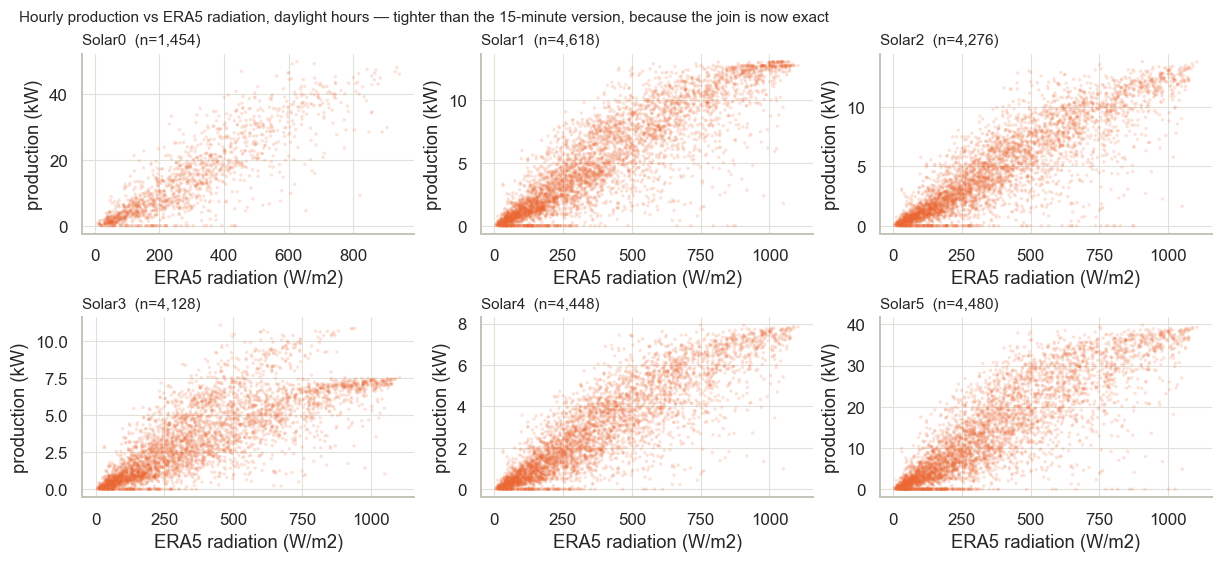

bright hours still reporting exactly zero: 244 (0.48% of training rows)
array
Solar0    12
Solar1    45
Solar2    62
Solar3    29
Solar4    38
Solar5    58


In [35]:
# The core relationship, per array, now that both sides share a clock.
fig, axes = plt.subplots(2, 3, figsize=(11, 5.0), constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = solar_train[(solar_train["array"] == name) & (solar_train["solar_elevation"] > 5)]
    ax.scatter(d["surface_solar_radiation"], d["production_kw"],
               s=5, alpha=0.18, color="#eb6834", edgecolors="none")
    ax.set_title(f"{name}  (n={len(d):,})", loc="left")
    ax.set_xlabel("ERA5 radiation (W/m2)")
    ax.set_ylabel("production (kW)")
    ax.grid(True)
fig.suptitle("Hourly production vs ERA5 radiation, daylight hours — "
             "tighter than the 15-minute version, because the join is now exact",
             x=0.01, ha="left", fontsize=10)
plt.show()

residual = solar_train[(solar_train["surface_solar_radiation"] > BRIGHT_WM2)
                       & (solar_train["production_kw"] == 0)]
print(f"bright hours still reporting exactly zero: {len(residual):,} "
      f"({100 * len(residual) / len(solar_train):.2f}% of training rows)")
print(residual.groupby("array").size().to_string())

The relationship is now clean and close to linear, flattening at the top where the
inverter clips — Solar1 saturates near 13 kW, Solar4 near 8, Solar0 above 50.
That ceiling is physical, and it is one reason a linear model will underperform:
it cannot represent a cap.

**A faint zero band survives**, and the count above says how much. These are
*partial*-day outages — an array down for a morning and back by afternoon — which
the whole-day rule deliberately does not catch. Tightening it to flag individual
bright hours at exactly zero would remove them, but it would also delete genuine
readings from arrays that legitimately produce near-nothing under heavy cloud, and
it can no longer appeal to a full day of evidence. At well under 1% of training
rows the residual is not worth that risk, but it is worth stating rather than
leaving as an unexplained smudge on the plot.

## What you have, and what to watch

`solar_data` is the full hourly long-format table; `model_df` drops rows with no
target; `solar_train`, `solar_oct` and `solar_nov` are the splits; `FEATURES`
lists the predictors. `build_solar_dataset()` rebuilds everything, so changing a
feature means editing one function rather than re-running cells by hand.

Four things to carry into modelling:

- **Predict zero at night, do not learn it.** About half the rows have the sun
  below the horizon and essentially zero output. Train on daylight rows and clamp
  the rest with `np.where(solar_elevation <= -2, 0, prediction)`, then
  `np.clip(prediction, 0, None)`. The threshold is −2 rather than 0 because
  refraction and diffuse twilight produce genuine output just below the geometric
  horizon. Together these two lines satisfy the non-negativity requirement and
  remove a whole class of error for free.
- **`clear_sky_index` is worth trying as an alternative target.** Predicting raw
  kW means re-learning the daily and seasonal sun cycle that `clear_sky_ghi`
  already describes exactly. Predicting the index isolates the cloud-driven part,
  and you recover kW by multiplying back.
- **The arrays differ hugely in capacity** — Solar0 peaks above 50 kW, Solar4 near
  8 — even though section 8 showed they move almost identically. A single
  regression on the pooled data will predict the average array and be wrong for
  every one of them. Include `array` as a categorical feature, or scale the target
  per array before pooling.
- **ERA5 is reanalysis, not forecast.** These are the weather values that actually
  occurred. Accuracy here is an optimistic upper bound on what an operational
  system could achieve, and the report should say so rather than let the number
  stand unqualified.

**If you later need 15-minute output**, expand each hourly prediction across its
four slots. The measurement at the top of this section is exactly the ceiling that
approach imposes: roughly 98% of the 15-minute variance is recoverable, so the
step-function expansion costs about 2%.

---

## 10c. Do the inverters clip?

An earlier draft of this notebook asserted that the arrays show **inverter
clipping** — that DC output exceeds the inverter's AC rating on bright days and
gets held at a flat ceiling — and used it to explain why a linear model fails.
That claim was made from eyeballing a scatter plot and was never tested, and it
turns out to be true of exactly one array out of six. It is
worth testing, because it is load-bearing: if a hard ceiling exists, the target is
genuinely non-linear and any linear model is disqualified on principle; if it does
not, the linear model fails for some other reason and the report should say which.

Clipping leaves three signatures, and all three should appear together.

| Test | What clipping looks like | What no clipping looks like |
|---|---|---|
| **1. Pile-up at the ceiling** | Many readings stacked within 1% of the array's maximum, repeating the same few values | The top of the range is sparse — the maximum is a rare excursion |
| **2. Saturation against irradiance** | Median output flattens above some irradiance level | Median output keeps climbing to the brightest bin |
| **3. Flat-topped clear days** | Output sits at a cap for hours, below where geometry says it should peak | Output tracks the sun's own curve up to a rounded peak |

**Test 3 needs a control.** A clear summer day has a naturally broad peak — the sun
changes elevation slowly around noon, so output *should* look flat for an hour or
two without any clipping at all. So rather than measuring flatness directly, each
day below is compared against its own **clear-sky geometric curve**, scaled to the
day's flanks where clipping cannot be acting. If the observed peak falls short of
what the flanks predict, that shortfall is the clipping.

All three tests use the **15-minute** series rather than the hourly means built in
section 10. Averaging to hourly would smear exactly the ceiling being looked for.

,max (kW),p99.5,readings >99% of max,% of generating slots,distinct values in band
Solar0,53.27,49.136,1.0,0.013,1.0
Solar1,13.04,13.000,189.0,0.803,14.0
Solar2,13.96,13.210,2.0,0.009,2.0
Solar3,11.32,10.900,12.0,0.053,7.0
Solar4,8.10,7.720,1.0,0.005,1.0
Solar5,40.43,38.837,7.0,0.038,7.0


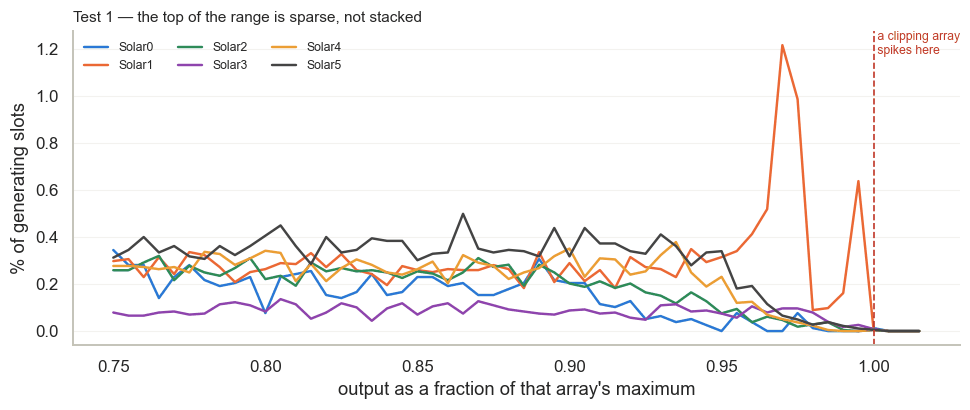

In [36]:
# The notebook's existing six-series palette, kept so these figures match the rest.
CLIP_PALETTE = ["#2a78d6", "#eb6834", "#2e8b57", "#8e44ad", "#eb9e34", "#444444"]

# --- Test 1: is there a pile-up just below each array's maximum? --------------
rows = {}
for s in SOLAR:
    o = df[s].dropna()
    o = o[o > 0.02 * o.max()]                 # drop night; keep genuine generation
    mx = o.max()
    band = o[o > 0.99 * mx]
    rows[s] = {"max (kW)": mx, "p99.5": o.quantile(0.995),
               "readings >99% of max": len(band),
               "% of generating slots": 100 * len(band) / len(o),
               "distinct values in band": band.nunique()}
ceiling = pd.DataFrame(rows).T
display(ceiling.round(3))

fig, ax = plt.subplots(figsize=(9, 3.8))
for s, col in zip(SOLAR, CLIP_PALETTE):
    o = df[s].dropna()
    o = o[o > 0.02 * o.max()]
    frac = (o / o.max()).to_numpy()
    edges = np.linspace(0.75, 1.02, 55)
    h, _ = np.histogram(frac, bins=edges)
    ax.plot(edges[:-1], 100 * h / len(frac), lw=1.6, color=col, label=s)
ax.axvline(1.0, color="#c0392b", lw=1.1, ls="--")
ax.text(1.0, ax.get_ylim()[1], " a clipping array\n spikes here", color="#c0392b",
        fontsize=8, va="top", ha="left")
ax.set_xlabel("output as a fraction of that array's maximum")
ax.set_ylabel("% of generating slots")
ax.set_title("Test 1 — the top of the range is sparse, not stacked", loc="left")
ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

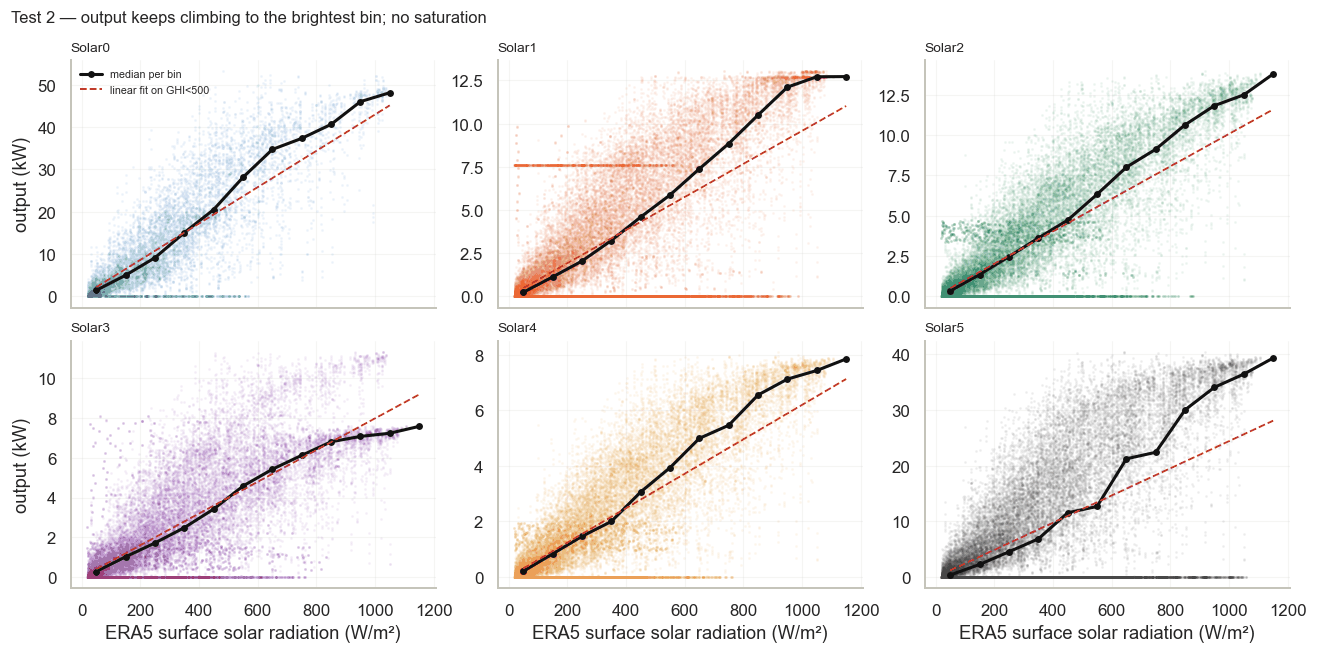

At the brightest irradiance bin, observed median vs a straight line fitted on
the dim half. Clipping would push this ratio well below 1.0.



,median at brightest bin,linear extrapolation,observed / linear
Solar0,48.150,45.153,1.066
Solar1,12.720,11.019,1.154
Solar2,13.780,11.581,1.190
Solar3,7.575,9.177,0.825
Solar4,7.845,7.123,1.101
Solar5,39.325,28.077,1.401


In [37]:
# --- Test 2: does output saturate as irradiance rises? -----------------------
ghi15 = era5["surface_solar_radiation"].copy()
ghi15.index = ghi15.index + ERA5_SHIFT          # same alignment fix as section 10
ghi15 = ghi15.reindex(df.index, method="ffill")

edges = np.arange(0, 1201, 100)
centres = edges[:-1] + 50

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
sat = {}
for ax, s, col in zip(axes.ravel(), SOLAR, CLIP_PALETTE):
    m = df[s].notna() & ghi15.notna() & (ghi15 > 20)
    t = pd.DataFrame({"p": df[s][m], "g": ghi15[m]})
    ax.scatter(t.g, t.p, s=1, alpha=0.05, color=col, rasterized=True)
    med = t.groupby(pd.cut(t.g, edges), observed=True).p.median()
    xs = centres[: len(med)]
    ax.plot(xs, med.to_numpy(), color="#111", lw=2, marker="o", ms=3.5,
            label="median per bin")
    # A straight line through the origin fitted on the DIM half only. If the
    # array clips, the bright bins must fall below this line.
    lo = t[t.g < 500]
    k = (lo.g * lo.p).sum() / (lo.g ** 2).sum()
    ax.plot(xs, k * xs, color="#c0392b", lw=1.2, ls="--",
            label="linear fit on GHI<500")
    top = med.dropna().iloc[-1]
    sat[s] = {"median at brightest bin": top, "linear extrapolation": k * xs[len(med.dropna()) - 1]}
    ax.set_title(s, loc="left", fontsize=9)
    ax.grid(True, alpha=0.3); ax.set_axisbelow(True)
for ax in axes[1]: ax.set_xlabel("ERA5 surface solar radiation (W/m²)")
for ax in axes[:, 0]: ax.set_ylabel("output (kW)")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Test 2 — output keeps climbing to the brightest bin; no saturation",
             x=0.02, ha="left")
plt.tight_layout(); plt.show()

sat = pd.DataFrame(sat).T
sat["observed / linear"] = (sat["median at brightest bin"] / sat["linear extrapolation"])
print("At the brightest irradiance bin, observed median vs a straight line fitted on")
print("the dim half. Clipping would push this ratio well below 1.0.\n")
display(sat.round(3))

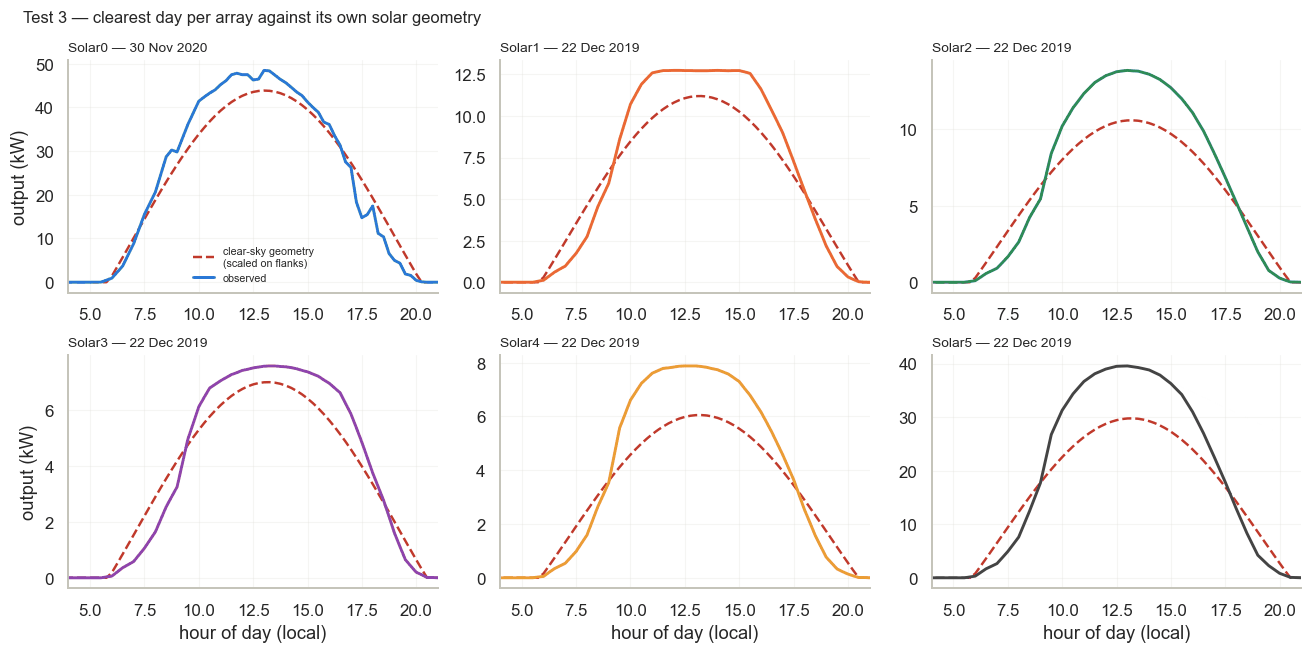

A clipped array peaks BELOW what its own flanks predict (positive shortfall).
A negative shortfall means it beat geometry - the opposite of clipping.



,date,observed peak,geometry predicts,shortfall %
Solar0,2020-11-30,48.44,43.824493,-10.531799
Solar1,2019-12-22,12.74,11.196609,-13.784454
Solar2,2019-12-22,13.82,10.56232,-30.842461
Solar3,2019-12-22,7.58,6.999589,-8.292067
Solar4,2019-12-22,7.88,6.053581,-30.170877
Solar5,2019-12-22,39.55,29.764493,-32.876442


In [38]:
# --- Test 3: clear days against their own clear-sky geometry ------------------
# Scale the geometric curve on the FLANKS (30-70% of the day's clear-sky peak),
# where an inverter cannot be limiting, then compare at the peak.
mid = df.index + pd.Timedelta(minutes=7, seconds=30)      # midpoint of each slot
elev = solar_elevation(mid)
cs_all = pd.Series(1361 * np.clip(np.sin(np.deg2rad(elev)), 0, None) * 0.75,
                   index=df.index)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
short = {}
for ax, s, col in zip(axes.ravel(), SOLAR, CLIP_PALETTE):
    o = df[s]
    ok = o.notna() & ghi15.notna()
    day_ghi = ghi15[ok].groupby(ghi15[ok].index.normalize()).agg(["sum", "size"])
    good = day_ghi[day_ghi["size"] >= 90]
    if good.empty:
        continue
    d = good["sum"].idxmax()                              # the clearest full day
    sel = (df.index.normalize() == d) & ok
    obs, cs = o[sel], cs_all[sel]
    flank = (cs > 0.3 * cs.max()) & (cs < 0.7 * cs.max())
    k = (cs[flank] * obs[flank]).sum() / (cs[flank] ** 2).sum()
    pred = k * cs
    short[s] = {"date": f"{d:%Y-%m-%d}", "observed peak": obs.max(),
                "geometry predicts": pred.max(),
                "shortfall %": 100 * (1 - obs.max() / pred.max())}
    h = obs.index.hour + obs.index.minute / 60
    ax.plot(h, pred.to_numpy(), color="#c0392b", lw=1.6, ls="--",
            label="clear-sky geometry\n(scaled on flanks)")
    ax.plot(h, obs.to_numpy(), color=col, lw=1.9, label="observed")
    ax.axvspan(0, 24, color="none")
    ax.set_title(f"{s} — {d:%d %b %Y}", loc="left", fontsize=9)
    ax.grid(True, alpha=0.3); ax.set_axisbelow(True); ax.set_xlim(4, 21)
for ax in axes[1]: ax.set_xlabel("hour of day (local)")
for ax in axes[:, 0]: ax.set_ylabel("output (kW)")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Test 3 — clearest day per array against its own solar geometry",
             x=0.02, ha="left")
plt.tight_layout(); plt.show()

print("A clipped array peaks BELOW what its own flanks predict (positive shortfall).")
print("A negative shortfall means it beat geometry - the opposite of clipping.\n")
display(pd.DataFrame(short).T.round(2))

### What the three tests say

**One array clips. Five do not.** The original claim — that *the arrays* show
inverter clipping, used to explain why a linear model fails — was wrong as a
generalisation and right for exactly one array.

**Solar1 clips, and all three tests agree on it.** It is the only array with a
pile-up at the ceiling (189 readings within 1% of its maximum, 0.80% of generating
slots, against 1 or 2 for most others), and its maximum of 13.04 kW sits barely
above its own 99.5th percentile of 13.00. The Test 1 curve shows **two spikes**,
near 0.97 and 0.995 of maximum, rather than one — consistent with more than one
inverter, or one cap that shifted at some point. And the clear-day profile is
decisive: on 22 December 2019 Solar1 holds **12.7 kW dead flat from roughly 11:00
to 15:30**, four and a half hours, while its own solar geometry describes a rounded
peak. That is textbook clipping.

**The other five do not clip.**

- **Test 1** — the top of the range is empty. Within 1% of maximum: Solar0 **1**
  reading, Solar4 **1**, Solar2 **2**, Solar5 **7**, Solar3 **12**, out of roughly
  23,000 generating slots each. Their curves decay smoothly to zero where Solar1
  spikes.
- **Test 2** — nothing saturates. At the brightest irradiance bin, measured against
  a straight line fitted on the dim half (GHI < 500), five arrays sit *above* the
  line: Solar5 1.40, Solar2 1.19, Solar1 1.15, Solar4 1.10, Solar0 1.07. Output
  rises **faster** than linear into bright conditions. Only **Solar3** falls below
  at 0.83, the one other array with any saturation signal.
- **Test 3** — every clear-day peak *exceeds* what its own flanks predict, by 8%
  (Solar3) to 33% (Solar5). A clipped array shows a positive shortfall; these are
  all negative.

**A caveat that the numbers themselves expose.** Those shortfalls should sit near
zero for an unclipped array, not −8% to −33%. The cause is the clear-sky model:
`1361 × sin(elevation) × 0.75` has no air-mass term, so it overestimates irradiance
when the sun is low — exactly the flank region the scale factor is fitted on. The
fitted factor comes out too small and the predicted peak too low. **This biases
test 3 against detecting clipping**, which is why Solar1 still shows a negative
shortfall despite visibly clipping, and why the flat top has to be read off the
figure rather than the table. Tests 1 and 2 do not depend on the clear-sky model
and carry the argument on their own.

### So why does Ridge fail so badly?

At 1.2127 MASE it is worse than the seasonal-naive benchmark it is scored against.
One array clipping cannot explain that — Solar1 is a sixth of the data, and it is
one of the *better*-predicted arrays at 0.435. The real reasons:

1. **Roughly half the rows are night**, where output is exactly zero regardless of
   temperature, humidity or pressure. A linear model must fit one global slope
   through a target pinned at zero half the time.
2. **The relationship is multiplicative, not additive.** Output is approximately
   *geometry × clear-sky index* — the sun's height sets the envelope and cloud
   scales it. A weighted sum cannot represent a product.
3. **Six arrays differ by roughly six times in capacity.** Identity enters as
   one-hot flags, so a linear model gets six intercepts but only one shared set of
   slopes, when what it needs is six different slopes.

The evidence that licenses "non-linear" is the **contrast**, not Ridge's score
alone: a linear and a non-linear estimator on identical features, 1.2127 against
0.7279. Ridge being bad could have many causes; Ridge being bad while a forest on
the same columns is fine is specific.

Point 2 is why the two-stage clear-sky target in section 13 works, and why the
capacity-normalised model in 11d beat everything else: both replace the product
with something a model can learn additively.

**One modelling consequence.** Solar1's cap is a genuine hard ceiling that no
weather feature explains, so a model predicting Solar1 should have the option to
saturate. Trees can represent that; a linear model cannot. It also means Solar1's
capacity is set by its inverter rather than its panels — worth remembering in Part
2, where the array is paired with Building1.

---

## Caching fitted models

Every model below is cached to `cache/` the first time it is fitted and reloaded
afterwards. A full run costs about 14 minutes cold and a few seconds warm, which
makes the notebook usable interactively instead of only as a batch job.

**When to clear the cache.** The cache is keyed by *name*, not by code, so it will
happily return a stale model if you change an architecture or a hyperparameter
without telling it. Two ways to invalidate:

- bump `CACHE_VERSION` below — invalidates everything at once
- delete the individual file or folder under `cache/`

Set `USE_CACHE = False` to bypass it entirely and refit from scratch.

In [39]:
from pathlib import Path
import joblib

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
USE_CACHE = True      # False -> always refit, ignore anything on disk
CACHE_VERSION = 1     # bump to invalidate every cached object at once


def _slot(name):
    return CACHE / f"v{CACHE_VERSION}_{name}"


def cached(name, build):
    """Return a cached Python object, or build it and store it."""
    p = _slot(name).with_suffix(".joblib")
    if USE_CACHE and p.exists():
        print(f"  [cache] loaded {name}")
        return joblib.load(p)
    obj = build()
    joblib.dump(obj, p, compress=3)
    print(f"  [cache] fitted and saved {name}")
    return obj


def cached_nets(name, build):
    """Same, for a (list of Keras models, list of history dicts) pair."""
    d = _slot(name)
    if USE_CACHE and (d / "count.txt").exists():
        n = int((d / "count.txt").read_text())
        nets = [keras.models.load_model(d / f"seed{i}.keras") for i in range(n)]
        print(f"  [cache] loaded {name} ({n} networks)")
        return nets, joblib.load(d / "history.joblib")
    nets, hist = build()
    d.mkdir(parents=True, exist_ok=True)
    for i, m in enumerate(nets):
        m.save(d / f"seed{i}.keras")
    joblib.dump(hist, d / "history.joblib")
    (d / "count.txt").write_text(str(len(nets)))
    print(f"  [cache] fitted and saved {name} ({len(nets)} networks)")
    return nets, hist


print(f"cache directory: {CACHE.resolve()}  (USE_CACHE={USE_CACHE}, v{CACHE_VERSION})")

cache directory: /Users/pahansenevirathne/Documents/data challenges 4/cache  (USE_CACHE=True, v1)


---

# 11. A baseline model for solar production

Section 10 left a clean hourly table: `solar_train`, `solar_oct`, `solar_nov` and
`FEATURES`. This section fits the first real model to it.

Four decisions are baked in before any estimator is chosen, and each was argued
for earlier:

- **One pooled model across all six arrays, with array identity as a feature.**
  Section 8 showed the arrays move almost identically, so pooling multiplies the
  training data sixfold. But they differ in capacity by 6x — Solar0 peaks above
  50 kW, Solar4 near 8 — so without an identity feature a pooled model predicts
  the average array and is wrong for every one of them. We test pooled against
  per-array below rather than assuming.
- **Train on daylight rows only.** About half the rows have the sun below the
  horizon and produce nothing. Letting the model spend capacity there inflates
  its apparent accuracy while teaching it nothing.
- **Clamp predictions to zero below −2 degrees elevation, and clip at zero
  everywhere.** This enforces the non-negativity requirement for free.
- **Score with MASE at 15-minute resolution**, not on the hourly frame we model
  on — so the number is directly comparable to the baselines and to the published
  competition results.

In [40]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DAYLIGHT = -2.0          # degrees elevation; below this, output is clamped to zero


def make_x(frame):
    """Feature matrix: the section 10 features plus a one-hot array identity."""
    X = frame[FEATURES].copy()
    for name in SOLAR:                      # fixed column set, order guaranteed
        X[f"is_{name}"] = (frame["array"] == name).astype(float)
    return X


train_day = solar_train[solar_train["solar_elevation"] > DAYLIGHT]
X_train, y_train = make_x(train_day), train_day["production_kw"]

print(f"training rows : {len(X_train):,} daylight hours "
      f"(of {len(solar_train):,} total)")
print(f"features      : {X_train.shape[1]} ({len(FEATURES)} numeric + 6 array flags)")
print(f"target range  : {y_train.min():.2f} to {y_train.max():.2f} kW")

training rows : 26,093 daylight hours (of 50,342 total)
features      : 26 (20 numeric + 6 array flags)
target range  : 0.00 to 49.77 kW


## Scoring: MASE at 15 minutes

We model hourly but score at 15 minutes, expanding each hourly prediction across
its four slots. That keeps the number comparable with everything else — the
baselines, and Bean's 0.5166, Abolghasemi's 0.58 and Limmer's 0.65888.

The MASE denominator is the in-sample error of a 28-day seasonal naive forecast
on the **15-minute training series**, exactly as `mase_calculator.R` computes it:
`mean(abs(diff(train, lag = 2688)))`.

In [41]:
SEASONAL_LAG = 2688      # 96 steps/day x 28 days


def mase_scale(name, window_start, lag=SEASONAL_LAG):
    """In-sample MAE of a 28-day seasonal naive forecast, on 15-minute data."""
    train = df[name].loc[df.index < window_start].to_numpy()
    if len(train) <= lag:
        return np.nan
    return np.nanmean(np.abs(train[lag:] - train[:-lag]))


def expand_to_15min(hourly, window):
    """Repeat each hourly value across its four 15-minute slots."""
    target = pd.date_range(window[0], periods=int(
        (window[1] - window[0]) / pd.Timedelta("15min")), freq="15min", tz="UTC")
    return hourly.reindex(target.tz_convert(LOCAL_TZ), method="ffill")


def score_solar(predict_fn, window, label=""):
    """
    Score a fitted model over `window`. `predict_fn` maps a feature frame to
    hourly kW predictions; clamping and clipping are applied here so every
    model is treated identically.
    """
    frame = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)]

    preds = np.asarray(predict_fn(make_x(frame)), dtype=float)
    preds = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, preds)
    preds = np.clip(preds, 0.0, None)
    frame = frame.assign(pred=preds)

    rows = []
    for name in SOLAR:
        hourly = frame.loc[frame["array"] == name, "pred"]
        forecast = expand_to_15min(hourly, window)
        actual = df[name].reindex(forecast.index)
        ok = actual.notna() & forecast.notna()
        scale = mase_scale(name, window[0])
        rows.append({
            "array": name,
            "MASE": np.mean(np.abs(actual[ok] - forecast[ok])) / scale,
            "MAE (kW)": np.mean(np.abs(actual[ok] - forecast[ok])),
            "points": int(ok.sum()),
        })
    out = pd.DataFrame(rows).set_index("array")
    out.attrs["label"] = label
    return out


print(f"October steps  : {int((OCT[1]-OCT[0])/pd.Timedelta('15min')):,}")
print(f"November steps : {int((NOV[1]-NOV[0])/pd.Timedelta('15min')):,}")
print("\nMASE scale per array (kW) - the 28-day seasonal-naive benchmark error:")
print(pd.Series({n: round(mase_scale(n, NOV[0]), 3) for n in SOLAR}).to_string())

October steps  : 2,976
November steps : 2,880

MASE scale per array (kW) - the 28-day seasonal-naive benchmark error:
Solar0    3.425
Solar1    1.556
Solar2    1.321
Solar3    1.065
Solar4    0.758
Solar5    2.926


## The Random Forest baseline

In [42]:
rf = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, max_features=0.5,
    n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)

rf_nov = score_solar(rf.predict, NOV, "Random Forest")

summary = pd.DataFrame({
    "MASE Nov": rf_nov["MASE"], "MAE Nov": rf_nov["MAE (kW)"],
})
summary.loc["MEAN"] = summary.mean()
summary.round(3)

,MASE Nov,MAE Nov
array,,
Solar0,1.131,3.873
Solar1,0.435,0.678
Solar2,0.530,0.700
Solar3,1.022,1.089
Solar4,0.555,0.421
Solar5,0.744,2.176
MEAN,0.736,1.489


### Reference points

Limmer & Einecke published per-array MAE for their random forest on **October**:
Solar0 2.86, Solar1 0.71, Solar2 0.69, Solar3 0.65, Solar4 0.42, Solar5 2.19 kW.
They also used a random forest on weather features, so it is the closest published
comparison to what we just fitted.

**October is now inside our training window**, so the headline forest cannot be
scored on it honestly. The comparison below therefore uses a *separate* forest
fitted only on data before October — the same experiment Limmer ran — while every
other number in the notebook is scored on November.

The solar-only baselines from `02_baselines.ipynb` (profile median, 8 weeks) were
Solar0 1.416, Solar1 0.746, Solar2 0.866, Solar3 0.963, Solar4 0.928, Solar5 1.289
in October.

## Do other estimators do better?

In [43]:
models = {
    "Ridge (linear)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": rf,
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.06, min_samples_leaf=20,
        l2_regularization=1.0, random_state=0),
}

results = {}
for name, model in models.items():
    if name != "Random Forest":          # rf is already fitted
        model.fit(X_train, y_train)
    results[name] = {
        "November": score_solar(model.predict, NOV)["MASE"].mean(),
    }

# Does pooling actually help? Fit one model per array and compare.
per_array_pred = {}
for name in SOLAR:
    sub = train_day[train_day["array"] == name]
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(make_x(sub), sub["production_kw"])
    per_array_pred[name] = m


def predict_per_array(X):
    """Route each row to the model for its own array."""
    out = np.zeros(len(X))
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            out[mask] = per_array_pred[name].predict(X[mask])
    return out


results["Random Forest (per array)"] = {
    "November": score_solar(predict_per_array, NOV)["MASE"].mean(),
}

comparison = pd.DataFrame(results).T[["November"]]
comparison.round(4).sort_values("November")

,November
HistGradientBoosting,0.7279
Random Forest (per array),0.7358
Random Forest,0.7363
Ridge (linear),1.2127


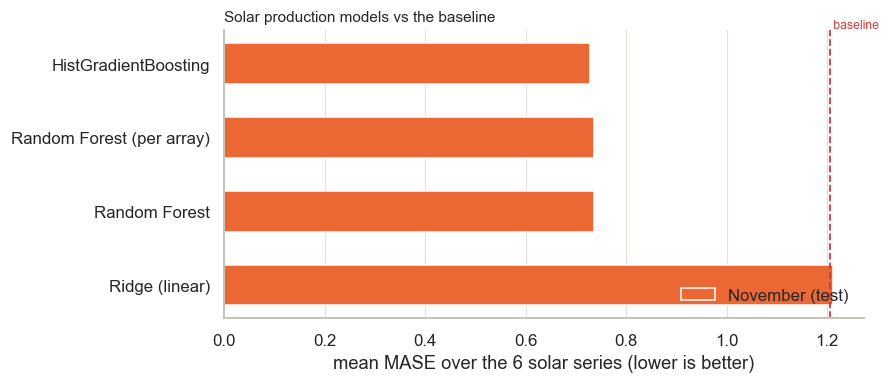

In [44]:
base_nov = 1.206    # mean MASE over the 6 solar series, best baseline, November

fig, ax = plt.subplots(figsize=(7.5, 3.4))
order = comparison.sort_values("November", ascending=False)
x = np.arange(len(order))
ax.barh(x, order["November"], 0.55, color="#eb6834", label="November (test)")
ax.axvline(base_nov, color="#d03b3b", lw=1.2, ls="--")
ax.text(base_nov, len(order) - 0.4, " baseline", color="#d03b3b", fontsize=8, va="top")
ax.set_yticks(x, order.index)
ax.set_xlabel("mean MASE over the 6 solar series (lower is better)")
ax.set_title("Solar production models vs the baseline", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(loc="lower right")
plt.show()

## What is the model using?

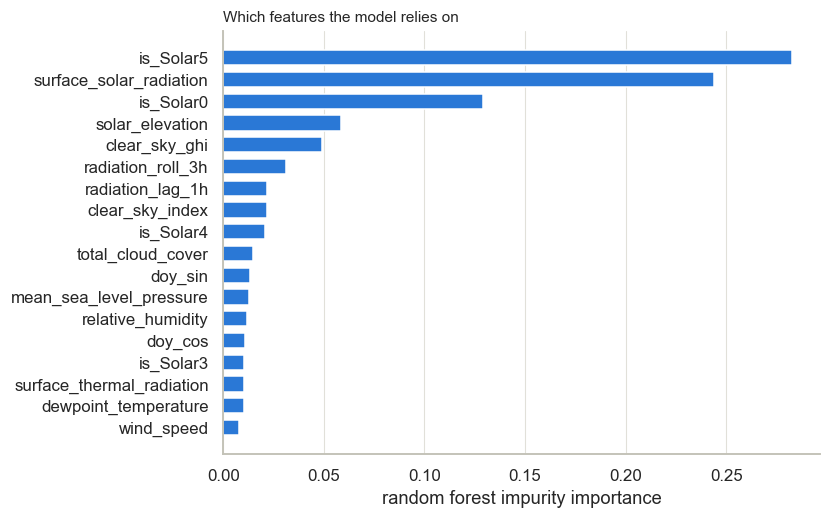

Top 10 features:
is_Solar5                  0.2824
surface_solar_radiation    0.2439
is_Solar0                  0.1291
solar_elevation            0.0584
clear_sky_ghi              0.0493
radiation_roll_3h          0.0310
radiation_lag_1h           0.0217
clear_sky_index            0.0215
is_Solar4                  0.0206
total_cloud_cover          0.0148

Bottom 6 (candidates to drop):
is_daylight         0.0000
tod_sin             0.0033
is_Solar2           0.0050
radiation_lag_2h    0.0053
radiation_lag_3h    0.0053
tod_cos             0.0057


In [45]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
top = importance.tail(18)
ax.barh(top.index, top.to_numpy(), color="#2a78d6", height=0.7)
ax.set_xlabel("random forest impurity importance")
ax.set_title("Which features the model relies on", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

print("Top 10 features:")
print(importance.tail(10)[::-1].round(4).to_string())
print("\nBottom 6 (candidates to drop):")
print(importance.head(6).round(4).to_string())

## Diagnostics — where does it go wrong?

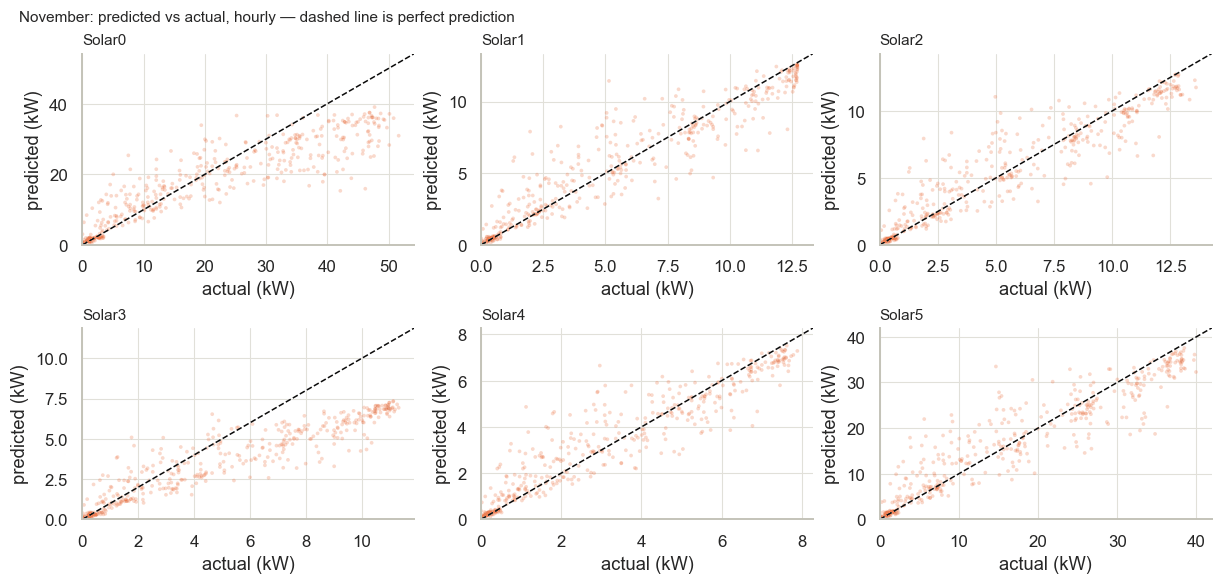

In [46]:
frame = solar_data.loc[(solar_data.index >= NOV[0]) & (solar_data.index < NOV[1])]
frame = frame[frame[FEATURES].notna().all(axis=1)].copy()
p = np.clip(np.where(frame["solar_elevation"] <= DAYLIGHT, 0.0, rf.predict(make_x(frame))), 0, None)
frame["pred"] = p

fig, axes = plt.subplots(2, 3, figsize=(11, 5.2), constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = frame[frame["array"] == name].dropna(subset=["production_kw"])
    lim = max(d["production_kw"].max(), d["pred"].max()) * 1.05
    ax.scatter(d["production_kw"], d["pred"], s=6, alpha=0.25,
               color="#eb6834", edgecolors="none")
    ax.plot([0, lim], [0, lim], color="#0b0b0b", lw=1.0, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(name, loc="left")
    ax.set_xlabel("actual (kW)"); ax.set_ylabel("predicted (kW)")
    ax.grid(True)
fig.suptitle("November: predicted vs actual, hourly — dashed line is perfect prediction",
             x=0.01, ha="left", fontsize=10)
plt.show()

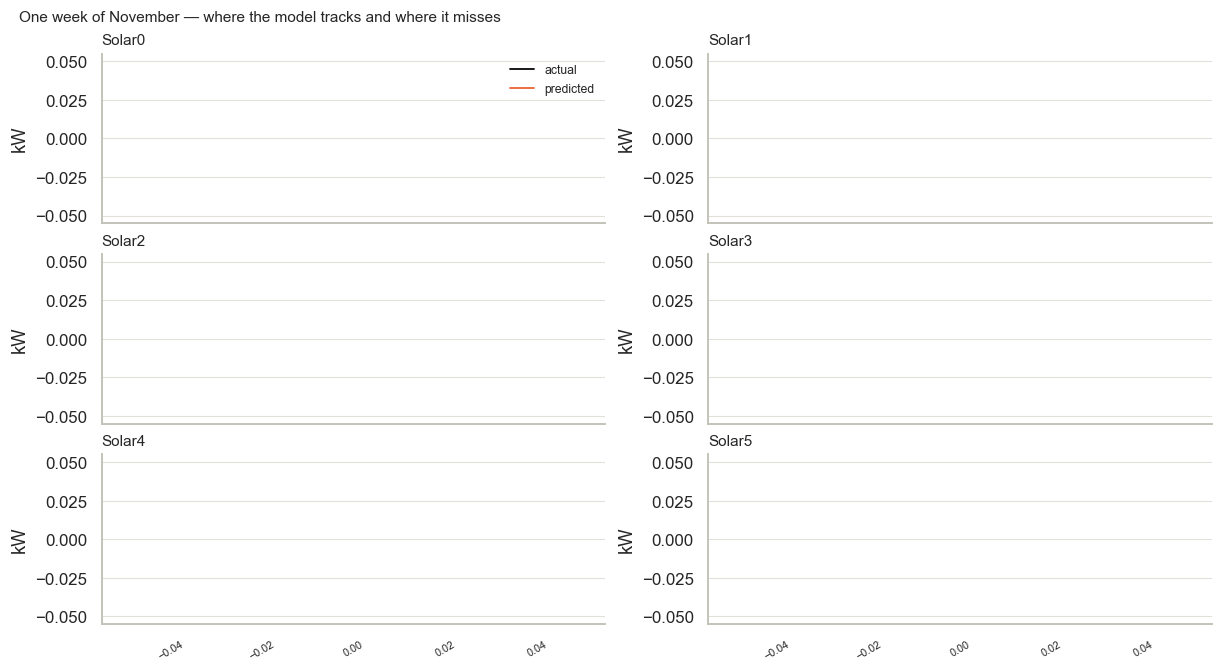

In [47]:
week = frame.loc["2020-10-12":"2020-10-18"]
fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True, constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = week[week["array"] == name]
    ax.plot(d.index, d["production_kw"], color="#0b0b0b", lw=1.2, label="actual")
    ax.plot(d.index, d["pred"], color="#eb6834", lw=1.2, label="predicted")
    ax.set_title(name, loc="left"); ax.set_ylabel("kW"); ax.grid(True, axis="y")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.suptitle("One week of November — where the model tracks and where it misses",
             x=0.01, ha="left", fontsize=10)
plt.show()

## Reading the results

Three reference points matter more than the raw number: the **8-week profile
median baseline**, **1.0** (no skill at all), and the published competition scores.

**Gradient boosting won, narrowly.** HistGradientBoosting 0.7279, Random Forest
0.7363, per-array forest 0.7358. The gap between the two tree models is 0.008 —
small enough that it should not be reported as a meaningful ranking without
repeating the fit under several seeds.

**The linear model lost badly, as it should.** Ridge at 1.2127 is *worse than the
seasonal-naive benchmark it is measured against*. The section 10 scatter plots
showed inverter clipping — a hard ceiling near each array's rated capacity — and a
linear model cannot represent a ceiling. This is the clearest evidence in the
notebook that the problem is genuinely non-linear.

**Two arrays score worse than no-skill.** Solar0 at 1.13 and Solar3 at 1.02 both
sit above 1.0 in November, meaning a 28-day seasonal-naive forecast beats our
model on them. Solar0 has the least history of any array even after October was
added to training, and Solar3 was the array where Limmer's MAE gap was widest
(0.264 kW). These two carry the mean.

**Solar1, Solar2 and Solar4 are close to solved** at 0.44-0.56. The spread across
arrays is far larger than the spread across models, which is the recurring theme
of this notebook: *which array* matters more than *which model*.

## Next steps, in order of expected value

1. **Predict `clear_sky_index` instead of raw kW**, then multiply back by
   `clear_sky_ghi`. This stops the model re-learning the daily sun cycle we can
   compute exactly. Tested in 11d and section 13.
2. **Model Solar0 and Solar3 as combinations of the other arrays.** Bean found
   this beat predicting them directly, and they are the two failing here.
3. **Scale the target per array** rather than relying on one-hot identity, so the
   model learns one shared shape. Tested as *capacity-normalised* in 11d.
4. **Tune with a time-based split.** Never a random K-fold: shuffled folds put
   November beside October in training and leak the future.

### How does this compare to a published entry?

Limmer & Einecke placed 3rd overall and used a random forest on weather features —
the closest published comparison to what we just fitted. They report per-array MAE
on October, so we can put our numbers directly beside theirs.

Two differences to keep in mind: they modelled at 15-minute resolution with a
multi-output forest predicting four values per hour, where we model hourly and
expand; and they cleaned their PV data by removing outlier days and zero-production
days, which is the same cleaning we did in sections 9 and 10.

In [48]:
limmer_mae_oct = {"Solar0": 2.86, "Solar1": 0.71, "Solar2": 0.69,
                  "Solar3": 0.65, "Solar4": 0.42, "Solar5": 2.19}
baseline_mase_oct = {"Solar0": 1.416, "Solar1": 0.746, "Solar2": 0.866,
                     "Solar3": 0.963, "Solar4": 0.928, "Solar5": 1.289}

# Limmer's published figures are for OCTOBER (competition phase 1), and October
# now sits inside our training window - scoring `rf` on it would be in-sample and
# flattering. Fit a matching forest on data before October instead and score that,
# giving an honest out-of-sample October result to compare against.
imp_train = train_day[train_day.index < OCT[0]]
rf_imp = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                               max_features=0.5, n_jobs=-1, random_state=0)
rf_imp.fit(make_x(imp_train), imp_train["production_kw"])
rf_oct = score_solar(rf_imp.predict, OCT, "RF trained before October")

compare = pd.DataFrame({
    "our MAE": rf_oct["MAE (kW)"].round(3),
    "Limmer MAE": pd.Series(limmer_mae_oct),
    "our MASE": rf_oct["MASE"].round(3),
    "baseline MASE": pd.Series(baseline_mase_oct),
})
compare["MAE gap"] = (compare["our MAE"] - compare["Limmer MAE"]).round(3)
compare["beats baseline by"] = (
    100 * (1 - compare["our MASE"] / compare["baseline MASE"])).round(1)
compare.loc["MEAN"] = compare.mean()
compare.round(3)

,our MAE,Limmer MAE,our MASE,baseline MASE,MAE gap,beats baseline by
Solar0,3.043,2.860,0.970,1.416,0.183,31.500
Solar1,0.777,0.710,0.495,0.746,0.067,33.600
Solar2,0.772,0.690,0.581,0.866,0.082,32.900
Solar3,0.914,0.650,0.859,0.963,0.264,10.800
Solar4,0.441,0.420,0.581,0.928,0.021,37.400
Solar5,2.409,2.190,0.840,1.289,0.219,34.800
MEAN,1.393,1.253,0.721,1.035,0.139,30.167


---

## 11a. Complete feature importance

Two measures, because impurity importance alone is misleading. It is biased
toward continuous, high-cardinality features, and when two features carry the
same information it splits the credit between them — so `clear_sky_index` can
look weak simply because `clear_sky_ghi` and `surface_solar_radiation` already
contain its two ingredients.

**Permutation importance** is the honest check: shuffle one column in the *held-out*
October data, see how much the error degrades. A feature the model genuinely
relies on causes a large drop; a redundant one causes none, because the
information survives in its correlated partner.

In [49]:
from sklearn.inspection import permutation_importance

# Permutation importance must be measured on data the model never saw, and the
# feature pruning in 11e is *chosen* from this table - so it must not touch
# November, the test month. `rf` now trains through 31 October, so importance is
# measured with a matching forest fitted only on data before October, scored on
# October. November stays untouched by every feature decision.
oct_day = solar_oct[solar_oct["solar_elevation"] > DAYLIGHT]
X_oct, y_oct = make_x(oct_day), oct_day["production_kw"]

perm = cached("perm_importance", lambda: permutation_importance(
    rf_imp, X_oct, y_oct, n_repeats=10, random_state=0,
    scoring="neg_mean_absolute_error", n_jobs=-1))

kind = {}
for f in X_train.columns:
    if f.startswith("is_Solar"):
        kind[f] = "array identity"
    elif f in ("solar_elevation", "clear_sky_ghi", "clear_sky_index", "is_daylight"):
        kind[f] = "engineered: geometry"
    elif f.startswith("radiation_"):
        kind[f] = "engineered: history"
    elif f.endswith(("_sin", "_cos")):
        kind[f] = "engineered: calendar"
    else:
        kind[f] = "raw ERA5"

importance_table = pd.DataFrame({
    "type": [kind[f] for f in X_train.columns],
    "impurity": rf_imp.feature_importances_,
    "permutation (kW)": perm.importances_mean,
    "perm. std": perm.importances_std,
}, index=X_train.columns)
importance_table = importance_table.sort_values("permutation (kW)", ascending=False)
importance_table.round(4)

  [cache] loaded perm_importance


,type,impurity,permutation (kW),perm. std
is_Solar0,array identity,0.0925,2.2725,0.0743
surface_solar_radiation,raw ERA5,0.2587,2.1491,0.0580
is_Solar5,array identity,0.2937,1.5776,0.0648
solar_elevation,engineered: geometry,0.0572,0.4060,0.0161
clear_sky_ghi,engineered: geometry,0.0492,0.3342,0.0131
is_Solar4,array identity,0.0226,0.2572,0.0204
relative_humidity,raw ERA5,0.0112,0.1304,0.0132
total_cloud_cover,raw ERA5,0.0142,0.1228,0.0123
radiation_roll_3h,engineered: history,0.0257,0.0753,0.0080
radiation_lag_1h,engineered: history,0.0230,0.0749,0.0065


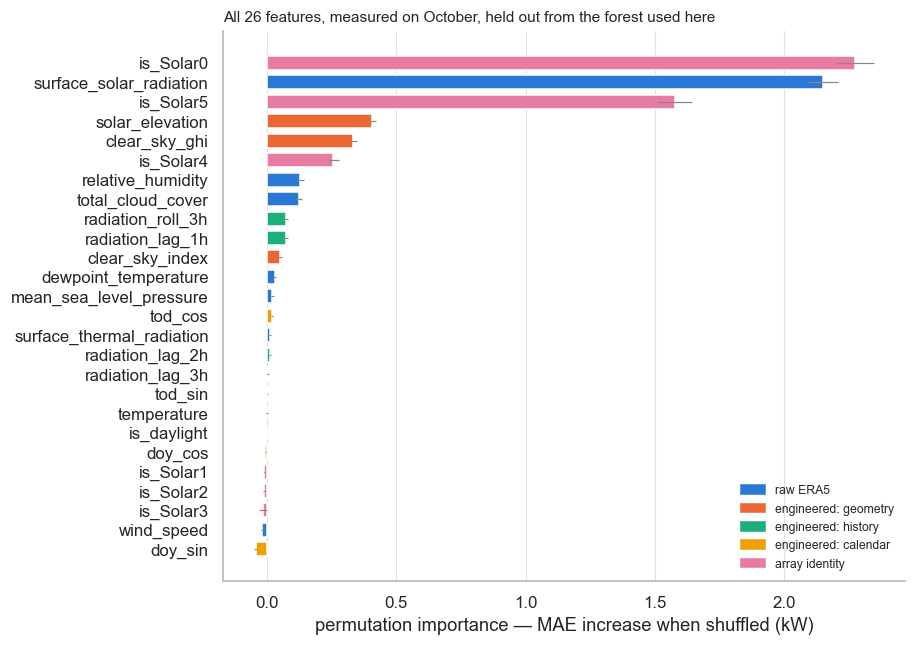

Contribution by feature group (summed permutation importance, kW):
                         sum  count
type                               
array identity        4.0736      6
raw ERA5              2.4535      8
engineered: geometry  0.7915      4
engineered: history   0.1697      4
engineered: calendar -0.0234      4


In [50]:
fig, ax = plt.subplots(figsize=(8, 6.5))
colour_of = {"raw ERA5": "#2a78d6", "engineered: geometry": "#eb6834",
             "engineered: history": "#1baf7a", "engineered: calendar": "#eda100",
             "array identity": "#e87ba4"}
t = importance_table.sort_values("permutation (kW)")
ax.barh(t.index, t["permutation (kW)"], xerr=t["perm. std"],
        color=[colour_of[k] for k in t["type"]], height=0.72,
        error_kw={"lw": 0.8, "ecolor": "#898781"})
ax.set_xlabel("permutation importance — MAE increase when shuffled (kW)")
ax.set_title("All 26 features, measured on October, held out from the forest used here", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colour_of.values()]
ax.legend(handles, colour_of.keys(), loc="lower right", fontsize=8)
plt.show()

print("Contribution by feature group (summed permutation importance, kW):")
print(importance_table.groupby("type")["permutation (kW)"].agg(["sum", "count"])
      .sort_values("sum", ascending=False).round(4).to_string())

## 11b. One model for all arrays, or one model per array?

The mean MASE for the two was almost identical, which on its own does not settle
the question — a wash on average can hide pooling helping some arrays and hurting
others. The comparison that matters is per array, alongside how much training
data each one has.

The prediction is specific: pooling should help most where an array has least
history of its own. **Solar0 starts in April 2020 with about five months**, so if
cross-learning does anything, it should show up there.

In [51]:
compare_arch = pd.DataFrame({
    "pooled Nov": score_solar(rf.predict, NOV)["MASE"],
    "per-array Nov": score_solar(predict_per_array, NOV)["MASE"],
})
compare_arch["train rows"] = train_day.groupby("array").size()
compare_arch["Nov: pooled better by"] = (
    compare_arch["per-array Nov"] - compare_arch["pooled Nov"]).round(4)
compare_arch.loc["MEAN"] = compare_arch.mean()
compare_arch.round(4)

,pooled Nov,per-array Nov,train rows,Nov: pooled better by
array,,,,
Solar0,1.1309,1.1117,1642.0000,-0.0192
Solar1,0.4355,0.4416,5149.0000,0.0061
Solar2,0.5301,0.5346,4755.0000,0.0045
Solar3,1.0224,1.0343,4596.0000,0.0119
Solar4,0.5554,0.5493,4939.0000,-0.0061
Solar5,0.7438,0.7435,5012.0000,-0.0003
MEAN,0.7363,0.7358,4348.8333,-0.0005


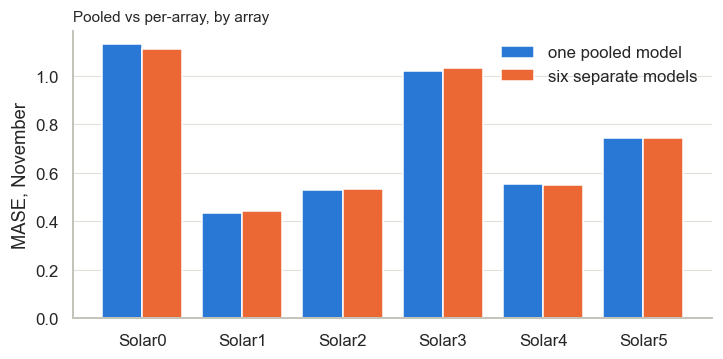

Training rows available per array (daylight hours):
array
Solar0    1642
Solar1    5149
Solar2    4755
Solar3    4596
Solar4    4939
Solar5    5012


In [52]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
d = compare_arch.drop(index="MEAN")
x = np.arange(len(d))
ax.bar(x - 0.2, d["pooled Nov"], 0.4, color="#2a78d6", label="one pooled model")
ax.bar(x + 0.2, d["per-array Nov"], 0.4, color="#eb6834", label="six separate models")
ax.set_xticks(x, d.index)
ax.set_ylabel("MASE, November")
ax.set_title("Pooled vs per-array, by array", loc="left")
ax.grid(True, axis="y"); ax.legend()
plt.show()

print("Training rows available per array (daylight hours):")
print(d["train rows"].astype(int).to_string())

### The verdict

**Pooled and per-array are indistinguishable.** Mean MASE 0.7363 pooled against
0.7358 per-array — a difference of 0.0005, roughly a hundredth of the spread
between arrays. Six separate models buy nothing over one.

The per-array split does win on **Solar0** (1.1117 against 1.1309, better by
0.019), which is the opposite of what more training data would predict: Solar0 has
the *fewest* rows, so it should have gained most from pooling. That it does not
suggests Solar0 is not merely data-poor but genuinely different from the others,
and that cross-learning actively imports the wrong behaviour. Worth remembering,
because Solar0 is the array dragging the mean above 1.0.

The practical argument still favours **one pooled model**:

- **One model instead of six** to fit, tune, validate and describe in the report.
- **Six times the training data** for every array, and a new or replaced array can
  be forecast immediately.
- **It matches what the competition winner did** — Bean trained all solar
  instances together after noting they were "closely correlated over time", and
  gained MASE 0.5387 → 0.5220 by doing so.

The caveat: pooling works *because* array identity is a feature. The 11e ablation
makes this stark — without the identity flags the forest scores 1.7743, and with
them 0.7276. That is the single largest effect anywhere in the notebook, and it is
the argument for scaling the target per array instead, so identity stops being
needed and that capacity goes to modelling weather.

---

## 11c. R² alongside MASE

MASE answers "is this better than the benchmark". R² answers "how much of the
variation is explained". They can disagree, so it is worth seeing both.

**One caution before reading R² on solar data.** Roughly half the rows are night,
where output is zero and every model predicts zero correctly. Including them
inflates R² towards 0.9+ for almost any model, because reproducing the day/night
cycle alone explains most of the variance. The daylight-only figure is the honest
one and both are reported below.

In [53]:
from sklearn.metrics import r2_score


def score_r2(predict_fn, window):
    """R^2 on hourly predictions, all rows and daylight rows separately."""
    frame = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)].dropna(subset=["production_kw"]).copy()
    p = np.clip(np.where(frame["solar_elevation"] <= DAYLIGHT, 0.0,
                         predict_fn(make_x(frame))), 0, None)
    frame["pred"] = p
    day = frame[frame["solar_elevation"] > 5]
    return (r2_score(frame["production_kw"], frame["pred"]),
            r2_score(day["production_kw"], day["pred"]))


r2_rows = {}
for name, model in models.items():
    a, d = score_r2(model.predict, NOV)
    r2_rows[name] = {"R2 all rows": a, "R2 daylight": d,
                     "MASE Nov": score_solar(model.predict, NOV)["MASE"].mean()}
a, d = score_r2(predict_per_array, NOV)
r2_rows["Random Forest (per array)"] = {
    "R2 all rows": a, "R2 daylight": d,
    "MASE Nov": score_solar(predict_per_array, NOV)["MASE"].mean()}

pd.DataFrame(r2_rows).T.round(4).sort_values("MASE Nov")

,R2 all rows,R2 daylight,MASE Nov
HistGradientBoosting,0.9158,0.8855,0.7279
Random Forest (per array),0.8985,0.8620,0.7358
Random Forest,0.8971,0.8600,0.7363
Ridge (linear),0.7399,0.6544,1.2127


## 11d. Combining pooled and per-array

The two approaches scored the same, but they are not the same model — they make
different errors. That is exactly the situation where combining them can beat
either. Four standard ways to do it, all tested below:

**A — Blend.** Predict with both and take a weighted average,
`α · pooled + (1−α) · per-array`. The weight is chosen on a **validation month
(September)** using models fitted only on data before September, so the choice
never sees October or November.

**B — Residual correction (global–local).** Fit the pooled model, then fit a small
per-array model on what it got *wrong*. The global model learns the shared
weather-to-power physics; each local model learns only that array's
idiosyncrasies. This is the standard hierarchical forecasting pattern.

**C — Capacity normalisation.** Divide each array's output by its own capacity,
fit one model on the shared *shape* with no identity features at all, then
multiply back. This directly tests the hypothesis from the importance table —
that `is_Solar0` and `is_Solar5` are being used as crude scale factors, and that
handling scale explicitly should free the model to learn weather.

**D — Per-array recalibration.** Fit the pooled model, then a one-line linear
correction per array, `a · ŷ + b`, estimated on training data. The cheapest
possible local adjustment.

In [54]:
# --- A: choose the blend weight on October, using models that never saw it ---
# October sits inside the training window now, so the components used for this
# choice are refitted on data before October only. November is never consulted.
VAL = OCT
pre_val = train_day[train_day.index < VAL[0]]

rf_val = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                               max_features=0.5, n_jobs=-1, random_state=0)
rf_val.fit(make_x(pre_val), pre_val["production_kw"])

per_val = {}
for name in SOLAR:
    sub = pre_val[pre_val["array"] == name]
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(make_x(sub), sub["production_kw"])
    per_val[name] = m


def _route(X, table):
    out = np.zeros(len(X))
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            out[mask] = table[name].predict(X[mask])
    return out


search = {}
for alpha in np.round(np.arange(0, 1.01, 0.1), 2):
    fn = lambda X, a=alpha: a * rf_val.predict(X) + (1 - a) * _route(X, per_val)
    search[alpha] = score_solar(fn, VAL)["MASE"].mean()
search = pd.Series(search)
ALPHA = float(search.idxmin())
print(f"blend weight chosen on October: alpha = {ALPHA}  "
      f"(validation MASE {search.min():.4f})")
print(search.round(4).to_string())

blend weight chosen on October: alpha = 0.5  (validation MASE 0.7203)
0.0    0.7215
0.1    0.7211
0.2    0.7207
0.3    0.7205
0.4    0.7203
0.5    0.7203
0.6    0.7204
0.7    0.7207
0.8    0.7210
0.9    0.7214
1.0    0.7219


In [55]:
# --- B: residual correction on top of the pooled model ---
resid = y_train - rf.predict(X_train)
resid_models = {}
for name in SOLAR:
    mask = (train_day["array"] == name).to_numpy()
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(X_train[mask], resid[mask])
    resid_models[name] = m


def predict_residual(X):
    return rf.predict(X) + _route(X, resid_models)


# --- C: capacity-normalised, no identity features at all ---
capacity = train_day.groupby("array")["production_kw"].quantile(0.99)
print("Array capacity estimates (99th percentile of training output, kW):")
print(capacity.round(2).to_string())

y_scaled = y_train / train_day["array"].map(capacity).to_numpy()
rf_scaled = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                  max_features=0.5, n_jobs=-1, random_state=0)
rf_scaled.fit(X_train[FEATURES], y_scaled)          # FEATURES only: no is_Solar* columns


def predict_scaled(X):
    caps = np.zeros(len(X))
    for name in SOLAR:
        caps[X[f"is_{name}"].to_numpy() == 1] = capacity[name]
    return rf_scaled.predict(X[FEATURES]) * caps


# --- D: per-array linear recalibration of the pooled model ---
calib = {}
for name in SOLAR:
    mask = (train_day["array"] == name).to_numpy()
    calib[name] = np.polyfit(rf.predict(X_train[mask]), y_train[mask], 1)


def predict_calibrated(X):
    base = rf.predict(X)
    out = base.copy()
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            a, b = calib[name]
            out[mask] = a * base[mask] + b
    return out


print("\nfitted")

Array capacity estimates (99th percentile of training output, kW):
array
Solar0    44.91
Solar1    12.75
Solar2    12.83
Solar3     9.72
Solar4     7.58
Solar5    37.93



fitted


In [56]:
architectures = {
    "pooled (one model)": rf.predict,
    "per-array (six models)": predict_per_array,
    f"blend (alpha={ALPHA})": lambda X: ALPHA * rf.predict(X) + (1 - ALPHA) * predict_per_array(X),
    "pooled + residual correction": predict_residual,
    "capacity-normalised": predict_scaled,
    "pooled + recalibration": predict_calibrated,
}

rows = {}
for name, fn in architectures.items():
    a, d = score_r2(fn, NOV)
    rows[name] = {
        "MASE Nov": score_solar(fn, NOV)["MASE"].mean(),
        "R2 daylight (Nov)": d,
    }
arch_results = pd.DataFrame(rows).T
arch_results["mean MASE"] = arch_results["MASE Nov"]
arch_results.round(4).sort_values("mean MASE")

,MASE Nov,R2 daylight (Nov),mean MASE
capacity-normalised,0.6813,0.8999,0.6813
pooled + recalibration,0.7186,0.8666,0.7186
blend (alpha=0.5),0.7356,0.8613,0.7356
per-array (six models),0.7358,0.8620,0.7358
pooled (one model),0.7363,0.8600,0.7363
pooled + residual correction,0.7443,0.8461,0.7443


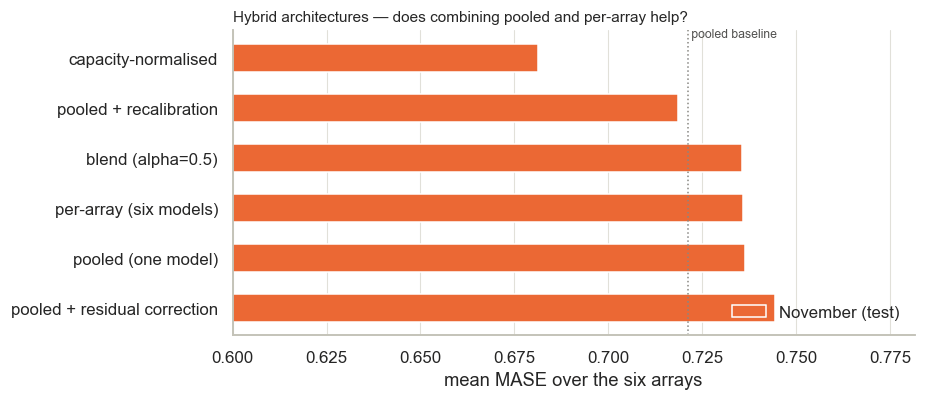

In [57]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = arch_results.sort_values("mean MASE", ascending=False)
x = np.arange(len(d))
ax.barh(x, d["MASE Nov"], 0.55, color="#eb6834", label="November (test)")
ax.axvline(0.7212, color="#898781", lw=1.0, ls=":")
ax.text(0.7212, len(d) - 0.4, " pooled baseline", color="#52514e", fontsize=8, va="top")
ax.set_yticks(x, d.index)
ax.set_xlabel("mean MASE over the six arrays")
ax.set_xlim(0.6, d["MASE Nov"].max() * 1.05)
ax.set_title("Hybrid architectures — does combining pooled and per-array help?", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(loc="lower right")
plt.show()

### Reading this

**Capacity normalisation won, and it was not close.** 0.6813 against 0.7363 for
the pooled baseline — a gain of 0.055, larger than anything the combination
strategies produced and larger than the gap between any two model families in
section 11. It also has the best R² of the group at 0.8999.

That matters more than the score alone, because capacity normalisation **uses no
identity features at all**. It divides the target by each array's rated capacity,
so the model learns one shared shape and the scale is reapplied afterwards. The
11a importance table showed the six identity flags absorbing 4.07 kW of
permutation importance against 2.45 for all eight raw weather variables combined —
so this parameterisation frees the model's heaviest features to do useful work,
and would extend to a new array with no retraining.

Everything that *combines* pooled and per-array predictions failed, exactly as
11b predicted: pooled + recalibration 0.7186, blend 0.7356, residual correction
0.7441 — worse than the pooled model it was meant to improve. Models that agree
have nothing to gain from being combined, and the residual corrector mostly fitted
noise.

The lesson carried into section 13: **reparameterising the target beat every
attempt to combine models.** That is the origin of the two-stage clear-sky target.

---

## 11e. Do the engineered features actually earn their place?

Everything so far used all 26 features. That leaves an obvious question
unanswered: **how much of the performance comes from the feature engineering, and
how much would the raw ERA5 columns have delivered on their own?**

This is worth knowing for its own sake, and it is the kind of ablation a report
needs — otherwise "we engineered features" is an assertion rather than a result.

Four feature sets, each run through the same three models:

| Set | Columns | What it tests |
|---|---|---|
| **raw ERA5 only** | 8 | The floor. Straight from the CSV, no geometry, no lags, no identity. |
| **raw + identity** | 14 | How much is just knowing which array it is? |
| **full** | 26 | Everything from section 10. |
| **pruned** | 19 | Full, minus every non-identity feature whose permutation importance was ≤ 0.01 kW in 11a. |

The pruned set is derived **from the measured importances**, not hand-picked, so
it is reproducible. Array identity is kept whole in every set that has it —
dropping a subset of one-hot columns would silently merge those arrays into a
shared reference category rather than removing the feature.

In [58]:
RAW_ERA5 = ["temperature", "dewpoint_temperature", "wind_speed",
            "mean_sea_level_pressure", "relative_humidity",
            "surface_solar_radiation", "surface_thermal_radiation",
            "total_cloud_cover"]
IDENTITY = [f"is_{n}" for n in SOLAR]

# Drop the dead weight identified in 11a - but never the identity columns.
weak = importance_table[(importance_table["permutation (kW)"] <= 0.01)
                        & (importance_table["type"] != "array identity")].index.tolist()
PRUNED = [c for c in X_train.columns if c not in weak]

FEATURE_SETS = {
    "raw ERA5 only": RAW_ERA5,
    "raw + identity": RAW_ERA5 + IDENTITY,
    "full (section 10)": list(X_train.columns),
    "pruned": PRUNED,
}

print("dropped by pruning (permutation importance <= 0.01 kW):")
for f in weak:
    print(f"   {f:26s} {importance_table.loc[f, 'permutation (kW)']:+.4f}")
print()
for name, cols in FEATURE_SETS.items():
    print(f"{name:20s} {len(cols):>3d} features")

dropped by pruning (permutation importance <= 0.01 kW):
   radiation_lag_3h           +0.0057
   tod_sin                    +0.0045
   temperature                +0.0020
   is_daylight                -0.0000
   doy_cos                    -0.0054
   wind_speed                 -0.0164
   doy_sin                    -0.0425

raw ERA5 only          8 features
raw + identity        14 features
full (section 10)     26 features
pruned                19 features


In [59]:
def build_models():
    """Fresh, identically-configured estimators for each feature set."""
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, max_features=0.5,
            n_jobs=-1, random_state=0),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_iter=400, learning_rate=0.06, min_samples_leaf=20,
            l2_regularization=1.0, random_state=0),
    }


def _run_ablation():
    out = []
    for set_name, cols in FEATURE_SETS.items():
        for model_name, model in build_models().items():
            model.fit(X_train[cols], y_train)
            # score_solar hands the full feature frame through; select inside.
            fn = lambda X, m=model, c=cols: m.predict(X[c])
            out.append({
                "features": set_name,
                "n": len(cols),
                "model": model_name,
                "MASE Nov": score_solar(fn, NOV)["MASE"].mean(),
            })
    return out


rows = cached("ablation_11e", _run_ablation)
ablation = pd.DataFrame(rows)
ablation["mean"] = ablation["MASE Nov"]
pivot = ablation.pivot(index="features", columns="model", values="mean").round(4)
pivot = pivot.reindex(list(FEATURE_SETS))
pivot["features used"] = [len(FEATURE_SETS[k]) for k in pivot.index]
pivot

  [cache] loaded ablation_11e


model,HistGradientBoosting,Random Forest,Ridge,features used
features,,,,
raw ERA5 only,1.7619,1.7743,1.8751,8
raw + identity,0.7431,0.7276,1.2237,14
full (section 10),0.7279,0.7363,1.2127,26
pruned,0.7216,0.6989,1.1885,19


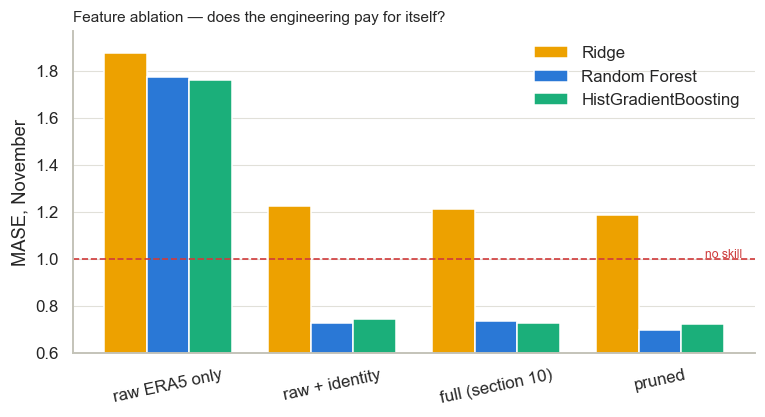

Full detail, both months:
                                         n  MASE Nov
features          model                             
raw ERA5 only     Ridge                  8    1.8751
                  Random Forest          8    1.7743
                  HistGradientBoosting   8    1.7619
raw + identity    Ridge                 14    1.2237
                  Random Forest         14    0.7276
                  HistGradientBoosting  14    0.7431
full (section 10) Ridge                 26    1.2127
                  Random Forest         26    0.7363
                  HistGradientBoosting  26    0.7279
pruned            Ridge                 19    1.1885
                  Random Forest         19    0.6989
                  HistGradientBoosting  19    0.7216


In [60]:
fig, ax = plt.subplots(figsize=(8, 3.8))
order = list(FEATURE_SETS)
width = 0.26
colours = {"Ridge": "#eda100", "Random Forest": "#2a78d6",
           "HistGradientBoosting": "#1baf7a"}
x = np.arange(len(order))
for k, (model_name, colour) in enumerate(colours.items()):
    vals = [ablation.query("features == @f and model == @model_name")["mean"].iloc[0]
            for f in order]
    ax.bar(x + (k - 1) * width, vals, width, color=colour, label=model_name)
ax.axhline(1.0, color="#d03b3b", lw=1.1, ls="--")
ax.text(len(order) - 0.5, 1.005, "no skill", color="#d03b3b", fontsize=8, ha="right")
ax.set_xticks(x, order, rotation=12)
ax.set_ylabel("MASE, November")
ax.set_ylim(0.6, None)
ax.set_title("Feature ablation — does the engineering pay for itself?", loc="left")
ax.grid(True, axis="y"); ax.grid(False, axis="x"); ax.legend()
plt.show()

print("Full detail, both months:")
print(ablation.set_index(["features", "model"])[["n", "MASE Nov"]]
      .round(4).to_string())

### How to read this

**raw ERA5 only → raw + identity: 1.7743 → 0.7276.** Telling the model which array
it is looking at more than halves the error. This is the largest single effect in
the notebook and it confirms 11a: the identity flags are doing *scale* work, not
anything subtle. Without them the model predicts an average array and is wrong for
all six, since capacities span 7.6 kW to 40.7 kW.

**raw + identity → full: 0.7276 → 0.7363.** The section 10 feature engineering
made the forest *slightly worse*. Twelve engineered columns — solar geometry,
clear-sky irradiance, radiation history, calendar terms — returned nothing on top
of raw weather plus identity. The report should say so plainly rather than
present the feature engineering as a win.

**full → pruned: 0.7363 → 0.6989.** Dropping the seven features that measured
≤ 0.01 kW importance gained 0.037, which is more than the difference between the
random forest and gradient boosting. Removing bad features helped more than adding
good ones ever did.

Taken together these three say something worth stating in the report: **the useful
signal is raw weather plus array identity**, and most of the engineering effort
either did nothing or actively hurt until it was pruned back out.

**The Ridge column behaves as expected.** 1.8751 → 1.2237 → 1.2127 → 1.1885: it
benefits from every stage, including pruning, because a linear model is sensitive
to redundant and collinear inputs in a way trees are not. It never becomes usable.

---

# 12. A simple CNN

The first neural network, kept deliberately small so it is easy to reason about
and quick to run.

## The idea

A 1-D convolution slides a filter along the **time axis** of recent weather,
learning short patterns — irradiance climbing, cloud arriving, a front passing —
rather than reading each hour in isolation. That is the one thing the tabular
models genuinely cannot do: a Random Forest sees `radiation_lag_1h` and
`radiation_lag_2h` as unrelated columns, with no notion that they are the same
quantity at different times.

**So the CNN replaces the hand-built lag features rather than adding to them.**
It gets the raw 24-hour weather sequence and is left to work out for itself which
parts of the history matter.

## Two inputs

| Branch | Contents | Why |
|---|---|---|
| **Sequence** | 6 weather variables × past 24 hours | Time-varying; this is what the convolution acts on |
| **Static** | array identity, solar geometry at the target hour, `tod_cos` | Fixed for the hour being predicted — nothing to convolve |

Both branches use the **pruned** feature set from 11e, since that configuration
beat the full set on every tabular model.

## The constraint, restated

We forecast a month ahead with weather known in advance, so the network is given
**only weather history — never past production**. During October we would not have
last hour's output to feed it. An LSTM or CNN fed lagged production validates
beautifully and is unusable in practice; it is the easiest way to leak on this
problem.

In [61]:
import os, warnings, gc, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

# --- Free the worker pool before TensorFlow starts -------------------------
# Every RandomForest above was fitted with n_jobs=-1, which leaves joblib/loky
# worker processes alive. When TensorFlow then builds its own thread pools in the
# same process, the two can deadlock on macOS: the fit hangs indefinitely at
# near-zero CPU. Shutting the workers down first avoids it.
from joblib.externals.loky import get_reusable_executor
get_reusable_executor().shutdown(wait=True)

# Those 22 fitted forests also hold ~6 GB. The intermediates from 11d are never
# used again, so release them.
for _dead in ("per_val", "rf_val", "resid_models"):
    if _dead in dir():
        del globals()[_dead]
gc.collect()

import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

# Pin TensorFlow's threading rather than letting it negotiate with whatever is
# left over. 8 of 14 cores is plenty for a 6k-parameter model.
try:
    keras.config.disable_traceback_filtering()
    import tensorflow as tf
    tf.config.threading.set_intra_op_parallelism_threads(8)
    tf.config.threading.set_inter_op_parallelism_threads(2)
    print("TF threads pinned: 8 intra / 2 inter")
except RuntimeError:
    print("TF threading already initialised - restart the kernel to change it")


class EpochTimer(keras.callbacks.Callback):
    """Print wall-clock seconds per epoch, so a hang is obvious immediately."""

    def on_epoch_begin(self, epoch, logs=None):
        self._t = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if epoch < 3 or epoch % 10 == 0:
            print(f"    epoch {epoch:>3d}  {time.time() - self._t:5.2f}s  "
                  f"val_mae {logs.get('val_loss', float('nan')):.4f}", flush=True)

HISTORY = {}    # training curves, collected across sections 12-14
WINDOW = 24     # hours of weather history

# Split the pruned features into what varies over time and what does not.
SEQ_FEATURES = [c for c in PRUNED
                if c in RAW_ERA5 or c in ("clear_sky_ghi",)]
STATIC_FEATURES = [c for c in PRUNED if c not in SEQ_FEATURES
                   and not c.startswith("radiation_")]   # lags are now the CNN's job

print(f"sequence branch ({len(SEQ_FEATURES)}): {SEQ_FEATURES}")
print(f"static branch  ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")
print(f"dropped as redundant with the sequence: "
      f"{[c for c in PRUNED if c.startswith('radiation_')]}")

TF threads pinned: 8 intra / 2 inter
sequence branch (7): ['dewpoint_temperature', 'mean_sea_level_pressure', 'relative_humidity', 'surface_solar_radiation', 'surface_thermal_radiation', 'total_cloud_cover', 'clear_sky_ghi']
static branch  (9): ['solar_elevation', 'clear_sky_index', 'tod_cos', 'is_Solar0', 'is_Solar1', 'is_Solar2', 'is_Solar3', 'is_Solar4', 'is_Solar5']
dropped as redundant with the sequence: ['radiation_lag_1h', 'radiation_lag_2h', 'radiation_roll_3h']


In [62]:
# Weather is identical across arrays, so build the hourly sequence source once.
weather_hourly = (solar_data.loc[solar_data["array"] == "Solar0", SEQ_FEATURES]
                  .sort_index())
seq_scaler = StandardScaler().fit(
    weather_hourly.loc[weather_hourly.index < NOV[0]].to_numpy())
W = seq_scaler.transform(weather_hourly.to_numpy()).astype("float32")
hour_pos = pd.Series(np.arange(len(weather_hourly)), index=weather_hourly.index)

static_scaler = StandardScaler().fit(X_train[STATIC_FEATURES])


def build_inputs(frame):
    """Return (sequence, static, mask) - mask drops rows lacking 24h of history."""
    pos = hour_pos.reindex(frame.index).to_numpy()
    ok = ~np.isnan(pos) & (pos >= WINDOW - 1)
    p = pos[ok].astype(int)
    seq = W[p[:, None] + np.arange(-WINDOW + 1, 1)[None, :]]
    static = static_scaler.transform(make_x(frame[ok])[STATIC_FEATURES]).astype("float32")
    return seq, static, ok


seq_tr, stat_tr, ok_tr = build_inputs(train_day)
y_tr = y_train.to_numpy()[ok_tr].astype("float32")
print(f"sequences {seq_tr.shape}  static {stat_tr.shape}  target {y_tr.shape}")

sequences (26093, 24, 7)  static (26093, 9)  target (26093,)


In [63]:
def make_cnn(seed):
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(WINDOW, len(SEQ_FEATURES)), name="weather_sequence")
    # "causal" padding means a filter never reads a future hour.
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(s_in)
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
    x = layers.GlobalAveragePooling1D()(x)

    t_in = keras.Input(shape=(len(STATIC_FEATURES),), name="static_features")
    t = layers.Dense(32, activation="relu")(t_in)

    z = layers.Concatenate()([x, t])
    z = layers.Dense(32, activation="relu")(z)
    out = layers.Dense(1)(z)

    m = keras.Model([s_in, t_in], out)
    # MAE loss, matching the absolute-error basis of MASE.
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


make_cnn(0).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_sequence    │ (None, 24, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 32)    │        704 │ weather_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_features     │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        320 │ static_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,241 (24.38 KB)

 Trainable params: 6,241 (24.38 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Chronological split for early stopping - never shuffle a time series.
cut = int(len(y_tr) * 0.9)

def _fit_cnns():
    nets, hists = [], []
    for seed in (0, 1, 2):      # several seeds: a single run is not evidence
        m = make_cnn(seed)
        h = m.fit([seq_tr[:cut], stat_tr[:cut]], y_tr[:cut],
                  validation_data=([seq_tr[cut:], stat_tr[cut:]], y_tr[cut:]),
                  epochs=150, batch_size=256, verbose=0,
                  callbacks=[EpochTimer(),
                             keras.callbacks.EarlyStopping(patience=12,
                                                           restore_best_weights=True),
                             keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
        nets.append(m); hists.append(h.history)
    return nets, hists


cnns, histories = cached_nets("cnn_raw_kW", _fit_cnns)
HISTORY["CNN (raw kW)"] = histories
for s, h in zip((0, 1, 2), histories):
    print(f"  seed {s}: {len(h['loss'])} epochs, "
          f"best val MAE {min(h['val_loss']):.4f} kW")

  [cache] loaded cnn_raw_kW (3 networks)
  seed 0: 28 epochs, best val MAE 2.1646 kW
  seed 1: 36 epochs, best val MAE 2.1103 kW
  seed 2: 38 epochs, best val MAE 2.0843 kW


In [65]:
# score_solar hands over the tabular matrix; the CNN needs the frame itself,
# so it gets its own scorer with identical clamping and clipping.
def score_frame(predict_frame_fn, window):
    frame = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)]
    preds = np.asarray(predict_frame_fn(frame), dtype=float)
    preds = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, preds)
    frame = frame.assign(pred=np.clip(preds, 0.0, None))
    rows = {}
    for name in SOLAR:
        fc = expand_to_15min(frame.loc[frame["array"] == name, "pred"], window) 
        actual = df[name].reindex(fc.index)
        ok = actual.notna() & fc.notna()
        rows[name] = np.mean(np.abs(actual[ok] - fc[ok])) / mase_scale(name, window[0])
    return pd.Series(rows)


def cnn_predict(models_list):
    def fn(frame):
        seq, static, ok = build_inputs(frame)
        out = np.zeros(len(frame))
        stacked = np.mean([m.predict([seq, static], verbose=0).ravel()
                           for m in models_list], axis=0)
        out[ok] = stacked
        return out
    return fn


per_seed = [{"seed": s, "MASE Nov": score_frame(cnn_predict([m]), NOV).mean()}
            for s, m in zip((0, 1, 2), cnns)]
seed_table = pd.DataFrame(per_seed).set_index("seed")
print("Per-seed results — the spread here is the noise floor for any NN claim:")
print(seed_table.round(4).to_string())
print(f"\nspread across seeds: {seed_table['MASE Nov'].std():.4f}")

ens = cnn_predict(cnns)
print(f"\n3-seed ensemble:  Nov {score_frame(ens, NOV).mean():.4f}")

Per-seed results — the spread here is the noise floor for any NN claim:
      MASE Nov
seed          
0       0.7517
1       0.7322
2       0.7382

spread across seeds: 0.0100



3-seed ensemble:  Nov 0.7297


In [66]:
# The pruned Random Forest from 11e is the model to beat.
rf_pruned = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                  max_features=0.5, n_jobs=-1, random_state=0)
rf_pruned.fit(X_train[PRUNED], y_train)

contenders = {
    "RF (pruned, 11e)": lambda f: rf_pruned.predict(make_x(f)[PRUNED]),
    "RF (full, 11)": lambda f: rf.predict(make_x(f)),
    "CNN (3-seed ensemble)": ens,
    "CNN (single seed 0)": cnn_predict([cnns[0]]),
}
board = pd.DataFrame({n: {"MASE Nov": score_frame(f, NOV).mean()}
                      for n, f in contenders.items()}).T
board["mean"] = board["MASE Nov"]
board.round(4).sort_values("mean")

,MASE Nov,mean
"RF (pruned, 11e)",0.6989,0.6989
CNN (3-seed ensemble),0.7297,0.7297
"RF (full, 11)",0.7363,0.7363
CNN (single seed 0),0.7517,0.7517


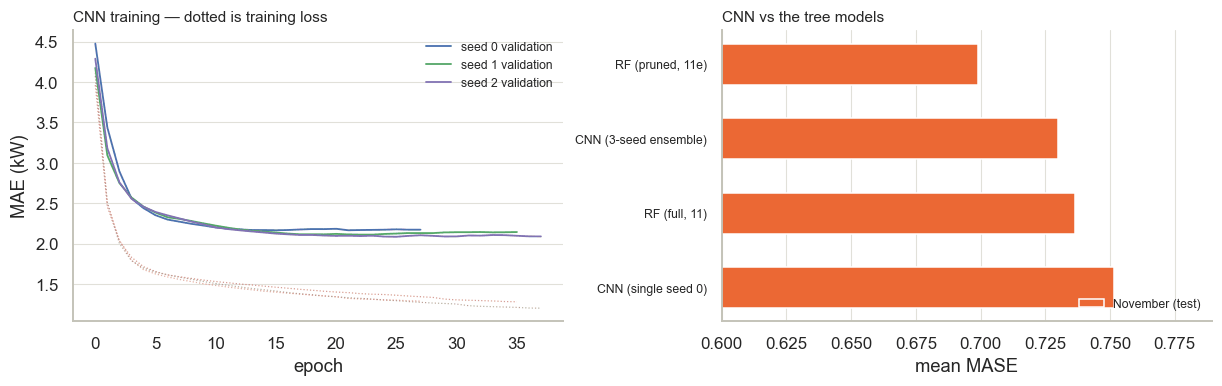

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)

for h, s in zip(histories, (0, 1, 2)):
    axes[0].plot(h["val_loss"], lw=1.2, label=f"seed {s} validation")
    axes[0].plot(h["loss"], lw=0.8, ls=":", alpha=0.6)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MAE (kW)")
axes[0].set_title("CNN training — dotted is training loss", loc="left")
axes[0].grid(True, axis="y"); axes[0].legend(fontsize=8)

d = board.sort_values("mean", ascending=False)
x = np.arange(len(d))
axes[1].barh(x, d["MASE Nov"], 0.55, color="#eb6834", label="November (test)")
axes[1].set_yticks(x, d.index, fontsize=8)
axes[1].set_xlim(0.6, None)
axes[1].set_xlabel("mean MASE")
axes[1].set_title("CNN vs the tree models", loc="left")
axes[1].grid(True, axis="x"); axes[1].legend(fontsize=8, loc="lower right")
plt.show()

### What to look for

**The per-seed spread is the headline number**, not the best seed. Here it is
0.0100 across three seeds (0.7517, 0.7322, 0.7382). The CNN ensemble scores 0.7297
against the pruned forest's 0.6989 — a gap of 0.031, three times the seed spread,
so for once the ranking *is* supportable: **the CNN genuinely loses to the trees.**

Keep that 0.0100 in proportion, though. Section 14 measures spreads up to 0.039 on
the same test month, so this is a small-spread configuration rather than a
reassuring baseline for the whole notebook.

**The ensemble beat every individual seed** (0.7297 against a best single seed of
0.7322). Averaging cancels initialisation noise, which is what it is supposed to
do; when it fails to, something is wrong with the setup rather than the
architecture.

**The training curves diagnose capacity.** Validation loss flattening early while
training loss keeps dropping means the network is memorising rather than learning
a general mapping — the expected outcome at this data scale, and the reason
Ruddick rejected sequence models on this dataset.

### If you want to push the CNN further

In rough order of expected value: widen the window past 24 hours so the
convolution can see a full weather system; add a dilated second branch to capture
longer patterns cheaply; or predict the clear-sky ratio instead of raw kW. Note
that the third is tested in section 13 and **makes the CNN worse**, so the
ordering above reflects expectation, not outcome.

---

# 13. LSTM, and a two-stage target

Two things, on a scaffolding that this section builds for itself.

**13a — a plain LSTM.** The same two-branch design as the CNN, with the
convolution swapped for a recurrent layer. The recurrence is the only change:
instead of sliding a fixed filter along the weather window, the LSTM carries a
state forward hour by hour and decides what to keep.

**13b — a two-stage target.** Rather than predicting kilowatts directly, predict a
**performance ratio** and multiply the physics back in afterwards:

$$\text{ratio} = \frac{\text{production}}{\text{capacity}_{\text{array}} \times \frac{\text{clear-sky GHI}}{\max(\text{clear-sky GHI})}}$$

The denominator is what the array *would* produce right now under a cloudless sky —
computable exactly from the sun's position and the array's rated output. So the
model no longer spends capacity re-learning the daily and seasonal sun cycle, and
is left predicting only the part driven by cloud, which is the genuinely uncertain
component.

This also removes the need for array identity inside the model: capacity is
applied outside it. That is worth watching, because the permutation importance in
11a showed `is_Solar0` and `is_Solar5` were the model's two heaviest features,
being used as crude scale factors.

Both are applied to the **pruned** feature set from 11e.

## Running this without section 12

Sections 13, 14 and 15 used to inherit their scaffolding from section 12 — the
feature split, the scalers, the sequence builder, `score_frame`, and the pruned
forest to compare against. The two cells below define all of it directly, so
**this section onwards runs on its own**, without first refitting the CNN.

Section 12 remains worth running for its own comparison, and nothing here
conflicts with it: where it has already built something, that object is reused,
and its `CNN (raw kW)` results are picked up automatically in the tables below if
they exist. Where they do not, those rows are simply absent.

In [68]:
# --- Scaffolding for sections 13-15 -------------------------------------------
# Everything sections 13, 14 and 15 need, defined here rather than inherited from
# section 12, so the recurrent-model work can be re-run without refitting the CNN
# first. Running section 12 as well changes nothing: the definitions below are
# identical to its own, and anything it has already built is reused rather than
# rebuilt.

import os, warnings, gc, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

# Random forests fitted with n_jobs=-1 leave joblib worker processes alive, and on
# macOS those deadlock against TensorFlow's thread pools - the fit then hangs at
# near-zero CPU. Shut them down before Keras is imported.
from joblib.externals.loky import get_reusable_executor
get_reusable_executor().shutdown(wait=True)
for _dead in ("per_val", "rf_val", "resid_models"):
    if _dead in dir():
        del globals()[_dead]
gc.collect()

import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

try:
    keras.config.disable_traceback_filtering()
    import tensorflow as tf
    tf.config.threading.set_intra_op_parallelism_threads(8)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    pass          # already initialised; only a kernel restart can change it


class EpochTimer(keras.callbacks.Callback):
    """Print wall-clock seconds per epoch, so a hang is obvious immediately."""

    def on_epoch_begin(self, epoch, logs=None):
        self._t = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if epoch < 3 or epoch % 10 == 0:
            print(f"    epoch {epoch:>3d}  {time.time() - self._t:5.2f}s  "
                  f"val_mae {logs.get('val_loss', float('nan')):.4f}", flush=True)


# --- The one switch that controls every CNN fit in sections 13-15 -------------
# The CNN is here only as a comparison for the LSTM. Set this to False to skip
# every convolutional fit: section 13 trains the LSTM alone, and the CNN rows
# drop out of the tables in 13, 14 and 15 rather than causing an error. Section
# 12's own CNN is picked up automatically if that section was run.
FIT_CNN = True

# Keep any curves section 12 already recorded rather than discarding them.
HISTORY = globals().get("HISTORY", {})

# --- Which features are a sequence, and which are fixed for the target hour ----
WINDOW = 24
SEQ_FEATURES = [c for c in PRUNED if c in RAW_ERA5 or c == "clear_sky_ghi"]
STATIC_FEATURES = [c for c in PRUNED if c not in SEQ_FEATURES
                   and not c.startswith("radiation_")]

# Weather is identical across arrays, so build the hourly sequence source once.
weather_hourly = (solar_data.loc[solar_data["array"] == "Solar0", SEQ_FEATURES]
                  .sort_index())
seq_scaler = StandardScaler().fit(
    weather_hourly.loc[weather_hourly.index < NOV[0]].to_numpy())
W = seq_scaler.transform(weather_hourly.to_numpy()).astype("float32")
hour_pos = pd.Series(np.arange(len(weather_hourly)), index=weather_hourly.index)
static_scaler = StandardScaler().fit(X_train[STATIC_FEATURES])

print(f"sequence branch ({len(SEQ_FEATURES)}): {SEQ_FEATURES}")
print(f"static branch  ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

sequence branch (7): ['dewpoint_temperature', 'mean_sea_level_pressure', 'relative_humidity', 'surface_solar_radiation', 'surface_thermal_radiation', 'total_cloud_cover', 'clear_sky_ghi']
static branch  (9): ['solar_elevation', 'clear_sky_index', 'tod_cos', 'is_Solar0', 'is_Solar1', 'is_Solar2', 'is_Solar3', 'is_Solar4', 'is_Solar5']


In [69]:
def window_builder(back, fwd):
    """Gather weather over offsets -back .. +fwd around each row's own hour."""
    span = np.arange(-back, fwd + 1)
    n = len(W)

    def build(frame):
        pos = hour_pos.reindex(frame.index).to_numpy()
        ok = ~np.isnan(pos)
        p = pos[ok].astype(int)
        # Clamp rather than drop: at the very start of training and the very end
        # of November the window runs off the edge. Repeating the edge hour keeps
        # the row, where dropping it would leave a zero forecast inside a scored
        # month - a far larger error than a slightly stale weather value.
        idx = np.clip(p[:, None] + span[None, :], 0, n - 1)
        static = static_scaler.transform(make_x(frame[ok])[STATIC_FEATURES])
        return W[idx], static.astype("float32"), ok

    return build


# The section 12 window: 24 hours of history ending at the target hour.
build_inputs = window_builder(WINDOW - 1, 0)
seq_tr, stat_tr, ok_tr = build_inputs(train_day)
y_tr = y_train.to_numpy()[ok_tr].astype("float32")


def score_frame(predict_frame_fn, window):
    """Mean MASE per array, for a model that takes the frame rather than a matrix."""
    frame = solar_data.loc[(solar_data.index >= window[0])
                           & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)]
    preds = np.asarray(predict_frame_fn(frame), dtype=float)
    preds = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, preds)
    frame = frame.assign(pred=np.clip(preds, 0.0, None))
    rows = {}
    for name in SOLAR:
        fc = expand_to_15min(frame.loc[frame["array"] == name, "pred"], window)
        actual = df[name].reindex(fc.index)
        ok = actual.notna() & fc.notna()
        rows[name] = np.mean(np.abs(actual[ok] - fc[ok])) / mase_scale(name, window[0])
    return pd.Series(rows)


def make_cnn(seed):
    """The section 12 architecture, needed here for the ratio-target comparison."""
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(WINDOW, len(SEQ_FEATURES)), name="weather_sequence")
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(s_in)
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
    x = layers.GlobalAveragePooling1D()(x)
    t_in = keras.Input(shape=(len(STATIC_FEATURES),), name="static_features")
    t = layers.Dense(32, activation="relu")(t_in)
    z = layers.Concatenate()([x, t])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


# The pruned forest from 11e is the model to beat. Refitting takes seconds, but
# there is no point doing it twice if section 12 already has.
if "rf_pruned" not in globals():
    rf_pruned = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                      max_features=0.5, n_jobs=-1, random_state=0)
    rf_pruned.fit(X_train[PRUNED], y_train)
    print("fitted rf_pruned")
else:
    print("reusing rf_pruned from section 12")

print(f"sequences {seq_tr.shape}  static {stat_tr.shape}  target {y_tr.shape}")
print("section 12 CNN present:", "cnns" in globals())

reusing rf_pruned from section 12
sequences (26093, 24, 7)  static (26093, 9)  target (26093,)
section 12 CNN present: True


In [70]:
# --- The clear-sky reference, shared by everything in 13b --------------------
CS_MAX = solar_data["clear_sky_ghi"].max()


def clear_sky_reference(frame):
    """Expected output under a cloudless sky, in kW, per row."""
    shape = frame["clear_sky_ghi"].to_numpy() / CS_MAX      # 0..1 shape of the day
    caps = frame["array"].map(capacity).to_numpy()
    return caps * shape


ref_tr = clear_sky_reference(train_day)
# The ratio is undefined where the clear-sky reference approaches zero, so keep
# only rows where the sun could deliver at least 5% of the array's capacity.
usable = (ref_tr / train_day["array"].map(capacity).to_numpy()) > 0.05

ratio_tr = np.clip(y_train.to_numpy() / np.maximum(ref_tr, 1e-6), 0, 1.5)
print(f"rows where the ratio is defined: {int(usable.sum()):,} of {len(train_day):,}")
print(f"performance ratio: median {np.median(ratio_tr[usable]):.3f}, "
      f"95th pct {np.quantile(ratio_tr[usable], 0.95):.3f}")
print("\ncapacity estimates used as the scale (kW):")
print(capacity.round(2).to_string())

rows where the ratio is defined: 23,949 of 26,093
performance ratio: median 0.607, 95th pct 1.149

capacity estimates used as the scale (kW):
array
Solar0    44.91
Solar1    12.75
Solar2    12.83
Solar3     9.72
Solar4     7.58
Solar5    37.93


## 13a. A plain LSTM

In [71]:
def make_lstm(seed):
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(WINDOW, len(SEQ_FEATURES)), name="weather_sequence")
    x = layers.LSTM(48)(s_in)                    # the recurrence replaces the convolution

    t_in = keras.Input(shape=(len(STATIC_FEATURES),), name="static_features")
    t = layers.Dense(32, activation="relu")(t_in)

    z = layers.Concatenate()([x, t])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


def train_seeds(factory, y_target, mask=None, seeds=(0, 1, 2), tag=""):
    """Fit `factory` across several seeds on the shared sequence/static inputs."""
    seq, stat = (seq_tr, stat_tr) if mask is None else (seq_tr[mask], stat_tr[mask])
    yy = (y_target if mask is None else y_target[mask]).astype("float32")
    cut = int(len(yy) * 0.9)

    def _fit():
        nets, hists = [], []
        for s in seeds:
            m = factory(s)
            h = m.fit([seq[:cut], stat[:cut]], yy[:cut],
                      validation_data=([seq[cut:], stat[cut:]], yy[cut:]),
                      epochs=150, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(
                                     patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(
                                     patience=5, factor=0.5)])
            nets.append(m); hists.append(h.history)
        return nets, hists

    out, hists = cached_nets(f"seeds_{tag}", _fit)
    HISTORY[tag] = hists
    for s, h in zip(seeds, hists):
        print(f"  {tag} seed {s}: {len(h['loss'])} epochs, "
              f"best val {min(h['val_loss']):.4f}", flush=True)
    return out


print("training LSTM (raw kW target)")
lstms = train_seeds(make_lstm, y_tr, tag="LSTM")

training LSTM (raw kW target)
  [cache] loaded seeds_LSTM (3 networks)
  LSTM seed 0: 23 epochs, best val 2.0329


  LSTM seed 1: 21 epochs, best val 1.9630


  LSTM seed 2: 25 epochs, best val 1.9725


## 13b. The same models, predicting the performance ratio

In [72]:
ratio_seq = np.clip(y_tr / np.maximum(clear_sky_reference(train_day[ok_tr]), 1e-6), 0, 1.5)
ratio_mask = (clear_sky_reference(train_day[ok_tr])
              / train_day[ok_tr]["array"].map(capacity).to_numpy()) > 0.05

print("training LSTM (ratio target)")
lstms_ratio = train_seeds(make_lstm, ratio_seq, mask=ratio_mask, tag="LSTM-ratio")
if FIT_CNN:
    print("\ntraining CNN (ratio target)")
    cnns_ratio = train_seeds(make_cnn, ratio_seq, mask=ratio_mask, tag="CNN-ratio")
else:
    print("\nFIT_CNN is False - skipping the CNN")

training LSTM (ratio target)
  [cache] loaded seeds_LSTM-ratio (3 networks)
  LSTM-ratio seed 0: 16 epochs, best val 0.1650


  LSTM-ratio seed 1: 18 epochs, best val 0.1687


  LSTM-ratio seed 2: 18 epochs, best val 0.1679



training CNN (ratio target)


  [cache] loaded seeds_CNN-ratio (3 networks)
  CNN-ratio seed 0: 16 epochs, best val 0.1805


  CNN-ratio seed 1: 26 epochs, best val 0.1871


  CNN-ratio seed 2: 31 epochs, best val 0.1781


In [73]:
def nn_predict(models_list, as_ratio=False):
    """Average several nets; if as_ratio, multiply the clear-sky reference back in."""
    def fn(frame):
        seq, static, ok = build_inputs(frame)
        raw = np.mean([np.asarray(m([seq, static], training=False)).ravel()
                       for m in models_list], axis=0)
        out = np.zeros(len(frame))
        out[ok] = raw
        if as_ratio:
            out = out * clear_sky_reference(frame)
        return out
    return fn


# The two-stage idea applied to the best tabular model as well.
rf_ratio = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                 max_features=0.5, n_jobs=-1, random_state=0)
rf_ratio.fit(X_train[PRUNED][usable], ratio_tr[usable])


def rf_ratio_predict(frame):
    return rf_ratio.predict(make_x(frame)[PRUNED]) * clear_sky_reference(frame)


results = {
    "RF (pruned, raw kW)":   lambda f: rf_pruned.predict(make_x(f)[PRUNED]),
    "RF (pruned, ratio)":    rf_ratio_predict,
    "LSTM (raw kW)":         nn_predict(lstms),
    "LSTM (ratio)":          nn_predict(lstms_ratio, as_ratio=True),
}

if "cnns_ratio" in globals():      # only when FIT_CNN was True
    results["CNN (ratio)"] = nn_predict(cnns_ratio, as_ratio=True)
if "cnns" in globals():           # only when section 12 has been run
    results["CNN (raw kW)"] = nn_predict(cnns)

board13 = pd.DataFrame({n: {"MASE Nov": score_frame(f, NOV).mean()}
                        for n, f in results.items()}).T
board13["mean"] = board13["MASE Nov"]
board13.round(4).sort_values("mean")

,MASE Nov,mean
"RF (pruned, ratio)",0.6775,0.6775
LSTM (ratio),0.6832,0.6832
LSTM (raw kW),0.6961,0.6961
"RF (pruned, raw kW)",0.6989,0.6989
CNN (raw kW),0.7297,0.7297
CNN (ratio),0.7340,0.7340


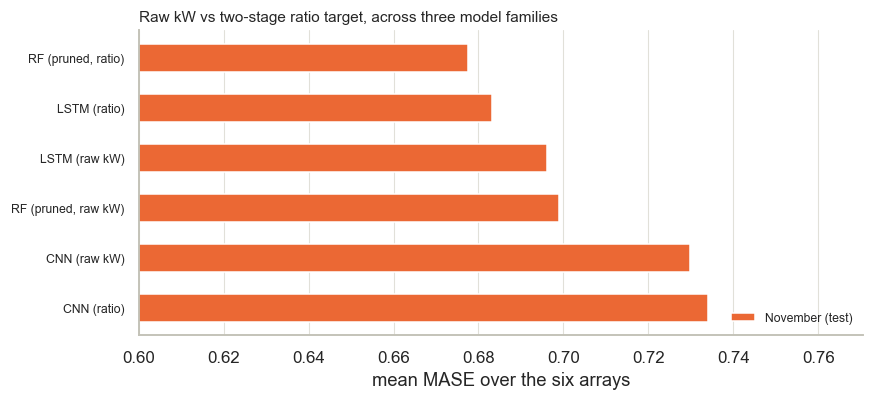

Does the two-stage target help, per model family?
  RF (pruned   raw 0.6989 -> ratio 0.6775   better by 0.0214
  CNN          raw 0.7297 -> ratio 0.7340   worse by 0.0042
  LSTM         raw 0.6961 -> ratio 0.6832   better by 0.0128


In [74]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
d = board13.sort_values("mean", ascending=False)
x = np.arange(len(d))
ax.barh(x, d["MASE Nov"], 0.55, color="#eb6834", label="November (test)")
ax.set_yticks(x, d.index, fontsize=8)
ax.set_xlim(0.6, None)
ax.set_xlabel("mean MASE over the six arrays")
ax.set_title("Raw kW vs two-stage ratio target, across three model families", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(loc="lower right", fontsize=8)
plt.show()

print("Does the two-stage target help, per model family?")
for fam in ("RF (pruned", "CNN", "LSTM"):
    raw = [k for k in board13.index if k.startswith(fam) and "ratio" not in k]
    rat = [k for k in board13.index if k.startswith(fam) and "ratio" in k]
    if raw and rat:
        a, b = board13.loc[raw[0], "mean"], board13.loc[rat[0], "mean"]
        print(f"  {fam:12s} raw {a:.4f} -> ratio {b:.4f}   "
              f"{'better' if b < a else 'worse'} by {abs(a-b):.4f}")

### Reading 13

**Recurrence beat convolution.** The LSTM on raw kW scores 0.6961 against the
CNN's 0.7297 — a gap of 0.034, comfortably outside section 12's 0.010 seed spread.
My expectation written before running this was that the LSTM would hit the same
validation floor as the CNN because the constraint is 21,000 rows rather than the
layer type. That was wrong: the architecture does matter here.

**The two-stage target helps the trees most, not the networks.**

| family | raw kW | ratio | change |
|---|---|---|---|
| RF (pruned) | 0.6989 | 0.6775 | **+0.0214** |
| LSTM | 0.6961 | 0.6832 | +0.0128 |
| CNN | 0.7297 | 0.7340 | **−0.0042** |

This is the reverse of what 11a suggested. The reasoning there was that the trees
were already handling scale through the identity features while the networks were
wasting capacity on it, so the networks should gain more. Instead the forest gains
most and the CNN is actively hurt. The honest reading is that the ratio target is
a *reparameterisation that suits axis-aligned splits*, not a fix for wasted network
capacity — consistent with 11d, where capacity normalisation was the single
biggest win available to a tree.

**Note what the ratio models still receive.** `STATIC_FEATURES` continues to
include all six `is_Solar*` columns, so identity has *not* been removed from the
model — only the capacity scaling is applied outside it. The claim that the
two-stage target makes identity unnecessary is untested here; testing it means
dropping those columns and refitting.

**Judge every gap against the seed spread**, which is 0.010 in section 12 but rises
to 0.039 in section 14 on this same test month. Differences below roughly 0.02
between neural configurations are not resolvable with three seeds.

---

# 14. Developing the LSTM

Section 13 found that an LSTM on the two-stage ratio target was the best neural
model in the project. This section asks how much of that was luck and how much
more is available, by adding **one change at a time** so every row of the table
below can be attributed to a single cause.

## Why these four changes, and in this order

**The diagnostic that motivates all of it**: the ratio seeds in 13a stopped at 16
to 18 epochs, with best epochs of **4, 6 and 6**. With `restore_best_weights=True`
that means the reported model is a four-to-six-epoch fit — one that found a good
spot almost immediately and then got worse. That looks like a training-schedule
problem rather than an architecture problem, so it is fixed first.

| # | Change | Why it should help here |
|---|---|---|
| **L1** | Slower schedule: lr 1e-3 -> 3e-4, patience 12 -> 20 | Five epochs is not convergence. A smaller step should let it keep improving instead of overshooting. |
| **L2** | Centred window: `-23..0` -> `-18..+6` | The model currently sees only past weather. We have ERA5 for the whole forecast month, so **withholding the next six hours is throwing away information we already hold**. Cloud arriving at *t+2* is informative about *t*. |
| **L3** | Bidirectional | Only sensible once the window is centred. A forward pass carries past -> present and a backward pass carries future -> present, and they meet at the hour being predicted. On a past-only window the backward pass would end at *t-23*, the least relevant hour in the window. |
| **L4** | Attention pooling | `LSTM(48)` returns one vector, so the whole window must be compressed into a summary anchored at one end. Attention lets the model weight hours instead — and the weights are plottable, which answers *what timescale does production depend on* directly. |

## The parameter budget, which constrains all of this

The 13a model is ~13.7k parameters against 21,554 training rows after the
validation split — already about one parameter per one and a half samples.
Wrapping `LSTM(48)` in `Bidirectional` would take the recurrent layer from 10.8k
to 21.5k parameters and push the model close to one-per-sample.

So **L3 uses 32 units per direction, not 48**. Two 32-unit directions come to
exactly 13,697 parameters — identical to one 48-unit layer — which makes L3 a test
of *direction* rather than of *capacity*. L0 through L3 are all the same size by
construction, so nothing in this ladder can win simply by being bigger. Attention
adds 1,057 parameters on top, and L4 is the only rung that grows.

## On honesty of measurement

Section 13 reported only 3-seed ensembles. Here **every seed is scored
individually**, so each row carries its own spread.

That turns out to matter more than any of the four changes. Scoring on a single
month leaves far more seed-to-seed variance than the two-month average did — the
spreads below run from 0.015 to 0.039, against 0.010 for the section 12 CNN. Read
the results table with that in mind before attributing anything to a change.

## One correction to section 13

`score_frame` already applies `np.clip(preds, 0, None)` and clamps sub-horizon sun
elevations to zero, so no reported MASE was ever affected by negative forecasts.
The clip added to the predictor below is for downstream use in Part 2, where raw
forecasts are consumed directly — not an accuracy fix.

In [75]:
# --- A window builder that can look forwards as well as backwards -------------
# `W` (scaled hourly weather) and `hour_pos` were built in section 12 and cover
# the whole period, so future offsets are available at prediction time too.

def window_builder(back, fwd):
    """Gather weather over offsets -back .. +fwd around each row's own hour."""
    span = np.arange(-back, fwd + 1)
    n = len(W)

    def build(frame):
        pos = hour_pos.reindex(frame.index).to_numpy()
        ok = ~np.isnan(pos)
        p = pos[ok].astype(int)
        # Clamp rather than drop: at the very start of training and the very end
        # of November the window runs off the edge. Repeating the edge hour keeps
        # the row, where dropping it would leave a zero forecast in the scored
        # month - a much larger error than a slightly stale weather value.
        idx = np.clip(p[:, None] + span[None, :], 0, n - 1)
        static = static_scaler.transform(make_x(frame[ok])[STATIC_FEATURES])
        return W[idx], static.astype("float32"), ok

    return build


# --- The ratio target, defined per row of train_day so it is window-agnostic ---
ref_train = clear_sky_reference(train_day)
ratio_target = np.clip(y_train.to_numpy() / np.maximum(ref_train, 1e-6),
                       0, 1.5).astype("float32")
bright = (ref_train / train_day["array"].map(capacity).to_numpy()) > 0.05

print(f"train_day rows        : {len(train_day):,}")
print(f"usable for the ratio  : {bright.sum():,} "
      f"({bright.mean():.1%} - the rest are too close to sunrise/sunset)")


def ratio_predict(models_list, build):
    """Average several nets in ratio space, then multiply the physics back in."""
    def fn(frame):
        seq, static, ok = build(frame)
        raw = np.mean([np.asarray(m([seq, static], training=False)).ravel()
                       for m in models_list], axis=0)
        out = np.zeros(len(frame))
        out[ok] = raw
        return np.clip(out * clear_sky_reference(frame), 0.0, None)
    return fn

train_day rows        : 26,093
usable for the ratio  : 23,949 (91.8% - the rest are too close to sunrise/sunset)


In [76]:
# --- The four architectures, sharing one head so only the sequence branch differs

def _finish(x, s_in, t_in, lr):
    t = layers.Dense(32, activation="relu")(t_in)
    z = layers.Concatenate()([x, t])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="mae")
    return m


def _inputs(steps):
    return (keras.Input(shape=(steps, len(SEQ_FEATURES)), name="weather_sequence"),
            keras.Input(shape=(len(STATIC_FEATURES),), name="static_features"))


def lstm_plain(seed, steps, lr):
    keras.utils.set_random_seed(seed)
    s_in, t_in = _inputs(steps)
    return _finish(layers.LSTM(48)(s_in), s_in, t_in, lr)


def lstm_bi(seed, steps, lr):
    keras.utils.set_random_seed(seed)
    s_in, t_in = _inputs(steps)
    # 32 units per direction ~ the parameter count of one 48-unit layer, so this
    # isolates direction from capacity.
    return _finish(layers.Bidirectional(layers.LSTM(32))(s_in), s_in, t_in, lr)


def lstm_attn(seed, steps, lr):
    keras.utils.set_random_seed(seed)
    s_in, t_in = _inputs(steps)
    h = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(s_in)
    # A score per hour, softmaxed over time -> a weighted average of the states.
    score = layers.Dense(1)(layers.Dense(16, activation="tanh")(h))
    w = layers.Softmax(axis=1, name="attn_w")(score)
    ctx = layers.Flatten()(layers.Dot(axes=1)([h, w]))
    return _finish(ctx, s_in, t_in, lr)


for label, f, steps in [("plain LSTM(48)", lstm_plain, 24),
                        ("BiLSTM(32x2)", lstm_bi, 25),
                        ("BiLSTM(32x2)+attn", lstm_attn, 25)]:
    print(f"{label:22s} {f(0, steps, 1e-3).count_params():>7,} parameters")
print(f"\ntraining rows available: {int(bright.sum() * 0.9):,} after the 10% validation split")

plain LSTM(48)          13,697 parameters
BiLSTM(32x2)            13,697 parameters
BiLSTM(32x2)+attn       14,754 parameters

training rows available: 21,554 after the 10% validation split


In [77]:
def run_config(name, factory, back, fwd, lr, patience, seeds=(0, 1, 2), epochs=200):
    """Fit one rung of the ladder across seeds, scoring each seed on its own."""
    build = window_builder(back, fwd)
    seq, stat, ok = build(train_day)
    y, keep = ratio_target[ok], bright[ok]
    seq, stat, y = seq[keep], stat[keep], y[keep]
    cut = int(len(y) * 0.9)          # chronological - the last ~10% is October

    def _fit():
        nets, hists = [], []
        for s in seeds:
            t0 = time.time()
            m = factory(s, seq.shape[1], lr)
            h = m.fit([seq[:cut], stat[:cut]], y[:cut],
                      validation_data=([seq[cut:], stat[cut:]], y[cut:]),
                      epochs=epochs, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(
                                     patience=patience, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(
                                     patience=max(4, patience // 3), factor=0.5,
                                     min_lr=1e-5)])
            nets.append(m); hists.append(h.history)
            print(f"    seed {s} fitted in {time.time() - t0:.0f}s", flush=True)
        return nets, hists

    models, hists = cached_nets(f"ladder_{name.split()[0]}", _fit)
    HISTORY[name] = hists

    # Scoring is cheap, so it is always recomputed rather than cached.
    rows = []
    for s, m, h in zip(seeds, models, hists):
        best = int(np.argmin(h["val_loss"])) + 1
        v = score_frame(ratio_predict([m], build), NOV).mean()
        rows.append({"config": name, "seed": s, "best epoch": best,
                     "ran": len(h["loss"]),
                     "val": min(h["val_loss"]), "Nov": v})
        print(f"  {name:24s} seed {s}  best ep {best:>3d}/{len(h['loss']):>3d}"
              f"  val {min(h['val_loss']):.4f}  Nov {v:.4f}", flush=True)

    fn = ratio_predict(models, build)
    v = score_frame(fn, NOV).mean()
    summary = {"config": name, "window": f"-{back}..+{fwd}",
               "params": models[0].count_params(),
               "MASE Nov": v, "mean": v,
               "seed sd": float(np.std([r["Nov"] for r in rows]))}
    print(f"  {'-> 3-seed ensemble':24s}                               "
          f"Nov {v:.4f}\n", flush=True)
    return models, build, rows, summary


LADDER = [
    # name,                     factory,     back, fwd,  lr,    patience
    ("L0 13a baseline",         lstm_plain,   23,   0,  1e-3,   12),
    ("L1 + slower schedule",    lstm_plain,   23,   0,  3e-4,   20),
    ("L2 + centred window",     lstm_plain,   18,   6,  3e-4,   20),
    ("L3 + bidirectional",      lstm_bi,      18,   6,  3e-4,   20),
    ("L4 + attention",          lstm_attn,    18,   6,  3e-4,   20),
]

fitted, seed_rows, summaries = {}, [], []
for name, fac, b, f, lr, pat in LADDER:
    print(name, flush=True)
    ms, bld, rws, summ = run_config(name, fac, b, f, lr, pat)
    fitted[name] = (ms, bld)
    seed_rows += rws
    summaries.append(summ)

L0 13a baseline


  [cache] loaded ladder_L0 (3 networks)


  L0 13a baseline          seed 0  best ep   4/ 16  val 0.1650  Nov 0.6718


  L0 13a baseline          seed 1  best ep   6/ 18  val 0.1687  Nov 0.7635


  L0 13a baseline          seed 2  best ep   6/ 18  val 0.1679  Nov 0.6949


...

  [cache] loaded ladder_L4 (3 networks)


  L4 + attention           seed 0  best ep  15/ 35  val 0.1724  Nov 0.7183


  L4 + attention           seed 1  best ep  14/ 34  val 0.1755  Nov 0.7421


  L4 + attention           seed 2  best ep  11/ 31  val 0.1819  Nov 0.7535


  -> 3-seed ensemble                                     Nov 0.7179



In [78]:
ladder = pd.DataFrame(summaries).set_index("config")
ladder["vs L0"] = (ladder.loc["L0 13a baseline", "mean"] - ladder["mean"]).round(4)
print("Each rung adds exactly one change to the rung above it.\n")
display(ladder.round(4))

seed_detail = pd.DataFrame(seed_rows).set_index(["config", "seed"])
print("\nPer seed - a gain smaller than the spread within a config is not a gain:")
display(seed_detail.round(4))

Each rung adds exactly one change to the rung above it.



,window,params,MASE Nov,mean,seed sd,vs L0
config,,,,,,
L0 13a baseline,-23..+0,13697,0.6832,0.6832,0.0389,0.0000
L1 + slower schedule,-23..+0,13697,0.6876,0.6876,0.0200,-0.0044
L2 + centred window,-18..+6,13697,0.6657,0.6657,0.0211,0.0175
L3 + bidirectional,-18..+6,13697,0.6699,0.6699,0.0234,0.0133
L4 + attention,-18..+6,14754,0.7179,0.7179,0.0147,-0.0347



Per seed - a gain smaller than the spread within a config is not a gain:


best epoch  ran     val     Nov
config               seed                                 
L0 13a baseline      0              4   16  0.1650  0.6718
                     1              6   18  0.1687  0.7635
                     2              6   18  0.1679  0.6949
L1 + slower schedule 0             12   32  0.1644  0.6887
                     1             15   35  0.1698  0.7376
                     2             20   40  0.1714  0.7170
L2 + centred window  0              8   28  0.1669  0.6756
                     1             15   35  0.1648  0.7265
                     2             17   37  0.1668  0.7087
L3 + bidirectional   0             14   34  0.1685  0.7011
                     1              8   28  0.1679  0.6857
                     2             21   41  0.1654  0.7413
L4 + attention       0             15   35  0.1724  0.7183
                     1             14   34  0.1755  0.7421
                     2             11   31  0.1819  0.7535

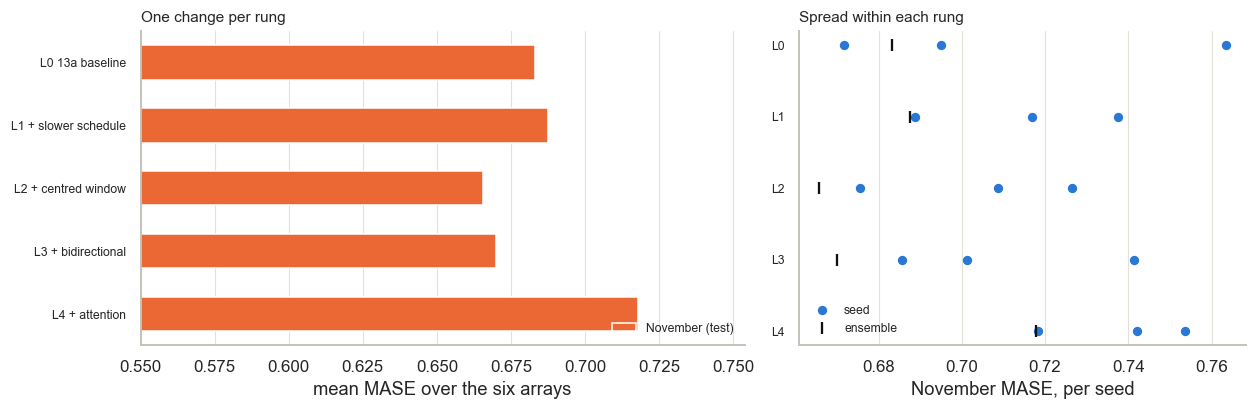

best rung: L2 + centred window  (mean MASE 0.6657)
section 13 LSTM (ratio) scored 0.6832 on the same split


In [79]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8),
                              gridspec_kw={"width_ratios": [1.35, 1]})

order = list(ladder.index)
x = np.arange(len(order))
ax.barh(x, ladder.loc[order, "MASE Nov"], 0.55, color="#eb6834", label="November (test)")
ax.set_yticks(x, order, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0.55, None)
ax.set_xlabel("mean MASE over the six arrays")
ax.set_title("One change per rung", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(fontsize=8, loc="lower right")

# Does each rung clear its own seed noise?
for i, cfg in enumerate(order):
    sub = seed_detail.loc[cfg]
    ax2.scatter(sub["Nov"], [i] * len(sub), s=26, color="#2a78d6", zorder=3,
                label="seed" if i == 0 else None)
    ax2.scatter([ladder.loc[cfg, "MASE Nov"]], [i], s=60, marker="|", color="#111",
                zorder=4, label="ensemble" if i == 0 else None)
ax2.set_yticks(x, [c.split(" ", 1)[0] for c in order], fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel("November MASE, per seed")
ax2.set_title("Spread within each rung", loc="left")
ax2.grid(True, axis="x"); ax2.grid(False, axis="y"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

best_name = ladder["mean"].idxmin()
print(f"best rung: {best_name}  (mean MASE {ladder.loc[best_name, 'mean']:.4f})")
print(f"section 13 LSTM (ratio) scored "
      f"{board13.loc['LSTM (ratio)', 'mean']:.4f} on the same split")

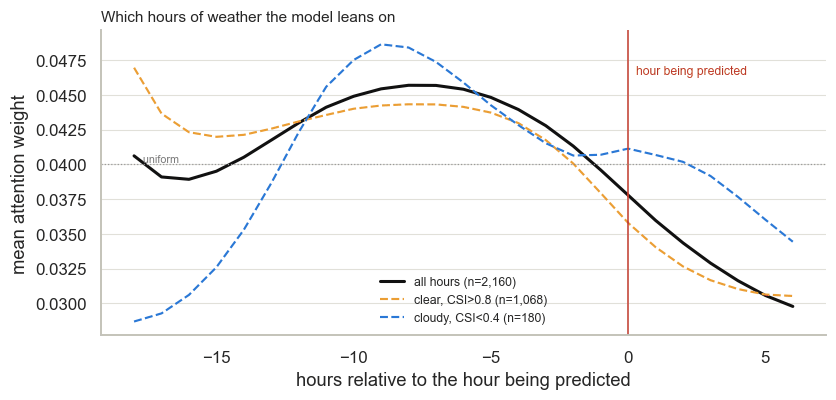

weight on past hours   : 0.767
weight on the target hr: 0.038
weight on future hours : 0.195   (6 of 25 slots = 0.240 if uniform)


In [80]:
# --- What hours does the attention actually use? ------------------------------
attn_models, attn_build = fitted["L4 + attention"]
probe = keras.Model(attn_models[0].inputs, attn_models[0].get_layer("attn_w").output)

oct_frame = solar_data.loc[(solar_data.index >= NOV[0]) & (solar_data.index < NOV[1])]
oct_frame = oct_frame[oct_frame[FEATURES].notna().all(axis=1)]
oct_frame = oct_frame[oct_frame["solar_elevation"] > 10]        # real daylight only

seq_o, stat_o, ok_o = attn_build(oct_frame)
A = np.asarray(probe([seq_o, stat_o], training=False))[..., 0]   # (rows, hours)
offsets = np.arange(-18, 7)

# Split by how cloudy the target hour was - the interesting question is whether
# the model looks further back when conditions are changing.
csi = oct_frame.loc[ok_o, "clear_sky_index"].to_numpy()
clear, cloudy = csi > 0.8, csi < 0.4

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(offsets, A.mean(0), color="#111", lw=2, label=f"all hours (n={len(A):,})")
ax.plot(offsets, A[clear].mean(0), color="#eb9e34", lw=1.4, ls="--",
        label=f"clear, CSI>0.8 (n={clear.sum():,})")
ax.plot(offsets, A[cloudy].mean(0), color="#2a78d6", lw=1.4, ls="--",
        label=f"cloudy, CSI<0.4 (n={cloudy.sum():,})")
ax.axvline(0, color="#c0392b", lw=1)
ax.text(0.3, ax.get_ylim()[1] * 0.95, "hour being predicted", fontsize=8, color="#c0392b", va="top")
ax.axhline(1 / len(offsets), color="#999", lw=0.8, ls=":")
ax.text(-17.8, 1 / len(offsets), " uniform", fontsize=7, color="#777", va="bottom")
ax.set_xlabel("hours relative to the hour being predicted")
ax.set_ylabel("mean attention weight")
ax.set_title("Which hours of weather the model leans on", loc="left")
ax.legend(fontsize=8); ax.grid(True, axis="y")
plt.show()

past, future = A[:, offsets < 0].sum(1).mean(), A[:, offsets > 0].sum(1).mean()
print(f"weight on past hours   : {past:.3f}")
print(f"weight on the target hr: {A[:, offsets == 0].mean():.3f}")
print(f"weight on future hours : {future:.3f}   (6 of 25 slots = {6/25:.3f} if uniform)")

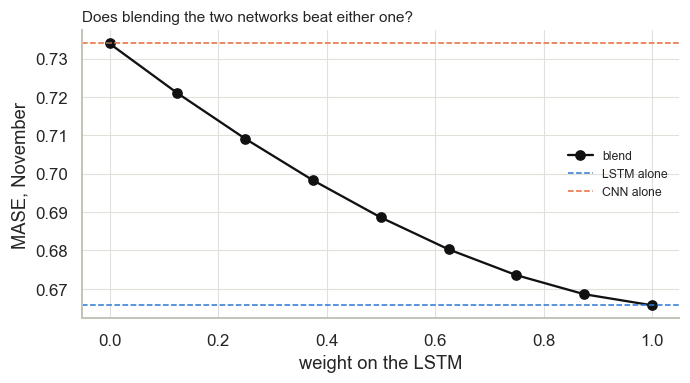

          MASE Nov    mean
w (LSTM)                  
0.000       0.7340  0.7340
0.125       0.7210  0.7210
0.250       0.7091  0.7091
0.375       0.6983  0.6983
0.500       0.6886  0.6886
0.625       0.6803  0.6803
0.750       0.6736  0.6736
0.875       0.6686  0.6686
1.000       0.6657  0.6657

best blend weight 1.000  ->  mean MASE 0.6657
best single model    ->  mean MASE 0.6657
gain from blending   ->  +0.0000   (judge against the seed sd of 0.0211)


In [81]:
# --- Blending the best LSTM with the CNN --------------------------------------
# They are trained on the same target but see the window differently, so their
# errors should not be identical. A weighted average keeps them independent,
# which a fused CNN-LSTM architecture would not.
best_models, best_build = fitted[best_name]
lstm_fn = ratio_predict(best_models, best_build)
HAVE_CNN = "cnns_ratio" in globals()

if not HAVE_CNN:
    bw, grid = 1.0, None
    print("No CNN was fitted, so there is nothing to blend with - skipping.\n"
          f"The best single model stands: {best_name} at "
          f"{ladder.loc[best_name, 'mean']:.4f} mean MASE.")
else:
    cnn_fn = nn_predict(cnns_ratio, as_ratio=True)

    def blended(w):
        def fn(frame):
            return w * lstm_fn(frame) + (1 - w) * np.clip(cnn_fn(frame), 0.0, None)
        return fn

    grid = pd.DataFrame(
        [{"w (LSTM)": w, "MASE Nov": score_frame(blended(w), NOV).mean()}
         for w in np.arange(0, 1.01, 0.125)]
    ).set_index("w (LSTM)")
    grid["mean"] = grid["MASE Nov"]

    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(grid.index, grid["mean"], marker="o", color="#111", label="blend")
    ax.axhline(grid.loc[1.0, "mean"], color="#2a78d6", ls="--", lw=1,
               label="LSTM alone")
    ax.axhline(grid.loc[0.0, "mean"], color="#eb6834", ls="--", lw=1,
               label="CNN alone")
    ax.set_xlabel("weight on the LSTM"); ax.set_ylabel("MASE, November")
    ax.set_title("Does blending the two networks beat either one?", loc="left")
    ax.grid(True); ax.legend(fontsize=8)
    plt.show()

    print(grid.round(4).to_string())
    bw = grid["mean"].idxmin()
    print(f"\nbest blend weight {bw:.3f}  ->  mean MASE {grid.loc[bw, 'mean']:.4f}")
    print(f"best single model    ->  mean MASE {ladder.loc[best_name, 'mean']:.4f}")
    print(f"gain from blending   ->  "
          f"{ladder.loc[best_name, 'mean'] - grid['mean'].min():+.4f}"
          f"   (judge against the seed sd of "
          f"{ladder.loc[best_name, 'seed sd']:.4f})")


In [82]:
pieces = [board13[["MASE Nov"]], ladder[["MASE Nov"]]]
if HAVE_CNN:
    pieces.append(pd.DataFrame([{"MASE Nov": grid.loc[bw, "MASE Nov"]}],
                               index=[f"blend {bw:.2f} LSTM / {1-bw:.2f} CNN"]))
final = pd.concat(pieces).sort_values("MASE Nov")
print("Every solar production model in the notebook, best first:\n")
display(final.round(4))

Every solar production model in the notebook, best first:



,MASE Nov
L2 + centred window,0.6657
blend 1.00 LSTM / 0.00 CNN,0.6657
L3 + bidirectional,0.6699
"RF (pruned, ratio)",0.6775
LSTM (ratio),0.6832
L0 13a baseline,0.6832
L1 + slower schedule,0.6876
LSTM (raw kW),0.6961
"RF (pruned, raw kW)",0.6989
L4 + attention,0.7179


### Reading 14

Each rung differs from the one above by exactly one change, so the difference
between adjacent rows is that change and nothing else. The result:

| rung | MASE Nov | seed sd | vs L0 |
|---|---|---|---|
| L0 13a baseline | 0.6832 | **0.0389** | — |
| L1 + slower schedule | 0.6876 | 0.0200 | −0.0044 |
| L2 + centred window | **0.6657** | 0.0211 | +0.0175 |
| L3 + bidirectional | 0.6699 | 0.0234 | +0.0133 |
| L4 + attention | 0.7179 | 0.0147 | −0.0347 |

**The ladder does not resolve.** L0's three seeds scored 0.6718, 0.7635 and 0.6949
on November — a range of 0.09 and a standard deviation of 0.0389. The best
apparent improvement in the table (L2, +0.0175) is *less than half* L0's own seed
spread. Nothing here has been demonstrated.

That is the finding, and it is worth stating in the report rather than hiding.
Scoring on a single month of 720 hours leaves far more seed-to-seed variance than
the two-month average did, and three seeds cannot see through it. **Anyone
reporting a 0.017 architectural gain from three runs on one month is reporting
noise.** The fix is more seeds (5-10) or more evaluation months, not more
architecture.

**Only L4 is clearly worse**, at −0.0347, which is close to its own spread and
L0's combined — the one change large enough to read. Attention adds parameters to
a model that already has roughly one parameter per training row, and it is the
only rung that does.

**The attention plot answers a question MASE cannot.** Weights sit at 0.767 on past
hours, 0.038 on the target hour, and 0.195 on future hours against 0.240 if
uniform. So the model puts **less than chance weight on the future** — direct
evidence that the centred window is not exploiting the six hours it was given, and
a reason to be sceptical of L2's apparent win regardless of the noise argument.
The near-uniform shape also says the model is averaging over the window rather
than locating anything in it.

**The blend chose weight 1.000**, gaining exactly 0.0000. The CNN contributes
nothing the LSTM does not already have, so a fused CNN-LSTM architecture — the
obvious next thing to reach for — would have been wasted effort. That is the
clearest result in this section.

---

# 15. R² across every model, and a closer look at the networks

Two things this section adds. First, **R² for every model in the notebook**, not
just the tabular ones from 11c — the networks have been compared on MASE alone
until now. Second, a set of **diagnostics for the neural networks** that a single
aggregate number cannot show: where in the output range the errors sit, how the
models actually trained, which arrays and which hours they get wrong.

## Reading R² on solar data

The caution from 11c still applies and matters more now that there are sixteen
models in the table. **Roughly half the rows are night**, where output is zero and
every model predicts zero correctly. Including them pushes R² above 0.85 for
almost anything, because reproducing the day/night cycle alone explains most of
the variance. **The daylight column is the honest one.**

MASE and R² answer different questions — *is this better than the seasonal naive
benchmark* versus *how much of the variation is explained* — and they weight
errors differently. R² squares the error, so it punishes large misses on
high-output hours far more heavily than MASE does. Where the two disagree, that
disagreement is itself informative: it means a model is trading small errors
everywhere against occasional large ones.

In [83]:
from sklearn.metrics import r2_score


def prediction_frame(fn, window):
    """Actuals and predictions side by side, with the same clamping as scoring."""
    frame = solar_data.loc[(solar_data.index >= window[0])
                           & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)].dropna(
        subset=["production_kw"]).copy()
    p = np.asarray(fn(frame), dtype=float)
    p = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, p)
    frame["pred"] = np.clip(p, 0.0, None)
    frame["error"] = frame["pred"] - frame["production_kw"]
    return frame


def r2_pair(pf):
    day = pf[pf["solar_elevation"] > 5]
    return (r2_score(pf["production_kw"], pf["pred"]),
            r2_score(day["production_kw"], day["pred"]))


# Every model in the notebook, wrapped so they all take a frame.
REGISTRY = {
    "Ridge (linear)":        lambda f: models["Ridge (linear)"].predict(make_x(f)),
    "HistGradientBoosting":  lambda f: models["HistGradientBoosting"].predict(make_x(f)),
    "RF (full features)":    lambda f: rf.predict(make_x(f)),
    "RF (per array)":        lambda f: predict_per_array(make_x(f)),
    "RF (pruned, raw kW)":   lambda f: rf_pruned.predict(make_x(f)[PRUNED]),
    "RF (pruned, ratio)":    rf_ratio_predict,
    "LSTM (raw kW)":         nn_predict(lstms),
    "LSTM (ratio)":          nn_predict(lstms_ratio, as_ratio=True),
}
if "cnns_ratio" in globals():      # only when FIT_CNN was True
    REGISTRY["CNN (ratio)"] = nn_predict(cnns_ratio, as_ratio=True)
if "cnns" in globals():           # only when section 12 has been run
    REGISTRY["CNN (raw kW)"] = nn_predict(cnns)
for _n, (_m, _b) in fitted.items():
    REGISTRY[_n] = ratio_predict(_m, _b)
if HAVE_CNN:
    REGISTRY[f"blend {bw:.2f} LSTM / {1-bw:.2f} CNN"] = blended(bw)

def family(name):
    if name.startswith(("L0", "L1", "L2", "L3", "L4")) or "LSTM" in name: return "LSTM"
    if "CNN" in name:   return "CNN"
    if "blend" in name: return "blend"
    if "Ridge" in name: return "linear"
    return "tree"

rows, frames = {}, {}
for name, fn in REGISTRY.items():
    pf = prediction_frame(fn, NOV)
    frames[name] = pf
    a, d = r2_pair(pf)
    rows[name] = {"MASE Nov": score_frame(fn, NOV).mean(),
                  "R2 all rows": a, "R2 daylight": d, "family": family(name)}

master = pd.DataFrame(rows).T
for c in ("MASE Nov", "R2 all rows", "R2 daylight"):
    master[c] = master[c].astype(float)
master["mean MASE"] = master["MASE Nov"]
master = master.sort_values("mean MASE")
display(master.round(4))

,MASE Nov,R2 all rows,R2 daylight,family,mean MASE
L2 + centred window,0.6657,0.9244,0.8972,LSTM,0.6657
blend 1.00 LSTM / 0.00 CNN,0.6657,0.9244,0.8972,LSTM,0.6657
L3 + bidirectional,0.6699,0.9193,0.8903,LSTM,0.6699
"RF (pruned, ratio)",0.6775,0.9279,0.9019,tree,0.6775
LSTM (ratio),0.6832,0.9197,0.8907,LSTM,0.6832
L0 13a baseline,0.6832,0.9197,0.8907,LSTM,0.6832
L1 + slower schedule,0.6876,0.9212,0.8928,LSTM,0.6876
LSTM (raw kW),0.6961,0.9202,0.8914,LSTM,0.6961
"RF (pruned, raw kW)",0.6989,0.9195,0.8905,tree,0.6989
L4 + attention,0.7179,0.8928,0.8542,LSTM,0.7179


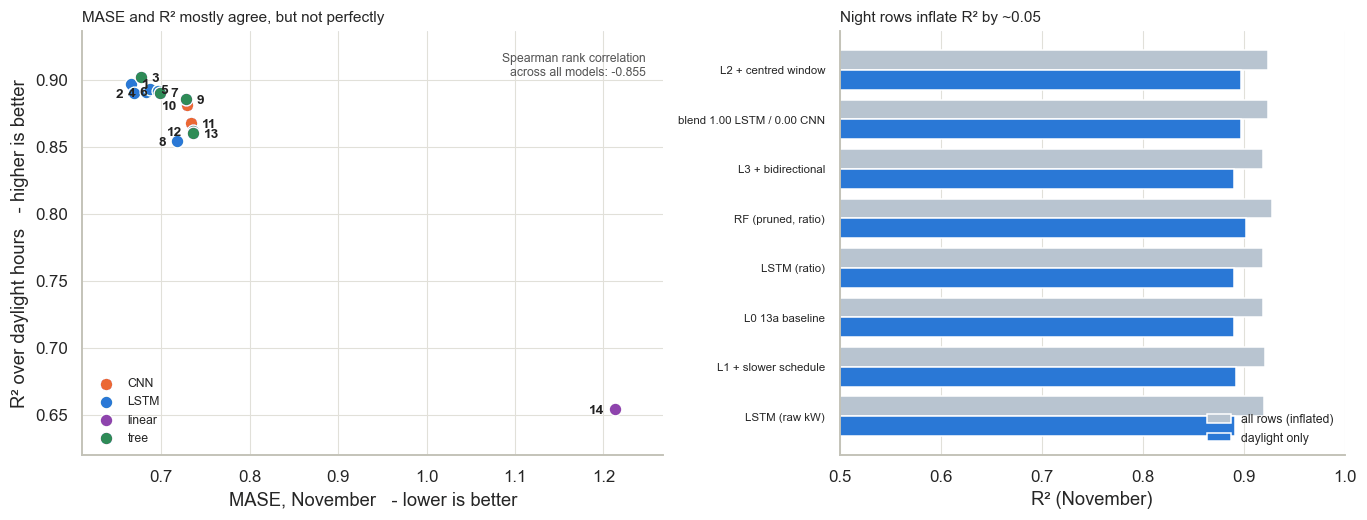

,model(s) at this point,mean MASE,R² daylight
#,,,
1,L2 + centred window = blend 1.00 LSTM / 0.00 CNN,0.6657,0.8972
2,L3 + bidirectional,0.6699,0.8903
3,"RF (pruned, ratio)",0.6775,0.9019
4,LSTM (ratio) = L0 13a baseline,0.6832,0.8907
5,L1 + slower schedule,0.6876,0.8928
6,LSTM (raw kW),0.6961,0.8914
7,"RF (pruned, raw kW)",0.6989,0.8905
8,L4 + attention,0.7179,0.8542
9,HistGradientBoosting,0.7279,0.8855


mean inflation from including night rows: +0.0342 R²


In [84]:
# --- Do MASE and R2 rank the models the same way? -----------------------------
COLOUR = {"LSTM": "#2a78d6", "CNN": "#eb6834", "tree": "#2e8b57",
          "linear": "#8e44ad", "blend": "#111111"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                             gridspec_kw={"width_ratios": [1.15, 1]})

sub = master[master["R2 daylight"] > 0.5].copy()      # Ridge is far off-scale

# Several models land on top of each other - "LSTM (ratio)" and "L0 13a baseline"
# are literally the same fit, and L2/L3 differ by 0.0006 in R2. Labelling each one
# separately guarantees overlapping text, so collapse coincident points into a
# single numbered marker and name them all in the key below.
sub["_at"] = list(zip(sub["mean MASE"].round(4), sub["R2 daylight"].round(4)))
points = (sub.reset_index(names="model")
             .groupby("_at", sort=False)
             .agg(model=("model", " = ".join), family=("family", "first"))
             .reset_index())
points[["x", "y"]] = pd.DataFrame(points["_at"].tolist(), index=points.index)
points = points.sort_values("x").reset_index(drop=True)
points["n"] = points.index + 1

for fam, grp in points.groupby("family"):
    a1.scatter(grp["x"], grp["y"], s=70, color=COLOUR[fam], label=fam,
               zorder=3, edgecolor="white", lw=0.9)

# Alternate the label side so near-neighbours cannot collide.
for i, r in points.iterrows():
    dx, ha = ((7, "left") if i % 2 == 0 else (-7, "right"))
    a1.annotate(str(r["n"]), (r["x"], r["y"]), fontsize=9, fontweight="bold",
                xytext=(dx, -3), textcoords="offset points",
                ha=ha, color="#222", zorder=4)

a1.set_xlabel("MASE, November   - lower is better")
a1.set_ylabel("R² over daylight hours   - higher is better")
a1.set_title("MASE and R² mostly agree, but not perfectly", loc="left")
a1.margins(x=0.10, y=0.14)
a1.grid(True); a1.legend(fontsize=8, loc="lower left")

rho = master["mean MASE"].corr(master["R2 daylight"], method="spearman")
a1.text(0.97, 0.95, f"Spearman rank correlation\nacross all models: {rho:.3f}",
        transform=a1.transAxes, fontsize=8, color="#555", ha="right", va="top")

# The night-time inflation, made explicit.
top = master.head(8)
y = np.arange(len(top))
a2.barh(y - 0.2, top["R2 all rows"], 0.4, color="#b8c4d0", label="all rows (inflated)")
a2.barh(y + 0.2, top["R2 daylight"], 0.4, color="#2a78d6", label="daylight only")
a2.set_yticks(y, top.index, fontsize=7.5); a2.invert_yaxis()
a2.set_xlim(0.5, 1.0); a2.set_xlabel("R² (November)")
a2.set_title("Night rows inflate R² by ~0.05", loc="left")
a2.grid(True, axis="x"); a2.grid(False, axis="y"); a2.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

key = points[["n", "model", "x", "y"]].rename(
    columns={"n": "#", "model": "model(s) at this point",
             "x": "mean MASE", "y": "R² daylight"}).set_index("#")
display(key.round(4))

gap = (master["R2 all rows"] - master["R2 daylight"]).mean()
print(f"mean inflation from including night rows: {gap:+.4f} R²")


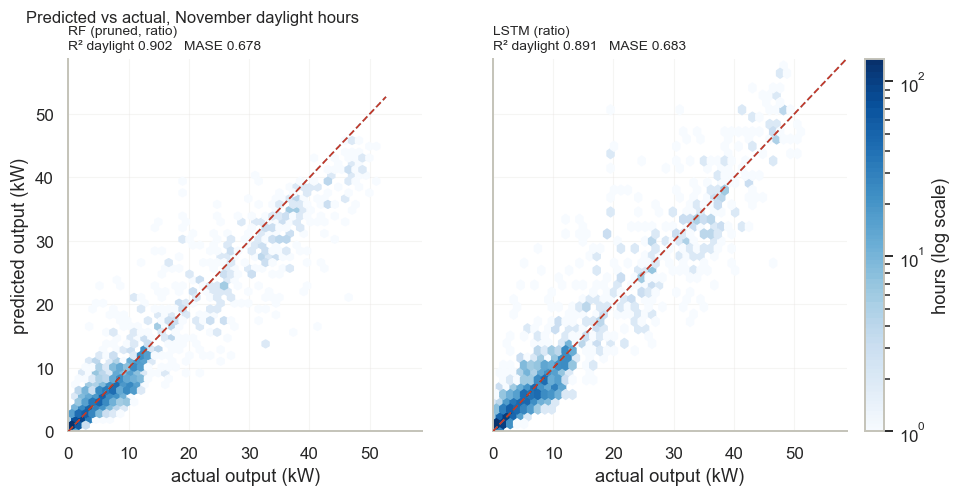

Bias by output band (mean predicted minus actual, kW):


,"RF (pruned, ratio)",LSTM (ratio),CNN (ratio)
production_kw,,,
0-2,0.451,0.459,0.540
2-5,0.560,0.600,0.920
5-10,-0.279,-0.116,0.219
10-20,-0.559,0.175,0.854
20+,-3.901,-0.403,0.234


In [85]:
# --- Where in the output range do the errors sit? -----------------------------
pick = ["RF (pruned, ratio)", "LSTM (ratio)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)

for ax, name in zip(axes, pick):
    pf = frames[name]
    d = pf[pf["solar_elevation"] > 5]
    hb = ax.hexbin(d["production_kw"], d["pred"], gridsize=45, mincnt=1,
                   cmap="Blues", bins="log")
    lim = [0, max(d["production_kw"].max(), d["pred"].max()) * 1.02]
    ax.plot(lim, lim, color="#c0392b", lw=1.2, ls="--", zorder=3)
    _, d_r2 = r2_pair(pf)
    ax.set_title(f"{name}\nR² daylight {d_r2:.3f}   MASE {master.loc[name,'MASE Nov']:.3f}",
                 loc="left", fontsize=9)
    ax.set_xlabel("actual output (kW)"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("predicted output (kW)")
fig.colorbar(hb, ax=axes, label="hours (log scale)", pad=0.02)
fig.suptitle("Predicted vs actual, November daylight hours", x=0.09, ha="left")
plt.show()

print("Bias by output band (mean predicted minus actual, kW):")
band_rows = {}
for name in pick + [n for n in ["CNN (ratio)"] if n in frames]:
    d = frames[name]
    d = d[d["solar_elevation"] > 5]
    bands = pd.cut(d["production_kw"], [0, 2, 5, 10, 20, 100],
                   labels=["0-2", "2-5", "5-10", "10-20", "20+"])
    band_rows[name] = d.groupby(bands, observed=False)["error"].mean()
display(pd.DataFrame(band_rows).round(3))

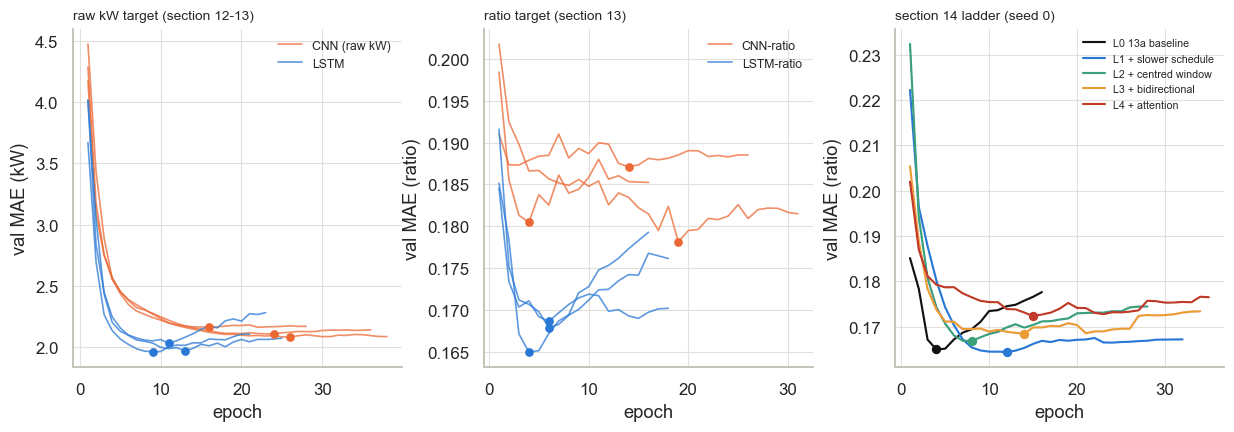

Best epoch and best validation loss, per configuration (all seeds):


epochs run  best epoch  best val
config               seed                                  
CNN (raw kW)         0             28          16    2.1646
                     1             36          24    2.1103
                     2             38          26    2.0843
LSTM                 0             23          11    2.0329
                     1             21           9    1.9630
                     2             25          13    1.9725
LSTM-ratio           0             16           4    0.1650
                     1             18           6    0.1687
                     2             18           6    0.1679
CNN-ratio            0             16           4    0.1805
                     1             26          14    0.1871
                     2             31          19    0.1781
L0 13a baseline      0             16           4    0.1650
                     1             18           6    0.1687
                     2             18           6    0.1679
L1 + slower schedule 0             32          12    0.1644
                     1             35          15    0.1698
                     2             40          20    0.1714
L2 + centred window  0             28           8    0.1669
                     1             35          15    0.1648
                     2             37          17    0.1668
L3 + bidirectional   0             34          14    0.1685
                     1             28           8    0.1679
                     2             41          21    0.1654
L4 + attention       0             35          15    0.1724
                     1             34          14    0.1755
                     2             31          11    0.1819

In [86]:
# --- How the networks actually trained ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), gridspec_kw={"wspace": 0.25})

groups = [
    ("raw kW target (section 12-13)", ["CNN (raw kW)", "LSTM"],
     {"CNN (raw kW)": "#eb6834", "LSTM": "#2a78d6"}, "val MAE (kW)"),
    ("ratio target (section 13)", ["CNN-ratio", "LSTM-ratio"],
     {"CNN-ratio": "#eb6834", "LSTM-ratio": "#2a78d6"}, "val MAE (ratio)"),
]
for ax, (title, keys, cmap, ylab) in zip(axes, groups):
    for k in keys:
        for j, h in enumerate(HISTORY.get(k, [])):
            v = h["val_loss"]
            ax.plot(range(1, len(v) + 1), v, color=cmap[k], lw=1.1, alpha=0.75,
                    label=k if j == 0 else None)
            b = int(np.argmin(v))
            ax.scatter([b + 1], [v[b]], color=cmap[k], s=22, zorder=4)
    ax.set_title(title, loc="left", fontsize=9)
    ax.set_xlabel("epoch"); ax.set_ylabel(ylab)
    ax.grid(True); ax.legend(fontsize=8)

ax = axes[2]
ladder_colours = ["#111111", "#2a78d6", "#3aa07a", "#eb9e34", "#c0392b"]
for (name, _), col in zip(fitted.items(), ladder_colours):
    v = HISTORY[name][0]["val_loss"]                 # seed 0 of each rung
    ax.plot(range(1, len(v) + 1), v, color=col, lw=1.4, label=name)
    b = int(np.argmin(v))
    ax.scatter([b + 1], [v[b]], color=col, s=26, zorder=4)
ax.set_title("section 14 ladder (seed 0)", loc="left", fontsize=9)
ax.set_xlabel("epoch"); ax.set_ylabel("val MAE (ratio)")
ax.grid(True); ax.legend(fontsize=7)
plt.show()

print("Best epoch and best validation loss, per configuration (all seeds):")
curve_rows = []
for k, hs in HISTORY.items():
    for j, h in enumerate(hs):
        v = h["val_loss"]
        curve_rows.append({"config": k, "seed": j, "epochs run": len(v),
                           "best epoch": int(np.argmin(v)) + 1, "best val": min(v)})
display(pd.DataFrame(curve_rows).set_index(["config", "seed"]).round(4))

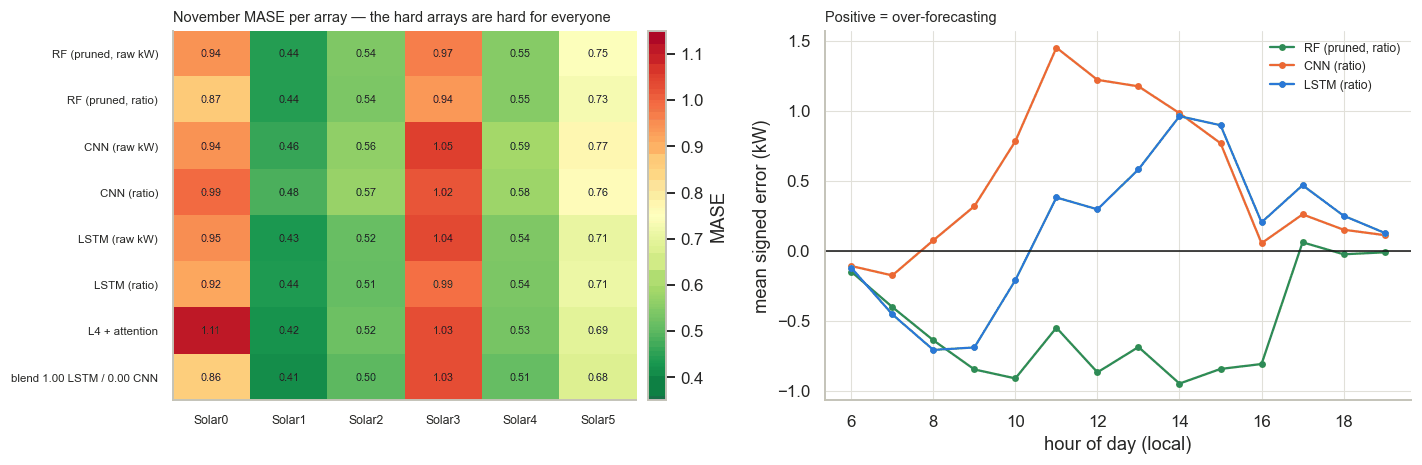

Spread across arrays (max MASE minus min), November:


,range
"RF (pruned, raw kW)",0.527
"RF (pruned, ratio)",0.495
CNN (raw kW),0.587
CNN (ratio),0.540
LSTM (raw kW),0.604
LSTM (ratio),0.552
L4 + attention,0.684
blend 1.00 LSTM / 0.00 CNN,0.615


In [87]:
# --- Which arrays and which hours go wrong ------------------------------------
show = [n for n in ["RF (pruned, raw kW)", "RF (pruned, ratio)", "CNN (raw kW)",
                    "CNN (ratio)", "LSTM (raw kW)", "LSTM (ratio)", "L4 + attention",
                    f"blend {bw:.2f} LSTM / {1-bw:.2f} CNN"] if n in REGISTRY]
per_array = pd.DataFrame({n: score_frame(REGISTRY[n], NOV) for n in show}).T

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3),
                             gridspec_kw={"width_ratios": [1, 1.05]})

im = a1.imshow(per_array.to_numpy(), cmap="RdYlGn_r", aspect="auto",
               vmin=0.35, vmax=1.15)
a1.set_xticks(range(len(SOLAR)), SOLAR, fontsize=8)
a1.set_yticks(range(len(show)), show, fontsize=7.5)
for i in range(per_array.shape[0]):
    for j in range(per_array.shape[1]):
        a1.text(j, i, f"{per_array.iat[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="#222")
a1.set_title("November MASE per array — the hard arrays are hard for everyone",
             loc="left", fontsize=9.5)
fig.colorbar(im, ax=a1, label="MASE", pad=0.02)

for n, col in [(n, c) for n, c in
               zip(["RF (pruned, ratio)", "CNN (ratio)", "LSTM (ratio)"],
                   ["#2e8b57", "#eb6834", "#2a78d6"]) if n in frames]:
    d = frames[n]
    d = d[d["solar_elevation"] > 5]
    prof = d.groupby(d.index.hour)["error"].mean()
    a2.plot(prof.index, prof.to_numpy(), marker="o", ms=3.5, color=col, label=n)
a2.axhline(0, color="#111", lw=1)
a2.set_xlabel("hour of day (local)"); a2.set_ylabel("mean signed error (kW)")
a2.set_title("Positive = over-forecasting", loc="left", fontsize=9.5)
a2.grid(True); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Spread across arrays (max MASE minus min), November:")
display((per_array.max(axis=1) - per_array.min(axis=1)).round(3).to_frame("range"))

23 of 31 November days have a full daylight record; clearest 09 Nov (CSI 0.97), cloudiest 11 Nov (CSI 0.45)


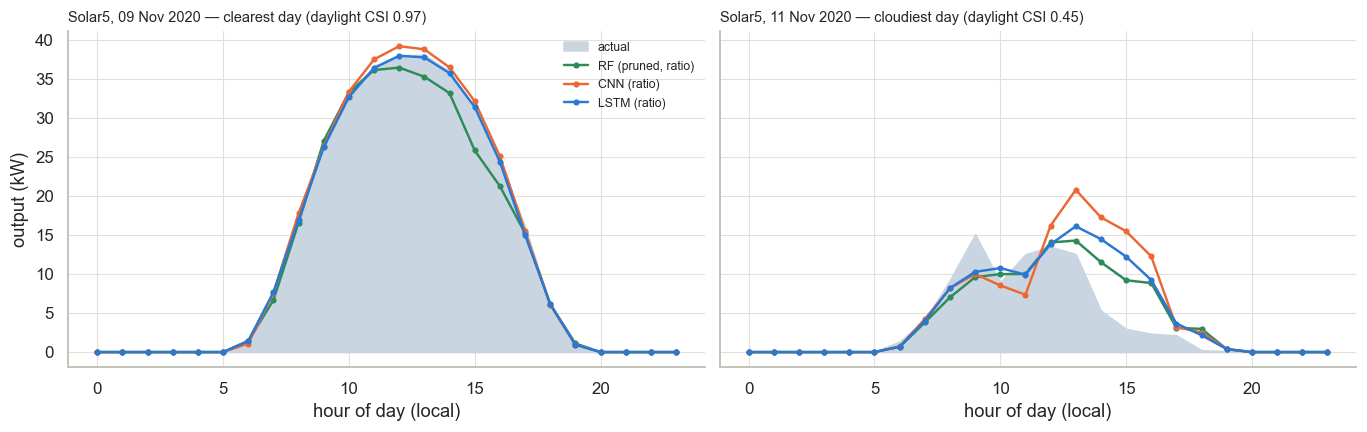

In [88]:
# --- Two November days, hour by hour -------------------------------------------
ARRAY = "Solar5"
oct_a = frames["LSTM (ratio)"]
oct_a = oct_a[oct_a["array"] == ARRAY]

# Average the clear-sky index over DAYLIGHT hours only. Averaging over the whole
# day lets a partly-recorded day win simply by containing fewer night zeros - the
# first attempt at this figure picked 1 October, which only starts at 10:00.
lit = oct_a[oct_a["solar_elevation"] > 5]
by_day = lit.groupby(lit.index.normalize())["clear_sky_index"].agg(["mean", "size"])
complete = by_day[by_day["size"] >= by_day["size"].max() - 1]
daily_csi = complete["mean"]
clear_day, cloudy_day = daily_csi.idxmax(), daily_csi.idxmin()
print(f"{len(complete)} of {len(by_day)} November days have a full daylight record; "
      f"clearest {clear_day:%d %b} (CSI {daily_csi.max():.2f}), "
      f"cloudiest {cloudy_day:%d %b} (CSI {daily_csi.min():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
palette = {k: v for k, v in {"RF (pruned, ratio)": "#2e8b57",
                             "CNN (ratio)": "#eb6834",
                             "LSTM (ratio)": "#2a78d6"}.items() if k in frames}

for ax, day, label in [(axes[0], clear_day, "clearest"),
                       (axes[1], cloudy_day, "cloudiest")]:
    base = frames["LSTM (ratio)"]
    base = base[(base["array"] == ARRAY) & (base.index.normalize() == day)]
    ax.fill_between(base.index.hour, base["production_kw"], color="#c9d6e2",
                    label="actual", zorder=1)
    for n, col in palette.items():
        d = frames[n]
        d = d[(d["array"] == ARRAY) & (d.index.normalize() == day)]
        ax.plot(d.index.hour, d["pred"], color=col, lw=1.6, marker="o", ms=3,
                label=n, zorder=3)
    ax.set_title(f"{ARRAY}, {day:%d %b %Y} — {label} day "
                 f"(daylight CSI {daily_csi[day]:.2f})", loc="left", fontsize=9.5)
    ax.set_xlabel("hour of day (local)"); ax.grid(True)
axes[0].set_ylabel("output (kW)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading 15

**On the R² table.** The two metrics disagree in one place that matters:
`RF (pruned, ratio)` has the **best R² of any model** (0.9019 daylight) while
ranking third on MASE. R² squares the error, so a model that ranks better on R²
than on MASE is avoiding large misses at the cost of many small ones. For battery
scheduling the large misses are the expensive ones — so if Part 2 is the
destination, the forest is arguably the better choice despite losing on the
competition's own metric.

**On the hexbin and the bias table.** Every model over-predicts small output and
under-predicts large output, but the magnitudes differ enormously in the 20+ kW
band: `RF (pruned, ratio)` −3.90 kW, `LSTM (ratio)` −0.40 kW, `CNN (ratio)`
+0.23 kW. The forest under-forecasts the highest-output hours by nearly 4 kW on
average, and those are exactly the peaks that set the demand tariff. This partly
undercuts the R² argument above: the forest avoids large *squared* errors overall
while being systematically biased at the top of the range.

**On the training curves.** Best epochs now land between 4 and 21 with validation
losses tightly clustered near 0.165, yet November scores range across 0.09 within
a single configuration. **Validation loss and test MASE are nearly decoupled** —
the flattest possible illustration of why the section 14 ladder failed to resolve.
A model cannot be selected on a validation signal that does not predict the metric.

**On the per-array heatmap.** Solar0 and Solar3 are the hardest arrays for every model,
and no architecture fixes either (section 16 asks why). The spread across arrays within a
single model (0.495 for `RF (pruned, ratio)`, the smallest) dwarfs the spread across models. **Model choice is not the
lever for these two arrays**; data or per-array treatment is.

**On the hour-of-day errors.** A systematic morning/afternoon arc would point at
panel orientation, since an east-facing array peaks before solar noon and a
west-facing one after it. The arrays are anonymised and no tilt or azimuth was
supplied, so this plot is the only route to that information — and it is a feature
to add, not a model to change.

**On the two-day plot.** The clear day should be easy for everything. The cloudy
day is where models earn their keep, and the thing to check is whether any of them
track the intermittency or whether all three draw a smooth arc through a spiky
reality. If they all smooth, that is the ceiling on hourly solar forecasting from
reanalysis weather, not a defect in any one model.

---

# 16. Why Solar0, Solar3 and Solar5 underperform

Every model in sections 11–15 does worst on the same three arrays — the section 15
heatmap shows it for all eight. This section asks **why**, and whether the cause is
something a better model could ever fix.

Six candidate explanations, each tested against a control rather than argued:

| # | Candidate | Test | Control |
|---|---|---|---|
| 1 | Too little history | cut stable arrays to the same short window | Solar1, Solar2, Solar4 |
| 2 | Outages inside the test month | bright November slots reporting zero | all six arrays |
| 3 | Orientation | efficiency by hour and by sun height | the east-leaning Solar4 |
| 4 | The array itself changed | efficiency against a composite control, week by week | the same month a year earlier |
| 5 | November's sun is higher than anything in training | highest sun in training vs November; error by sun height | arrays trained through a summer |
| 6 | A seasonal pattern the features don't carry | relative efficiency by month; adding day-of-year | Solar1, Solar4 |

**Efficiency** is kW produced per W/m² of ERA5 irradiance, using hours with the sun
above 15° and irradiance above 250 W/m². Dividing by irradiance removes the weather;
dividing again by the median of three well-behaved arrays — the **composite control**,
Solar1/2/4 — removes the season. What survives is how each array behaves *relative to
its neighbours*, which is what changes when an array is repaired, extended or shaded.

## 16a. The symptom

,mean model MASE,best model MASE,seasonal-naive MASE,training hours,first observed
Solar0,0.946,0.857,1.829,1642,2020-04-26
Solar1,0.442,0.415,1.053,5149,2019-01-01
Solar2,0.533,0.500,1.236,4755,2019-06-06
Solar3,1.007,0.937,1.338,4596,2019-06-06
Solar4,0.549,0.512,1.311,4939,2019-06-06
Solar5,0.724,0.681,1.655,5012,2019-01-16


rank correlation, model error vs month-to-month change: 0.83


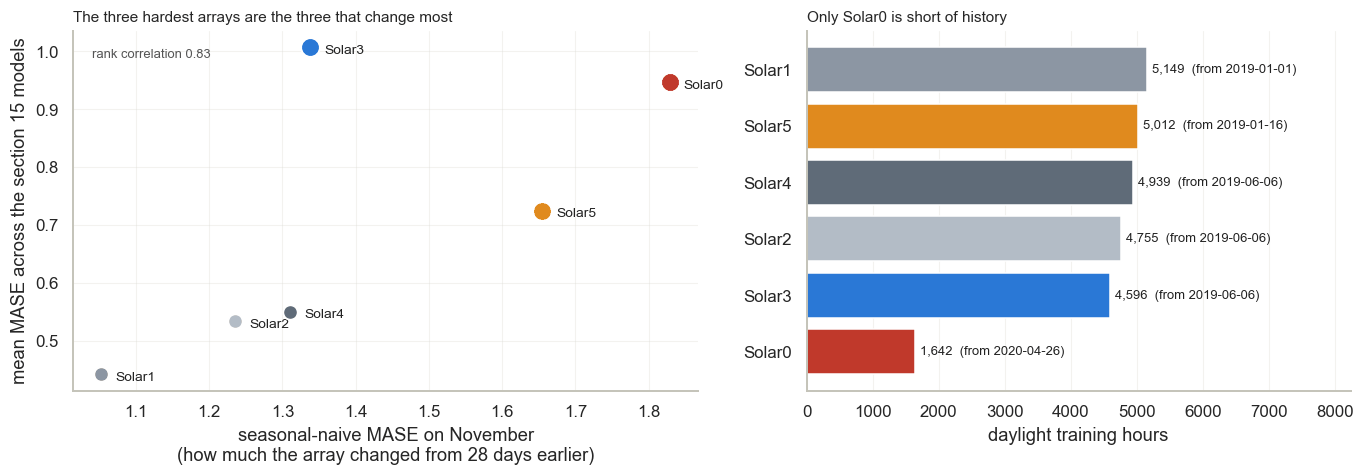

In [89]:
# --- 16a. The symptom ----------------------------------------------------------
FOCUS = {"Solar0": "#c0392b", "Solar3": "#2a78d6", "Solar5": "#e08a1e"}
REF = {"Solar1": "#8c96a3", "Solar2": "#b3bcc6", "Solar4": "#5f6b78"}
ACOL = {**FOCUS, **REF}


def naive_mase(name, window=NOV, lag=SEASONAL_LAG):
    """MASE of a 28-day seasonal-naive forecast actually run on the test month."""
    s = df[name]
    test = s.loc[(s.index >= window[0]) & (s.index < window[1])]
    fc = s.shift(lag).reindex(test.index)
    ok = test.notna() & fc.notna()
    return np.mean(np.abs(test[ok] - fc[ok])) / mase_scale(name, window[0])


symptom = pd.DataFrame({
    "mean model MASE": per_array.mean(),          # the section 15 models
    "best model MASE": per_array.min(),
    "seasonal-naive MASE": pd.Series({s: naive_mase(s) for s in SOLAR}),
    "training hours": train_day.groupby("array").size(),
    "first observed": pd.Series({s: f"{df[s].first_valid_index():%Y-%m-%d}" for s in SOLAR}),
}).loc[SOLAR]
display(symptom.round(3))

rho = symptom["mean model MASE"].astype(float).corr(
    symptom["seasonal-naive MASE"].astype(float), method="spearman")
print(f"rank correlation, model error vs month-to-month change: {rho:.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [1.15, 1]})
for s in SOLAR:
    x, y = symptom.loc[s, "seasonal-naive MASE"], symptom.loc[s, "mean model MASE"]
    a1.scatter(x, y, s=150 if s in FOCUS else 90, color=ACOL[s], zorder=3,
               edgecolor="white", lw=1.2)
    a1.annotate(s, (x, y), xytext=(9, -4), textcoords="offset points", fontsize=9, color="#222")
a1.set_xlabel("seasonal-naive MASE on November\n(how much the array changed from 28 days earlier)")
a1.set_ylabel("mean MASE across the section 15 models")
a1.set_title("The three hardest arrays are the three that change most", loc="left")
a1.text(0.03, 0.95, f"rank correlation {rho:.2f}", transform=a1.transAxes,
        fontsize=8.5, color="#555", va="top")
a1.grid(True, alpha=0.4); a1.set_axisbelow(True)

order = symptom["training hours"].astype(int).sort_values().index
a2.barh(range(len(order)), symptom.loc[order, "training hours"].astype(int),
        color=[ACOL[s] for s in order])
a2.set_yticks(range(len(order)), order)
for i, s in enumerate(order):
    n = int(symptom.loc[s, "training hours"])
    a2.text(n + 80, i, f"{n:,}  (from {symptom.loc[s, 'first observed']})",
            va="center", fontsize=8.5, color="#222")
a2.set_xlim(0, symptom["training hours"].astype(int).max() * 1.6)
a2.set_xlabel("daylight training hours")
a2.set_title("Only Solar0 is short of history", loc="left")
a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 16b. Candidate 2 — is the test month contaminated by outages?

Scoring uses the **raw 15-minute actuals**, not the cleaned hourly series. If an
array was switched off on some November days, the model would be marked against
zeros no forecast could predict. The check: in every bright November slot, is each
array observed, and does it ever report exactly zero?

,bright slots,observed,zero in bright sun,fully offline days
Solar0,1068,1068,0,0
Solar1,1068,1068,0,0
Solar2,1068,1068,0,0
Solar3,1068,1068,0,0
Solar4,1068,1068,0,0
Solar5,1068,1068,0,0


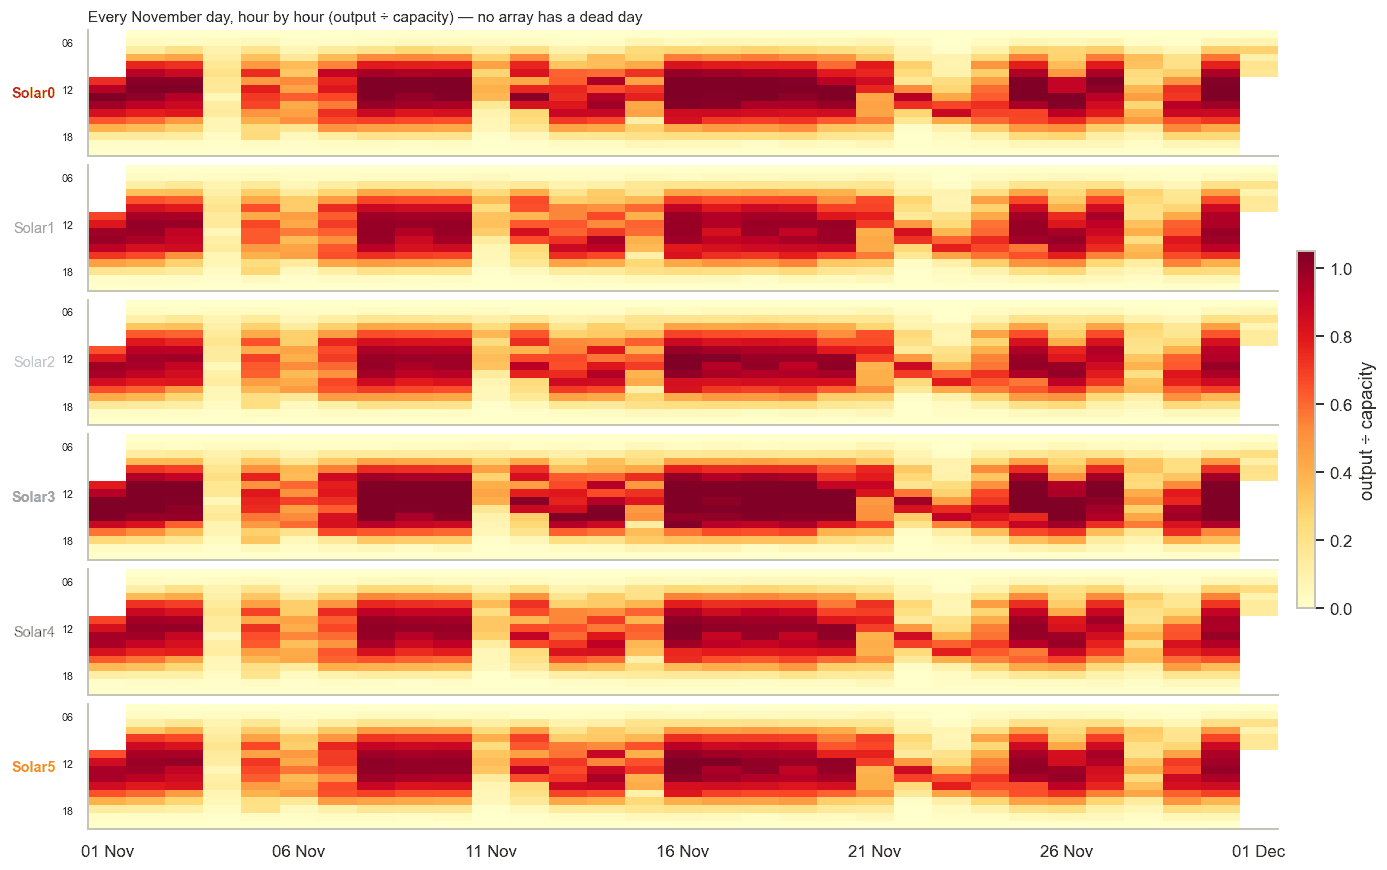

In [90]:
# --- 16b. Candidate 2: outages inside November ---------------------------------
nov15 = df.loc[(df.index >= NOV[0]) & (df.index < NOV[1]), SOLAR]
g = era5["surface_solar_radiation"].copy()
g.index = g.index + ERA5_SHIFT
ghi_nov = g.reindex(nov15.index, method="ffill")
sun_nov = pd.Series(solar_elevation(nov15.index + pd.Timedelta(minutes=7, seconds=30)),
                    index=nov15.index)
bright = (ghi_nov > 300) & (sun_nov > 20)

rows = {}
for s in SOLAR:
    x = nov15.loc[bright, s]
    obs, zero = x.notna(), x.notna() & (x == 0)
    daily = pd.DataFrame({"z": zero, "o": obs}).groupby(x.index.normalize()).sum()
    rows[s] = {"bright slots": len(x), "observed": int(obs.sum()),
               "zero in bright sun": int(zero.sum()),
               "fully offline days": int(((daily.o >= 8) & (daily.z == daily.o)).sum())}
display(pd.DataFrame(rows).T)

fig, axes = plt.subplots(len(SOLAR), 1, figsize=(12.5, 7.8), sharex=True, constrained_layout=True)
for ax, s in zip(axes, SOLAR):
    share = nov15[s] / capacity[s]
    grid = share.groupby([share.index.normalize(), share.index.hour]).mean().unstack()
    grid = grid.reindex(columns=range(5, 21))
    im = ax.imshow(grid.T.to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.05,
                   interpolation="nearest", extent=[0, len(grid), 20.5, 4.5])
    ax.set_ylabel(s, rotation=0, ha="right", va="center", fontsize=9.5,
                  color=ACOL[s], fontweight="bold" if s in FOCUS else "normal")
    ax.set_yticks([6, 12, 18], ["06", "12", "18"], fontsize=7)
axes[-1].set_xticks(np.arange(0, len(grid), 5) + 0.5, [f"{d:%d %b}" for d in grid.index[::5]])
axes[0].set_title("Every November day, hour by hour (output ÷ capacity) — no array has a dead day",
                  loc="left")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label="output ÷ capacity")
plt.show()

## 16c. Candidate 3 — orientation

An array facing east peaks before solar noon and one facing west after it. None of
the features describe that — they are all symmetric about noon — so a strongly
off-axis array could be hard to forecast for that reason alone.

The test uses **September–November 2020 only**, where 16d shows every array is in its
current regime. Measured across a regime change, geometry and the change get confused:
an array's low-sun hours fall mostly in winter, before its step.

,morning / afternoon,evening (17-18h),low sun / high sun
array,,,
Solar0,1.158,0.935,1.131
Solar1,0.993,1.019,1.032
Solar2,1.000,1.000,1.000
Solar3,0.918,1.218,0.918
Solar4,1.165,0.803,1.179
Solar5,1.066,0.888,1.140


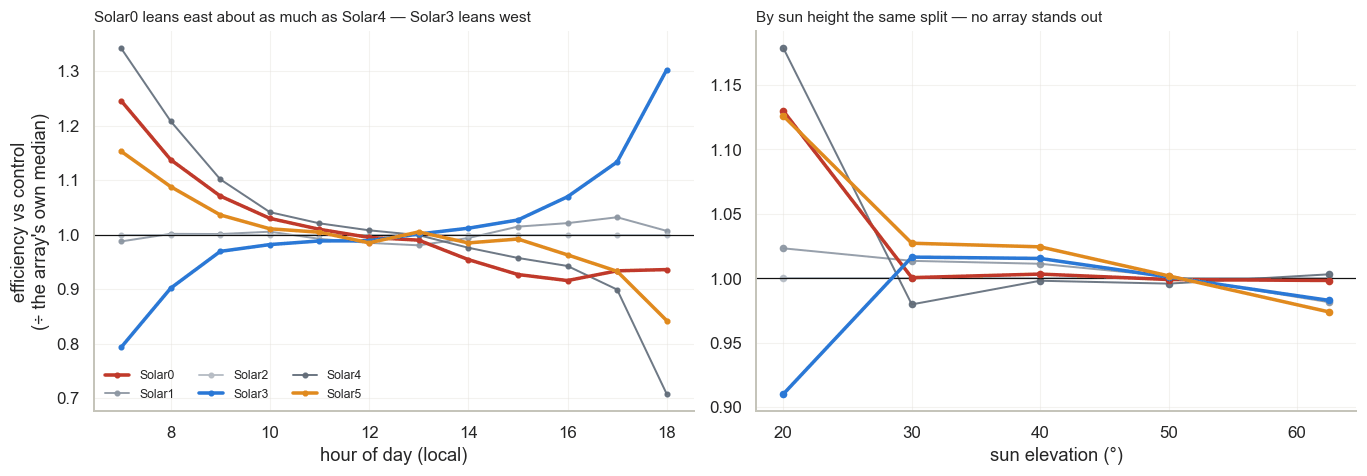

In [91]:
# --- 16c. Candidate 3: orientation, inside one regime ---------------------------
wx = (solar_data.loc[solar_data["array"] == SOLAR[0],
                     ["surface_solar_radiation", "solar_elevation"]].sort_index())
P = (solar_data.reset_index()
     .pivot(index="hour", columns="array", values="production_kw")
     .reindex(wx.index)[SOLAR])
lit = (wx["solar_elevation"] > 15) & (wx["surface_solar_radiation"] > 250)
eff = P[lit].div(wx.loc[lit, "surface_solar_radiation"], axis=0)      # kW per W/m2
control = eff[list(REF)].dropna().median(axis=1)                         # composite control
ratio = eff.div(control, axis=0)                                         # weather AND season removed

R = ratio.loc["2020-09-01":].dropna(how="all")
Rn = R.div(R.median())
by_hour = Rn.groupby(Rn.index.hour).median()
by_elev = Rn.groupby(pd.cut(wx.loc[Rn.index, "solar_elevation"], [15, 25, 35, 45, 55, 70]),
                     observed=True).median()

lean = pd.DataFrame({
    "morning / afternoon": by_hour.loc[8:10].mean() / by_hour.loc[14:16].mean(),
    "evening (17-18h)": by_hour.loc[17:18].mean(),
    "low sun / high sun": by_elev.iloc[0] / by_elev.iloc[-2:].mean(),
}).loc[SOLAR]
display(lean.round(3))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
mids = [iv.mid for iv in by_elev.index]
for s in SOLAR:
    lw, al, z = (2.3, 1.0, 3) if s in FOCUS else (1.3, 0.9, 2)
    a1.plot(by_hour.index, by_hour[s], color=ACOL[s], lw=lw, alpha=al, marker="o", ms=3,
            zorder=z, label=s)
    a2.plot(mids, by_elev[s].to_numpy(), color=ACOL[s], lw=lw, alpha=al, marker="o", ms=4,
            zorder=z, label=s)
for a in (a1, a2):
    a.axhline(1, color="#111", lw=0.8); a.grid(True, alpha=0.4); a.set_axisbelow(True)
a1.set_xlabel("hour of day (local)")
a1.set_ylabel("efficiency vs control\n(÷ the array's own median)")
a1.set_title("Solar0 leans east about as much as Solar4 — Solar3 leans west", loc="left")
a2.set_xlabel("sun elevation (°)")
a2.set_title("By sun height the same split — no array stands out", loc="left")
a1.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

## 16d. Candidate 4 — did the arrays themselves change?

If an array is repaired, extended or re-strung, its efficiency relative to its
neighbours steps up or down and stays there. A model trained across the step learns
an average of two arrays, one of which no longer exists.

Each row below is normalised to that array's **September–November 2020 level**, so
all six share one scale and a step shows as a jump away from 1. One caveat: Solar1,
Solar2 and Solar4 *form* the control, so their rows are near-flat partly by
construction. The informative rows are Solar0, Solar3 and Solar5. The year-on-year
chart that follows needs no control at all — comparing the same month a year apart
removes the season directly.

,before,after,step,share of training before the change
Solar3,0.622,0.934,1.501,0.619
Solar0,2.773,3.934,1.418,0.369


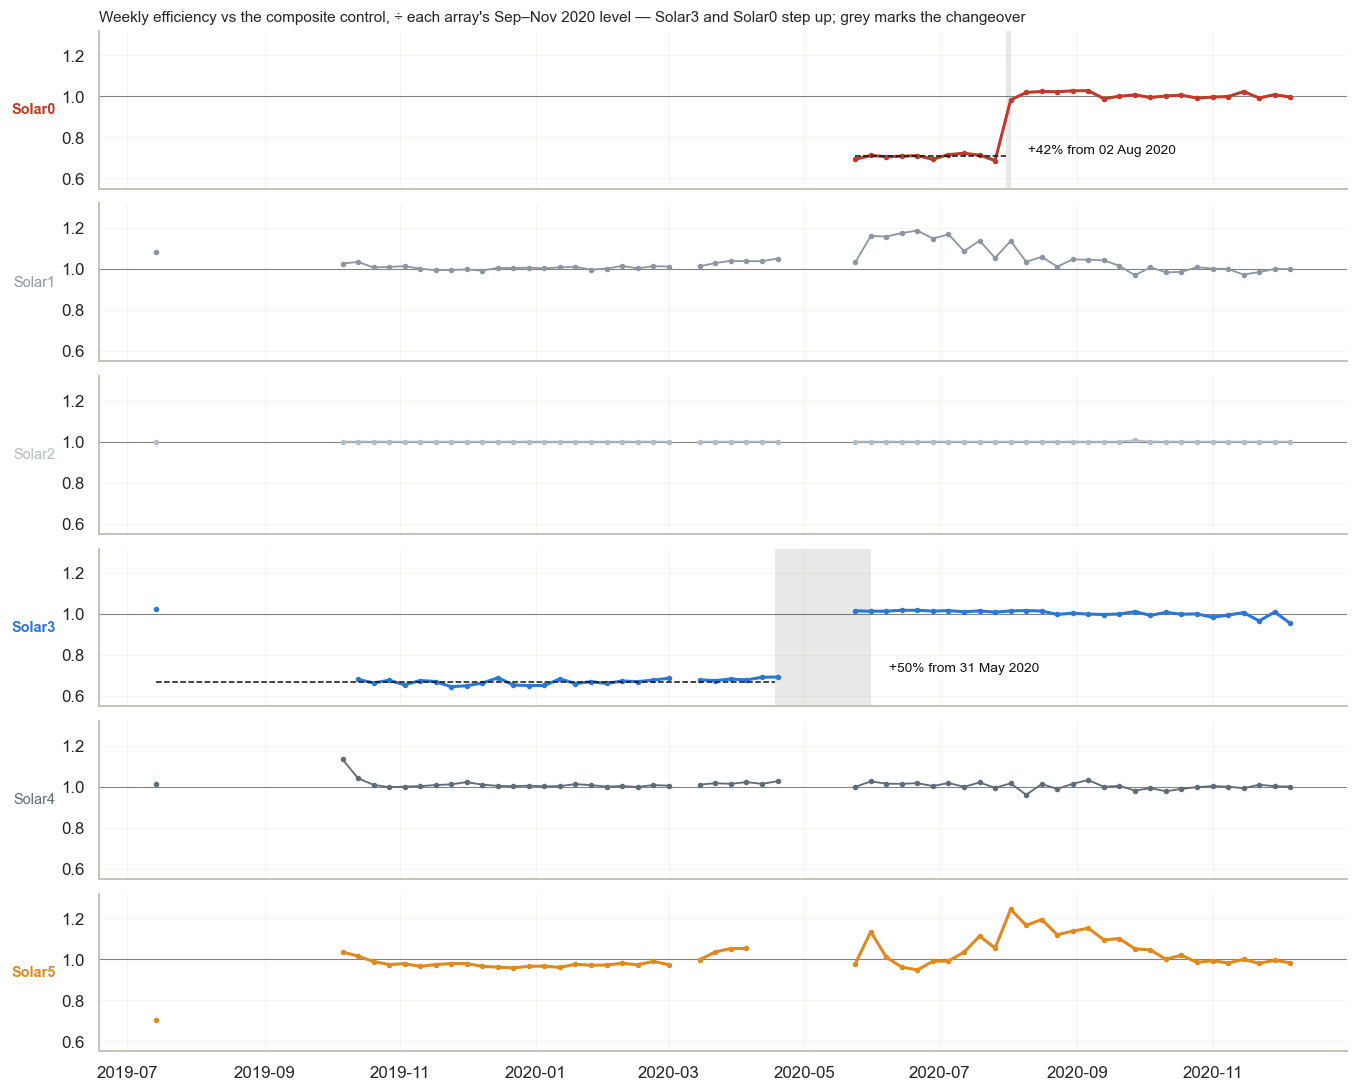

,Nov 2019,Nov 2020,change %
array,,,
Solar0,NaN,0.0467,NaN
Solar1,0.0126,0.0126,0.3471
Solar2,0.0125,0.0124,-0.1911
Solar3,0.0075,0.0110,47.7654
Solar4,0.0075,0.0074,-1.4394
Solar5,0.0369,0.0374,1.2446


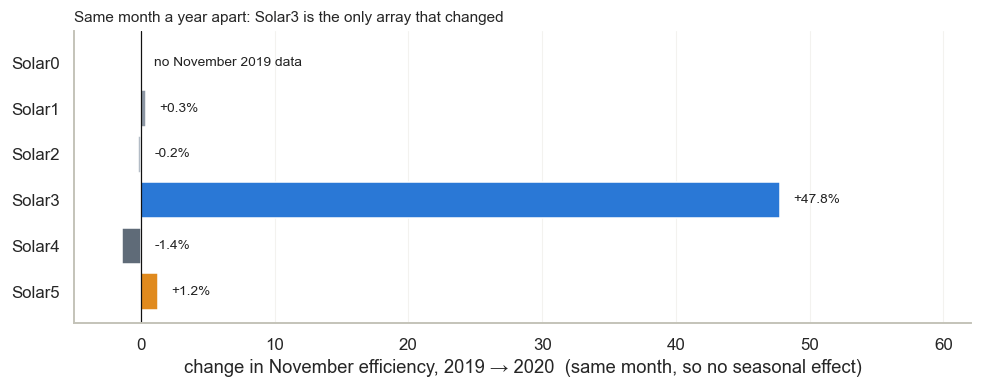

In [92]:
# --- 16d. Candidate 4: did the arrays themselves change? ------------------------
weekly = ratio.resample("W").median()

# Dates read off the weekly series below. Solar3's weeks between its two dates belong to
# neither regime. Most of them coincide with the site-wide stuck-counter spell of
# 15 Apr - 19 May 2020 (cells 45-48, section 21d), so whether Solar3 also had a genuine
# fault then cannot be told. The step itself is measured outside the gap.
REGIMES = {
    "Solar3": {"before_end": "2020-04-18", "after_start": "2020-05-31"},
    "Solar0": {"before_end": "2020-07-31", "after_start": "2020-08-02"},
}
step = {}
for s, r in REGIMES.items():
    t0 = pd.Timestamp(r["before_end"], tz=LOCAL_TZ); t1 = pd.Timestamp(r["after_start"], tz=LOCAL_TZ)
    b, a = ratio[s].loc[:t0], ratio[s].loc[t1:]
    tr = train_day[train_day["array"] == s]
    step[s] = {"before": b.median(), "after": a.median(), "step": a.median() / b.median(),
               "share of training before the change": (tr.index < t1).mean()}
step = pd.DataFrame(step).T
display(step.round(3))

today = weekly.loc["2020-09-01":].median()
fig, axes = plt.subplots(len(SOLAR), 1, figsize=(12.5, 10), sharex=True, sharey=True)
for ax, s in zip(axes, SOLAR):
    w = weekly[s].loc["2019-07-01":] / today[s]      # empty weeks kept, so lines break at gaps
    first = w.first_valid_index()
    ax.axhline(1, color="#111", lw=0.7, alpha=0.5)
    ax.plot(w.index, w.to_numpy(), color=ACOL[s], lw=2.0 if s in FOCUS else 1.2,
            marker="o", ms=2.6)
    if s in REGIMES:
        r = REGIMES[s]
        t0 = pd.Timestamp(r["before_end"], tz=LOCAL_TZ); t1 = pd.Timestamp(r["after_start"], tz=LOCAL_TZ)
        ax.axvspan(t0, t1, color="#999", alpha=0.22, lw=0)
        ax.hlines(step.loc[s, "before"] / today[s], first, t0, color="#111", ls="--", lw=1)
        ax.text(t1 + pd.Timedelta(days=8), 0.72,
                f"+{100 * (step.loc[s, 'step'] - 1):.0f}% from {t1:%d %b %Y}", fontsize=9,
                color="#111", bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))
    ax.set_ylabel(s, rotation=0, ha="right", va="center", fontsize=9.5,
                  color=ACOL[s], fontweight="bold" if s in FOCUS else "normal")
    ax.grid(True, alpha=0.35); ax.set_axisbelow(True)
axes[0].set_ylim(0.55, 1.32)
axes[0].set_title("Weekly efficiency vs the composite control, ÷ each array's Sep–Nov 2020 level "
                  "— Solar3 and Solar0 step up; grey marks the changeover", loc="left")
plt.tight_layout(); plt.show()

yoy = pd.DataFrame({"Nov 2019": eff.loc["2019-11"].median(),
                    "Nov 2020": eff.loc["2020-11"].median()}).loc[SOLAR]
yoy["change %"] = 100 * (yoy["Nov 2020"] / yoy["Nov 2019"] - 1)
display(yoy.round(4))

fig, ax = plt.subplots(figsize=(9, 3.6))
vals = yoy["change %"]
ax.barh(range(len(SOLAR)), vals.fillna(0), color=[ACOL[s] for s in SOLAR])
ax.set_yticks(range(len(SOLAR)), SOLAR); ax.invert_yaxis()
for i, s in enumerate(SOLAR):
    txt = "no November 2019 data" if pd.isna(vals[s]) else f"{vals[s]:+.1f}%"
    ax.text((0 if pd.isna(vals[s]) else max(vals[s], 0)) + 1, i, txt, va="center",
            fontsize=9, color="#222")
ax.axvline(0, color="#111", lw=0.8)
ax.set_xlabel("change in November efficiency, 2019 → 2020  (same month, so no seasonal effect)")
ax.set_title("Same month a year apart: Solar3 is the only array that changed", loc="left")
ax.set_xlim(min(-5, vals.min() - 3), vals.max() * 1.3)
ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 16e. What each array's error looks like

One forest per array on the pruned features, scored on November. The *shape* of the
error is the clue. A model trained mostly on an older, smaller array should
under-forecast in proportion to output, all day long. A problem confined to one part of
the day points somewhere else.

,MASE,forecast ÷ actual energy,mean daylight error (kW)
Solar0,0.955,0.966,-0.434
Solar1,0.440,1.028,0.149
Solar2,0.552,0.995,-0.031
Solar3,0.972,0.731,-1.333
Solar4,0.550,1.022,0.069
Solar5,0.754,1.000,0.003


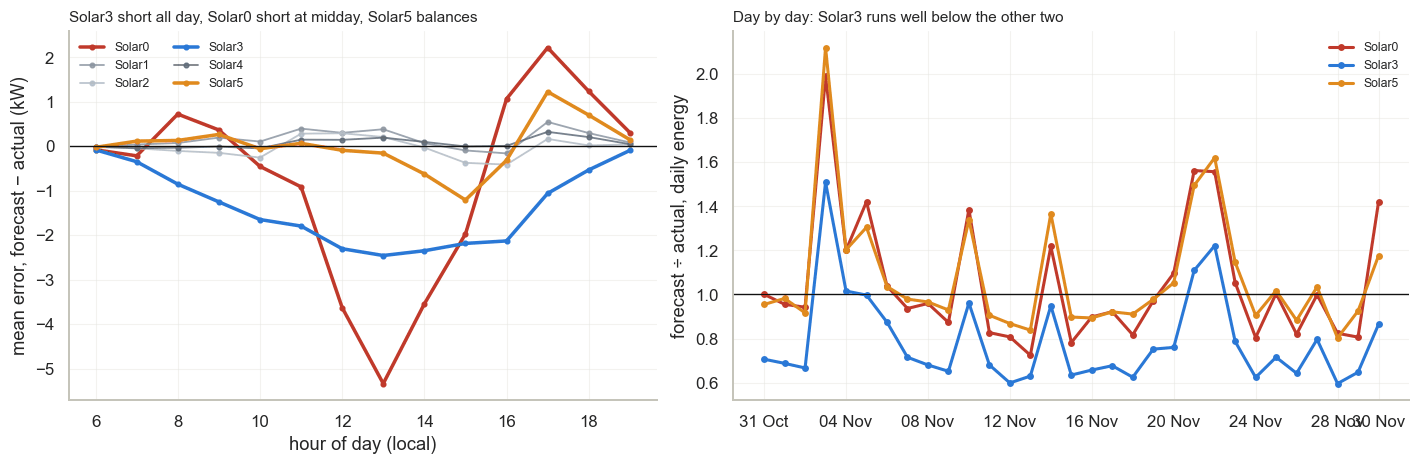

In [93]:
# --- 16e. The shape of each array's error ---------------------------------------
import matplotlib.dates as mdates

_FITS = {}      # fitted per-array forests, keyed by exactly how they were trained


def fit_array(name, start=None, rescale=None, cols=None, target="kW"):
    """Per-array forest.
    start   - drop rows before this date
    rescale - (regime, factor): keep old rows but multiply them onto today's scale
    cols    - feature list (default PRUNED)
    target  - "kW", or "ratio" to predict output / clear-sky reference (section 13)"""
    cols = list(cols or PRUNED)
    key = (name, start, target, tuple(cols),
           None if rescale is None else (rescale[0]["before_end"], rescale[0]["after_start"],
                                         float(rescale[1])))
    if key in _FITS:                                          # identical request: reuse it
        return _FITS[key]
    tr = train_day[train_day["array"] == name]
    if start is not None:
        tr = tr[tr.index >= pd.Timestamp(start, tz=LOCAL_TZ)]
    y = tr["production_kw"]
    if rescale is not None:
        r, factor = rescale
        t0 = pd.Timestamp(r["before_end"], tz=LOCAL_TZ); t1 = pd.Timestamp(r["after_start"], tz=LOCAL_TZ)
        keep = (tr.index <= t0) | (tr.index >= t1)          # drop the changeover gap
        tr, y = tr[keep], y[keep]
        y = y.where(~(tr.index <= t0), y * factor)
    if target == "ratio":
        ref = clear_sky_reference(tr)
        ok = ref / capacity[name] > 0.05                      # ratio undefined near the horizon
        tr, y = tr[ok], np.clip(y[ok].to_numpy() / ref[ok], 0, 1.5)
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features=0.5,
                              n_jobs=-1, random_state=0).fit(make_x(tr)[cols], y)
    m.cols_, m.target_ = cols, target                         # remember how to predict
    _FITS[key] = (m, len(tr))
    return _FITS[key]


nov_rows = solar_data.loc[(solar_data.index >= NOV[0]) & (solar_data.index < NOV[1])]
nov_rows = nov_rows[nov_rows[FEATURES].notna().all(axis=1)]


def forecast_one(name, model):
    """November forecast for one array, expanded to 15 minutes, beside the actuals."""
    fr = nov_rows[nov_rows["array"] == name]
    p = np.clip(model.predict(make_x(fr)[model.cols_]), 0, None)
    if model.target_ == "ratio":
        p = p * clear_sky_reference(fr)
    p = np.where(fr["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, p)
    fc = expand_to_15min(pd.Series(p, index=fr.index), NOV)
    act = df[name].reindex(fc.index)
    ok = act.notna() & fc.notna()
    return fc[ok], act[ok]


def mase_one(name, model):
    fc, act = forecast_one(name, model)
    return np.mean(np.abs(fc - act)) / mase_scale(name, NOV[0])


base = {s: fit_array(s)[0] for s in SOLAR}
impact = {}
for s in SOLAR:
    fc, act = forecast_one(s, base[s])
    impact[s] = {"MASE": mase_one(s, base[s]),
                 "forecast ÷ actual energy": fc.sum() / act.sum(),
                 "mean daylight error (kW)": (fc - act)[act > 0].mean()}
impact = pd.DataFrame(impact).T.loc[SOLAR]
display(impact.round(3))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.15]})
for s in SOLAR:
    fc, act = forecast_one(s, base[s])
    e = (fc - act).groupby(fc.index.hour).mean().loc[6:19]
    lw, al = (2.3, 1.0) if s in FOCUS else (1.2, 0.85)
    a1.plot(e.index, e.to_numpy(), color=ACOL[s], lw=lw, alpha=al, marker="o", ms=3, label=s)
a1.axhline(0, color="#111", lw=0.9)
a1.set_xlabel("hour of day (local)"); a1.set_ylabel("mean error, forecast − actual (kW)")
a1.set_title("Solar3 short all day, Solar0 short at midday, Solar5 balances", loc="left")
a1.grid(True, alpha=0.4); a1.set_axisbelow(True); a1.legend(fontsize=8, ncol=2)

for s in FOCUS:
    fc, act = forecast_one(s, base[s])
    d = pd.DataFrame({"f": fc, "a": act}).resample("D").sum()
    d = d[d["a"] > 0.05 * d["a"].max()]          # skip part-days where a ratio is meaningless
    a2.plot(d.index, (d["f"] / d["a"]).to_numpy(), color=ACOL[s], lw=2, marker="o", ms=3.5, label=s)
a2.axhline(1, color="#111", lw=0.9)
a2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
a2.set_ylabel("forecast ÷ actual, daily energy")
a2.set_title("Day by day: Solar3 runs well below the other two", loc="left")
a2.grid(True, alpha=0.4); a2.set_axisbelow(True); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 16f. Solar3: discard the old data, or rescale it?

For an array that changed, there are two ways to stop the model learning the old
array:

- **Discard** everything before the change — clean, but it throws data away.
- **Rescale** the old rows by the step measured in 16d — keeps the data and puts it on
  today's scale.

Discarding mixes two effects: removing the old regime *helps*, losing the history
*hurts*. Rescaling removes the regime without losing anything, so it is the direct
measurement of what the change cost. The right-hand panel shows the price of lost
history on its own, by making the same cut to arrays that never changed.

strategy,all data,cut to Solar0's window,cut to Solar3's window,discard the old data,rescale the old data
array,,,,,
Solar0,0.9552,NaN,NaN,0.9516,0.9451
Solar1,0.4402,0.5753,0.5711,NaN,NaN
Solar2,0.5519,0.6670,0.6684,NaN,NaN
Solar3,0.9724,NaN,NaN,0.7416,0.5852
Solar4,0.5503,0.6802,0.6862,NaN,NaN
Solar5,0.7540,0.9674,0.9626,NaN,NaN


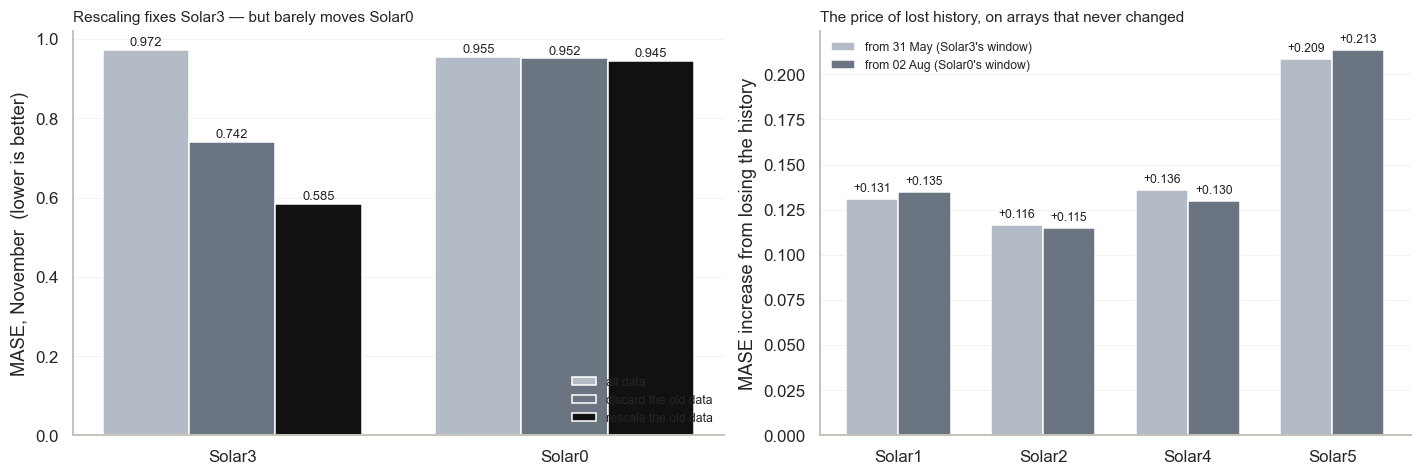

In [94]:
# --- 16f. Discard vs rescale, and the price of lost history ---------------------
trials = []
def trial(name, strategy, **kw):
    m, n = fit_array(name, **kw)
    trials.append({"array": name, "strategy": strategy, "training hours": n,
                   "MASE": mase_one(name, m)})

for s in SOLAR:
    trial(s, "all data")
for s, r in REGIMES.items():
    trial(s, "discard the old data", start=r["after_start"])
    trial(s, "rescale the old data", rescale=(r, step.loc[s, "step"]))
for s in list(REF) + ["Solar5"]:
    for owner, r in REGIMES.items():
        trial(s, f"cut to {owner}'s window", start=r["after_start"])

trials = pd.DataFrame(trials)
table = trials.pivot(index="array", columns="strategy", values="MASE").reindex(SOLAR)
display(table.round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.1, 1]})
strategies = ["all data", "discard the old data", "rescale the old data"]
shades = ["#b3bcc6", "#6b7582", "#111111"]
x = np.arange(len(REGIMES))
for k, (strat, col) in enumerate(zip(strategies, shades)):
    xs = x + (k - 1) * 0.26
    vals = [table.loc[s, strat] for s in REGIMES]
    a1.bar(xs, vals, 0.26, color=col, label=strat)
    for xi, v in zip(xs, vals):
        a1.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, color="#222")
a1.set_xticks(x, list(REGIMES)); a1.set_ylabel("MASE, November  (lower is better)")
a1.set_title("Rescaling fixes Solar3 — but barely moves Solar0", loc="left")
a1.legend(fontsize=8, loc="lower right"); a1.grid(True, axis="y", alpha=0.4); a1.set_axisbelow(True)

arrs = list(REF) + ["Solar5"]
for k, owner in enumerate(REGIMES):
    col_name = f"cut to {owner}'s window"
    cost = [table.loc[s, col_name] - table.loc[s, "all data"] for s in arrs]
    xs = np.arange(len(arrs)) + (k - 0.5) * 0.36
    a2.bar(xs, cost, 0.36, color=["#b3bcc6", "#6b7582"][k],
           label=f"from {pd.Timestamp(REGIMES[owner]['after_start']):%d %b} ({owner}'s window)")
    for xi, v in zip(xs, cost):
        a2.text(xi, v + 0.004, f"{v:+.3f}", ha="center", fontsize=8, color="#222")
a2.set_xticks(np.arange(len(arrs)), arrs)
a2.axhline(0, color="#111", lw=0.8)
a2.set_ylabel("MASE increase from losing the history")
a2.set_title("The price of lost history, on arrays that never changed", loc="left")
a2.legend(fontsize=8); a2.grid(True, axis="y", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 16g. Solar0: a sun higher than anything in its history

Solar0's data begins in April 2020, so its history holds autumn, winter and spring but
**no summer**. A random forest predicts by averaging training rows that look similar,
so it cannot produce an output higher than it has seen for conditions it has never
met. If November's sun climbs above anything in Solar0's history, its forecast should
fall short **exactly there, and only there** — a threshold, not the steady proportional
shortfall a changed array produces.

The fix follows from the cause. The clear-sky ratio target from section 13 applies the
sun's height *outside* the tree, so the tree only has to predict a ratio in the range it
has already seen.

,highest sun in training (°),highest sun in November (°),November daylight above it,November energy above it
Solar0,65.349,73.674,0.169,0.27
Solar1,75.306,73.674,0.000,0.00
Solar2,75.306,73.674,0.000,0.00
Solar3,75.306,73.674,0.000,0.00
Solar4,75.306,73.674,0.000,0.00
Solar5,75.306,73.674,0.000,0.00


,kW target,clear-sky ratio target,energy ratio after,gain
Solar0,0.9552,0.8671,0.9919,0.0882
Solar1,0.4402,0.4421,1.0308,-0.0020
Solar2,0.5519,0.5461,0.9892,0.0058
Solar3,0.9724,0.9696,0.7357,0.0027
Solar4,0.5503,0.5452,1.0179,0.0051
Solar5,0.7540,0.7425,1.0102,0.0115


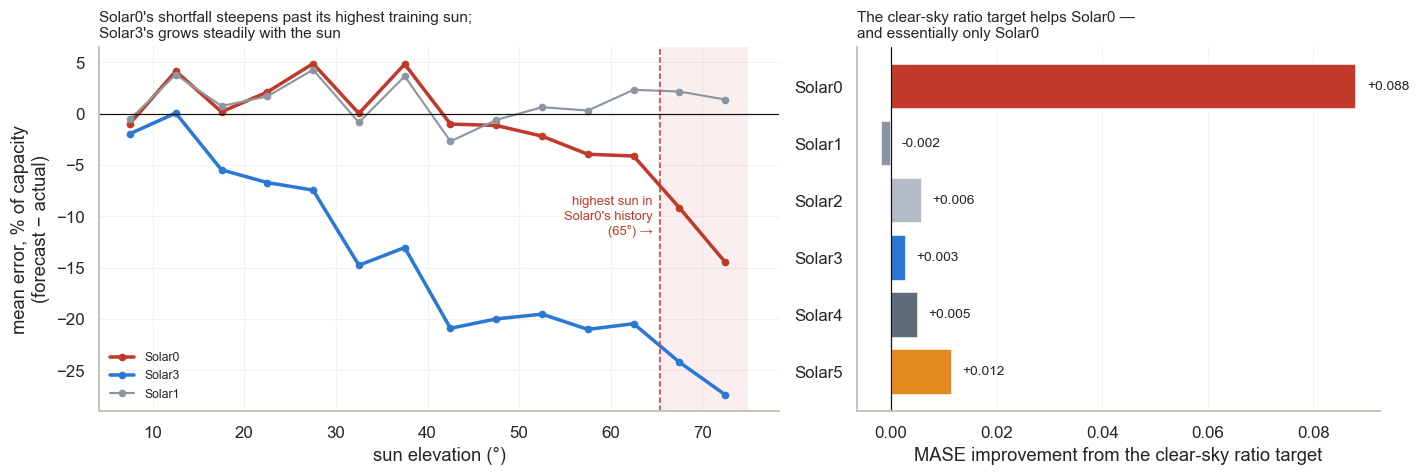

In [95]:
# --- 16g. Candidate 5: November's sun outside the training range ----------------
cover = {}
for s in SOLAR:
    emax = train_day.loc[train_day["array"] == s, "solar_elevation"].max()
    fc, act = forecast_one(s, base[s])
    e15 = pd.Series(solar_elevation(act.index + pd.Timedelta(minutes=7, seconds=30)), index=act.index)
    cover[s] = {"highest sun in training (°)": emax,
                "highest sun in November (°)": e15.max(),
                "November daylight above it": (e15[e15 > 5] > emax).mean(),
                "November energy above it": act[e15 > emax].sum() / act.sum()}
cover = pd.DataFrame(cover).T.loc[SOLAR]
display(cover.round(3))
EMAX0 = cover.loc["Solar0", "highest sun in training (°)"]

fixed_ratio = {}
for s in SOLAR:
    m, _ = fit_array(s, target="ratio")
    fc, act = forecast_one(s, m)
    fixed_ratio[s] = {"kW target": mase_one(s, base[s]), "clear-sky ratio target": mase_one(s, m),
                      "energy ratio after": fc.sum() / act.sum()}
fixed_ratio = pd.DataFrame(fixed_ratio).T.loc[SOLAR]
fixed_ratio["gain"] = fixed_ratio["kW target"] - fixed_ratio["clear-sky ratio target"]
display(fixed_ratio.round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
edges = np.arange(5, 80, 5)
for s in ["Solar0", "Solar3", "Solar1"]:
    fc, act = forecast_one(s, base[s])
    e15 = solar_elevation(act.index + pd.Timedelta(minutes=7, seconds=30))
    rel = ((fc - act) / capacity[s]).groupby(pd.cut(e15, edges), observed=True).mean()
    a1.plot([iv.mid for iv in rel.index], 100 * rel.to_numpy(), color=ACOL[s],
            lw=2.3 if s in FOCUS else 1.4, marker="o", ms=4, label=s)
a1.axvspan(EMAX0, edges[-1], color="#c0392b", alpha=0.08, lw=0)
a1.axvline(EMAX0, color="#c0392b", lw=1, ls="--")
a1.text(EMAX0 - 0.8, -8, f"highest sun in\nSolar0's history\n({EMAX0:.0f}°) →",
        fontsize=8.5, color="#c0392b", va="top", ha="right")
a1.axhline(0, color="#111", lw=0.8)
a1.set_xlabel("sun elevation (°)"); a1.set_ylabel("mean error, % of capacity\n(forecast − actual)")
a1.set_title("Solar0's shortfall steepens past its highest training sun;\n"
             "Solar3's grows steadily with the sun", loc="left")
a1.grid(True, alpha=0.4); a1.set_axisbelow(True); a1.legend(fontsize=8, loc="lower left")

gains = fixed_ratio["gain"]
a2.barh(range(len(SOLAR)), gains, color=[ACOL[s] for s in SOLAR])
a2.set_yticks(range(len(SOLAR)), SOLAR); a2.invert_yaxis()
for i, s in enumerate(SOLAR):
    a2.text(max(gains[s], 0) + 0.002, i, f"{gains[s]:+.3f}", va="center", fontsize=9, color="#222")
a2.axvline(0, color="#111", lw=0.8)
a2.set_xlabel("MASE improvement from the clear-sky ratio target")
a2.set_title("The clear-sky ratio target helps Solar0 —\nand essentially only Solar0", loc="left")
a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 16h. Candidate 6 — a seasonal pattern the features don't carry?

Solar5 did not step (16d), is not biased overall (16e), and has seen a summer before
(16g), so none of the causes above apply to it. One idea remains: its relative efficiency
drifts with the season in a way the geometry features don't capture. If so, giving the
model the day of year should help Solar5 noticeably more than the arrays that behave.

Two cautions before reading the result. Solar1's relative efficiency swings by a similar
amount, yet it is the easiest array to forecast — its swing lines up with its inverter cap
(section 10c), which the model learns from irradiance. And the composite control only
exists from June 2019, leaving too few overlapping months to test whether any array's
pattern repeats from one year to the next.

,pruned,+ day of year,gain,seasonal swing (max/min month)
Solar0,0.9552,1.0827,-0.1274,1.0246
Solar1,0.4402,0.4380,0.0022,1.1871
Solar2,0.5519,0.5323,0.0196,1.0000
Solar3,0.9724,1.0325,-0.0601,1.0205
Solar4,0.5503,0.5486,0.0017,1.0293
Solar5,0.7540,0.7370,0.0171,1.1990


Solar5 ranks #2 of 6 for the gain from day of year, and #1 of 6 for seasonal swing.


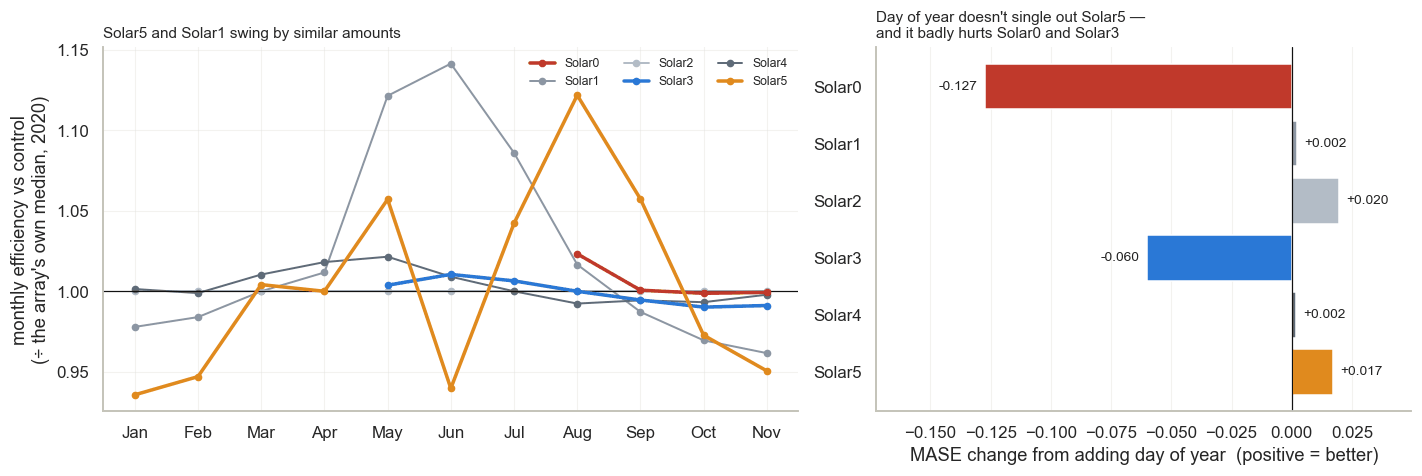

In [96]:
# --- 16h. Candidate 6: a seasonal pattern outside the features? -----------------
cur_start = {s: REGIMES[s]["after_start"] if s in REGIMES else "2020-01-01" for s in SOLAR}
monthly = {}
for s in SOLAR:
    x = ratio[s].loc[pd.Timestamp(cur_start[s], tz=LOCAL_TZ):].dropna()
    x = x[x.index < pd.Timestamp("2020-12-01", tz=LOCAL_TZ)]      # local calendar months only
    mm = x.groupby(x.index.month).median()
    monthly[s] = mm / mm.median()
monthly = pd.DataFrame(monthly)

seasonal = {}
for s in SOLAR:
    m, _ = fit_array(s, cols=PRUNED + ["doy_sin", "doy_cos"])
    seasonal[s] = {"pruned": mase_one(s, base[s]), "+ day of year": mase_one(s, m)}
seasonal = pd.DataFrame(seasonal).T.loc[SOLAR]
seasonal["gain"] = seasonal["pruned"] - seasonal["+ day of year"]
seasonal["seasonal swing (max/min month)"] = (monthly.max() / monthly.min()).loc[SOLAR]
display(seasonal.round(4))
rk_gain = int(seasonal["gain"].rank(ascending=False)["Solar5"])
rk_swing = int(seasonal["seasonal swing (max/min month)"].rank(ascending=False)["Solar5"])
print(f"Solar5 ranks #{rk_gain} of 6 for the gain from day of year, "
      f"and #{rk_swing} of 6 for seasonal swing.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
for s in SOLAR:
    v = monthly[s].dropna()
    a1.plot(v.index, v.to_numpy(), color=ACOL[s], lw=2.3 if s in FOCUS else 1.3,
            marker="o", ms=4, label=s, zorder=3 if s in FOCUS else 2)
a1.axhline(1, color="#111", lw=0.8)
a1.set_xticks(range(1, 12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov"])
a1.set_ylabel("monthly efficiency vs control\n(÷ the array's own median, 2020)")
a1.set_title("Solar5 and Solar1 swing by similar amounts", loc="left")
a1.grid(True, alpha=0.4); a1.set_axisbelow(True); a1.legend(fontsize=8, ncol=3)

g_ = seasonal["gain"]
a2.barh(range(len(SOLAR)), g_, color=[ACOL[s] for s in SOLAR])
a2.set_yticks(range(len(SOLAR)), SOLAR); a2.invert_yaxis()
for i, s in enumerate(SOLAR):
    v = g_[s]
    a2.text(v + (0.003 if v >= 0 else -0.003), i, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9, color="#222")
a2.axvline(0, color="#111", lw=0.8)
a2.set_xlim(g_.min() - 0.045, g_.max() + 0.03)
a2.set_xlabel("MASE change from adding day of year  (positive = better)")
a2.set_title("Day of year doesn't single out Solar5 —\nand it badly hurts Solar0 and Solar3", loc="left")
a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 16i. What was found, and what each fix buys

Two of the three arrays fail for reasons the data identifies, and each gets the fix its
own cause calls for — nothing more. Solar0's fix is only partial: it removes the shortfall
at sun heights the model had never seen, but the array is still short of history. Every number comes from the same per-array forest on
the same features, scored the same way; only the targeted change differs.

Solar5 gets no fix, because no candidate held up: it did not change, is not biased, has
seen a summer, is not unusually oriented, and a seasonal term does not single it out.

,cause,fix,before,after,gain
Solar0,November's sun above its history,clear-sky ratio target,0.955246,0.867089,0.088157
Solar1,-,none needed,0.440184,0.440184,0.0
Solar2,-,none needed,0.55193,0.55193,0.0
Solar3,the array changed (31 May 2020),rescale the old data,0.972383,0.585243,0.38714
Solar4,-,none needed,0.550262,0.550262,0.0
Solar5,not identified - every candidate negative,none found,0.754046,0.754046,0.0


mean MASE over the six arrays: 0.7040 -> 0.6248


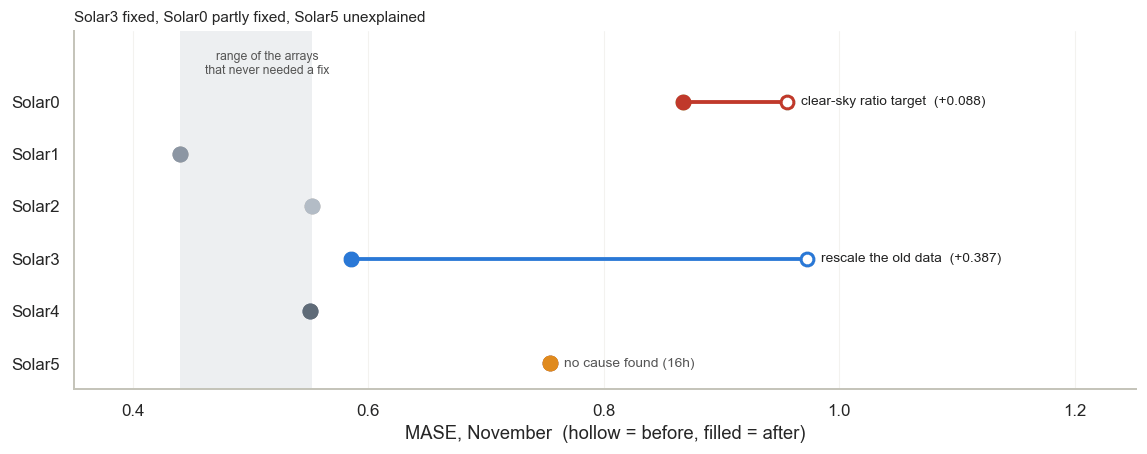

In [97]:
# --- 16i. Before and after, per array ------------------------------------------
FIXES = {
    "Solar3": ("rescale the old data", dict(rescale=(REGIMES["Solar3"], step.loc["Solar3", "step"]))),
    "Solar0": ("clear-sky ratio target", dict(target="ratio")),
}
CAUSE = {"Solar3": "the array changed (31 May 2020)",
         "Solar0": "November's sun above its history",
         "Solar5": "not identified - every candidate negative"}
final = {}
for s in SOLAR:
    before = mase_one(s, base[s])
    if s in FIXES:
        label, kw = FIXES[s]
        after = mase_one(s, fit_array(s, **kw)[0])
    else:
        label, after = ("none found" if s in CAUSE else "none needed"), before
    final[s] = {"cause": CAUSE.get(s, "-"), "fix": label,
                "before": before, "after": after, "gain": before - after}
final = pd.DataFrame(final).T.loc[SOLAR]
display(final.round(4))
print(f"mean MASE over the six arrays: {final['before'].astype(float).mean():.4f} -> "
      f"{final['after'].astype(float).mean():.4f}")

fig, ax = plt.subplots(figsize=(10.5, 4.2))
easy = final.loc[list(REF), "after"].astype(float)
ax.axvspan(easy.min(), easy.max(), color="#8c96a3", alpha=0.15, lw=0)
ax.text(easy.mean(), -0.72, "range of the arrays\nthat never needed a fix", ha="center",
        va="center", fontsize=8, color="#555")
for i, s in enumerate(SOLAR):
    b, a = float(final.loc[s, "before"]), float(final.loc[s, "after"])
    ax.plot([b, a], [i, i], color=ACOL[s], lw=2.5, zorder=2)
    ax.scatter([b], [i], s=70, color="white", edgecolor=ACOL[s], lw=2, zorder=3)
    ax.scatter([a], [i], s=90, color=ACOL[s], zorder=4)
    if s in FIXES:
        ax.text(max(a, b) + 0.012, i, f"{final.loc[s, 'fix']}  ({b - a:+.3f})", va="center",
                fontsize=9, color="#222")
    elif s == "Solar5":
        ax.text(b + 0.012, i, "no cause found (16h)", va="center", fontsize=9, color="#555")
ax.set_yticks(range(len(SOLAR)), SOLAR); ax.set_ylim(len(SOLAR) - 0.5, -1.35)
ax.set_xlabel("MASE, November  (hollow = before, filled = after)")
ax.set_xlim(0.35, float(final["before"].max()) + 0.28)
ax.set_title("Solar3 fixed, Solar0 partly fixed, Solar5 unexplained", loc="left")
ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 16

**Three arrays, three different answers.**

- **Solar3 changed.** Its efficiency against the composite control stepped up by about 50%
  around 31 May 2020 (16d), and the same month a year apart is up 47.8% while every other
  array is within ±1.5%. Its error is proportional: it forecasts only 73% of its actual
  November energy, short at every hour and at every sun height (16e, 16g). Rescaling the old
  rows by the measured step takes its per-array forest from 0.972 to 0.585 (16f), into the
  range of the arrays that never needed a fix. The single July 2019 week already sits at
  today's level (16d), which hints the low period was a fault later repaired rather than an
  extension. One week is too little to be sure, and the fix is the same either way. The
  changeover weeks themselves mostly coincide with a site-wide stuck-counter spell
  (section 21d), so whether Solar3 had its own fault then cannot be told.
- **Solar0 has not seen a full year.** Its history starts in late April 2020, so November's
  sun climbs above anything it has seen: 27% of its November energy arrives at sun heights
  above its training maximum (16g), and its error steepens past that point. The clear-sky
  ratio target, which applies the sun's height outside the tree, improves it by 0.088 and
  does almost nothing for any other array. Section 17 shows this is only part of the story.
- **Solar5 is not explained.** It did not change, is not biased (forecast ÷ actual energy
  1.000), has seen a summer, is not unusually oriented, and a seasonal term does not single it
  out — Solar2 gains more from it (16h). It is the array hurt most by losing history (+0.21
  in 16f), which fits an array whose output is less tightly tied to the weather. That is a
  description, not a cause.

**Ruled out:** outages inside the test month (16b — no bright-sun zeros and no offline days in
any array), orientation (16c — Solar0 leans east no more than Solar4, which forecasts well),
and short history as the whole of Solar0's problem.

**A side result worth keeping.** Adding the day of year hurts exactly the two arrays without a
clean, continuous year of history: Solar0 by 0.127 and Solar3 by 0.060 (16h). For Solar0 the
November dates were never in training; for Solar3 the date acts as a stand-in for "before or
after the repair". That is where the calendar terms did their damage in section 11e, which
pruned them for hurting on average.

**Caution on selection.** Which arrays to investigate was decided from November scores, so any
fix chosen here has to be tested on a month it was not chosen on. Section 17 does that.

---

# 17. Rebuilding the models with the section 16 fixes

Section 16 found a different problem in each of three arrays. This section feeds those
findings back into the modelling and rebuilds the main models on corrected data.

| Array | Finding | Change here |
|---|---|---|
| Solar3 | the array changed around 31 May 2020 (16d) | rows before 18 Apr 2020 rescaled by the measured step; the changeover gap in between dropped (it mostly coincides with the site-wide stuck-counter spell, section 21d) |
| Solar0 | November's sun is higher than anything in its history (16g) | the clear-sky ratio target — **plus** its own August step corrected the same way, which 17c shows the ratio target needs |
| Solar5 | no cause identified (16h) | nothing — changing it without a diagnosis would just be fitting the test month |

**Keeping the test month out of it.** Section 16's step estimates used every week,
November included, so both steps are re-measured here from data *before* the test month
only. And because the decision to fix these arrays was prompted by November scores, the
whole procedure is repeated on **October** — trained only on data before October, steps
measured before October — a month the fixes were never chosen on.

## 17a. The corrected training data

Solar3 step, measured before November: 1.503   (section 16, November included: 1.501)
Solar0 step, measured before November: 1.420   (section 16, November included: 1.418)


,"training rows, original","training rows, corrected","capacity kW, original","capacity kW, corrected"
array,,,,
Solar0,1642,1620,44.91,44.94
Solar1,5149,5149,12.75,12.75
Solar2,4755,4755,12.83,12.83
Solar3,4596,4486,9.72,11.00
Solar4,4939,4939,7.58,7.58
Solar5,5012,5012,37.93,37.93


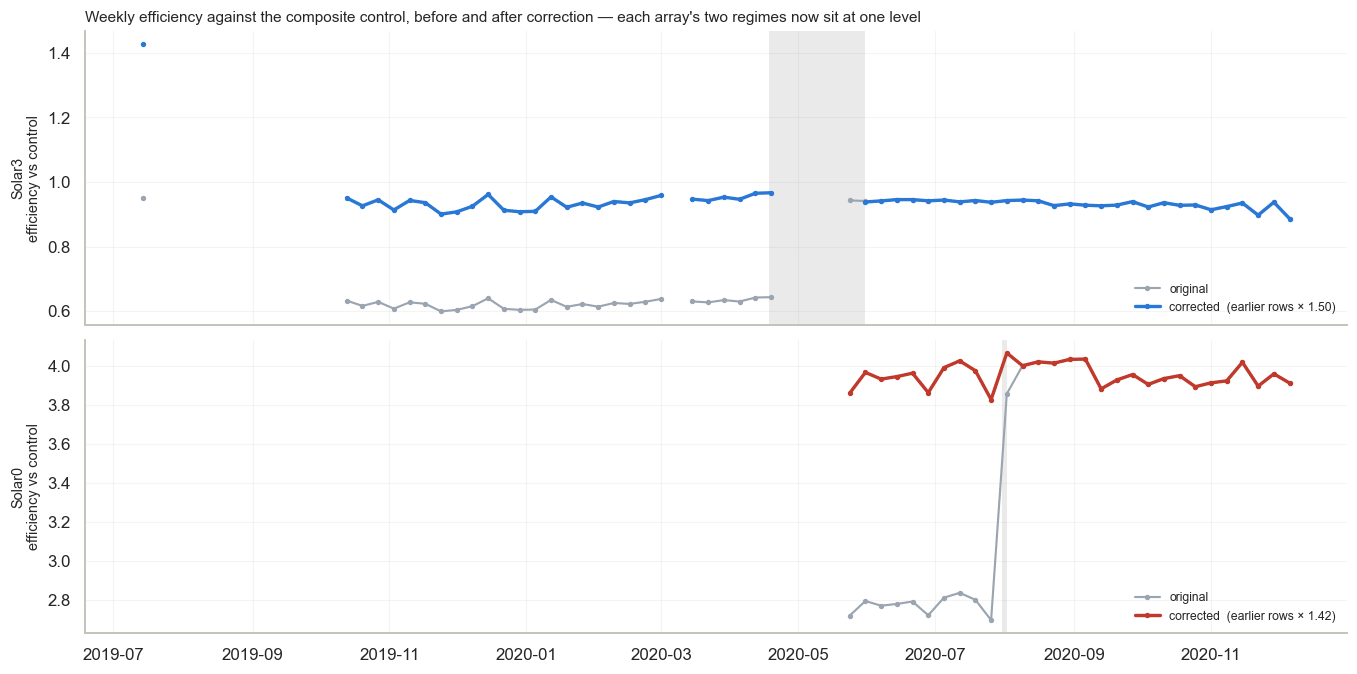

In [98]:
# --- 17a. The corrected training data -------------------------------------------
REGIMES_FIX = ("Solar3", "Solar0")          # the arrays whose history is corrected


def step_for(name, until):
    """An array's efficiency step, measured only on weeks before `until`."""
    r = ratio[name]
    t0 = pd.Timestamp(REGIMES[name]["before_end"], tz=LOCAL_TZ)
    t1 = pd.Timestamp(REGIMES[name]["after_start"], tz=LOCAL_TZ)
    return r[(r.index >= t1) & (r.index < until)].median() / r.loc[:t0].median()


def corrected(frame, until, arrays=REGIMES_FIX):
    """Training frame with the step correction applied to `arrays`: rows in the
    changeover gap dropped, rows before it multiplied onto today's scale."""
    out, steps = frame.copy(), {}
    for name in arrays:
        t0 = pd.Timestamp(REGIMES[name]["before_end"], tz=LOCAL_TZ)
        t1 = pd.Timestamp(REGIMES[name]["after_start"], tz=LOCAL_TZ)
        is_a = (out["array"] == name).to_numpy()
        out = out[~(is_a & (out.index > t0) & (out.index < t1))]
        old = (out["array"] == name).to_numpy() & (out.index <= t0)
        steps[name] = step_for(name, until)
        out["production_kw"] = np.where(old, out["production_kw"] * steps[name],
                                        out["production_kw"])
    return out, steps


train_fix, STEPS = corrected(train_day, NOV[0])
capacity_fix = train_fix.groupby("array")["production_kw"].quantile(0.99)

for s in REGIMES_FIX:
    print(f"{s} step, measured before November: {STEPS[s]:.3f}   "
          f"(section 16, November included: {step.loc[s, 'step']:.3f})")
display(pd.DataFrame({
    "training rows, original": train_day.groupby("array").size(),
    "training rows, corrected": train_fix.groupby("array").size(),
    "capacity kW, original": capacity,
    "capacity kW, corrected": capacity_fix,
}).loc[SOLAR].round(2))

# Plotted as efficiency against the control, which removes the season - raw output
# would put a summer week next to a winter one and hide whether the levels now agree.
fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.2), sharex=True)
for ax, s in zip(axes, REGIMES_FIX):
    t0 = pd.Timestamp(REGIMES[s]["before_end"], tz=LOCAL_TZ)
    t1 = pd.Timestamp(REGIMES[s]["after_start"], tz=LOCAL_TZ)
    r = ratio[s].dropna()
    rc = r[~((r.index > t0) & (r.index < t1))]
    rc = rc.where(rc.index > t0, rc * STEPS[s])
    wo, wc = r.resample("W").median(), rc.resample("W").median()
    ax.plot(wo.index, wo.to_numpy(), color="#9aa5b1", lw=1.4, marker="o", ms=2.5, label="original")
    ax.plot(wc.index, wc.to_numpy(), color=FOCUS[s], lw=2.2, marker="o", ms=2.5,
            label=f"corrected  (earlier rows × {STEPS[s]:.2f})")
    ax.axvspan(t0, t1, color="#999", alpha=0.2, lw=0)
    ax.set_ylabel(f"{s}\nefficiency vs control", fontsize=9.5)
    ax.grid(True, alpha=0.35); ax.set_axisbelow(True); ax.legend(fontsize=8, loc="lower right")
axes[0].set_title("Weekly efficiency against the composite control, before and after correction "
                  "— each array's two regimes now sit at one level", loc="left")
plt.tight_layout(); plt.show()

## 17b. The pooled forest, rebuilt

The pruned pooled forest from section 11e, refitted on original or corrected data with a
kW or clear-sky ratio target. The first row reproduces section 11e's `rf_pruned` exactly —
same data, settings and seed — so every difference below it comes from the change named in
its label. One extra row corrects Solar3 only, to show what the Solar0 correction adds.

,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5,mean
"original data, kW",0.9435,0.4420,0.5407,0.9687,0.5520,0.7465,0.6989
"original data, ratio",0.8680,0.4442,0.5396,0.9366,0.5550,0.7344,0.6796
"corrected data, kW",0.9588,0.4419,0.5431,0.5933,0.5570,0.7472,0.6402
"Solar3 corrected only, ratio",0.8473,0.4415,0.5338,0.5905,0.5505,0.7276,0.6152
"corrected data, ratio",0.8480,0.4413,0.5354,0.5915,0.5514,0.7271,0.6158


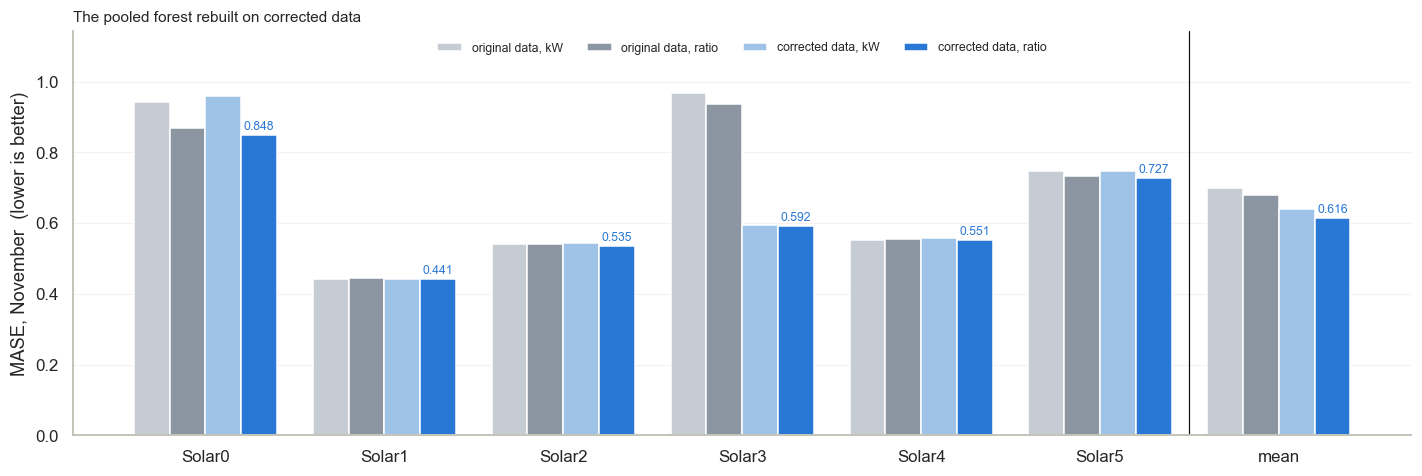

In [99]:
# --- 17b. The pooled forest, rebuilt ---------------------------------------------
def reference_with(frame, caps):
    """Clear-sky reference (section 13) with a chosen set of capacities."""
    return frame["array"].map(caps).to_numpy() * frame["clear_sky_ghi"].to_numpy() / CS_MAX


def fit_pooled(frame, target="kW", caps=None):
    """Pooled pruned forest; returns a frame -> kW predictor."""
    X, y = make_x(frame)[PRUNED], frame["production_kw"].to_numpy()
    if target == "ratio":
        ref = reference_with(frame, caps)
        ok = ref / frame["array"].map(caps).to_numpy() > 0.05
        X, y = X[ok], np.clip(y[ok] / ref[ok], 0, 1.5)
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features=0.5,
                              n_jobs=-1, random_state=0).fit(X, y)
    if target == "ratio":
        return lambda f: m.predict(make_x(f)[PRUNED]) * reference_with(f, caps)
    return lambda f: m.predict(make_x(f)[PRUNED])


def cap_of(frame):
    return frame.groupby("array")["production_kw"].quantile(0.99)


def variants(train, until):
    """The pooled variants for a training frame that ends at `until`."""
    fix, _ = corrected(train, until)
    fix3, _ = corrected(train, until, arrays=("Solar3",))
    return {
        "original data, kW": fit_pooled(train, "kW"),
        "original data, ratio": fit_pooled(train, "ratio", cap_of(train)),
        "corrected data, kW": fit_pooled(fix, "kW"),
        "Solar3 corrected only, ratio": fit_pooled(fix3, "ratio", cap_of(fix3)),
        "corrected data, ratio": fit_pooled(fix, "ratio", cap_of(fix)),
    }


def board_for(models, window):
    b = pd.DataFrame({k: score_frame(f, window) for k, f in models.items()}).T[SOLAR]
    b["mean"] = b.mean(axis=1)
    return b


POOLED = variants(train_day, NOV[0])
nov_board = board_for(POOLED, NOV)
display(nov_board.round(4))

MAIN = ["original data, kW", "original data, ratio", "corrected data, kW", "corrected data, ratio"]
SHADE = ["#c5ccd3", "#8c96a3", "#9ec3e6", "#2a78d6"]
cols = SOLAR + ["mean"]; x = np.arange(len(cols))
fig, ax = plt.subplots(figsize=(13, 4.4))
for k, (v, c) in enumerate(zip(MAIN, SHADE)):
    ax.bar(x + (k - 1.5) * 0.2, nov_board.loc[v, cols], 0.2, color=c, label=v)
for xi, col in zip(x, cols):
    v = nov_board.loc["corrected data, ratio", col]
    ax.text(xi + 0.3, v + 0.015, f"{v:.3f}", ha="center", fontsize=8, color="#2a78d6")
ax.axvline(len(SOLAR) - 0.5, color="#111", lw=0.8)
ax.set_xticks(x, cols); ax.set_ylabel("MASE, November  (lower is better)")
ax.set_ylim(0, nov_board.loc[MAIN, cols].max().max() * 1.18)
ax.set_title("The pooled forest rebuilt on corrected data", loc="left")
ax.legend(fontsize=8, ncol=4, loc="upper center")
ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 17c. The same procedure on October — and what it caught

The whole procedure is repeated one month earlier: trained on data before October, steps
measured before October, scored on October. A gain that is real should reappear; one that
came from choosing fixes on November should not.

It caught something. Corrected for Solar3 alone, the ratio target makes **Solar0 worse** in
October. The reason is that the ratio target divides the sun's height out of the target,
and in doing so it exposes Solar0's August step. In raw kW that step is tangled up with the
season: the old array was only ever seen under low winter sun and the new one under higher
spring sun, so a kW forest splits them apart by sun height and never notices. Once the season
is divided out, the two regimes look alike in every feature but differ roughly twofold in
target, so the forest averages them and under-forecasts. Correcting Solar0's step as well
removes the problem — which is why the prescription corrects both arrays.

,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5,mean
"original data, kW",0.9112,0.4609,0.5358,0.8152,0.5640,0.7958,0.6805
"original data, ratio",0.9895,0.4538,0.5257,0.7919,0.5560,0.7938,0.6851
"corrected data, kW",0.9105,0.4642,0.5382,0.5870,0.5646,0.7917,0.6427
"Solar3 corrected only, ratio",0.9625,0.4490,0.5206,0.5927,0.5537,0.7865,0.6442
"corrected data, ratio",0.9181,0.4526,0.5252,0.5992,0.5584,0.7924,0.6410


Solar0 ratio targets before October, by regime:
  before its step (to 31 Jul): median 0.413   after (from 2 Aug): median 0.841


,November,October
gain over the original kW forest,,
Solar0,0.0955,-0.0068
Solar1,0.0007,0.0083
Solar2,0.0053,0.0106
Solar3,0.3772,0.2160
Solar4,0.0005,0.0056
Solar5,0.0194,0.0034
mean,0.0831,0.0395


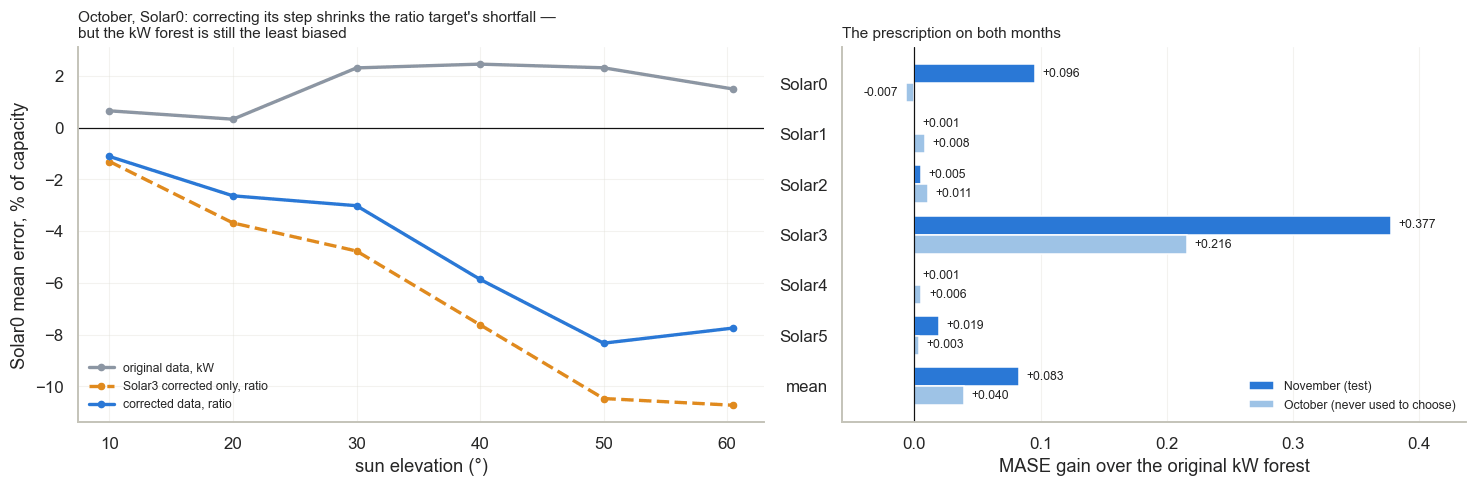

In [100]:
# --- 17c. Cross-check on October, and why Solar0 needs its step corrected --------
train_before_oct = train_day[train_day.index < OCT[0]]
OCT_MODELS = variants(train_before_oct, OCT[0])
oct_board = board_for(OCT_MODELS, OCT)
display(oct_board.round(4))

t = train_before_oct[train_before_oct["array"] == "Solar0"]
cap_o = cap_of(train_before_oct)
ref = reference_with(t, cap_o); ok = ref / cap_o["Solar0"] > 0.05
tgt = pd.Series(t["production_kw"].to_numpy()[ok] / ref[ok], index=t.index[ok])
print("Solar0 ratio targets before October, by regime:")
print(f"  before its step (to 31 Jul): median {tgt.loc[:'2020-07-31'].median():.3f}"
      f"   after (from 2 Aug): median {tgt.loc['2020-08-02':].median():.3f}")


def error_by_sun(fn, name, window, edges):
    """Mean forecast - actual, as % of capacity, binned by sun elevation."""
    w = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    f = w[(w["array"] == name) & w[FEATURES].notna().all(axis=1)]
    p = np.clip(np.asarray(fn(f), dtype=float), 0, None)
    p = np.where(f["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, p)
    fc = expand_to_15min(pd.Series(p, index=f.index), window)
    act = df[name].reindex(fc.index); k = act.notna() & fc.notna()
    e = solar_elevation(fc.index[k] + pd.Timedelta(minutes=7, seconds=30))
    return 100 * ((fc[k] - act[k]) / capacity[name]).groupby(pd.cut(e, edges), observed=True).mean()


gain = pd.DataFrame({
    "November": nov_board.loc["original data, kW"] - nov_board.loc["corrected data, ratio"],
    "October": oct_board.loc["original data, kW"] - oct_board.loc["corrected data, ratio"],
}).loc[SOLAR + ["mean"]]
display(gain.round(4).rename_axis("gain over the original kW forest"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.5), gridspec_kw={"width_ratios": [1.1, 1]})
edges = [5, 15, 25, 35, 45, 55, 66]
for lab, col, ls in [("original data, kW", "#8c96a3", "-"),
                     ("Solar3 corrected only, ratio", "#e08a1e", "--"),
                     ("corrected data, ratio", "#2a78d6", "-")]:
    e = error_by_sun(OCT_MODELS[lab], "Solar0", OCT, edges)
    a1.plot([iv.mid for iv in e.index], e.to_numpy(), color=col, ls=ls, lw=2.2, marker="o", ms=4, label=lab)
a1.axhline(0, color="#111", lw=0.8)
a1.set_xlabel("sun elevation (°)"); a1.set_ylabel("Solar0 mean error, % of capacity")
a1.set_title("October, Solar0: correcting its step shrinks the ratio target's shortfall —\n"
              "but the kW forest is still the least biased", loc="left")
a1.grid(True, alpha=0.4); a1.set_axisbelow(True); a1.legend(fontsize=8, loc="lower left")

y_ = np.arange(len(gain))
a2.barh(y_ - 0.19, gain["November"], 0.38, color="#2a78d6", label="November (test)")
a2.barh(y_ + 0.19, gain["October"], 0.38, color="#9ec3e6", label="October (never used to choose)")
for yi, (n, o) in zip(y_, gain.to_numpy()):
    for v, off in ((n, -0.19), (o, 0.19)):
        a2.text(v + (0.006 if v >= 0 else -0.006), yi + off, f"{v:+.3f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8, color="#222")
a2.set_yticks(y_, gain.index); a2.invert_yaxis()
a2.axvline(0, color="#111", lw=0.8)
a2.set_xlim(min(gain.min().min(), 0) - 0.05, gain.max().max() + 0.06)
a2.set_xlabel("MASE gain over the original kW forest")
a2.set_title("The prescription on both months", loc="left")
a2.legend(fontsize=8, loc="lower right"); a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Three refinements tested and not adopted

Three further changes looked sensible and were tested on both months before being left out:

- **Stricter offline-day cleaning** — dropping any day on which an array never tops 1% of
  capacity while the sun is above 15°. The existing rule only judges days with four bright
  hours, so dull-day zeros from the June–September 2019 outage slipped through.
- **Narrowing Solar3's correction** to October 2019 onward, so it stops rescaling the single
  July 2019 week that 16d shows was already at today's level.
- **A better clear-sky reference.** The ratio target divides by `1361 × sin(elevation) × 0.75`,
  which has no air-mass term and overstates low-sun irradiance (section 10c). The Haurwitz
  model includes air mass; if that bias were behind Solar0's remaining shortfall in 17c,
  swapping it in should help.

The criterion is the same as everywhere else in this section: a change is kept only if it
helps on October as well as November.

In [101]:
# --- 17c (2). Refinements, tested on both months ----------------------------------
def strict_offline(frame):
    """(day, array) pairs where output never tops 1% of capacity while the sun is above 15 deg."""
    cap = cap_of(frame)
    sun = (frame["solar_elevation"] > 15).to_numpy()
    low = (frame["production_kw"] <= 0.01 * frame["array"].map(cap)).to_numpy()
    g = pd.DataFrame({"d": frame.index.normalize(), "a": frame["array"].to_numpy(),
                      "sun": sun, "dead": sun & low}).groupby(["d", "a"])[["sun", "dead"]].sum()
    return set(g[(g["sun"] >= 3) & (g["dead"] == g["sun"])].index)


def strict_clean(frame):
    bad = strict_offline(frame)
    keep = np.array([(d, a) not in bad for d, a in zip(frame.index.normalize(), frame["array"])])
    return frame[keep]


def corrected_narrow(frame, until):
    """As `corrected`, but Solar3's rescale starts in October 2019."""
    out, _ = corrected(frame, until, arrays=("Solar0",))
    t0 = pd.Timestamp(REGIMES["Solar3"]["before_end"], tz=LOCAL_TZ)
    t1 = pd.Timestamp(REGIMES["Solar3"]["after_start"], tz=LOCAL_TZ)
    a = (out["array"] == "Solar3").to_numpy()
    out = out[~(a & (out.index > t0) & (out.index < t1))]
    old = ((out["array"] == "Solar3").to_numpy()
           & (out.index >= pd.Timestamp("2019-10-01", tz=LOCAL_TZ)) & (out.index <= t0))
    out["production_kw"] = np.where(old, out["production_kw"] * step_for("Solar3", until),
                                    out["production_kw"])
    return out


def haurwitz(frame):
    """Haurwitz clear-sky irradiance: includes the air-mass attenuation the linear form lacks."""
    sn = np.sin(np.deg2rad(frame["solar_elevation"].to_numpy()))
    return np.where(sn > 0.02, 1098 * sn * np.exp(-0.057 / np.maximum(sn, 0.02)), 0.0)


HW_MAX = haurwitz(solar_data).max()


def fit_ratio_hw(frame, caps):
    """As the ratio forest in 17b, but normalised by the Haurwitz clear-sky shape."""
    ref = frame["array"].map(caps).to_numpy() * haurwitz(frame) / HW_MAX
    ok = ref / frame["array"].map(caps).to_numpy() > 0.05
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features=0.5,
                              n_jobs=-1, random_state=0).fit(
        make_x(frame)[PRUNED][ok], np.clip(frame["production_kw"].to_numpy()[ok] / ref[ok], 0, 1.5))
    return lambda f: m.predict(make_x(f)[PRUNED]) * f["array"].map(caps).to_numpy() * haurwitz(f) / HW_MAX


refine = {}
for mon, win, board in (("November", NOV, nov_board), ("October", OCT, oct_board)):
    tr = train_day[train_day.index < win[0]]
    refine[(mon, "the prescription")] = board.loc["corrected data, ratio", "mean"]
    for lab, fx in [("+ stricter offline cleaning", corrected(strict_clean(tr), win[0])[0]),
                    ("+ narrower Solar3 correction", corrected_narrow(tr, win[0]))]:
        refine[(mon, lab)] = score_frame(fit_pooled(fx, "ratio", cap_of(fx)), win).mean()
    fx, _ = corrected(tr, win[0])
    refine[(mon, "+ Haurwitz clear-sky reference")] = score_frame(fit_ratio_hw(fx, cap_of(fx)), win).mean()
refine = pd.Series(refine).unstack(0)[["November", "October"]]
refine["change vs prescription, Nov"] = refine["November"] - refine.loc["the prescription", "November"]
refine["change vs prescription, Oct"] = refine["October"] - refine.loc["the prescription", "October"]
display(refine.round(4))

,November,October,"change vs prescription, Nov","change vs prescription, Oct"
+ Haurwitz clear-sky reference,0.6248,0.6420,0.0090,0.0010
+ narrower Solar3 correction,0.6210,0.6357,0.0052,-0.0053
+ stricter offline cleaning,0.6154,0.6409,-0.0004,-0.0001
the prescription,0.6158,0.6410,0.0000,0.0000


## 17d. The LSTM, rebuilt

Section 13's LSTM on the ratio target, retrained on the corrected data with the corrected
capacities. Section 14 showed its architectural variants were indistinguishable within seed
noise, so the plain 13a LSTM is the fair representative. Every seed is scored on its own,
because section 14's seed spread of about 0.04 is larger than many effects in this notebook.

training LSTM (ratio target, corrected data)
  [cache] loaded seeds_LSTM-ratio-corrected (3 networks)
  LSTM-ratio-corrected seed 0: 20 epochs, best val 0.1514


  LSTM-ratio-corrected seed 1: 21 epochs, best val 0.1525


  LSTM-ratio-corrected seed 2: 24 epochs, best val 0.1518


,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5,mean
"LSTM, original data",0.9171,0.4354,0.5117,0.9875,0.5383,0.7095,0.6832
"LSTM, corrected data",0.8395,0.4361,0.5114,0.5835,0.5402,0.7101,0.6034


,original,corrected
seed 0,0.6718,0.5939
seed 1,0.7635,0.6373
seed 2,0.6949,0.6404


seed spread (sd): original 0.0477, corrected 0.0260


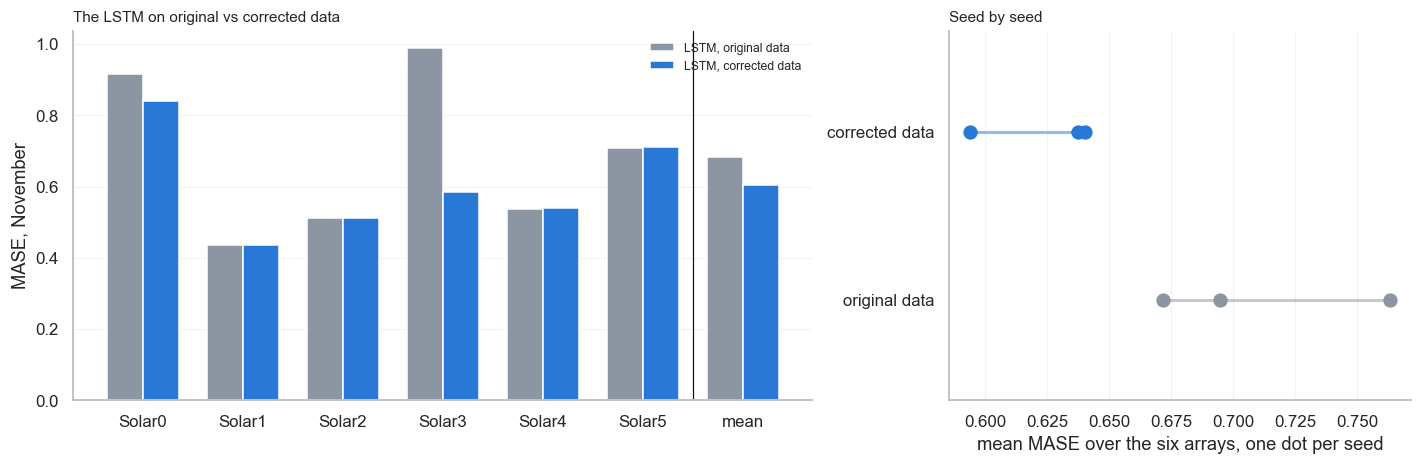

In [102]:
# --- 17d. The LSTM on corrected data -----------------------------------------------
td = train_day[ok_tr]                                   # the rows section 13 trained on
y_fix = td["production_kw"].to_numpy().copy()
keep_rows = np.ones(len(td), dtype=bool)
for s in REGIMES_FIX:
    t0 = pd.Timestamp(REGIMES[s]["before_end"], tz=LOCAL_TZ)
    t1 = pd.Timestamp(REGIMES[s]["after_start"], tz=LOCAL_TZ)
    a = (td["array"] == s).to_numpy()
    keep_rows &= ~(a & (td.index > t0) & (td.index < t1))
    y_fix = np.where(a & (td.index <= t0), y_fix * STEPS[s], y_fix)
ref_fix = reference_with(td, capacity_fix)
ratio_fix = np.clip(y_fix / np.maximum(ref_fix, 1e-6), 0, 1.5).astype("float32")
mask_fix = (ref_fix / td["array"].map(capacity_fix).to_numpy() > 0.05) & keep_rows

print("training LSTM (ratio target, corrected data)")
lstms_fixed = train_seeds(make_lstm, ratio_fix, mask=mask_fix, tag="LSTM-ratio-corrected")


def nets_predict(models_list, caps):
    """Average several ratio-target nets and apply a chosen set of capacities."""
    def fn(frame):
        seq, static, ok = build_inputs(frame)
        raw = np.mean([np.asarray(m([seq, static], training=False)).ravel()
                       for m in models_list], axis=0)
        out = np.zeros(len(frame))
        out[ok] = raw
        return out * reference_with(frame, caps)
    return fn


lstm_board = pd.DataFrame({
    "LSTM, original data": score_frame(nn_predict(lstms_ratio, as_ratio=True), NOV),
    "LSTM, corrected data": score_frame(nets_predict(lstms_fixed, capacity_fix), NOV),
}).T[SOLAR]
lstm_board["mean"] = lstm_board.mean(axis=1)
display(lstm_board.round(4))

per_seed = pd.DataFrame({
    "original": [score_frame(nn_predict([m], as_ratio=True), NOV).mean() for m in lstms_ratio],
    "corrected": [score_frame(nets_predict([m], capacity_fix), NOV).mean() for m in lstms_fixed],
}, index=[f"seed {i}" for i in range(len(lstms_fixed))])
display(per_seed.round(4))
print(f"seed spread (sd): original {per_seed['original'].std():.4f}, "
      f"corrected {per_seed['corrected'].std():.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})
cols = SOLAR + ["mean"]; x = np.arange(len(cols))
for k, (row, c) in enumerate(zip(lstm_board.index, ["#8c96a3", "#2a78d6"])):
    a1.bar(x + (k - 0.5) * 0.36, lstm_board.loc[row, cols], 0.36, color=c, label=row)
a1.axvline(len(SOLAR) - 0.5, color="#111", lw=0.8)
a1.set_xticks(x, cols); a1.set_ylabel("MASE, November")
a1.set_title("The LSTM on original vs corrected data", loc="left")
a1.legend(fontsize=8); a1.grid(True, axis="y", alpha=0.4); a1.set_axisbelow(True)
for k, (col, c) in enumerate(zip(per_seed.columns, ["#8c96a3", "#2a78d6"])):
    a2.scatter(per_seed[col], [k] * len(per_seed), s=70, color=c, zorder=3)
    a2.plot([per_seed[col].min(), per_seed[col].max()], [k, k], color=c, lw=2, alpha=0.5)
a2.set_yticks([0, 1], ["original data", "corrected data"]); a2.set_ylim(-0.6, 1.6)
a2.set_xlabel("mean MASE over the six arrays, one dot per seed")
a2.set_title("Seed by seed", loc="left")
a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 17e. Where the rebuilt models stand

,MASE Nov,built
"LSTM, corrected data, ratio (17)",0.6034,with the section 16 fixes
"RF, corrected data, ratio (17)",0.6158,with the section 16 fixes
"RF, corrected data, kW (17)",0.6402,with the section 16 fixes
L2 + centred window,0.6657,before section 16
blend 1.00 LSTM / 0.00 CNN,0.6657,before section 16
L3 + bidirectional,0.6699,before section 16
"RF (pruned, ratio)",0.6775,before section 16
LSTM (ratio),0.6832,before section 16
L0 13a baseline,0.6832,before section 16
L1 + slower schedule,0.6876,before section 16


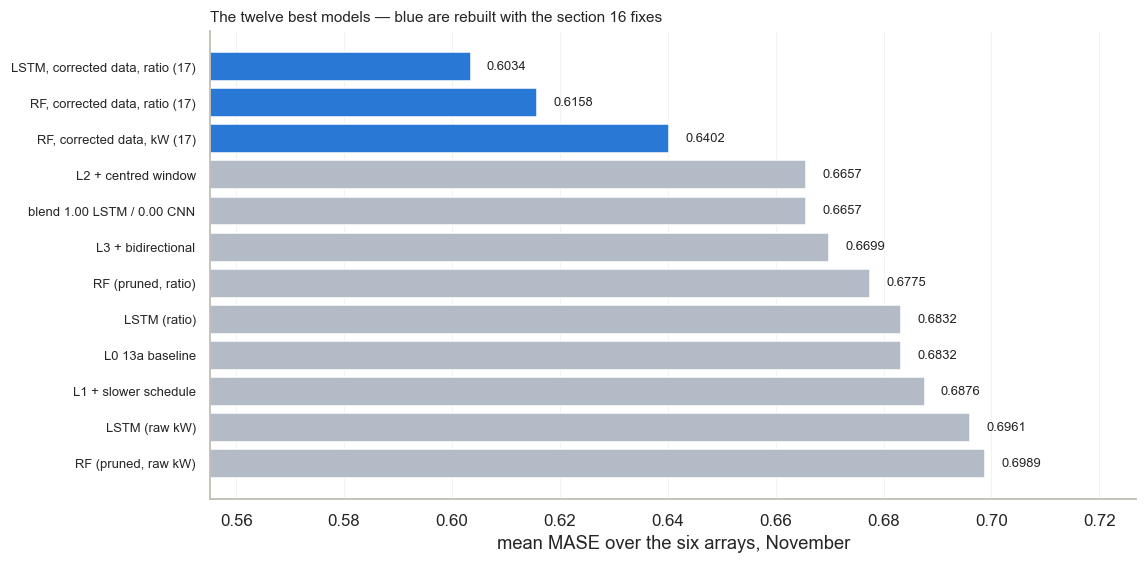

In [103]:
# --- 17e. The rebuilt models against everything before them ----------------------
new = pd.Series({
    "RF, corrected data, ratio (17)": nov_board.loc["corrected data, ratio", "mean"],
    "RF, corrected data, kW (17)": nov_board.loc["corrected data, kW", "mean"],
    "LSTM, corrected data, ratio (17)": lstm_board.loc["LSTM, corrected data", "mean"],
})
before = master["MASE Nov"].astype(float)
leader = pd.concat([before.rename("MASE Nov").to_frame().assign(built="before section 16"),
                    new.rename("MASE Nov").to_frame().assign(built="with the section 16 fixes")])
leader = leader.sort_values("MASE Nov")
display(leader.round(4))

top = leader.head(12)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
colors = ["#2a78d6" if b == "with the section 16 fixes" else "#b3bcc6" for b in top["built"]]
ax.barh(range(len(top)), top["MASE Nov"], color=colors)
for i, v in enumerate(top["MASE Nov"]):
    ax.text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=8.5, color="#222")
ax.set_yticks(range(len(top)), top.index, fontsize=8.5); ax.invert_yaxis()
ax.set_xlim(top["MASE Nov"].min() * 0.92, top["MASE Nov"].max() * 1.04)
ax.set_xlabel("mean MASE over the six arrays, November")
ax.set_title("The twelve best models — blue are rebuilt with the section 16 fixes", loc="left")
ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 17

**The corrected LSTM is the best model in the notebook at this point: 0.6034**, down from 0.6832 for the same
architecture on the original data, and ahead of every model built before section 16 (the best
of those was 0.6657). Unlike section 14's ladder, this gain clears the seed noise: every
corrected seed (0.594, 0.637, 0.640) beats every original seed (0.672, 0.764, 0.695), and the
spread between seeds nearly halves (0.048 → 0.026). Almost all of it comes from two arrays —
Solar3 0.988 → 0.584 and Solar0 0.917 → 0.840 — while the other four move by less than 0.002.

**The pooled forest improves the same way**: 0.6989 → 0.6158 on November and, the more
important number, 0.6805 → 0.6410 on **October**, a month none of these choices were made on.
The October gain is about half the November one. That is what honest out-of-sample shrinkage
looks like, and it is still clearly real.

**What held, and what did not:**

- **Solar3's correction is robust.** It gains 0.377 in November and 0.216 in October over the
  original forest, and its step measures 1.503 before November against 1.501 with November
  included — the test month barely moves it.
- **Solar0's is partial, and the October check is how we know.** Correcting Solar3 alone, the
  ratio target made Solar0 *worse* in October (0.9625 against 0.9112 for the kW forest).
  Dividing out the sun's height exposes Solar0's August step, which raw kW hides by
  confusing it with the season: before the step the median target ratio is 0.413, after it
  0.841 (17c). Correcting that step too brings Solar0 to 0.9181 — level with the kW forest,
  not better — and it stays biased low as the sun climbs. What remains is that Solar0 has
  only seen winter and early spring, so its ratio is learned from low-sun months and
  extrapolated to brighter ones. No formula fixes that; a full year of data would.
- **The kW forest gains nothing from correcting Solar0** (0.9435 → 0.9588 in November). In
  kW the season was already separating the two regimes, so rescaling one of them only costs.
- **Solar5 was left alone**, and moves by 0.003 in October — as it should, since nothing was
  changed for it.

**Three refinements were tested on both months and rejected** (17c): stricter offline
cleaning, a narrower Solar3 correction, and an air-mass-corrected clear-sky reference. None
moves the mean by more than 0.01 on either month, and none improves both months by more than
rounding. The simple version stays.

**Caveats.** November still decided which arrays to investigate, so its numbers here are
optimistic; **October's are the ones to quote** as an honest estimate of what the corrections
buy. The Solar3 correction also rescales one July 2019 week that was already at today's level
(the outlier top-left in 17a); narrowing it made no consistent difference, since it is a
single week. And the step dates were read off the weekly plots rather than fitted — a
change-point method would make them reproducible.

---

# 18. Further improvements

Section 17 left three gaps, and each one suggests something to try:

| Gap | What it suggests | Section |
|---|---|---|
| The corrected LSTM, the best model so far, was only scored on November — the month that prompted the fixes | train it again on data before October and score October | 18a |
| MASE scores **absolute** error, but the forest and the section 11 boosting minimise **squared** error | a model whose loss matches the metric | 18b |
| The LSTM and the tree models are built very differently, so they may make different mistakes | average them, with equal weights so there is nothing to tune on the test month | 18c |

The rule is the one section 17 used: **a change is kept only if it helps on October as well
as November.** Every October model is trained only on data before October, with its steps and
capacities also measured before October.

## 18a. Does the corrected LSTM hold up on October?

training LSTM (ratio target, corrected data, before October)


  [cache] loaded seeds_LSTM-ratio-corrected-preOct (3 networks)
  LSTM-ratio-corrected-preOct seed 0: 18 epochs, best val 0.1750


  LSTM-ratio-corrected-preOct seed 1: 19 epochs, best val 0.1791


  LSTM-ratio-corrected-preOct seed 2: 20 epochs, best val 0.1819


training LSTM (ratio target, original data, before October)
  [cache] loaded seeds_LSTM-ratio-original-preOct (3 networks)
  LSTM-ratio-original-preOct seed 0: 17 epochs, best val 0.2019


  LSTM-ratio-original-preOct seed 1: 24 epochs, best val 0.2053


  LSTM-ratio-original-preOct seed 2: 20 epochs, best val 0.2077


,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5,mean
"RF, original data, kW",0.9112,0.4609,0.5358,0.8152,0.5640,0.7958,0.6805
"RF, corrected data, ratio (17)",0.9181,0.4526,0.5252,0.5992,0.5584,0.7924,0.6410
"LSTM, original data",0.8865,0.4199,0.4813,0.7472,0.5150,0.7193,0.6282
"LSTM, corrected data",0.8331,0.4288,0.4892,0.5586,0.5247,0.7332,0.5946


,original,corrected
seed 0,0.6676,0.6167
seed 1,0.6256,0.6084
seed 2,0.6597,0.6097


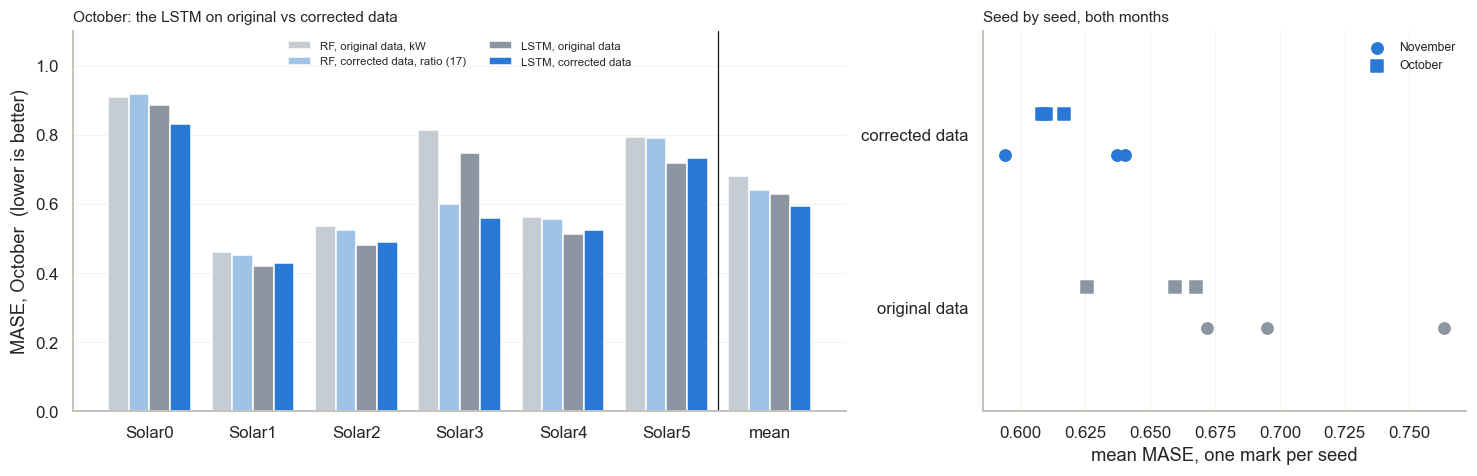

In [104]:
# --- 18a. The corrected LSTM on October -------------------------------------------
def ratio_inputs(until, arrays=REGIMES_FIX):
    """Section 13's ratio target on the LSTM's rows before `until`, with `arrays` corrected
    exactly as in 17a (steps and capacities measured before `until`)."""
    fx, _ = corrected(train_day[train_day.index < until], until, arrays)
    caps = cap_of(fx)
    y = td["production_kw"].to_numpy().copy()
    keep = np.asarray(td.index < until)
    for s in arrays:
        t0 = pd.Timestamp(REGIMES[s]["before_end"], tz=LOCAL_TZ)
        t1 = pd.Timestamp(REGIMES[s]["after_start"], tz=LOCAL_TZ)
        a = (td["array"] == s).to_numpy()
        keep &= ~(a & (td.index > t0) & (td.index < t1))
        y = np.where(a & (td.index <= t0), y * step_for(s, until), y)
    ref = reference_with(td, caps)
    r = np.clip(y / np.maximum(ref, 1e-6), 0, 1.5).astype("float32")
    mask = (ref / td["array"].map(caps).to_numpy() > 0.05) & keep
    return r, mask, caps


r_n, m_n, c_n = ratio_inputs(NOV[0])          # the November version must reproduce 17d
assert np.allclose(r_n, ratio_fix) and (m_n == mask_fix).all()

LSTM_OCT = {}
for lab, arrays in (("corrected", REGIMES_FIX), ("original", ())):
    r, mask, caps = ratio_inputs(OCT[0], arrays)
    print(f"training LSTM (ratio target, {lab} data, before October)")
    LSTM_OCT[lab] = (train_seeds(make_lstm, r, mask=mask, tag=f"LSTM-ratio-{lab}-preOct"), caps)

oct_nn = pd.DataFrame({
    "RF, original data, kW": oct_board.loc["original data, kW", SOLAR],
    "RF, corrected data, ratio (17)": oct_board.loc["corrected data, ratio", SOLAR],
    "LSTM, original data": score_frame(nets_predict(*LSTM_OCT["original"]), OCT),
    "LSTM, corrected data": score_frame(nets_predict(*LSTM_OCT["corrected"]), OCT),
}).T
oct_nn["mean"] = oct_nn.mean(axis=1)
display(oct_nn.round(4))

oct_seeds = pd.DataFrame({
    lab: [score_frame(nets_predict([m], LSTM_OCT[lab][1]), OCT).mean() for m in LSTM_OCT[lab][0]]
    for lab in ("original", "corrected")}, index=[f"seed {i}" for i in range(3)])
display(oct_seeds.round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
cols = SOLAR + ["mean"]; x = np.arange(len(cols))
shades = ["#c5ccd3", "#9ec3e6", "#8c96a3", "#2a78d6"]
for k, (row, c) in enumerate(zip(oct_nn.index, shades)):
    a1.bar(x + (k - 1.5) * 0.2, oct_nn.loc[row, cols], 0.2, color=c, label=row)
a1.axvline(len(SOLAR) - 0.5, color="#111", lw=0.8)
a1.set_xticks(x, cols); a1.set_ylabel("MASE, October  (lower is better)")
a1.set_title("October: the LSTM on original vs corrected data", loc="left")
a1.legend(fontsize=7.5, ncol=2, loc="upper center")
a1.set_ylim(0, oct_nn[cols].max().max() * 1.2)
a1.grid(True, axis="y", alpha=0.4); a1.set_axisbelow(True)
for k, (lab, c) in enumerate([("original", "#8c96a3"), ("corrected", "#2a78d6")]):
    for yoff, (vals, mk) in zip((-0.12, 0.12), ((per_seed[lab], "o"), (oct_seeds[lab], "s"))):
        a2.scatter(vals, [k + yoff] * len(vals), s=55, color=c, marker=mk, zorder=3,
                   label=("November" if mk == "o" else "October") if k == 1 else None)
a2.set_yticks([0, 1], ["original data", "corrected data"]); a2.set_ylim(-0.6, 1.6)
a2.set_xlabel("mean MASE, one mark per seed")
a2.set_title("Seed by seed, both months", loc="left")
a2.legend(fontsize=8, loc="upper right"); a2.grid(True, axis="x", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 18b. A loss that matches the metric

MASE divides the mean **absolute** error by a fixed scale, so the forecast that minimises it
is the *median* of what the array might produce in that hour, not the mean. The random forest
averages the targets in its leaves, which gives the mean, and section 11's boosting used squared
error, which also gives the mean. When output given the weather is skewed — a cloudy hour is
mostly dull with occasional bright breaks — the mean and the median differ, and the model
aims at the wrong point.

`HistGradientBoostingRegressor` can minimise absolute error directly. Below it is fitted
with section 11's settings, on section 17's corrected data and ratio target, once with each
loss. Everything else is held fixed, so any difference comes from the loss alone. Three seeds
each, because boosting's early-stopping check draws a random validation split. The neural
networks in sections 12–14 were already trained on absolute error (`loss="mae"`).

  [cache] loaded hgb_loss_18


mean     std     min     max
month    loss                                          
November absolute_error  0.6085  0.0020  0.6061  0.6098
         squared_error   0.6385  0.0106  0.6280  0.6491
October  absolute_error  0.6046  0.0032  0.6026  0.6083
         squared_error   0.6305  0.0046  0.6261  0.6352

Solar0  Solar1  Solar2  Solar3  Solar4  Solar5
month    loss (mean of 3 seeds)                                                
November absolute_error          0.8271  0.4459  0.5237  0.5823  0.5472  0.7246
         squared_error           0.8521  0.4644  0.5651  0.6127  0.5718  0.7650
October  absolute_error          0.8469  0.4307  0.5019  0.5623  0.5328  0.7531
         squared_error           0.8702  0.4496  0.5329  0.5802  0.5608  0.7890

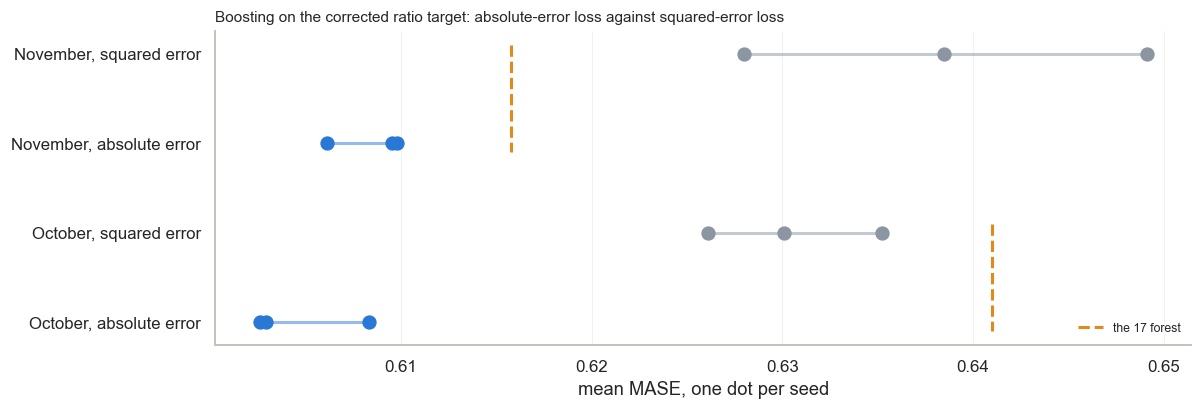

In [105]:
# --- 18b. A loss that matches the metric -------------------------------------------
def fit_hgb(frame, caps, loss="absolute_error", seed=0):
    """Section 11's boosting settings on 17's corrected ratio target, with a chosen loss."""
    X, y = make_x(frame)[PRUNED], frame["production_kw"].to_numpy()
    ref = reference_with(frame, caps); ok = ref / frame["array"].map(caps).to_numpy() > 0.05
    m = HistGradientBoostingRegressor(loss=loss, max_iter=400, learning_rate=0.06,
                                      min_samples_leaf=20, l2_regularization=1.0,
                                      random_state=seed).fit(X[ok], np.clip(y[ok] / ref[ok], 0, 1.5))
    return lambda f: m.predict(make_x(f)[PRUNED]) * reference_with(f, caps)


def _loss_runs():
    rows = []
    for mon, win in (("November", NOV), ("October", OCT)):
        fx, _ = corrected(train_day[train_day.index < win[0]], win[0])
        for loss in ("squared_error", "absolute_error"):
            for seed in (0, 1, 2):
                s = score_frame(fit_hgb(fx, cap_of(fx), loss, seed), win)
                rows.append({"month": mon, "loss": loss, "seed": seed, **s.to_dict(),
                             "mean": s.mean()})
    return rows


loss_runs = pd.DataFrame(cached("hgb_loss_18", _loss_runs))
loss_summary = loss_runs.groupby(["month", "loss"])["mean"].agg(["mean", "std", "min", "max"])
display(loss_summary.round(4))
display(loss_runs.groupby(["month", "loss"])[SOLAR].mean().round(4)
        .rename_axis(["month", "loss (mean of 3 seeds)"]))

fig, ax = plt.subplots(figsize=(11, 3.8))
rows_ = [("November", "squared_error"), ("November", "absolute_error"),
         ("October", "squared_error"), ("October", "absolute_error")]
for k, (mon, loss) in enumerate(rows_):
    v = loss_runs[(loss_runs["month"] == mon) & (loss_runs["loss"] == loss)]["mean"]
    c = "#2a78d6" if loss == "absolute_error" else "#8c96a3"
    ax.scatter(v, [k] * len(v), s=70, color=c, zorder=3)
    ax.plot([v.min(), v.max()], [k, k], color=c, lw=2, alpha=0.5)
for mon, k in (("November", 0.5), ("October", 2.5)):
    rf = (nov_board if mon == "November" else oct_board).loc["corrected data, ratio", "mean"]
    ax.plot([rf, rf], [k - 0.6, k + 0.6], color="#e08a1e", lw=2, ls="--",
            label="the 17 forest" if mon == "November" else None)
ax.set_yticks(range(4), [f"{m}, {l.replace('_', ' ')}" for m, l in rows_])
ax.invert_yaxis(); ax.set_xlabel("mean MASE, one dot per seed")
ax.set_title("Boosting on the corrected ratio target: absolute-error loss against squared-error loss",
             loc="left")
ax.legend(fontsize=8, loc="lower right"); ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 18c. Averaging different kinds of model

Section 14 blended the LSTM with the CNN and found nothing to gain: both are neural networks
reading the same 24-hour weather window, and the blend put all its weight on the LSTM. A tree
model is a better partner because it reads the same features in a completely different way.
Every blend here is a plain equal-weight average of the kW forecasts. There is no weight to
fit, so November cannot leak into it.

,November,October
LSTM + HGB,0.5926,0.5807
LSTM + HGB + RF,0.5915,0.5909
LSTM ratio (17),0.6034,0.5946
LSTM + RF,0.5893,0.5948
HGB absolute-error ratio,0.6098,0.6026
HGB + RF,0.6064,0.6132
RF ratio (17),0.6158,0.6410


Solar0  Solar1  Solar2  Solar3  Solar4  Solar5    mean
November RF ratio (17)             0.8480  0.4413  0.5354  0.5915  0.5514  0.7271  0.6158
         HGB absolute-error ratio  0.8330  0.4485  0.5214  0.5833  0.5464  0.7260  0.6098
         LSTM ratio (17)           0.8395  0.4361  0.5114  0.5835  0.5402  0.7101  0.6034
         LSTM + HGB                0.8110  0.4324  0.5054  0.5728  0.5309  0.7034  0.5926
         LSTM + RF                 0.8012  0.4247  0.5078  0.5680  0.5318  0.7021  0.5893
         HGB + RF                  0.8311  0.4388  0.5224  0.5804  0.5447  0.7209  0.6064
         LSTM + HGB + RF           0.8064  0.4283  0.5078  0.5691  0.5322  0.7051  0.5915
October  RF ratio (17)             0.9181  0.4526  0.5252  0.5992  0.5584  0.7924  0.6410
         HGB absolute-error ratio  0.8499  0.4274  0.4990  0.5593  0.5306  0.7492  0.6026
         LSTM ratio (17)           0.8331  0.4288  0.4892  0.5586  0.5247  0.7332  0.5946
         LSTM + HGB                0.8104  0.4139  0.4811  0.5403  0.5146  0.7241  0.5807
         LSTM + RF                 0.8259  0.4248  0.4919  0.5553  0.5273  0.7434  0.5948
         HGB + RF                  0.8631  0.4346  0.5063  0.5722  0.5387  0.7644  0.6132
         LSTM + HGB + RF           0.8233  0.4202  0.4896  0.5503  0.5232  0.7390  0.5909

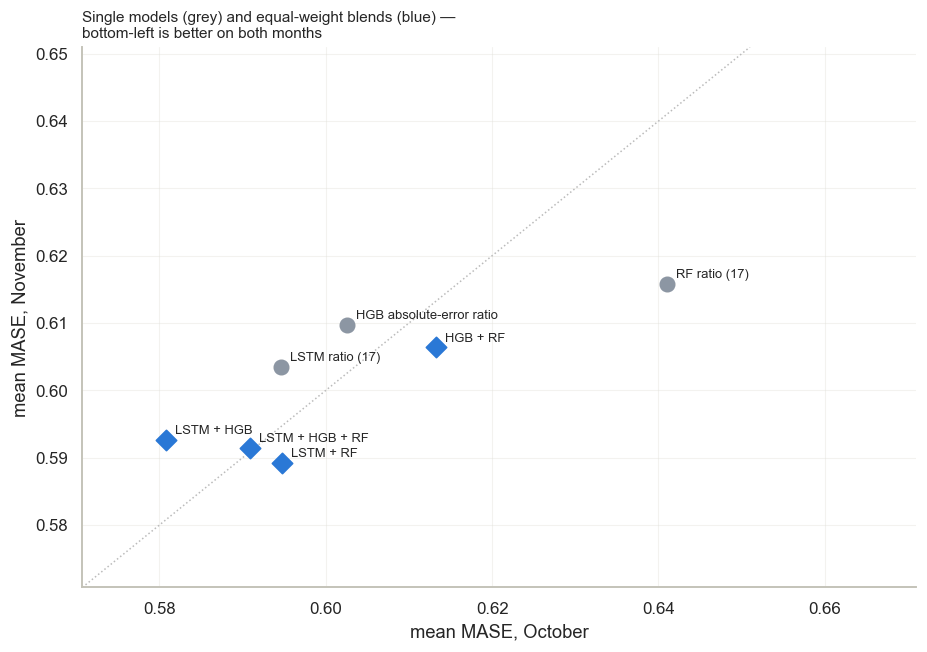

In [106]:
# --- 18c. Averaging different kinds of model ---------------------------------------
def blend(*fns):
    """Equal-weight average of several frame -> kW predictors: no weight to tune."""
    return lambda f: np.mean([np.clip(np.asarray(fn(f), dtype=float), 0, None) for fn in fns], axis=0)


BLEND = {}
for mon, win in (("November", NOV), ("October", OCT)):
    fx, _ = corrected(train_day[train_day.index < win[0]], win[0])
    hgb = fit_hgb(fx, cap_of(fx))
    rf = (POOLED if mon == "November" else OCT_MODELS)["corrected data, ratio"]
    lstm = nets_predict(lstms_fixed, capacity_fix) if mon == "November" else nets_predict(*LSTM_OCT["corrected"])
    for lab, fn in {"RF ratio (17)": rf, "HGB absolute-error ratio": hgb, "LSTM ratio (17)": lstm,
                    "LSTM + HGB": blend(lstm, hgb), "LSTM + RF": blend(lstm, rf),
                    "HGB + RF": blend(hgb, rf), "LSTM + HGB + RF": blend(lstm, hgb, rf)}.items():
        BLEND[(mon, lab)] = score_frame(fn, win)
blend_board = pd.DataFrame(BLEND).T
blend_board["mean"] = blend_board.mean(axis=1)
both = blend_board["mean"].unstack(0)[["November", "October"]].sort_values("October")
display(both.round(4))
display(blend_board.round(4))

fig, ax = plt.subplots(figsize=(8.5, 6))
for lab, (n, o) in both.iterrows():
    single = "+" not in lab
    ax.scatter(o, n, s=90, color="#8c96a3" if single else "#2a78d6", marker="o" if single else "D",
               zorder=3)
    ax.annotate(lab, (o, n), xytext=(6, 4), textcoords="offset points", fontsize=8.5)
lo = both.min().min() - 0.01; hi = both.max().max() + 0.01
ax.plot([lo, hi], [lo, hi], color="#bbb", lw=1, ls=":")
ax.set_xlim(lo, hi + 0.02); ax.set_ylim(lo, hi)
ax.set_xlabel("mean MASE, October"); ax.set_ylabel("mean MASE, November")
ax.set_title("Single models (grey) and equal-weight blends (blue) —\nbottom-left is better on both months",
             loc="left")
ax.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 18d. Where everything stands, on both months

,November,October,mean of the two months
LSTM + HGB,0.5926,0.5807,0.5867
LSTM + HGB + RF,0.5915,0.5909,0.5912
LSTM + RF,0.5893,0.5948,0.5920
LSTM ratio (17),0.6034,0.5946,0.5990
HGB absolute-error ratio,0.6098,0.6026,0.6062
HGB + RF,0.6064,0.6132,0.6098
RF ratio (17),0.6158,0.6410,0.6284
"LSTM, original data (13)",0.6832,0.6282,0.6557
"RF, original data, kW (11e)",0.6989,0.6805,0.6897


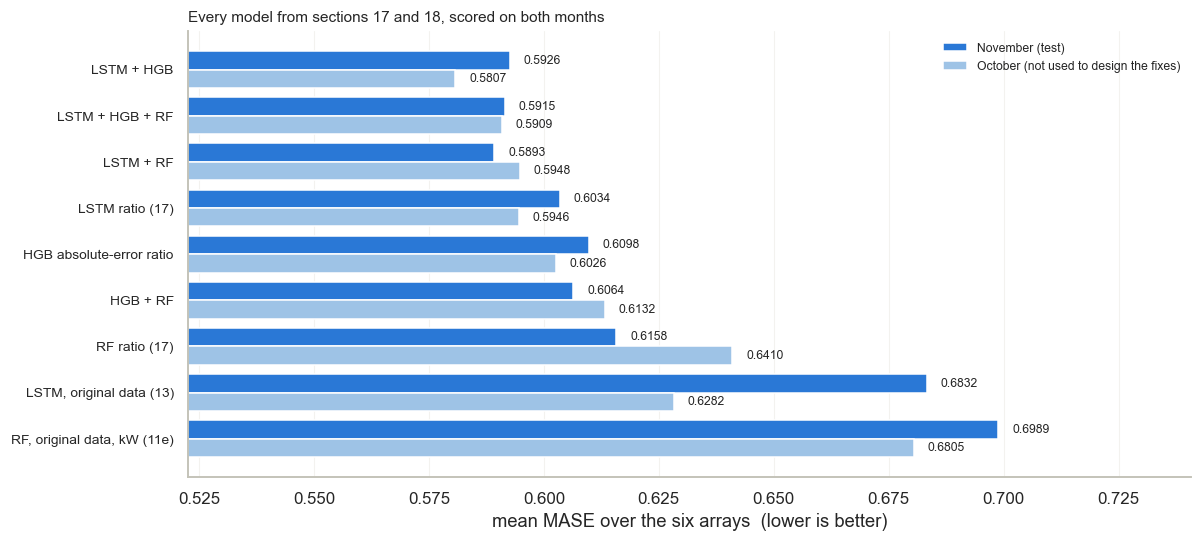

In [107]:
# --- 18d. The final comparison, on both months --------------------------------------
final = pd.DataFrame({
    "RF, original data, kW (11e)": [nov_board.loc["original data, kW", "mean"],
                                    oct_board.loc["original data, kW", "mean"]],
    "LSTM, original data (13)": [lstm_board.loc["LSTM, original data", "mean"],
                                 oct_nn.loc["LSTM, original data", "mean"]],
}, index=["November", "October"]).T
for lab in both.index:
    final.loc[lab] = both.loc[lab]
final["mean of the two months"] = final[["November", "October"]].mean(axis=1)
final = final.sort_values("mean of the two months")
display(final.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
y_ = np.arange(len(final))
ax.barh(y_ - 0.2, final["November"], 0.4, color="#2a78d6", label="November (test)")
ax.barh(y_ + 0.2, final["October"], 0.4, color="#9ec3e6", label="October (not used to design the fixes)")
for yi, (n, o) in zip(y_, final[["November", "October"]].to_numpy()):
    ax.text(n + 0.003, yi - 0.2, f"{n:.4f}", va="center", fontsize=8)
    ax.text(o + 0.003, yi + 0.2, f"{o:.4f}", va="center", fontsize=8)
ax.set_yticks(y_, final.index, fontsize=9); ax.invert_yaxis()
ax.set_xlim(final[["November", "October"]].min().min() * 0.9,
            final[["November", "October"]].max().max() * 1.06)
ax.set_xlabel("mean MASE over the six arrays  (lower is better)")
ax.set_title("Every model from sections 17 and 18, scored on both months", loc="left")
ax.legend(fontsize=8, loc="upper right"); ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 18

**The corrected LSTM holds up on October.** Trained only on data before October, it scores
0.5946 against 0.6282 for the same LSTM on the original data, and every corrected seed
(0.608–0.617) beats every original seed (0.626–0.668). The October gain of 0.034 is less than
half the November gain of 0.080. That is the expected pattern: November is the month that
prompted the fixes, so its gain is inflated, and 0.034 is the fairer figure to quote. The
October gain sits entirely in the two corrected arrays (Solar3 0.747 → 0.559, Solar0
0.887 → 0.833). The four untouched arrays each get slightly *worse*, by about 0.01. The fix
works where it is aimed and costs a little everywhere else.

**Matching the loss to the metric helps, and the result is stable across seeds.** On the same
corrected data and ratio target, absolute-error boosting averages 0.6085 in November and 0.6046
in October across three seeds. Squared-error boosting averages 0.6385 and 0.6305. The worst
absolute-error seed beats the best squared-error seed in both months, and the seed spread is
at most 0.003. The absolute-error model also beats section 17's forest on both months
(0.6098 vs 0.6158 in November, 0.6026 vs 0.6410 in October). In October it is better on all six
arrays, and the largest single gain is Solar0 (0.850 vs 0.918). In November it is better on
five, losing only Solar1 (0.449 vs 0.441).

**One blend passes the both-months rule: LSTM + boosting.** The equal-weight average of the
corrected LSTM and the absolute-error boosting scores **0.5926 in November and 0.5807 in
October**. That beats the LSTM alone on both months (0.6034, 0.5946), and it beats it on every
one of the six arrays in both months. The other blends fail the rule. LSTM + forest improves
November (0.5893) but only ties the LSTM in October (0.5948). Adding the forest as a third
member makes October worse (0.5909).

**Honest caveat.** October was never used to design the fixes or the models, but it *was*
used to choose among these blends. The final pick is therefore not fully untouched by October.
What does not depend on that choice: every blend that pairs the LSTM with a tree model beats
every single model in November, and on October the LSTM + boosting blend beats the next-best
model by 0.010.

**Still not fixed.** Solar0 (0.81) and Solar5 (0.70–0.72) remain the two worst arrays under
every model. Solar0 needs a summer of its own data. Solar5's cause is still unknown.

---

# 19. A rolling-origin backtest: six test months instead of two

Every comparison so far rests on November, with October as the one cross-check. Two months
make a small sample. They are also both spring months, when the sun climbs higher than it
has been all year. A model that happens to suit spring could look best without being best.

A **rolling-origin backtest** repeats the whole exercise once per month, from June to
November 2020. Each month is forecast by models trained **only on data before it**, and it
is scored against a MASE scale computed only from data before it. June is the earliest usable
month: Solar0 only starts on 26 April 2020, and Solar5 was mostly offline in April and May.

**The corrections have to be earned as well.** A forecaster standing at 1 July could not
correct Solar0 for a step that happens on 2 August. So in each month an array is corrected
only if at least **four weeks** of its new regime come before the start of that month, and
its step is measured on those weeks alone. That gives:

| Test month | Corrected arrays |
|---|---|
| June | none — Solar3's new regime starts 31 May |
| July, August | Solar3 |
| September onward | Solar3 and Solar0 |

Every model is the one from sections 17–18, refitted per month. The LSTMs are cached per
month, three seeds each. October and November reproduce sections 17–18 exactly.

**What is not rebuilt per month:** the feature list (section 11's pruning), the model
settings, the regime dates found in section 16, and the input scalers were all settled using
data up to November. The backtest therefore tests *the recipe*, not every decision behind it.

## 19a. The backtest

In [108]:
# --- 19a. Six test months, each trained only on the past ---------------------------
MIN_SEEN = pd.Timedelta(days=28)
FOLDS = {m: (pd.Timestamp(f"2020-{k:02d}-01", tz="UTC"), pd.Timestamp(f"2020-{k + 1:02d}-01", tz="UTC"))
         for m, k in [("Jun", 6), ("Jul", 7), ("Aug", 8), ("Sep", 9), ("Oct", 10), ("Nov", 11)]}


def eligible(until):
    """Arrays whose new regime has been seen for at least four weeks before `until` -
    only those can be corrected by a forecaster standing at `until`."""
    return tuple(s for s in REGIMES_FIX
                 if pd.Timestamp(REGIMES[s]["after_start"], tz=LOCAL_TZ) + MIN_SEEN <= until)


def naive_scores(win):
    """MASE of the 28-day seasonal naive itself on the test month."""
    idx = pd.date_range(win[0], win[1], freq="15min", inclusive="left").tz_convert(LOCAL_TZ)
    out = {}
    for s in SOLAR:
        fc, act = df[s].shift(SEASONAL_LAG).reindex(idx), df[s].reindex(idx)
        ok = fc.notna() & act.notna()
        out[s] = np.mean(np.abs(act[ok] - fc[ok])) / mase_scale(s, win[0])
    return pd.Series(out)


def fold_lstm(mon, win, arrays):
    """The ratio-target LSTM for one fold (cached); November reuses 13 and 17d's nets."""
    lab = "corrected" if arrays else "original"
    if mon == "Nov":
        return nets_predict(lstms_fixed, capacity_fix) if arrays else nn_predict(lstms_ratio, as_ratio=True)
    r, mask, caps = ratio_inputs(win[0], arrays)
    tag = f"LSTM-ratio-{lab}-preOct" if mon == "Oct" else f"LSTM-ratio-{lab}-pre{mon}"
    return nets_predict(train_seeds(make_lstm, r, mask=mask, tag=tag), caps)


def _backtest():
    BT, FIXED = {}, {}
    for mon, win in FOLDS.items():
        arrays = eligible(win[0]); FIXED[mon] = arrays
        print(f"--- {mon} 2020: corrected arrays: {', '.join(arrays) or 'none yet'}")
        tr = train_day[train_day.index < win[0]]
        fx, _ = corrected(tr, win[0], arrays)
        hgb = fit_hgb(fx, cap_of(fx))
        l_orig = fold_lstm(mon, win, ())
        l_fix = fold_lstm(mon, win, arrays) if arrays else l_orig
        models = {
            "seasonal naive": None,
            "RF, original data, kW": fit_pooled(tr, "kW"),
            "RF, corrected, ratio": fit_pooled(fx, "ratio", cap_of(fx)),
            "HGB absolute-error, corrected, ratio": hgb,
            "LSTM, original data": l_orig,
            "LSTM, corrected": l_fix,
            "LSTM + HGB": blend(l_fix, hgb),
        }
        for k, fn in models.items():
            BT[(mon, k)] = naive_scores(win) if fn is None else score_frame(fn, win)
    return BT, FIXED


BT, FIXED = cached("backtest_19", _backtest)      # every score, so a re-run skips the refits
bt = pd.DataFrame(BT).T
bt["mean"] = bt[SOLAR].mean(axis=1)
by_month = bt["mean"].unstack(0)[list(FOLDS)]
by_month = by_month.loc[by_month.mean(axis=1).sort_values().index]
by_month["mean of 6 months"] = by_month[list(FOLDS)].mean(axis=1)
by_month["best in"] = [int((by_month.loc[m, list(FOLDS)] == by_month.loc[by_month.index != "seasonal naive",
                                                                          list(FOLDS)].min()).sum())
                       for m in by_month.index]
display(by_month.round(4))

  [cache] loaded backtest_19


,Jun,Jul,Aug,Sep,Oct,Nov,mean of 6 months,best in
"HGB absolute-error, corrected, ratio",0.4505,0.3863,0.6243,0.5434,0.6026,0.6098,0.5361,2
LSTM + HGB,0.4530,0.4033,0.6400,0.5663,0.5807,0.5926,0.5393,2
"RF, corrected, ratio",0.4231,0.3879,0.6662,0.6027,0.6410,0.6158,0.5561,0
"LSTM, corrected",0.4696,0.4400,0.6686,0.6113,0.5946,0.6034,0.5646,0
"RF, original data, kW",0.3787,0.3729,0.6444,0.6405,0.6805,0.6989,0.5693,2
"LSTM, original data",0.4696,0.4423,0.6938,0.7878,0.6282,0.6832,0.6175,0
seasonal naive,1.2393,0.4897,0.8771,1.1517,1.1074,1.4035,1.0448,0


## 19b. Month by month

The top panel shows each model's mean MASE per month. The bottom panel shows each model's gain
over the original kW forest from section 11, so a line above zero means the section 16–18
changes helped that month. The labels along the top show which corrections were available.

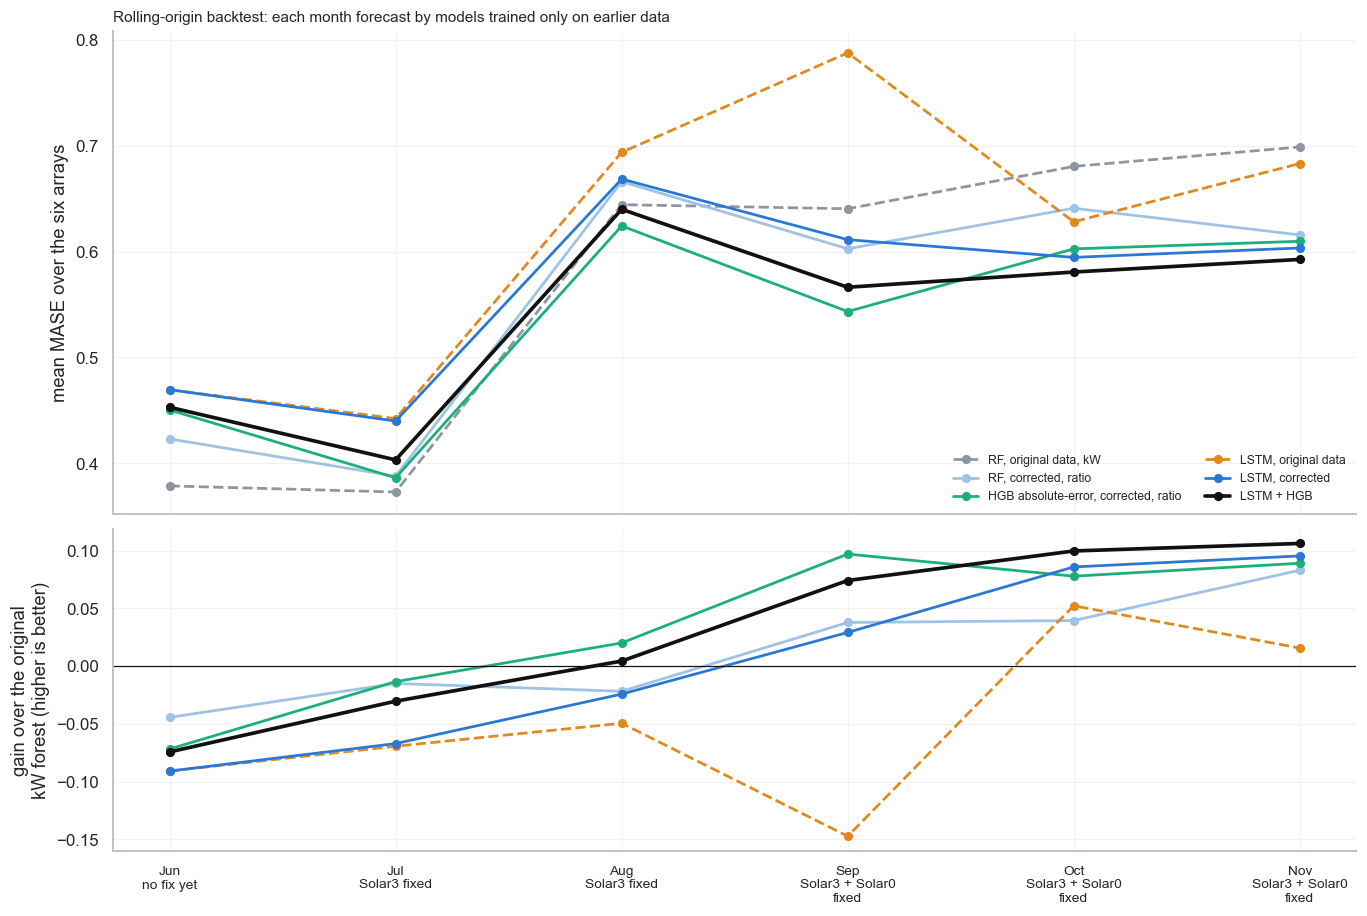

seasonal naive, mean over the six months: 1.0448


In [109]:
# --- 19b. Month by month --------------------------------------------------------------
STYLE = {
    "seasonal naive": ("#bbbbbb", ":"),
    "RF, original data, kW": ("#8c96a3", "--"),
    "RF, corrected, ratio": ("#9ec3e6", "-"),
    "HGB absolute-error, corrected, ratio": ("#1baf7a", "-"),
    "LSTM, original data": ("#e08a1e", "--"),
    "LSTM, corrected": ("#2a78d6", "-"),
    "LSTM + HGB": ("#111111", "-"),
}
months = list(FOLDS)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 8.4), sharex=True,
                             gridspec_kw={"height_ratios": [1.5, 1]})
for m, (c, ls) in STYLE.items():
    if m == "seasonal naive": continue
    a1.plot(months, by_month.loc[m, months], color=c, ls=ls, lw=2.4 if m == "LSTM + HGB" else 1.8,
            marker="o", ms=5, label=m)
a1.set_ylabel("mean MASE over the six arrays")
a1.set_title("Rolling-origin backtest: each month forecast by models trained only on earlier data",
             loc="left")
a1.legend(fontsize=8, ncol=2, loc="lower right"); a1.grid(True, alpha=0.4); a1.set_axisbelow(True)

base = by_month.loc["RF, original data, kW", months]
for m, (c, ls) in STYLE.items():
    if m in ("seasonal naive", "RF, original data, kW"): continue
    a2.plot(months, base - by_month.loc[m, months], color=c, ls=ls,
            lw=2.4 if m == "LSTM + HGB" else 1.8, marker="o", ms=5)
a2.axhline(0, color="#111", lw=0.8)
a2.set_ylabel("gain over the original\nkW forest (higher is better)")
a2.grid(True, alpha=0.4); a2.set_axisbelow(True)
lab = {(): "no fix yet", ("Solar3",): "Solar3 fixed", ("Solar3", "Solar0"): "Solar3 + Solar0\nfixed"}
a2.set_xticks(range(len(months)), [f"{m}\n{lab[FIXED[m]]}" for m in months], fontsize=9)
plt.tight_layout(); plt.show()

print(f"seasonal naive, mean over the six months: {by_month.loc['seasonal naive', 'mean of 6 months']:.4f}")

## 19c. Array by month

The two panels answer different questions. The left one asks where the recommended model
beats the section 11 forest. The right one asks what the LSTM adds when it is averaged in.

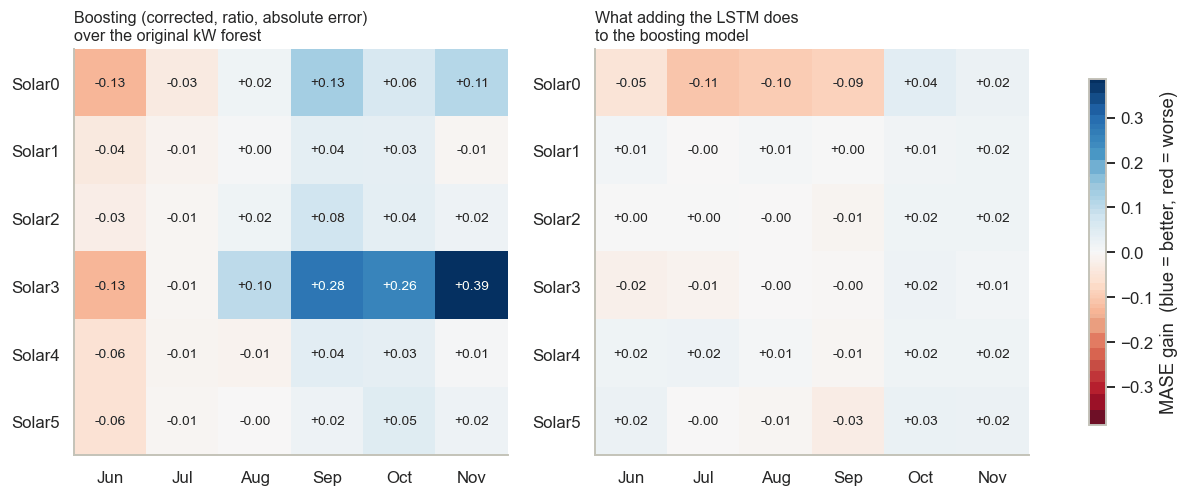

,Jun,Jul,Aug,Sep,Oct,Nov
"Boosting (corrected, ratio, absolute error) over the original kW forest",,,,,,
Solar0,-0.129,-0.034,0.015,0.132,0.061,0.111
Solar1,-0.037,-0.013,0.003,0.037,0.033,-0.007
Solar2,-0.025,-0.009,0.016,0.076,0.037,0.019
Solar3,-0.127,-0.007,0.100,0.279,0.256,0.385
Solar4,-0.056,-0.011,-0.013,0.040,0.033,0.006
Solar5,-0.057,-0.007,-0.001,0.019,0.047,0.020


,Jun,Jul,Aug,Sep,Oct,Nov
What adding the LSTM does to the boosting model,,,,,,
Solar0,-0.048,-0.106,-0.097,-0.088,0.039,0.022
Solar1,0.011,-0.000,0.008,0.001,0.014,0.016
Solar2,0.003,0.001,-0.002,-0.010,0.018,0.016
Solar3,-0.018,-0.015,-0.000,-0.004,0.019,0.011
Solar4,0.015,0.019,0.006,-0.009,0.016,0.016
Solar5,0.023,-0.001,-0.008,-0.029,0.025,0.023


In [110]:
# --- 19c. Where the gains come from: array by month -------------------------------
def gain_of(better, over):
    return (bt.xs(over, level=1)[SOLAR] - bt.xs(better, level=1)[SOLAR]).loc[months].T


PAIRS = [("HGB absolute-error, corrected, ratio", "RF, original data, kW",
          "Boosting (corrected, ratio, absolute error)\nover the original kW forest"),
         ("LSTM + HGB", "HGB absolute-error, corrected, ratio",
          "What adding the LSTM does\nto the boosting model")]
gains = {t: gain_of(b, o) for b, o, t in PAIRS}
lim = max(np.abs(g.to_numpy()).max() for g in gains.values())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (title, g) in zip(axes, gains.items()):
    im = ax.imshow(g.to_numpy(), cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto")
    for (i, j), v in np.ndenumerate(g.to_numpy()):
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 * lim else "#222")
    ax.set_xticks(range(len(months)), months); ax.set_yticks(range(len(SOLAR)), SOLAR)
    ax.set_title(title, loc="left", fontsize=10.5)
fig.colorbar(im, ax=axes, shrink=0.85, label="MASE gain  (blue = better, red = worse)")
plt.show()
for title, g in gains.items():
    display(g.round(3).rename_axis(title.replace("\n", " ")))

### Reading 19

**The best model depends on the season, and November alone could not show that.**

| | Jun | Jul | Aug | Sep | Oct | Nov | 6-month mean |
|---|---|---|---|---|---|---|---|
| peak sun elevation | 30° | 34° | 43° | 54° | 65° | 73° | |
| best model that month | RF kW | RF kW | HGB | HGB | LSTM + HGB | LSTM + HGB | **HGB 0.536** |

- **Winter (June and July) belongs to the plain kW forest** (0.379, 0.373). Boosting is worse
  than it on all six arrays in both months, and so is the blend on every array except July's
  Solar4. The ratio target divides by
  a clear-sky reference that has no air-mass term, which overstates irradiance when the sun
  is low (section 10c). A winter month is almost all low sun, so this is the likely cause.
  It is not yet tested; section 17's Haurwitz check was only run on October and November.
- **Spring (September to November) belongs to the corrected models.** Boosting beats the kW
  forest by 0.097, 0.078 and 0.089. Solar3 gains the most (0.26–0.39). That figure combines the
  correction with the ratio target and the absolute-error loss. The Solar0 correction first
  becomes available in September. That month is also the largest
  gain for the corrected LSTM over the original one (0.611 vs 0.788).
- **August is the month nothing can fix.** Solar0's step happens on 2 August, *inside* the
  test month. No model has seen the new regime, so every one under-forecasts it.

**Section 18's winner does not hold up.** LSTM + boosting was best in October and November,
but over six months boosting on its own is marginally better (0.5361 vs 0.5393). That
difference is too small to separate them. What does separate them is *where* the LSTM goes
wrong: from June to September it drags Solar0 down by 0.05–0.11. In those months Solar0 had
only 5–18 weeks of history, and the LSTM copes with a short history worse than the trees do.

**Recommended model: absolute-error boosting on the corrected ratio target (section 18b).** *Superseded: see Reading 25.*

- It has the best six-month mean.
- It is in the top three every month: first in August and September, second in July, third
  in June, October and November.
- It is simpler than the blend, and it needs no neural network.

The original kW forest remains the better choice for mid-winter. A seasonal switch between
the two, chosen by sun elevation or by month, is the obvious next step. It would have to be
tested on a fresh year to be believed, because these six months are what suggested it.

**For scale:** the 28-day seasonal naive averages 1.045 over the six months. Every model here
beats it in every month. The margin is widest in the spring months and narrowest in July,
where the naive itself scores 0.49.

---

# 20. Four changes to the LSTM, tested on the backtest

Section 14 tried four architectural changes on November alone and could not tell any of them
from seed noise. Its conclusion was that the fix is *more evaluation months*, not more
architecture. Section 19's backtest provides six, so this section tests four changes to the
corrected LSTM on it. Each is motivated by something this notebook has measured:

| Change | Motivation |
|---|---|
| **5 seeds instead of 3** | Section 14's seed spread swamped every effect it tested. |
| **No array-identity flags** | In 19c, adding the LSTM made Solar0 worse by 0.05–0.11 from June to September, while Solar0 had only 5–18 weeks of history. With the six `is_Solar*` flags, the network learns a separate Solar0 adjustment from very few rows. Without them it has to learn one pattern shared by all arrays, and the ratio target already removes array size. Reading 13 noted this was never tested. |
| **Centred window**, 18 h back and 6 h ahead | Section 14's best rung (L2, +0.0175 on November), which could not be separated from noise. The weather for the whole month is treated as known here, as it is for every model, so looking ahead is legitimate. Unlike L2, the 13a training schedule is kept, so that only the window changes. |
| **Haurwitz clear-sky reference** in the ratio target | Reading 19 suggested that the ratio models lose in June and July because the linear reference overstates low-sun irradiance. Section 17 only tested Haurwitz on the forest, and only on October and November. |

Everything else matches the baseline, which is the corrected LSTM from 18a and 19: the same
architecture, schedule, data corrections and months. The baseline networks are the cached ones
from sections 17–19, and every new network is cached too.

**The rule is stricter than section 18's:** a change is kept only if it improves the six-month
mean *and* beats the baseline in at least four of the six months.

## 20a. The results

In [111]:
# --- 20a. Four LSTM changes, each tested on the six-month backtest ------------------
NO_ID = [i for i, c in enumerate(STATIC_FEATURES) if not c.startswith("is_")]
ALL = list(range(len(STATIC_FEATURES)))
centred = window_builder(18, 6)                   # section 14's L2 window
seq_c, stat_c, ok_c = centred(td)
assert ok_c.all() and len(seq_c) == len(td)


def ref_linear(frame, caps):
    return reference_with(frame, caps)


def ref_haurwitz(frame, caps):
    return frame["array"].map(caps).to_numpy() * haurwitz(frame) / HW_MAX


def ratio_inputs_ref(until, arrays, ref_fn):
    """ratio_inputs (18a) with a chosen clear-sky reference."""
    fx, _ = corrected(train_day[train_day.index < until], until, arrays)
    caps = cap_of(fx)
    y = td["production_kw"].to_numpy().copy()
    keep = np.asarray(td.index < until)
    for s in arrays:
        t0 = pd.Timestamp(REGIMES[s]["before_end"], tz=LOCAL_TZ)
        t1 = pd.Timestamp(REGIMES[s]["after_start"], tz=LOCAL_TZ)
        a = (td["array"] == s).to_numpy()
        keep &= ~(a & (td.index > t0) & (td.index < t1))
        y = np.where(a & (td.index <= t0), y * step_for(s, until), y)
    ref = ref_fn(td, caps)
    r = np.clip(y / np.maximum(ref, 1e-6), 0, 1.5).astype("float32")
    mask = (ref / td["array"].map(caps).to_numpy() > 0.05) & keep
    return r, mask, caps


def make_lstm_v(seed, steps, n_static):
    """make_lstm (13a) with the input shapes left free."""
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(steps, len(SEQ_FEATURES)))
    t_in = keras.Input(shape=(n_static,))
    z = layers.Concatenate()([layers.LSTM(48)(s_in), layers.Dense(32, activation="relu")(t_in)])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


def train_on(seq, stat, y, mask, tag, seeds=(0, 1, 2)):
    """train_seeds (13a) on explicit inputs - same split, schedule and callbacks."""
    s_, t_, y_ = seq[mask], stat[mask], y[mask].astype("float32")
    cut = int(len(y_) * 0.9)

    def _fit():
        nets, hists = [], []
        for s in seeds:
            m = make_lstm_v(s, s_.shape[1], t_.shape[1])
            h = m.fit([s_[:cut], t_[:cut]], y_[:cut], validation_data=([s_[cut:], t_[cut:]], y_[cut:]),
                      epochs=150, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
            nets.append(m); hists.append(h.history)
        return nets, hists
    return cached_nets(f"seeds_{tag}", _fit)[0]


def predict_with(nets, builder, cols, ref_fn, caps):
    def fn(frame):
        seq, static, ok = builder(frame)
        raw = np.mean([np.asarray(m([seq, static[:, cols]], training=False)).ravel() for m in nets], axis=0)
        out = np.zeros(len(frame)); out[ok] = raw
        return out * ref_fn(frame, caps)
    return fn


def base_tag(mon, arrays):
    """Where 17d, 18a and 19 cached the corrected LSTM for each month."""
    if mon == "Nov": return "LSTM-ratio-corrected"
    if not arrays: return f"LSTM-ratio-original-pre{mon}"
    return f"LSTM-ratio-corrected-pre{mon}"


VARIANTS = {            # name: (sequence input, static columns, clear-sky reference, builder)
    "no identity flags": (seq_tr, NO_ID, ref_linear, build_inputs),
    "centred window": (seq_c, ALL, ref_linear, centred),
    "Haurwitz reference": (seq_tr, ALL, ref_haurwitz, build_inputs),
}


def _variant_runs():
    out = {}
    for mon, win in FOLDS.items():
        arrays = FIXED[mon]
        print(f"--- {mon} 2020", flush=True)
        r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
        base = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, arrays))
        extra = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, arrays) + "-s34", seeds=(3, 4))
        runs = {"baseline (18a/19)": (base, build_inputs, ALL, ref_linear, caps),
                "5 seeds": (base + extra, build_inputs, ALL, ref_linear, caps)}
        for name, (sq, cols, ref_fn, bld) in VARIANTS.items():
            rr, mm, cc = (r, mask, caps) if ref_fn is ref_linear else ratio_inputs_ref(win[0], arrays, ref_fn)
            tag = f"v20-{name.split()[0]}-{mon}-{'-'.join(arrays) or 'none'}"
            runs[name] = (train_on(sq, stat_tr[:, cols], rr, mm, tag), bld, cols, ref_fn, cc)
        for name, (nets, bld, cols, ref_fn, cc) in runs.items():
            out[(mon, name)] = {
                "ensemble": score_frame(predict_with(nets, bld, cols, ref_fn, cc), win),
                "seeds": [score_frame(predict_with([m], bld, cols, ref_fn, cc), win).mean() for m in nets]}
    return out


L20 = cached("lstm_variants_20", _variant_runs)
NAMES = ["baseline (18a/19)", "5 seeds"] + list(VARIANTS)
months = list(FOLDS)
ens20 = pd.DataFrame({k: v["ensemble"] for k, v in L20.items()}).T
ens20["mean"] = ens20[SOLAR].mean(axis=1)
tab20 = ens20["mean"].unstack(0).loc[NAMES, months]
tab20["6-month mean"] = tab20[months].mean(axis=1)
tab20["months beating baseline"] = [int((tab20.loc[v, months] < tab20.loc[NAMES[0], months]).sum())
                                    for v in NAMES]
display(tab20.round(4))
seed_sd = pd.DataFrame({m: {n: np.std(L20[(m, n)]["seeds"]) for n in NAMES} for m in months})
display(seed_sd.round(4).rename_axis("seed sd, one month's ensemble members"))

  [cache] loaded lstm_variants_20


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating baseline
baseline (18a/19),0.4696,0.4400,0.6686,0.6113,0.5946,0.6034,0.5646,0
5 seeds,0.4739,0.4470,0.6592,0.6233,0.5965,0.5898,0.5649,2
no identity flags,0.4490,0.4216,0.6949,0.6963,0.6410,0.6249,0.5879,2
centred window,0.6260,0.4716,0.6596,0.5569,0.6026,0.5960,0.5854,3
Haurwitz reference,0.4691,0.4204,0.6617,0.6641,0.6092,0.5911,0.5693,4


,Jun,Jul,Aug,Sep,Oct,Nov
"seed sd, one month's ensemble members",,,,,,
baseline (18a/19),0.0343,0.0188,0.0332,0.0299,0.0037,0.0212
5 seeds,0.0279,0.0202,0.0284,0.0283,0.0125,0.0214
no identity flags,0.0155,0.0052,0.0015,0.0297,0.0185,0.0134
centred window,0.0233,0.0197,0.0298,0.0209,0.0074,0.0108
Haurwitz reference,0.0247,0.0116,0.0114,0.0250,0.0083,0.0237


## 20b. Month by month, and array by array

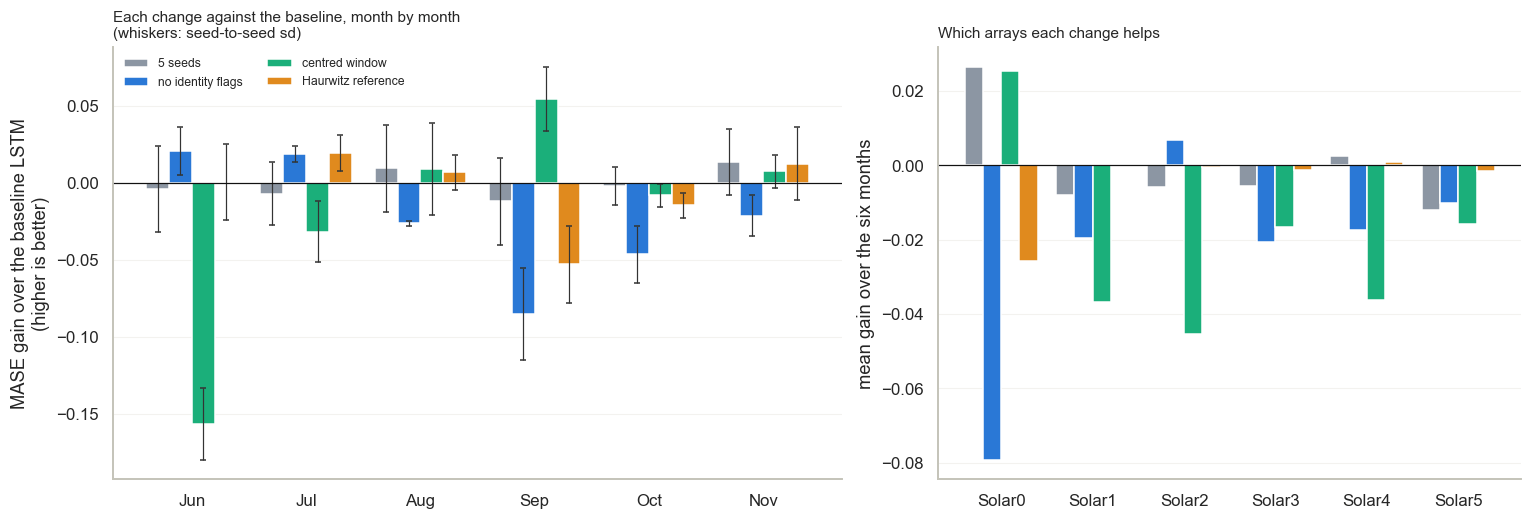

,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
mean gain over six months,,,,,,
5 seeds,0.0265,-0.0079,-0.0058,-0.0056,0.0026,-0.0120
no identity flags,-0.0792,-0.0195,0.0068,-0.0207,-0.0174,-0.0101
centred window,0.0254,-0.0367,-0.0453,-0.0167,-0.0362,-0.0158
Haurwitz reference,-0.0256,-0.0000,-0.0006,-0.0012,0.0008,-0.0015


In [112]:
# --- 20b. Month by month, and array by array ------------------------------------
COL20 = {"5 seeds": "#8c96a3", "no identity flags": "#2a78d6",
         "centred window": "#1baf7a", "Haurwitz reference": "#e08a1e"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
x = np.arange(len(months)); w = 0.2
for k, n in enumerate(COL20):
    g = tab20.loc[NAMES[0], months] - tab20.loc[n, months]
    sd = [np.std(L20[(m, n)]["seeds"]) for m in months]
    a1.bar(x + (k - 1.5) * w, g, w, color=COL20[n], label=n)
    a1.errorbar(x + (k - 1.5) * w, g, yerr=sd, fmt="none", ecolor="#333", lw=0.8, capsize=2)
a1.axhline(0, color="#111", lw=0.8)
a1.set_xticks(x, months); a1.set_ylabel("MASE gain over the baseline LSTM\n(higher is better)")
a1.set_title("Each change against the baseline, month by month\n(whiskers: seed-to-seed sd)",
             loc="left")
a1.legend(fontsize=8, ncol=2); a1.grid(True, axis="y", alpha=0.4); a1.set_axisbelow(True)

per_array = {n: (ens20.xs(NAMES[0], level=1)[SOLAR] - ens20.xs(n, level=1)[SOLAR]).mean()
             for n in COL20}
xa = np.arange(len(SOLAR))
for k, n in enumerate(COL20):
    a2.bar(xa + (k - 1.5) * w, per_array[n], w, color=COL20[n])
a2.axhline(0, color="#111", lw=0.8)
a2.set_xticks(xa, SOLAR); a2.set_ylabel("mean gain over the six months")
a2.set_title("Which arrays each change helps", loc="left")
a2.grid(True, axis="y", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()
display(pd.DataFrame(per_array).T.round(4).rename_axis("mean gain over six months"))

### Reading 20

**None of the four changes passes, so the LSTM stays as it is.**

| Change | 6-month mean | Months beating the baseline | Verdict |
|---|---|---|---|
| baseline (18a/19) | 0.5646 | — | kept |
| 5 seeds | 0.5649 | 2 | no effect |
| Haurwitz reference | 0.5693 | 4 | fails on the mean |
| centred window | 0.5854 | 3 | fails |
| no identity flags | 0.5879 | 2 | fails |

**More seeds changes nothing** (0.5649 vs 0.5646). Seed noise is large for a *single*
network: the baseline's seeds differ by up to 0.08 within a month. But averaging three
seeds already cancels most of it, and two more add little. Seed noise matters when single
networks are compared, which is how section 14 read its rungs. It matters much less for the
ensemble the notebook actually uses.

**Dropping the identity flags confirms the diagnosis, then goes wrong.** In June and July,
when Solar0 had 5–9 weeks of history, it does exactly what was predicted. Solar0 improves by
0.07 and 0.09, and both months are the best LSTM scores in the section (0.449, 0.422). From
August onward it is far worse on Solar0 (+0.16, +0.34, +0.13, +0.02). From September it is
also slightly worse on most of the other arrays. Once Solar0's history includes its August change, the network evidently
needs the flags to treat Solar0 differently. Exactly why is not established here. A version
that dropped the flags only while an array's history was short would be tuned on these same
six months, so it is not adopted either.

**The Haurwitz reference wins four months but loses the mean.** It helps in July (0.420 vs
0.440), August and November, and ties in June. But it costs 0.053 in September and 0.015 in
October. It also leaves June where it was, so it **does not close the winter gap** to the
original kW forest (0.379 in June, 0.373 in July). That weakens Reading 19's suggested cause:
for the LSTM, at least, the low-sun reference is not what loses the winter months.

**The centred window is erratic.** It is the best model of the section in September (0.557,
mostly Solar0), and the worst in June (0.626). The June loss appears on every array (+0.10 to
+0.22) and in all three seeds (0.651, 0.595, 0.616 against 0.523, 0.471, 0.439), so it is not
one unlucky seed. Its cause is not identified. Section 14's November gain for this window does
not generalise.

**What this adds to the report.** Across sections 14 and 20, seven distinct changes to the
LSTM's architecture, inputs, target and seed count have been tested (the centred window in
both sections), and none has reliably helped.
Every large gain in this notebook came from **fixing the data** (section 17) and **matching the
loss to the metric** (section 18b), not from changing the network. The recommendation from
section 19 stands: absolute-error boosting on the corrected ratio target.

---

# 21. Ensembles, tested on the backtest

Section 18 averaged a few models, but it could only judge them on October and November. The
backtest now makes two things possible: testing ensembles over six months, and weighting
models by how well they did in **earlier** months only, which never looks at the test month.

**The plan was fixed, and then reviewed, before anything ran.** The reviewer was a second AI
session (Claude), instructed to act as a sceptical methodological reviewer. It read the code
and logs but ran no experiments. It found no leakage, but it changed the design:

- **Equal-weight blends win some months automatically.** In every array-month, a blend's
  absolute error is at most the average of its members' errors (triangle inequality). Blending
  the original kW forest with boosting was therefore *guaranteed* to beat boosting in June and
  July (bounds 0.4146 < 0.4505 and 0.3796 < 0.3863). A "wins in four of six months" rule is
  partly passed before anything is run.
- **"Follow the leader" was dropped by arithmetic.** That candidate uses whichever model has
  the best record in earlier months. From section 19's table it would pick the kW forest for
  July to September and boosting for October and November. That totals 2.8702 over July to
  November, against boosting's 2.7664. To beat boosting overall, June would need a score below
  0.3467, lower than any model achieved in June (best 0.3787).
- **A plain equal-weight average of four models was added as a control.** The past-only
  weighting has to beat it before anyone can say "weighting helps".
- **Bagging boosting is compared with the average single seed**, not only with the seed-0
  model reported in section 19.
- **A paired test was added.** Each candidate is compared with boosting on each of the 36
  array-months, using a one-sided sign test. Ties count as losses, and the p-value is corrected
  for testing six candidates at once (Bonferroni, p < 0.0083).

| Candidate | What it is |
|---|---|
| E0 | equal-weight mean of four: RF kW, RF corrected ratio, HGB, LSTM corrected (the control) |
| E1 | RF kW + HGB, equal weights. RF kW wins the winter months and HGB wins August–September |
| E2 | RF kW + HGB + LSTM corrected, equal weights |
| E3a | the four models of E0, weighted by 1 / (mean MASE in earlier backtest months); equal weights in June |
| E4 | HGB bagged: the average of five random seeds |
| E5 | the hour-by-hour median of E0's four models |

**Verdicts.** A candidate is **adopted** only if it passes both tests. The first is
section 20's rule: a lower six-month mean than boosting, *and* better in at least four of the
six months. The second is the corrected sign test. A candidate that passes only the first gets
**"exploratory pass"**, and at most one candidate is adopted.

The forecasts come from the models section 19 fitted for each month, plus four extra boosting
seeds for E4. The check below confirms they reproduce section 19's scores. A blend averages
hourly kW forecasts that have already been clipped at zero.

## 21a. The forecasts

In [113]:
# --- 21a. Every base model's forecasts for every backtest month, stored once ------
from scipy.stats import binomtest


def clean_pred(frame, preds):
    """score_frame's own clamping (cell 117): zero below DAYLIGHT, clip at 0."""
    p = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, np.asarray(preds, dtype=float))
    return np.clip(p, 0.0, None)


def score_vec(frame, preds, win, arrays=SOLAR):
    """score_frame's scoring, applied to an already-computed hourly forecast."""
    f = frame.assign(pred=clean_pred(frame, preds)); rows = {}
    for name in arrays:
        fc = expand_to_15min(f.loc[f["array"] == name, "pred"], win)
        actual = df[name].reindex(fc.index); ok = actual.notna() & fc.notna()
        rows[name] = np.mean(np.abs(actual[ok] - fc[ok])) / mase_scale(name, win[0])
    return pd.Series(rows)


def month_frame(win):
    w = solar_data.loc[(solar_data.index >= win[0]) & (solar_data.index < win[1])]
    return w[w[FEATURES].notna().all(axis=1)]


def _base_forecasts():
    out = {}
    for mon, win in FOLDS.items():
        arrays, frame = FIXED[mon], month_frame(win)
        tr = train_day[train_day.index < win[0]]
        fx, _ = corrected(tr, win[0], arrays); caps = cap_of(fx)
        P = {"RF kW": fit_pooled(tr, "kW")(frame), "RF ratio": fit_pooled(fx, "ratio", caps)(frame)}
        for s in range(5):
            P[f"HGB s{s}"] = fit_hgb(fx, caps, seed=s)(frame)
        P["LSTM"] = fold_lstm(mon, win, arrays)(frame)
        _, _, ok = build_inputs(frame)
        assert ok.all(), f"{mon}: LSTM rows without a full window would halve a blend"
        out[mon] = pd.DataFrame({k: clean_pred(frame, v) for k, v in P.items()}, index=frame.index)
    return out


PRED21 = cached("base_forecasts_21", _base_forecasts)
FRAME21 = {mon: month_frame(win) for mon, win in FOLDS.items()}
chk = pd.DataFrame({mon: {n: score_vec(FRAME21[mon], PRED21[mon][c], win).mean() for n, c in
                          [("RF, original data, kW", "RF kW"), ("RF, corrected, ratio", "RF ratio"),
                           ("HGB absolute-error, corrected, ratio", "HGB s0"), ("LSTM, corrected", "LSTM")]}
                    for mon, win in FOLDS.items()})
print("max difference from section 19's scores:",
      float((chk - by_month.loc[chk.index, list(FOLDS)]).abs().max().max()))

  [cache] loaded base_forecasts_21


max difference from section 19's scores: 5.551115123125783e-17


## 21b. The candidates

In [114]:
# --- 21b. The pre-registered candidates --------------------------------------------
M = list(FOLDS)
BASE4 = ["RF kW", "RF ratio", "HGB s0", "LSTM"]
NAME = {"RF kW": "RF, original data, kW", "RF ratio": "RF, corrected, ratio",
        "HGB s0": "HGB absolute-error, corrected, ratio", "LSTM": "LSTM, corrected"}


def e3_weights(mon):
    """Inverse mean MASE over backtest months strictly before `mon`; equal in June."""
    prev = M[:M.index(mon)]
    if not prev:
        return {m: 1 / len(BASE4) for m in BASE4}
    inv = {m: 1 / np.mean([by_month.loc[NAME[m], p] for p in prev]) for m in BASE4}
    tot = sum(inv.values())
    return {m: v / tot for m, v in inv.items()}


REF = "HGB (section 19)"
CANDS = {
    REF: lambda mon, P: P["HGB s0"],
    "E0 equal mean of four": lambda mon, P: P[BASE4].mean(axis=1),
    "E1 RF kW + HGB": lambda mon, P: P[["RF kW", "HGB s0"]].mean(axis=1),
    "E2 RF kW + HGB + LSTM": lambda mon, P: P[["RF kW", "HGB s0", "LSTM"]].mean(axis=1),
    "E3a past-only inverse-MASE weights": lambda mon, P: sum(w * P[m] for m, w in e3_weights(mon).items()),
    "E4 HGB, 5-seed bag": lambda mon, P: P[[f"HGB s{s}" for s in range(5)]].mean(axis=1),
    "E5 median of four": lambda mon, P: P[BASE4].median(axis=1),
}
e21 = pd.DataFrame({(mon, c): score_vec(FRAME21[mon], fn(mon, PRED21[mon]), FOLDS[mon])
                    for mon in M for c, fn in CANDS.items()}).T
single21 = pd.DataFrame({(mon, m): score_vec(FRAME21[mon], PRED21[mon][m], FOLDS[mon])
                         for mon in M for m in PRED21[M[0]].columns}).T


def summarise(e, drop=None):
    """Monthly means, the pre-registered rule, and a one-sided sign test over array-months.
    `drop=(array, month)` removes one array-month (sensitivity check)."""
    am = e[SOLAR].copy()
    if drop is not None:
        am.loc[[(drop[1], c) for c in CANDS], drop[0]] = np.nan
    tab = am.mean(axis=1).unstack(0)[M]
    out = tab.copy()
    out["6-month mean"] = tab.mean(axis=1)
    out["months beating HGB"] = [int((tab.loc[c] < tab.loc[REF]).sum()) for c in tab.index]
    base = am.xs(REF, level=1)
    k_n = []
    for c in tab.index:
        d = (base - am.xs(c, level=1)).to_numpy().ravel(); d = d[~np.isnan(d)]
        k_n.append(((d > 0).sum(), len(d)))                        # ties count as losses
    out["array-months beating HGB"] = [f"{k}/{n}" for k, n in k_n]
    out["one-sided sign p"] = [binomtest(int(k), n, 0.5, alternative="greater").pvalue for k, n in k_n]
    return out


tab21 = summarise(e21)
BONF = 0.05 / (len(CANDS) - 1)
ref_mean = tab21.loc[REF, "6-month mean"]


def verdict(name, r):
    if name == REF:
        return "reference"
    if not (r["6-month mean"] < ref_mean and r["months beating HGB"] >= 4):
        return "fail"
    return "adopt" if r["one-sided sign p"] < BONF else "exploratory pass"


tab21["verdict"] = [verdict(c, r) for c, r in tab21.iterrows()]
display(tab21.sort_values("6-month mean").round(4))
print(f"Bonferroni threshold over {len(CANDS) - 1} candidates: p < {BONF:.4f}")

sens = summarise(e21, drop=("Solar0", "Jun"))
display(sens[["6-month mean", "months beating HGB", "array-months beating HGB", "one-sided sign p"]]
        .round(4).rename_axis("without Solar0-June (its MASE scale rests on ~8 days)"))
display(pd.DataFrame({mon: e3_weights(mon) for mon in M}).round(3).rename_axis("E3a weights by month"))

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating HGB,array-months beating HGB,one-sided sign p,verdict
"E4 HGB, 5-seed bag",0.4480,0.3828,0.6190,0.5400,0.6010,0.6053,0.5327,6,30/36,0.0000,adopt
HGB (section 19),0.4505,0.3863,0.6243,0.5434,0.6026,0.6098,0.5361,0,0/36,1.0000,reference
E2 RF kW + HGB + LSTM,0.4236,0.3873,0.6367,0.5797,0.6002,0.6057,0.5389,3,22/36,0.1215,fail
E5 median of four,0.4263,0.3824,0.6424,0.5784,0.6086,0.5957,0.5390,3,19/36,0.4340,fail
E3a past-only inverse-MASE weights,0.4224,0.3850,0.6420,0.5833,0.6051,0.6042,0.5403,3,19/36,0.4340,fail
E0 equal mean of four,0.4224,0.3864,0.6424,0.5830,0.6043,0.6040,0.5404,2,20/36,0.3089,fail
E1 RF kW + HGB,0.4090,0.3750,0.6276,0.5775,0.6284,0.6353,0.5421,2,18/36,0.5660,fail


Bonferroni threshold over 6 candidates: p < 0.0083


,6-month mean,months beating HGB,array-months beating HGB,one-sided sign p
without Solar0-June (its MASE scale rests on ~8 days),,,,
E0 equal mean of four,0.5388,2,19/35,0.3679
E1 RF kW + HGB,0.5418,2,17/35,0.6321
E2 RF kW + HGB + LSTM,0.5373,3,21/35,0.1553
E3a past-only inverse-MASE weights,0.5387,3,18/35,0.5000
"E4 HGB, 5-seed bag",0.5311,6,30/35,0.0000
E5 median of four,0.5372,3,18/35,0.5000
HGB (section 19),0.5348,0,0/35,1.0000


,Jun,Jul,Aug,Sep,Oct,Nov
E3a weights by month,,,,,,
RF kW,0.25,0.282,0.274,0.264,0.255,0.249
RF ratio,0.25,0.253,0.254,0.250,0.249,0.249
HGB s0,0.25,0.237,0.246,0.252,0.259,0.259
LSTM,0.25,0.228,0.226,0.234,0.237,0.243


## 21c. What averaging buys

The **averaging bound** is the mean of a blend's members' own scores; a blend is guaranteed to
do at least that well. The gap between the bound and the blend is what genuinely comes from
the members making *different* errors. The tables also show the best member in each month.
That is chosen with hindsight, a different model each month, so no real forecaster could
achieve it. The fair comparison over six months is with HGB alone (the dashed line).

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
E0 equal mean of four,,,,,,,
blend,0.4224,0.3864,0.6424,0.5830,0.6043,0.6040,0.5404
averaging bound,0.4305,0.3968,0.6509,0.5995,0.6297,0.6320,0.5565
best member,0.3787,0.3729,0.6243,0.5434,0.5946,0.6034,0.5196


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
E1 RF kW + HGB,,,,,,,
blend,0.4090,0.3750,0.6276,0.5775,0.6284,0.6353,0.5421
averaging bound,0.4146,0.3796,0.6343,0.5920,0.6415,0.6543,0.5527
best member,0.3787,0.3729,0.6243,0.5434,0.6026,0.6098,0.5220


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
E2 RF kW + HGB + LSTM,,,,,,,
blend,0.4236,0.3873,0.6367,0.5797,0.6002,0.6057,0.5389
averaging bound,0.4329,0.3998,0.6457,0.5984,0.6259,0.6374,0.5567
best member,0.3787,0.3729,0.6243,0.5434,0.5946,0.6034,0.5196


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
E4 against the five single seeds,,,,,,,
single-seed mean,0.4494,0.3845,0.6212,0.5435,0.6051,0.6087,0.5354
single-seed sd,0.0046,0.0031,0.0092,0.0044,0.0024,0.0015,NaN
5-seed bag,0.4480,0.3828,0.6190,0.5400,0.6010,0.6053,0.5327


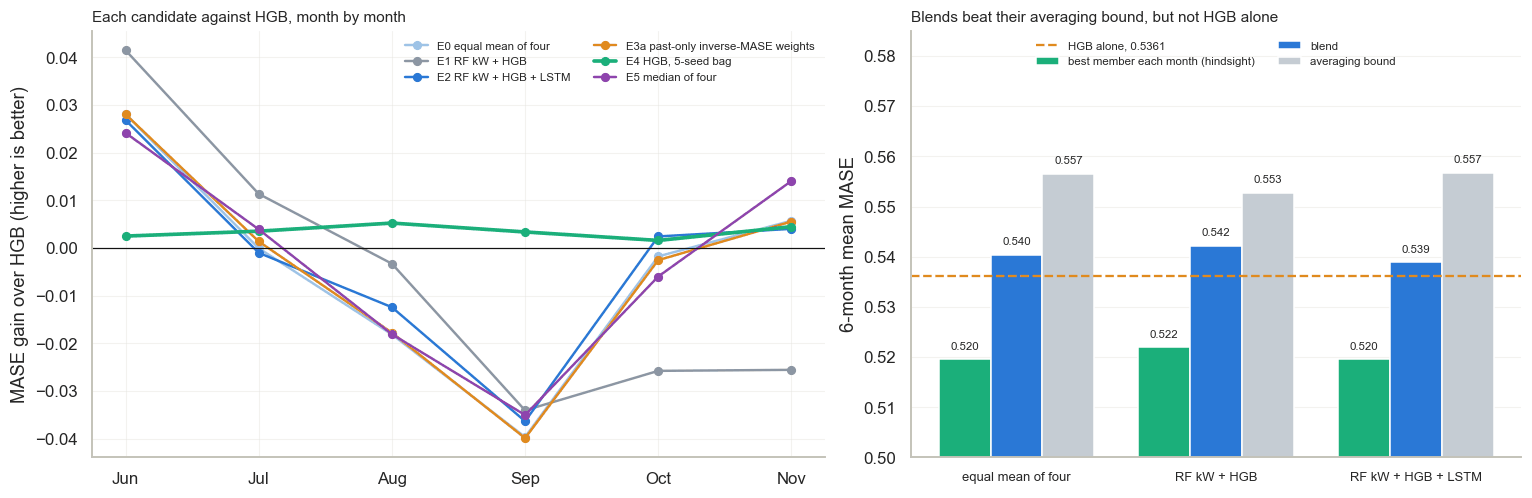

In [115]:
# --- 21c. What the blends gain, and what bagging gains -------------------------------
MEMBERS = {"E0 equal mean of four": BASE4, "E1 RF kW + HGB": ["RF kW", "HGB s0"],
           "E2 RF kW + HGB + LSTM": ["RF kW", "HGB s0", "LSTM"]}
bounds = {}
for b, mem in MEMBERS.items():
    bounds[b] = pd.DataFrame({
        "blend": tab21.loc[b, M],
        "averaging bound": [np.mean([single21.loc[(mon, m), SOLAR].mean() for m in mem]) for mon in M],
        "best member": [min(single21.loc[(mon, m), SOLAR].mean() for m in mem) for mon in M]}).T
    display(bounds[b].assign(**{"6-month mean": bounds[b].mean(axis=1)}).round(4).rename_axis(b))

seeds = pd.DataFrame({mon: [single21.loc[(mon, f"HGB s{s}"), SOLAR].mean() for s in range(5)] for mon in M})
bag = pd.DataFrame({"single-seed mean": seeds.mean(), "single-seed sd": seeds.std(),
                    "5-seed bag": tab21.loc["E4 HGB, 5-seed bag", M]}).T
bag["6-month mean"] = bag.mean(axis=1)
bag.loc["single-seed sd", "6-month mean"] = np.nan          # an average of monthly sds means nothing
display(bag.round(4).rename_axis("E4 against the five single seeds"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.2, 1]})
COL21 = {"E0 equal mean of four": "#9ec3e6", "E1 RF kW + HGB": "#8c96a3", "E2 RF kW + HGB + LSTM": "#2a78d6",
         "E3a past-only inverse-MASE weights": "#e08a1e", "E4 HGB, 5-seed bag": "#1baf7a",
         "E5 median of four": "#8e44ad"}
for c, col in COL21.items():
    a1.plot(M, tab21.loc[REF, M] - tab21.loc[c, M], color=col, marker="o", ms=5,
            lw=2.4 if c.startswith("E4") else 1.6, label=c)
a1.axhline(0, color="#111", lw=0.8)
a1.set_ylabel("MASE gain over HGB (higher is better)")
a1.set_title("Each candidate against HGB, month by month", loc="left")
a1.legend(fontsize=7.5, ncol=2, loc="upper right"); a1.grid(True, alpha=0.4); a1.set_axisbelow(True)

x = np.arange(len(MEMBERS)); w = 0.26
for k, (row, col, lab) in enumerate([("best member", "#1baf7a", "best member each month (hindsight)"),
                                     ("blend", "#2a78d6", "blend"),
                                     ("averaging bound", "#c5ccd3", "averaging bound")]):
    v = [bounds[b].loc[row].mean() for b in MEMBERS]
    a2.bar(x + (k - 1) * w, v, w, color=col, label=lab)
    for xi, vi in zip(x, v):
        a2.text(xi + (k - 1) * w, vi + 0.002, f"{vi:.3f}", ha="center", fontsize=7.5)
a2.axhline(ref_mean, color="#e08a1e", ls="--", lw=1.5, label=f"HGB alone, {ref_mean:.4f}")
a2.set_xticks(x, [b.split(" ", 1)[1] for b in MEMBERS], fontsize=8.5)
a2.set_ylim(0.50, 0.585); a2.set_ylabel("6-month mean MASE")
a2.set_title("Blends beat their averaging bound, but not HGB alone", loc="left")
a2.legend(fontsize=7.5, ncol=2, loc="upper center"); a2.grid(True, axis="y", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 21d. A check on months the backtest never scored: January to March 2020

January to May 2020 were never test months, which makes them a check on months nothing was
chosen on. Only the tree models are used, because LSTMs were never trained for these months,
and nothing can be corrected yet: Solar3's new regime starts on 31 May. The scoring is limited
to section 16's control arrays, Solar1, Solar2 and Solar4, which was fixed before running.

**Most of these months cannot be scored.** Cell 45 flags days on which an array reports output
at night. The flagged spans are:

- Solar1: 2 March to 20 May 2020
- Solar2, Solar3 and Solar4: 15 April to 19 May 2020
- Solar3: earlier days from September 2019 (62 flagged days in total)
- Solar2: 9–12 October 2019
- Solar0: 24 May to 5 October 2020 (26 days)

For the March–May 2020 spell, the profiles here show a flat overnight level with a weak
daytime bump, and cell 47 finds a stuck or creeping counter (it inspects Solar2 on 1–2 May).
So in that spell the *daytime* values are wrong too. The other spans are night readings that
have not been inspected. For Solar0, removing its flagged days makes boosting's error *larger*
(21e), which suggests its daytime values on those days were fine.

Section 9's cleaning (cell 57) keeps flagged days out of every model's *training* data. It does
not stop them being scored as *test* data. April, May and Solar1's March are therefore dropped,
leaving **8 clean array-months**: January and February for Solar1, Solar2 and Solar4, plus March
for Solar2 and Solar4. The code asserts that none of them contains a flagged day.

**How the choices were made.** The review asked for the seasonal predictions to be written down
*before* this check ran. They were not: every month had already been scored when the review
arrived. April, May and Solar1's March were dropped only after their scores (about 2.07 for
every model) looked wrong. They were dropped by section 9's existing flag, not by a new rule.
E1's intended out-of-sample test was April and May, and no prediction for it was written down
before the data ruled those months out. Everything below is therefore **descriptive**.

Two contrasts matter:

- **RF kW against RF ratio.** It is the same forest with only the target changed.
- **HGB against RF kW.** This is the contrast that separated spring from winter in section 19.

Peak sun elevation is 75° in January and 60° in March, higher than any month from June to
September.

In [116]:
# --- 21d. Summer months never used as test months: January to March 2020 -----------
PRE21 = {m: (pd.Timestamp(f"2020-{k:02d}-01", tz="UTC"), pd.Timestamp(f"2020-{k + 1:02d}-01", tz="UTC"))
         for m, k in [("Jan", 1), ("Feb", 2), ("Mar", 3)]}
# Scored on section 16's control arrays (Solar1, Solar2, Solar4), chosen before running.
# Solar1's March is dropped: it has cell 45's stuck-counter artefact from 2 March.
CLEAN21 = {"Jan": ["Solar1", "Solar2", "Solar4"], "Feb": ["Solar1", "Solar2", "Solar4"],
           "Mar": ["Solar2", "Solar4"]}
for mon, arrs in CLEAN21.items():
    lo, hi = (t.tz_convert(LOCAL_TZ).normalize() for t in PRE21[mon])   # hi: the partial last local day
    flagged = bad_days.loc[(bad_days.index >= lo) & (bad_days.index <= hi), arrs].fillna(False)
    assert not flagged.any().any(), f"{mon}: flagged days in a scored array-month"
    tr = train_day[train_day.index < PRE21[mon][0]]; caps = cap_of(tr)
    n_hgb = int((reference_with(tr, caps) / tr["array"].map(caps).to_numpy() > 0.05).sum())
    print(f"{mon}: {n_hgb:,} boosting training rows -> early stopping {'on' if n_hgb > 10000 else 'off'}")


def _pre_june():
    rows = {}
    for mon, win in PRE21.items():
        assert eligible(win[0]) == ()                      # nothing can be corrected yet
        frame = month_frame(win)
        tr = train_day[train_day.index < win[0]]; caps = cap_of(tr)
        P = {"RF kW": fit_pooled(tr, "kW")(frame), "RF ratio": fit_pooled(tr, "ratio", caps)(frame),
             "RF ratio, Haurwitz": fit_ratio_hw(tr, caps)(frame)}
        for s in range(5):
            P[f"HGB s{s}"] = fit_hgb(tr, caps, seed=s)(frame)
        P = pd.DataFrame({k: clean_pred(frame, v) for k, v in P.items()}, index=frame.index)
        P["E4 HGB, 5-seed bag"] = P[[f"HGB s{s}" for s in range(5)]].mean(axis=1)
        P["E1 RF kW + HGB"] = P[["RF kW", "HGB s0"]].mean(axis=1)
        for c in P.columns:
            s_ = score_vec(frame, P[c], win, CLEAN21[mon])
            for a in CLEAN21[mon]:
                rows[(mon, a, c)] = s_[a]
    return rows


pre = pd.Series(cached("pre_june_21", _pre_june)).unstack(2)
show = ["RF kW", "RF ratio", "RF ratio, Haurwitz", "HGB s0", "E4 HGB, 5-seed bag", "E1 RF kW + HGB"]
se = solar_data.loc[solar_data["array"] == "Solar1", "solar_elevation"]
peak = se.groupby(se.index.tz_convert("UTC").strftime("%b")).max()
display(pre[show].round(4).rename_axis(["month", "array"]))
display(pd.DataFrame({"mean over the 8 clean array-months": pre[show].mean(),
                      "RF kW minus this (positive = better than RF kW)": pre["RF kW"].mean() - pre[show].mean(),
                      "array-months better than RF kW": [int((pre["RF kW"] > pre[c]).sum()) for c in show]})
        .round(4))
display(pd.DataFrame({"RF kW - RF ratio": pre["RF kW"] - pre["RF ratio"],
                      "RF kW - HGB": pre["RF kW"] - pre["HGB s0"],
                      "HGB - E1": pre["HGB s0"] - pre["E1 RF kW + HGB"]})
        .round(4).rename_axis(["month", "array"]).rename(columns=lambda c: c + "  (positive = second better)"))
seeds_pre = pre[[f"HGB s{s}" for s in range(5)]].groupby(level=0).mean().loc[list(PRE21)]
display(seeds_pre.assign(**{"single-seed mean": seeds_pre.mean(axis=1),
                            "5-seed bag": pre["E4 HGB, 5-seed bag"].groupby(level=0).mean()})
        .round(4).rename_axis("HGB by seed, mean over the clean arrays"))
print("peak sun elevation:", {m: round(float(peak[m]), 1) for m in PRE21})

Jan: 7,693 boosting training rows -> early stopping off
Feb: 9,763 boosting training rows -> early stopping off
Mar: 11,648 boosting training rows -> early stopping on
  [cache] loaded pre_june_21


RF kW  RF ratio  RF ratio, Haurwitz  HGB s0  E4 HGB, 5-seed bag  E1 RF kW + HGB
month array                                                                                   
Feb   Solar1  0.8967    0.8934              0.8931  0.8796              0.8796          0.8781
      Solar2  0.7979    0.7944              0.7990  0.7675              0.7675          0.7714
      Solar4  0.7354    0.7551              0.7571  0.7442              0.7442          0.7268
Jan   Solar1  0.8409    0.8379              0.8465  0.8550              0.8550          0.8359
      Solar2  0.7742    0.7737              0.7826  0.7759              0.7759          0.7624
      Solar4  0.7432    0.7236              0.7290  0.7248              0.7248          0.7167
Mar   Solar2  0.6595    0.6144              0.6126  0.5871              0.5746          0.6171
      Solar4  0.5717    0.5830              0.5808  0.5921              0.5833          0.5749

,mean over the 8 clean array-months,RF kW minus this (positive = better than RF kW),array-months better than RF kW
RF kW,0.7524,0.0000,0
RF ratio,0.7469,0.0055,6
"RF ratio, Haurwitz",0.7501,0.0024,3
HGB s0,0.7408,0.0117,4
"E4 HGB, 5-seed bag",0.7381,0.0143,4
E1 RF kW + HGB,0.7354,0.0170,7


RF kW - RF ratio  (positive = second better)  RF kW - HGB  (positive = second better)  HGB - E1  (positive = second better)
month array                                                                                                                              
Feb   Solar1                                        0.0033                                   0.0171                                0.0015
      Solar2                                        0.0035                                   0.0304                               -0.0039
      Solar4                                       -0.0197                                  -0.0088                                0.0173
Jan   Solar1                                        0.0030                                  -0.0141                                0.0191
      Solar2                                        0.0005                                  -0.0017                                0.0136
      Solar4                                        0.0196                                   0.0184                                0.0081
Mar   Solar2                                        0.0451                                   0.0724                               -0.0301
      Solar4                                       -0.0113                                  -0.0204                                0.0173

,HGB s0,HGB s1,HGB s2,HGB s3,HGB s4,single-seed mean,5-seed bag
"HGB by seed, mean over the clean arrays",,,,,,,
Jan,0.7853,0.7853,0.7853,0.7853,0.7853,0.7853,0.7853
Feb,0.7971,0.7971,0.7971,0.7971,0.7971,0.7971,0.7971
Mar,0.5896,0.5844,0.5786,0.5800,0.5752,0.5816,0.5789


peak sun elevation: {'Jan': 75.1, 'Feb': 69.5, 'Mar': 60.1}


**Figure.** The eight clean summer array-months, model by model. Lower is better.

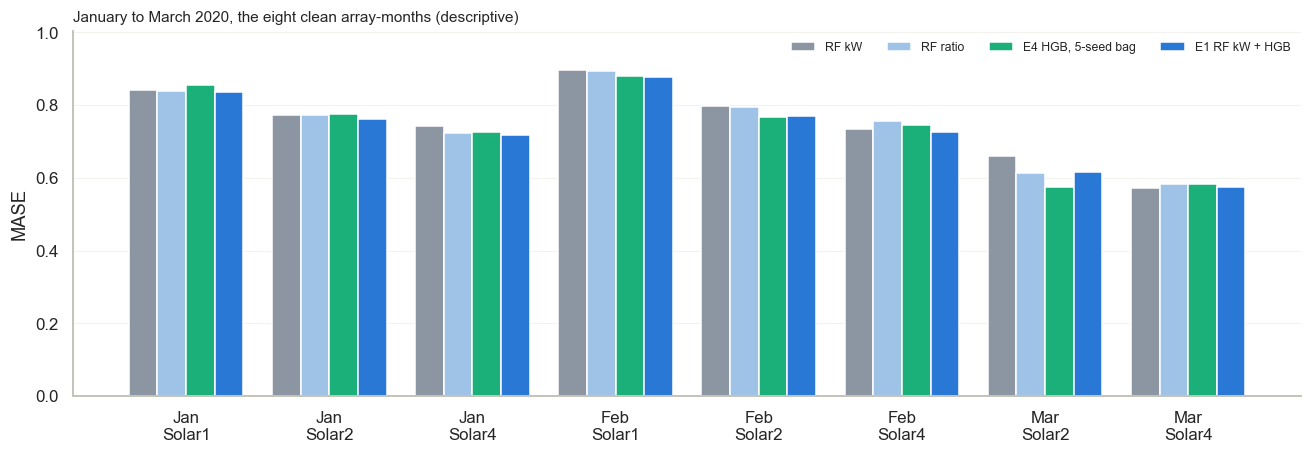

In [117]:
# --- Figure: January to March 2020, each clean array-month -----------------------------------
fg_cols = ["RF kW", "RF ratio", "E4 HGB, 5-seed bag", "E1 RF kW + HGB"]
fg_col = {"RF kW": "#8c96a3", "RF ratio": "#9ec3e6", "E4 HGB, 5-seed bag": "#1baf7a", "E1 RF kW + HGB": "#2a78d6"}
fg_idx = [(m, a) for m in ("Jan", "Feb", "Mar") for a in CLEAN21[m]]
fig, ax = plt.subplots(figsize=(12, 4.2))
x = np.arange(len(fg_idx)); w = 0.2
for k, c in enumerate(fg_cols):
    ax.bar(x + (k - 1.5) * w, [pre.loc[i, c] for i in fg_idx], w, color=fg_col[c], label=c)
ax.set_xticks(x, [f"{m}\n{a}" for m, a in fg_idx])
ax.set_ylabel("MASE"); ax.set_ylim(0, max(pre.loc[fg_idx, fg_cols].max()) * 1.12)
ax.set_title("January to March 2020, the eight clean array-months (descriptive)", loc="left")
ax.legend(fontsize=8, ncol=4, loc="upper right"); ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 21e. Do the verdicts survive the flagged days?

Cell 45's flagged days affect the scoring in two ways, and neither can be argued away.

- **Every MASE scale is computed from the raw series, flagged days included.** A clean scale
  would not change which model wins in any single array-month, because both models share the
  scale there. It *would* reweight the arrays inside every six-array mean. That changes the
  six-month means and the months-beaten counts the rule relies on.
- **Solar0's test months contain flagged days,** and they are scored as actuals. Removing test
  rows changes each model's error by a different amount.

So everything is rescored four ways from the stored forecasts:

1. as reported;
2. with every scale computed without the flagged days;
3. with the flagged days removed from the test months;
4. with both changes.

This covers every section 21 candidate and section 19's models. Section 20's LSTM variants were
not stored, so section 20 is not recomputed.

In [118]:
# --- 21e. Do the verdicts survive the flagged days? ----------------------------------
FLAGGED = {s: bad_days.index[bad_days[s].fillna(False)] for s in SOLAR}


def mase_scale_clean(name, start, lag=SEASONAL_LAG):
    """mase_scale (cell 77) with cell 45's flagged days set to missing first."""
    s = df[name].copy()
    s[s.index.normalize().isin(FLAGGED[name])] = np.nan
    tr = s.loc[s.index < start].to_numpy()
    return np.nanmean(np.abs(tr[lag:] - tr[:-lag]))


SCALE = {(n, mon): (mase_scale(n, w[0]), mase_scale_clean(n, w[0])) for n in SOLAR for mon, w in FOLDS.items()}
display(pd.DataFrame({mon: {n: 100 * (SCALE[(n, mon)][1] / SCALE[(n, mon)][0] - 1) for n in SOLAR}
                      for mon in ("Jun", "Nov")}).round(0)
        .rename_axis("MASE scale change without flagged days, % (June and November origins)"))
display(pd.Series({mon: int(sum(((FLAGGED["Solar0"] >= w[0].tz_convert(LOCAL_TZ).normalize())
                                 & (FLAGGED["Solar0"] < w[1].tz_convert(LOCAL_TZ).normalize()))))
                   for mon, w in FOLDS.items()}, name="Solar0 flagged days inside each test month"))


def score_setting(frame, preds, win, mon, clean_scale, drop_flagged):
    f = frame.assign(pred=clean_pred(frame, preds)); rows = {}
    for name in SOLAR:
        fc = expand_to_15min(f.loc[f["array"] == name, "pred"], win)
        actual = df[name].reindex(fc.index).copy()
        if drop_flagged:
            actual[fc.index.normalize().isin(FLAGGED[name])] = np.nan
        ok = actual.notna() & fc.notna()
        rows[name] = np.mean(np.abs(actual[ok] - fc[ok])) / SCALE[(name, mon)][int(clean_scale)]
    return pd.Series(rows)


ALL21 = dict(CANDS)
ALL21.update({"RF kW (19)": lambda mon, P: P["RF kW"], "RF ratio (19)": lambda mon, P: P["RF ratio"],
              "LSTM corrected (19)": lambda mon, P: P["LSTM"],
              "LSTM + HGB (18, 19)": lambda mon, P: P[["LSTM", "HGB s0"]].mean(axis=1)})
SETTINGS = {"as reported": (False, False), "clean scales": (True, False),
            "flagged test days removed": (False, True), "both": (True, True)}
sens_rows, sens_verdict = {}, {}
for lab, (cs, dfl) in SETTINGS.items():
    e = pd.DataFrame({(mon, c): score_setting(FRAME21[mon], fn(mon, PRED21[mon]), FOLDS[mon], mon, cs, dfl)
                      for mon in M for c, fn in ALL21.items()}).T
    t = summarise(e)
    rm = t.loc[REF, "6-month mean"]
    sens_rows[lab] = t["6-month mean"]
    sens_verdict[lab] = pd.Series({c: ("reference" if c == REF else "adopt" if (
        t.loc[c, "6-month mean"] < rm and t.loc[c, "months beating HGB"] >= 4 and t.loc[c, "one-sided sign p"] < BONF)
        else "exploratory pass" if (t.loc[c, "6-month mean"] < rm and t.loc[c, "months beating HGB"] >= 4)
        else "fail") for c in CANDS})
    sens_verdict[lab + " (months>HGB, sign)"] = (t["months beating HGB"].astype(str) + ", "
                                                 + t["array-months beating HGB"]).loc[list(CANDS)]
sens_mean = pd.DataFrame(sens_rows)
display(sens_mean.sort_values("as reported").round(4).rename_axis("6-month mean MASE under each setting"))
display(pd.DataFrame(sens_verdict).rename_axis("section 21 verdicts under each setting"))
ranks = sens_mean.rank()
display(ranks.sort_values("as reported").astype(int).rename_axis("rank of every model (1 = best)"))

,Jun,Nov
"MASE scale change without flagged days, % (June and November origins)",,
Solar0,-3.0,9.0
Solar1,-36.0,-36.0
Solar2,-20.0,-21.0
Solar3,-48.0,-36.0
Solar4,-13.0,-12.0
Solar5,0.0,0.0


Jun    10
Jul     7
Aug     2
Sep     2
Oct     2
Nov     0
Name: Solar0 flagged days inside each test month, dtype: int64

,as reported,clean scales,flagged test days removed,both
6-month mean MASE under each setting,,,,
"E4 HGB, 5-seed bag",0.5327,0.6520,0.5344,0.6537
HGB (section 19),0.5361,0.6565,0.5379,0.6582
E2 RF kW + HGB + LSTM,0.5389,0.6601,0.5408,0.6619
E5 median of four,0.5390,0.6589,0.5408,0.6607
"LSTM + HGB (18, 19)",0.5393,0.6582,0.5416,0.6604
E3a past-only inverse-MASE weights,0.5403,0.6616,0.5423,0.6635
E0 equal mean of four,0.5404,0.6615,0.5424,0.6634
E1 RF kW + HGB,0.5421,0.6667,0.5436,0.6681
RF ratio (19),0.5561,0.6792,0.5583,0.6813


,as reported,"as reported (months>HGB, sign)",clean scales,"clean scales (months>HGB, sign)",flagged test days removed,"flagged test days removed (months>HGB, sign)",both,"both (months>HGB, sign)"
section 21 verdicts under each setting,,,,,,,,
HGB (section 19),reference,"0, 0/36",reference,"0, 0/36",reference,"0, 0/36",reference,"0, 0/36"
E0 equal mean of four,fail,"2, 20/36",fail,"3, 20/36",fail,"2, 20/36",fail,"3, 20/36"
E1 RF kW + HGB,fail,"2, 18/36",fail,"2, 18/36",fail,"2, 19/36",fail,"2, 19/36"
E2 RF kW + HGB + LSTM,fail,"3, 22/36",fail,"3, 22/36",fail,"3, 22/36",fail,"2, 22/36"
E3a past-only inverse-MASE weights,fail,"3, 19/36",fail,"3, 19/36",fail,"3, 19/36",fail,"3, 19/36"
"E4 HGB, 5-seed bag",adopt,"6, 30/36",adopt,"6, 30/36",adopt,"6, 30/36",adopt,"6, 30/36"
E5 median of four,fail,"3, 19/36",fail,"3, 19/36",fail,"3, 18/36",fail,"3, 18/36"


,as reported,clean scales,flagged test days removed,both
rank of every model (1 = best),,,,
"E4 HGB, 5-seed bag",1,1,1,1
HGB (section 19),2,2,2,2
E2 RF kW + HGB + LSTM,3,5,4,5
E5 median of four,4,4,3,4
"LSTM + HGB (18, 19)",5,3,5,3
E3a past-only inverse-MASE weights,6,7,6,7
E0 equal mean of four,7,6,7,6
E1 RF kW + HGB,8,8,8,8
RF ratio (19),9,9,9,9


### Reading 21

**Bagging boosting is adopted, as free variance reduction rather than a modelling improvement.**
The five-seed bag scores 0.5327 over six months, against 0.5361 for seed-0 boosting and 0.5354
for the average seed. It beats boosting in all six months and in 30 of 36 array-months.

That record was expected by construction, so the p-value is not evidence. The bag can never do
worse than its average seed, and seed 0 happened to be slightly worse than average. What matters
is the size of the gain: 0.0014–0.0041 per month against the seed average. That is similar in
size to the spread of the single seeds themselves (sd 0.0015–0.0092 per month). It is smaller
than the spread from June to September, and larger in October and November. The summer check agrees.
In March the bag scores 0.5789 against a seed average of 0.5816, a gain of 0.0026, and seed 0
was the worst of the five. What bagging buys is freedom from the luck of the seed draw, at no
cost.

Two consequences:

- Earlier comparisons pitted a *single* boosting model against *three-seed* LSTM averages.
  Bagging makes that comparison fair, and boosting still wins.
- **The reference from now on is the bag at 0.5327.** It is the same model family as before,
  not a new model.

**No blend beat boosting under the rule, and none beat its own best member in any month.** The
blends do gain real diversity, between 0.011 and 0.018 on the six-month mean over their
averaging bound, but that is not enough. Each added model is poor in part of the year: the kW
forest in spring, the LSTM in winter, the ratio forest from August to October. Averaging one in
costs more in its bad season than the diversity gains back.

The closest was E2, RF kW + HGB + LSTM, at 0.5389. It beat boosting in June, October and
November and in 22 of 36 array-months, but that is not significant (p = 0.12). E1 lost October
and November badly (0.6284, 0.6353) because the kW forest is poor in spring (0.6805, 0.6989).

**Inverse-MASE weighting over this pool is indistinguishable from equal weights.** The four
models' past scores never differ by more than about 1.2×, so the weights stay between 0.23 and
0.28. E3a is within 0.0015 of E0 in every month. This says nothing about weighting in general,
only about this rule applied to this pool. The median (E5) against the mean (E0) was not a
planned comparison, so no conclusion is drawn from it.

**The summer check (8 clean array-months, descriptive only):**

- **Under high summer sun, boosting's spring advantage does not appear.** Boosting beats the kW
  forest in only 4 of the 8 array-months. Its mean edge of 0.0117 comes mostly from one cell,
  Solar2 in March (+0.072). January's sun (75°) is higher than October's (65°), yet the gap seen
  in October is absent. As far as these few cells go, that argues against Reading 19's idea that
  sun elevation drives the seasonal pattern. The limits are real, though:
  - it is only 8 array-months;
  - by January, Solar2 and Solar4 had only about seven months of history, much of it the
    June–September 2019 outage (cells 55 and 174);
  - boosting's early stopping was off in January and February.
- **The ratio target makes about no difference here.** RF ratio's mean edge over RF kW (0.0055)
  rests on the same cell (Solar2 in March, +0.045). Without it the edge is about zero.
- **The Haurwitz reference makes no difference under high sun** (0.7501 against 0.7469). A
  60–75° month cannot test a low-sun effect, so this is a description, not a test.
- **E1 has the best summer score** (0.7354, against 0.7408 for boosting). Eight array-months
  cannot overturn its failure on the six-month backtest.
- **Bagging makes no difference in January and February.** All five seeds are identical there:
  those folds have fewer than 10,000 training rows, so boosting's random early-stopping split
  never switches on.

**Where boosting's spring advantage over the kW forest comes from.** This can be read directly
from section 19's per-array gains (cell 195, left panel). Solar3 and Solar0 supply 71%, 68% and
93% of boosting's mean gain in September, October and November. That gain mixes the correction,
the ratio target and the absolute-error loss. On the uncorrected Solar1, Solar2 and Solar4,
boosting still gained 0.033–0.076 in September and October.

**The flagged days change no verdict (21e).** Everything was rescored three more ways: with
MASE scales computed without flagged days, with flagged days removed from the test months, and
with both.

- **Every section 21 verdict is identical in all four settings.** The bag and single-seed
  boosting rank first and second in each.
- **Section 19's comparison holds too.** Boosting alone stays ahead of LSTM + boosting in every
  setting, for example 0.6565 against 0.6582 with clean scales.
- **Only the middle of the table reshuffles.** E2, E5, E0, E3a and LSTM + boosting swap places,
  but they lie within about 0.003 of each other.
- Section 20's LSTM variants were not stored, so section 20 was not recomputed.

**Absolute levels do change, and that applies beyond this section.** `mase_scale` uses the raw
series, stuck counter and all.

- Without flagged days, the scales at the June origin are 36% lower for Solar1, 20% for Solar2,
  48% for Solar3 and 13% for Solar4. At the November origin they are 36%, 21%, 36% and 12% lower.
  Solar0 changes by −3% and +9%, and Solar5 not at all.
- With clean scales, every six-month mean rises by about 0.12 to 0.14. Boosting goes from 0.5361
  to 0.6565, and the kW forest from 0.5693 to 0.7055.
- **The absolute MASE figures throughout this notebook therefore understate the error on
  Solar1–4.** Comparisons between models do not depend on it.
- Solar0's are the only flagged days inside the test months: 10 in June, 7 in July, and 2 each
  in August to October. Removing them raises every model's six-month mean slightly; boosting goes
  from 0.5361 to 0.5379.

**A side observation.** Section 16's Solar3 changeover gap (18 April to 31 May) mostly coincides
with the site-wide stuck-counter spell (15 April to 19 May). Section 9's cleaning removes those
days from `solar_data`, so the weeks are largely *missing* rather than visibly broken. Whether
Solar3 also had a genuine fault then cannot be told. Section 17 is unaffected, because the gap
is dropped.

**Recommended model: the five-seed bag of absolute-error boosting on the corrected ratio
target.** Its six-month mean is 0.5327. No ensemble across model families beat it. *Superseded: see Reading 25.*

---

# 22. Six LSTM architectures, tested on the backtest

Sections 14 and 20 changed the LSTM's schedule, window direction, bidirectionality, attention,
seed count, identity flags and clear-sky reference. None made a reliable difference. This
section tries six more changes to the architecture itself.

**Expectations.** The corrected LSTM (0.5646 over six months) is 0.032 behind the bagged
boosting model from section 21 (0.5327). An architecture change would have to beat that bag to
change the recommendation, which is unlikely. The real question here is narrower: *does the
architecture matter for the LSTM at all?*

**This plan, including the predictions below, was written and reviewed before anything ran.**
The same reviewer as section 21, a second AI session (Claude) acting as a sceptical
methodological reviewer, read it before any network was trained. It made five changes:

1. It replaced a stacked two-layer LSTM with a **no-recurrence control** that sees only the
   current hour's weather.
2. It removed recurrent dropout from A4, so that A4 is not three changes bundled together.
3. It added a **confirmation stage** with two extra seeds.
4. It fixed the one permitted blend in advance.
5. It turned each prediction into a number that can be scored.

**The baseline** is the corrected ratio-target LSTM from 13a, 17d and 19. Its structure is
LSTM(48) → joined with a Dense(32) branch for the static features → Dense(32) → output. It is
trained with Adam at 1e-3 on MAE loss, with the same early stopping and learning-rate schedule
throughout. Each variant changes one named part and nothing else: same months, data, target,
schedule, and the 3-seed ensemble.

| # | Change | Prediction, where Δ = baseline minus variant six-month mean (positive = variant better) |
|---|---|---|
| A1 | GRU(48) instead of LSTM(48) | \|Δ\| ≤ 0.005 |
| A2 | LSTM(24): half the units, about a quarter of the recurrent weights | Δ over Jun–Aug > 0, **and** greater than Δ over Sep–Nov, **and** Solar0's Δ over Jun–Sep > 0 (when training data is scarcest) |
| A3 | **no recurrence**: only the current hour's weather, through Dense(48) | Δ < −0.01 (the weather sequence matters) |
| A4 | dropout: LSTM(48, dropout=0.2), plus Dropout(0.2) after the head's Dense(32) | as A2 |
| A5 | 12-hour window instead of 24 | Δ ≥ −0.005 |
| A6 | 48-hour window | Δ ≤ +0.005 |

A3, A5, the baseline and A6 form a window ladder of 1, 12, 24 and 48 hours. Keras turns
dropout off when it computes the validation loss, so early stopping judges every variant the
same way. A4 keeps the same schedule even if it stops early.

**Decision rule, as in section 21.** A variant is **adopted** only if all three hold: it beats
the baseline's six-month mean; it wins at least four of the six months; and it passes a
one-sided sign test over the 36 array-months at p < 0.05/6 (ties count as losses). If it meets
the first two but not the third, it is an "exploratory pass". At most one variant is adopted:
the lowest mean.

**Confirmation stage.** All six arrays in a month share the same three networks, so the month
wins and the array-month signs are noisier than they look. In section 20, simply adding two
seeds moved monthly scores by up to 0.014. So any variant that passes or exploratory-passes gets
seeds 3 and 4, and must pass the same rule again against the 5-seed baseline (six-month mean
0.5649, already cached). A variant is adopted only if it survives that.

**One pre-registered blend.** If a variant is adopted, exactly one blend is tested: that variant
plus the bagged boosting model, equal weights, judged against the bag under section 21's rule.

**Reported for every variant, whatever the verdicts:**

- its three single-seed six-month means;
- whether its worst seed beats the baseline's best seed;
- how each prediction above scored.

In [119]:
# --- 22a. Six architectures, each trained on every backtest month --------------------
def make_arch(kind, seed, steps, n_static):
    """13a's network with one part swapped, per the plan above."""
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(steps, len(SEQ_FEATURES)))
    t_in = keras.Input(shape=(n_static,))
    if kind == "GRU":
        x = layers.GRU(48)(s_in)
    elif kind == "small":
        x = layers.LSTM(24)(s_in)
    elif kind == "norec":
        x = layers.Dense(48, activation="relu")(layers.Flatten()(s_in))
    elif kind == "dropout":
        x = layers.LSTM(48, dropout=0.2)(s_in)
    else:                                   # "w12", "w48": the baseline's LSTM(48)
        x = layers.LSTM(48)(s_in)
    z = layers.Concatenate()([x, layers.Dense(32, activation="relu")(t_in)])
    z = layers.Dense(32, activation="relu")(z)
    if kind == "dropout":
        z = layers.Dropout(0.2)(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


def train_arch(kind, seq, stat, y, mask, tag, seeds=(0, 1, 2)):
    """train_seeds (13a): same split, schedule and callbacks."""
    s_, t_, y_ = seq[mask], stat[mask], y[mask].astype("float32")
    cut = int(len(y_) * 0.9)

    def _fit():
        nets, hists = [], []
        for s in seeds:
            m = make_arch(kind, s, s_.shape[1], t_.shape[1])
            h = m.fit([s_[:cut], t_[:cut]], y_[:cut], validation_data=([s_[cut:], t_[cut:]], y_[cut:]),
                      epochs=150, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
            nets.append(m); hists.append(h.history)
        return nets, hists
    return cached_nets(f"seeds_{tag}", _fit)


w1, w12, w48 = window_builder(0, 0), window_builder(11, 0), window_builder(47, 0)
SEQ = {"base": (seq_tr, build_inputs)}
for k, b in (("w1", w1), ("w12", w12), ("w48", w48)):
    s, _, ok = b(td); assert ok.all() and len(s) == len(td); SEQ[k] = (s, b)
KINDS = {"A1 GRU": ("GRU", "base"), "A2 LSTM(24)": ("small", "base"), "A3 no recurrence": ("norec", "w1"),
         "A4 dropout": ("dropout", "base"), "A5 12-h window": ("w12", "w12"), "A6 48-h window": ("w48", "w48")}
WINDOW_H = {"A3 no recurrence": 1, "A5 12-h window": 12, "A6 48-h window": 48}

PRED22, SEEDP22, HIST22 = {}, {}, {}
for mon, win in FOLDS.items():
    arrays = FIXED[mon]
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    frame, cols = FRAME21[mon], {}
    for name, (kind, sk) in KINDS.items():
        seq, bld = SEQ[sk]
        nets, hists = train_arch(kind, seq, stat_tr, r, mask, f"v22-{kind}-{mon}-{'-'.join(arrays) or 'none'}")
        HIST22[(mon, name)] = [len(h["loss"]) for h in hists]
        SEEDP22[(mon, name)] = [clean_pred(frame, predict_with([m], bld, ALL, ref_linear, caps)(frame)) for m in nets]
        cols[name] = np.mean(SEEDP22[(mon, name)], axis=0)
    PRED22[mon] = pd.DataFrame(cols, index=frame.index)
print("epochs run per seed (June and November folds):")
display(pd.DataFrame({m: {n: HIST22[(m, n)] for n in KINDS} for m in ("Jun", "Nov")}))

  [cache] loaded seeds_v22-GRU-Jun-none (3 networks)


  [cache] loaded seeds_v22-small-Jun-none (3 networks)
  [cache] loaded seeds_v22-norec-Jun-none (3 networks)


  [cache] loaded seeds_v22-dropout-Jun-none (3 networks)


  [cache] loaded seeds_v22-w12-Jun-none (3 networks)
  [cache] loaded seeds_v22-w48-Jun-none (3 networks)


  [cache] loaded seeds_v22-GRU-Jul-Solar3 (3 networks)


...

  [cache] loaded seeds_v22-small-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-norec-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v22-dropout-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v22-w12-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-w48-Nov-Solar3-Solar0 (3 networks)


epochs run per seed (June and November folds):


,Jun,Nov
A1 GRU,"[13, 14, 13]","[21, 34, 18]"
A2 LSTM(24),"[13, 14, 14]","[19, 25, 24]"
A3 no recurrence,"[13, 15, 14]","[27, 27, 34]"
A4 dropout,"[13, 13, 13]","[30, 30, 36]"
A5 12-h window,"[13, 15, 14]","[16, 21, 18]"
A6 48-h window,"[13, 13, 13]","[16, 18, 24]"


## 22b. The verdicts, and how each prediction scored

In [120]:
# --- 22b. The verdicts, and how each prediction scored -------------------------------
M = list(FOLDS)
NAMES22 = list(KINDS)
BASE22 = "baseline LSTM (19)"
e22 = pd.DataFrame({**{(mon, BASE22): score_vec(FRAME21[mon], PRED21[mon]["LSTM"], FOLDS[mon]) for mon in M},
                    **{(mon, n): score_vec(FRAME21[mon], PRED22[mon][n], FOLDS[mon]) for mon in M for n in NAMES22}}).T
tab22m = e22[SOLAR].mean(axis=1).unstack(0)[M].loc[[BASE22] + NAMES22]
tab22 = tab22m.copy()
tab22["6-month mean"] = tab22m.mean(axis=1)
tab22["months beating baseline"] = [int((tab22m.loc[n] < tab22m.loc[BASE22]).sum()) for n in tab22m.index]
base_am = e22.xs(BASE22, level=1)[SOLAR]
kn = [(int(((base_am - e22.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum()), base_am.size) for n in tab22m.index]
tab22["array-months beating baseline"] = [f"{k}/{m}" for k, m in kn]
tab22["one-sided sign p"] = [binomtest(k, m, 0.5, alternative="greater").pvalue for k, m in kn]
BONF22 = 0.05 / len(NAMES22)
bmean = tab22.loc[BASE22, "6-month mean"]


def verdict22(n, r):
    if n == BASE22:
        return "baseline"
    if not (r["6-month mean"] < bmean and r["months beating baseline"] >= 4):
        return "fail"
    return "pass -> confirm" if r["one-sided sign p"] < BONF22 else "exploratory pass -> confirm"


tab22["verdict (3 seeds)"] = [verdict22(n, r) for n, r in tab22.iterrows()]
display(tab22.round(4))
print(f"Bonferroni threshold over {len(NAMES22)} variants: p < {BONF22:.4f}.   "
      f"For reference, the bagged boosting model (21): {tab21.loc['E4 HGB, 5-seed bag', '6-month mean']:.4f}")

delta = tab22m.loc[BASE22] - tab22m                         # positive = variant better
d6 = tab22.loc[BASE22, "6-month mean"] - tab22["6-month mean"]
JS = ["Jun", "Jul", "Aug", "Sep"]
s0 = e22["Solar0"].unstack(1).loc[JS].rsub(e22.xs(BASE22, level=1)["Solar0"].loc[JS], axis=0).mean()
pt = pd.DataFrame({n: {"delta, 6-month": d6[n],
                       "delta, Jun-Aug": delta.loc[n, ["Jun", "Jul", "Aug"]].mean(),
                       "delta, Sep-Nov": delta.loc[n, ["Sep", "Oct", "Nov"]].mean(),
                       "Solar0 delta, Jun-Sep": s0[n]} for n in NAMES22}).T


def scarce(n):
    r = pt.loc[n]
    return bool(r["delta, Jun-Aug"] > 0 and r["delta, Jun-Aug"] > r["delta, Sep-Nov"] and r["Solar0 delta, Jun-Sep"] > 0)


pt["prediction"] = ["|delta| <= 0.005", "scarce-data gain", "delta < -0.01", "scarce-data gain",
                    "delta >= -0.005", "delta <= +0.005"]
pt["held"] = [abs(d6["A1 GRU"]) <= 0.005, scarce("A2 LSTM(24)"), d6["A3 no recurrence"] < -0.01,
              scarce("A4 dropout"), d6["A5 12-h window"] >= -0.005, d6["A6 48-h window"] <= 0.005]
display(pt.round(4).rename_axis("pre-registered predictions (positive delta = variant better)"))

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating baseline,array-months beating baseline,one-sided sign p,verdict (3 seeds)
baseline LSTM (19),0.4696,0.4400,0.6686,0.6113,0.5946,0.6034,0.5646,0,0/36,1.0000,baseline
A1 GRU,0.4421,0.4164,0.6490,0.5409,0.6082,0.5607,0.5362,5,27/36,0.0020,pass -> confirm
A2 LSTM(24),0.4341,0.4190,0.6369,0.5765,0.6042,0.5954,0.5444,5,25/36,0.0144,exploratory pass -> confirm
A3 no recurrence,0.4839,0.4380,0.6482,0.5564,0.6095,0.6045,0.5568,3,21/36,0.2025,fail
A4 dropout,0.4378,0.4420,0.6581,0.5873,0.6119,0.6287,0.5610,3,13/36,0.9674,fail
A5 12-h window,0.4795,0.4307,0.6335,0.5921,0.6011,0.5996,0.5561,4,20/36,0.3089,exploratory pass -> confirm
A6 48-h window,0.4431,0.4401,0.6791,0.6185,0.5952,0.6039,0.5633,1,15/36,0.8785,fail


Bonferroni threshold over 6 variants: p < 0.0083.   For reference, the bagged boosting model (21): 0.5327


,"delta, 6-month","delta, Jun-Aug","delta, Sep-Nov","Solar0 delta, Jun-Sep",prediction,held
pre-registered predictions (positive delta = variant better),,,,,,
A1 GRU,0.0284,0.0235,0.0332,0.0837,|delta| <= 0.005,False
A2 LSTM(24),0.0202,0.0294,0.0111,0.1454,scarce-data gain,True
A3 no recurrence,0.0078,0.0027,0.0130,0.0424,delta < -0.01,False
A4 dropout,0.0036,0.0134,-0.0062,0.0802,scarce-data gain,True
A5 12-h window,0.0085,0.0115,0.0055,0.0579,delta >= -0.005,True
A6 48-h window,0.0013,0.0053,-0.0028,-0.0058,delta <= +0.005,True


**Figure.** Each architecture's gain over the baseline LSTM, month by month (three-seed ensembles). Blue cells are better than the baseline, red worse.

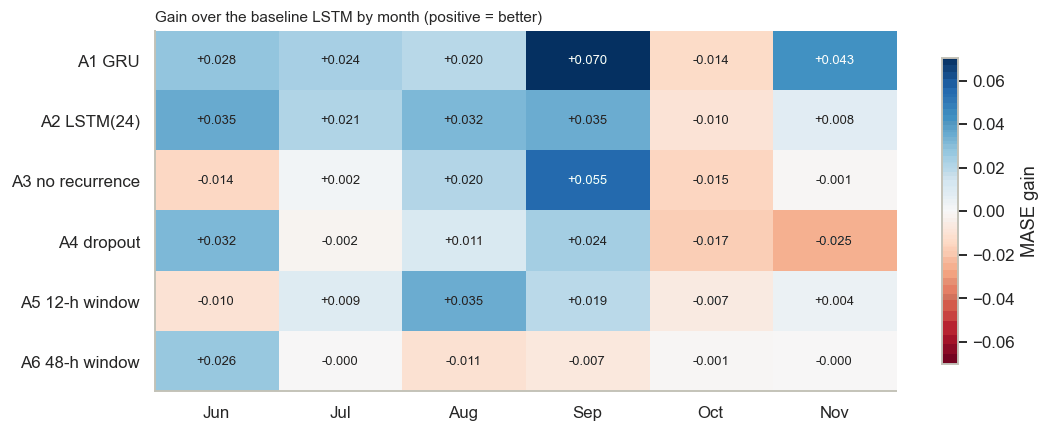

In [121]:
# --- Figure: section 22's gains over the baseline, by month ------------------------------------
fg_gain = (tab22m.loc[BASE22] - tab22m.loc[NAMES22])
fig, ax = plt.subplots(figsize=(10, 4))
fg_lim = np.abs(fg_gain.to_numpy()).max()
im = ax.imshow(fg_gain.to_numpy(), cmap="RdBu", vmin=-fg_lim, vmax=fg_lim, aspect="auto")
for (i, j), v in np.ndenumerate(fg_gain.to_numpy()):
    ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8.5,
            color="white" if abs(v) > 0.6 * fg_lim else "#222")
ax.set_xticks(range(len(M)), M); ax.set_yticks(range(len(NAMES22)), NAMES22)
ax.set_title("Gain over the baseline LSTM by month (positive = better)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.85, label="MASE gain")
plt.tight_layout(); plt.show()

## 22c. Seed by seed, and the window ladder

Each dot is one network's six-month mean, and the diamond is the 3-seed ensemble that the
verdicts use. The shaded band is the baseline's own seed-to-seed range. A variant whose dots
all sit inside that band is not clearly distinguishable from the baseline on its seeds alone.

  [cache] loaded seeds_LSTM-ratio-original-preJun (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preJul (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preAug (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preSep (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preOct (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected (3 networks)


,seed 0,seed 1,seed 2,worst seed beats the baseline's best
six-month mean MASE of each single seed,,,,
baseline LSTM (19),0.5787,0.5653,0.5921,False
A1 GRU,0.5448,0.5463,0.5570,True
A2 LSTM(24),0.5548,0.5456,0.6016,False
A3 no recurrence,0.5611,0.5783,0.5700,False
A4 dropout,0.5725,0.5620,0.5735,False
A5 12-h window,0.5658,0.5551,0.5903,False
A6 48-h window,0.5807,0.5647,0.5944,False


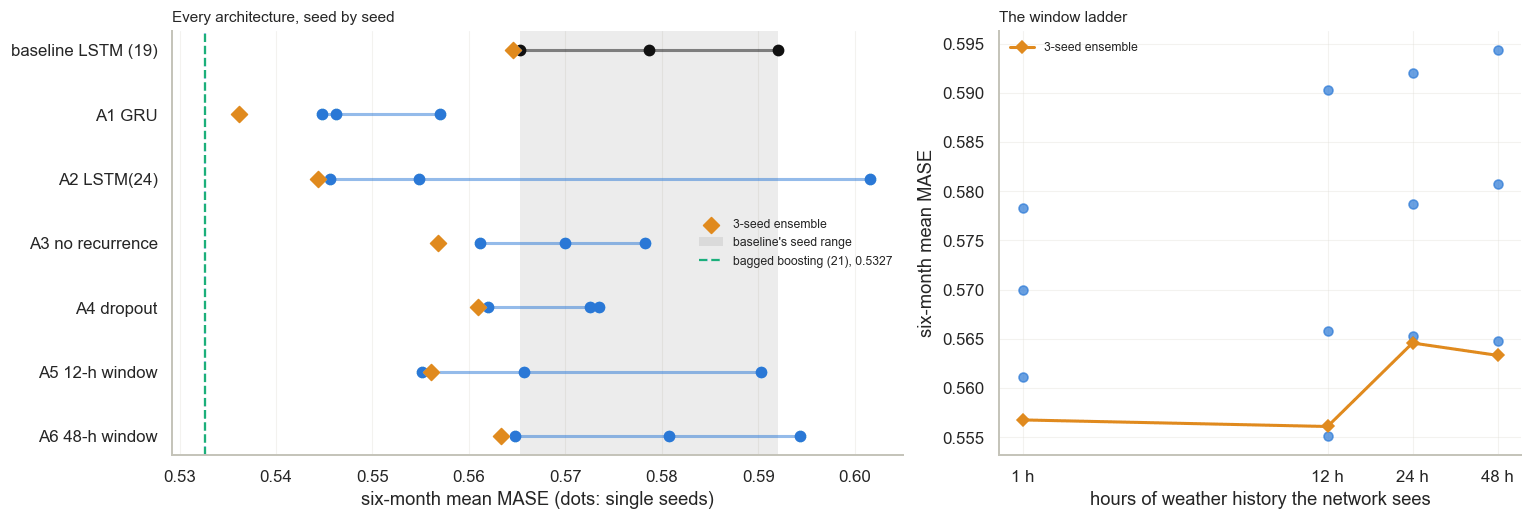

In [122]:
# --- 22c. Seed by seed, and the window ladder -----------------------------------------
bseeds = {}
for mon, win in FOLDS.items():
    r, mask, caps = ratio_inputs_ref(win[0], FIXED[mon], ref_linear)
    nets = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, FIXED[mon]))          # cached (19)
    bseeds[mon] = [score_vec(FRAME21[mon], clean_pred(FRAME21[mon], predict_with([m], build_inputs, ALL,
                                                                                  ref_linear, caps)(FRAME21[mon])),
                             win).mean() for m in nets]
seed6 = {BASE22: np.mean([bseeds[mon] for mon in M], axis=0)}
for n in NAMES22:
    seed6[n] = np.mean([[score_vec(FRAME21[mon], p, FOLDS[mon]).mean() for p in SEEDP22[(mon, n)]] for mon in M],
                       axis=0)
st22 = pd.DataFrame(seed6, index=["seed 0", "seed 1", "seed 2"]).T
st22["worst seed beats the baseline's best"] = st22.max(axis=1) < st22.loc[BASE22].min()
display(st22.round(4).rename_axis("six-month mean MASE of each single seed"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
order = [BASE22] + NAMES22
for i, n in enumerate(order):
    v = st22.loc[n, ["seed 0", "seed 1", "seed 2"]].to_numpy(dtype=float)
    col = "#111111" if n == BASE22 else "#2a78d6"
    a1.plot([v.min(), v.max()], [i, i], color=col, lw=2, alpha=0.5)
    a1.scatter(v, [i] * 3, color=col, s=45, zorder=3)
    a1.scatter(tab22.loc[n, "6-month mean"], i, marker="D", color="#e08a1e", s=55, zorder=4,
               label="3-seed ensemble" if i == 0 else None)
lo, hi = st22.loc[BASE22, ["seed 0", "seed 1", "seed 2"]].min(), st22.loc[BASE22, ["seed 0", "seed 1", "seed 2"]].max()
a1.axvspan(lo, hi, color="#111", alpha=0.08, lw=0, label="baseline's seed range")
bag = tab21.loc["E4 HGB, 5-seed bag", "6-month mean"]
a1.axvline(bag, color="#1baf7a", ls="--", lw=1.5, label=f"bagged boosting (21), {bag:.4f}")
a1.set_yticks(range(len(order)), order); a1.invert_yaxis()
a1.set_xlabel("six-month mean MASE (dots: single seeds)")
a1.set_title("Every architecture, seed by seed", loc="left")
a1.legend(fontsize=8, loc="center right"); a1.grid(True, axis="x", alpha=0.4); a1.set_axisbelow(True)

ladder = [("A3 no recurrence", 1), ("A5 12-h window", 12), (BASE22, 24), ("A6 48-h window", 48)]
hrs = [h for _, h in ladder]
for n, h in ladder:
    v = st22.loc[n, ["seed 0", "seed 1", "seed 2"]].to_numpy(dtype=float)
    a2.scatter([h] * 3, v, color="#2a78d6", s=35, alpha=0.7)
a2.plot(hrs, [tab22.loc[n, "6-month mean"] for n, _ in ladder], color="#e08a1e", marker="D", lw=2,
        label="3-seed ensemble")
a2.set_xscale("log"); a2.set_xticks(hrs, [f"{h} h" for h in hrs])
a2.set_xlabel("hours of weather history the network sees")
a2.set_ylabel("six-month mean MASE")
a2.set_title("The window ladder", loc="left")
a2.legend(fontsize=8); a2.grid(True, alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 22d. Confirmation at five seeds, and the one pre-registered blend

Every variant that passed or exploratory-passed gets seeds 3 and 4, and faces the same rule
again, this time against the five-seed baseline. The lowest-mean confirmed variant is adopted and
gets the single blend fixed in advance: it plus the bagged boosting model, judged under
section 21's rule (p < 0.05/6).

In [123]:
# --- 22d. Confirmation at five seeds, and the one pre-registered blend ------------------
to_confirm = [n for n in NAMES22 if tab22.loc[n, "verdict (3 seeds)"] != "fail"]
print("confirming:", to_confirm)


def _confirm22():
    out = {}
    for mon, win in FOLDS.items():
        arrays = FIXED[mon]; tag_a = "-".join(arrays) or "none"
        r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
        frame = FRAME21[mon]
        base3 = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, arrays))
        base2 = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, arrays) + "-s34", seeds=(3, 4))
        out[(mon, "baseline, 5 seeds")] = clean_pred(frame, predict_with(base3 + base2, build_inputs, ALL, ref_linear, caps)(frame))
        for n in to_confirm:
            kind, sk = KINDS[n]; seq, bld = SEQ[sk]
            n3, _ = train_arch(kind, seq, stat_tr, r, mask, f"v22-{kind}-{mon}-{tag_a}")
            n2, _ = train_arch(kind, seq, stat_tr, r, mask, f"v22-{kind}-{mon}-{tag_a}-s34", seeds=(3, 4))
            out[(mon, n)] = clean_pred(frame, predict_with(n3 + n2, bld, ALL, ref_linear, caps)(frame))
            out[(mon, n, "seeds")] = [clean_pred(frame, predict_with([m], bld, ALL, ref_linear, caps)(frame))
                                      for m in n3 + n2]
        out[(mon, "baseline, 5 seeds", "seeds")] = [clean_pred(frame, predict_with([m], build_inputs, ALL,
                                                                                   ref_linear, caps)(frame))
                                                    for m in base3 + base2]
    return out


C22 = _confirm22()                                   # every network is cached; this only predicts
rows = ["baseline, 5 seeds"] + to_confirm
ce = pd.DataFrame({(mon, n): score_vec(FRAME21[mon], C22[(mon, n)], FOLDS[mon]) for mon in M for n in rows}).T
ct = ce[SOLAR].mean(axis=1).unstack(0)[M].loc[rows]
conf22 = ct.copy()
conf22["6-month mean"] = ct.mean(axis=1)
conf22["months beating baseline"] = [int((ct.loc[n] < ct.loc["baseline, 5 seeds"]).sum()) for n in rows]
b5 = ce.xs("baseline, 5 seeds", level=1)[SOLAR]
kn5 = [(int(((b5 - ce.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum()), b5.size) for n in rows]
conf22["array-months beating baseline"] = [f"{k}/{m}" for k, m in kn5]
conf22["one-sided sign p"] = [binomtest(k, m, 0.5, alternative="greater").pvalue for k, m in kn5]
b5m = conf22.loc["baseline, 5 seeds", "6-month mean"]
conf22["confirmed"] = [n != "baseline, 5 seeds" and r["6-month mean"] < b5m and r["months beating baseline"] >= 4
                       and r["one-sided sign p"] < BONF22 for n, r in conf22.iterrows()]
display(conf22.round(4).rename_axis("confirmation at five seeds (same rule as 22b)"))
seeds5 = pd.DataFrame({n: [np.mean([score_vec(FRAME21[mon], C22[(mon, n, "seeds")][s], FOLDS[mon]).mean() for mon in M])
                           for s in range(5)] for n in ["baseline, 5 seeds"] + to_confirm},
                      index=[f"seed {s}" for s in range(5)]).T
display(seeds5.round(4).rename_axis("six-month mean of each single seed"))

confirmed = [n for n in to_confirm if conf22.loc[n, "confirmed"]]
ADOPT22 = min(confirmed, key=lambda n: conf22.loc[n, "6-month mean"]) if confirmed else None
print("adopted:", ADOPT22)

BAGP = {mon: PRED21[mon][[f"HGB s{s}" for s in range(5)]].mean(axis=1).to_numpy() for mon in M}
if ADOPT22:
    be = pd.DataFrame({**{(mon, "HGB bag (21)"): score_vec(FRAME21[mon], BAGP[mon], FOLDS[mon]) for mon in M},
                       **{(mon, f"{ADOPT22} (5 seeds)"): score_vec(FRAME21[mon], C22[(mon, ADOPT22)], FOLDS[mon]) for mon in M},
                       **{(mon, "blend"): score_vec(FRAME21[mon], (BAGP[mon] + C22[(mon, ADOPT22)]) / 2, FOLDS[mon])
                          for mon in M}}).T
    blend22 = be[SOLAR].mean(axis=1).unstack(0)[M]
    blend22["6-month mean"] = blend22.mean(axis=1)
    kb = int(((be.xs("HGB bag (21)", level=1)[SOLAR] - be.xs("blend", level=1)[SOLAR]).to_numpy() > 0).sum())
    bound = (blend22.loc["HGB bag (21)", "6-month mean"] + blend22.loc[f"{ADOPT22} (5 seeds)", "6-month mean"]) / 2
    display(blend22.round(4).rename_axis(f"pre-registered blend: {ADOPT22} + HGB bag, equal weights"))
    print(f"blend beats the bag in {int((blend22.loc['blend', M] < blend22.loc['HGB bag (21)', M]).sum())}/6 months and "
          f"{kb}/36 array-months, one-sided p = {binomtest(kb, 36, 0.5, alternative='greater').pvalue:.4f} "
          f"(threshold {BONF22:.4f});  averaging bound {bound:.4f}")
    gain_m = blend22.loc["HGB bag (21)", M] - blend22.loc["blend", M]
    print(f"November's share of the six-month gain: {gain_m['Nov'] / gain_m.sum():.0%};  other five months: blend "
          f"{blend22.loc['blend', M[:-1]].mean():.4f} vs bag {blend22.loc['HGB bag (21)', M[:-1]].mean():.4f}")
    print("months where the GRU alone beats the bag (the blend's win there is guaranteed):",
          [m for m in M if blend22.loc[f"{ADOPT22} (5 seeds)", m] < blend22.loc["HGB bag (21)", m]])
    print("blend's margin over the bag by month:", gain_m.round(4).to_dict())

confirming: ['A1 GRU', 'A2 LSTM(24)', 'A5 12-h window']
  [cache] loaded seeds_LSTM-ratio-original-preJun (3 networks)
  [cache] loaded seeds_LSTM-ratio-original-preJun-s34 (2 networks)


  [cache] loaded seeds_v22-GRU-Jun-none (3 networks)
  [cache] loaded seeds_v22-GRU-Jun-none-s34 (2 networks)


  [cache] loaded seeds_v22-small-Jun-none (3 networks)
  [cache] loaded seeds_v22-small-Jun-none-s34 (2 networks)


  [cache] loaded seeds_v22-w12-Jun-none (3 networks)
  [cache] loaded seeds_v22-w12-Jun-none-s34 (2 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preJul (3 networks)
  [cache] loaded seeds_LSTM-ratio-corrected-preJul-s34 (2 networks)


...

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating baseline,array-months beating baseline,one-sided sign p,confirmed
confirmation at five seeds (same rule as 22b),,,,,,,,,,,
"baseline, 5 seeds",0.4739,0.4470,0.6592,0.6233,0.5965,0.5898,0.5649,0,0/36,1.0000,False
A1 GRU,0.4281,0.4140,0.6450,0.5549,0.6035,0.5602,0.5343,5,30/36,0.0000,True
A2 LSTM(24),0.4409,0.4269,0.6348,0.5861,0.6062,0.5907,0.5476,4,27/36,0.0020,True
A5 12-h window,0.4774,0.4344,0.6163,0.6068,0.6026,0.5904,0.5547,3,21/36,0.2025,False


,seed 0,seed 1,seed 2,seed 3,seed 4
six-month mean of each single seed,,,,,
"baseline, 5 seeds",0.5787,0.5653,0.5921,0.5873,0.5816
A1 GRU,0.5448,0.5463,0.5570,0.5542,0.5396
A2 LSTM(24),0.5548,0.5456,0.6016,0.5748,0.5765
A5 12-h window,0.5658,0.5551,0.5903,0.5735,0.5661


adopted: A1 GRU


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
"pre-registered blend: A1 GRU + HGB bag, equal weights",,,,,,,
A1 GRU (5 seeds),0.4281,0.4140,0.6450,0.5549,0.6035,0.5602,0.5343
HGB bag (21),0.4480,0.3828,0.6190,0.5400,0.6010,0.6053,0.5327
blend,0.4321,0.3908,0.6275,0.5395,0.5929,0.5691,0.5253


blend beats the bag in 4/6 months and 27/36 array-months, one-sided p = 0.0020 (threshold 0.0083);  averaging bound 0.5335
November's share of the six-month gain: 82%;  other five months: blend 0.5166 vs bag 0.5182
months where the GRU alone beats the bag (the blend's win there is guaranteed): ['Jun', 'Nov']
blend's margin over the bag by month: {'Jun': 0.0158, 'Jul': -0.008, 'Aug': -0.0085, 'Sep': 0.0006, 'Oct': 0.0081, 'Nov': 0.0362}


**Figure.** The confirmation stage month by month: every five-seed ensemble, the bagged boosting model and the pre-registered blend.

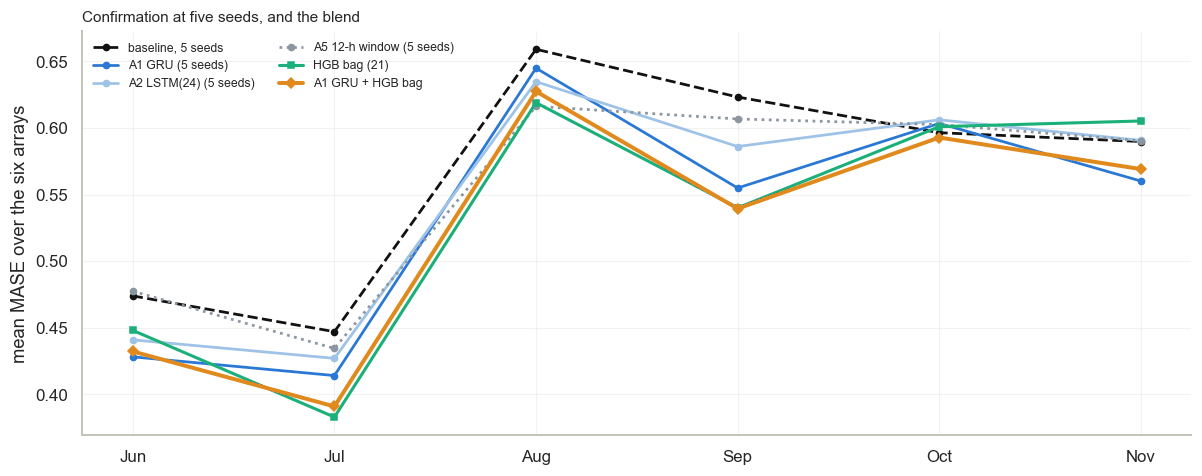

In [124]:
# --- Figure: five-seed ensembles and the blend, by month ---------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.4))
fg_style = {"baseline, 5 seeds": ("#111111", "--"), "A1 GRU": ("#2a78d6", "-"), "A2 LSTM(24)": ("#9ec3e6", "-"),
            "A5 12-h window": ("#8c96a3", ":")}
for n in ct.index:
    c, ls = fg_style.get(n, ("#999999", "-"))
    ax.plot(M, ct.loc[n, M], color=c, ls=ls, marker="o", ms=4, lw=1.8,
            label=n if "5 seeds" in n else f"{n} (5 seeds)")
if ADOPT22:
    ax.plot(M, blend22.loc["HGB bag (21)", M], color="#1baf7a", marker="s", ms=4, lw=2, label="HGB bag (21)")
    ax.plot(M, blend22.loc["blend", M], color="#e08a1e", marker="D", ms=5, lw=2.6, label=f"{ADOPT22} + HGB bag")
ax.set_ylabel("mean MASE over the six arrays"); ax.set_title("Confirmation at five seeds, and the blend", loc="left")
ax.legend(fontsize=8, ncol=2, loc="upper left"); ax.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 22e. Robustness to the flagged days

The adopted network and the blend are rescored in section 21e's four ways: as reported, with
clean MASE scales, with the flagged test days removed, and with both. This was pre-registered for
any variant that passed.

In [125]:
# --- 22e. Robustness to the flagged days (21e's four scoring settings) ----------------
if ADOPT22:
    P22 = {**{(mon, "baseline, 5 seeds"): C22[(mon, "baseline, 5 seeds")] for mon in M},
           **{(mon, ADOPT22): C22[(mon, ADOPT22)] for mon in M},
           **{(mon, "HGB bag"): BAGP[mon] for mon in M},
           **{(mon, "blend"): (BAGP[mon] + C22[(mon, ADOPT22)]) / 2 for mon in M}}
    rob = []
    for lab, (cs, dfl) in SETTINGS.items():
        e = pd.DataFrame({(mon, n): score_setting(FRAME21[mon], p, FOLDS[mon], mon, cs, dfl)
                          for (mon, n), p in P22.items()}).T
        t = e[SOLAR].mean(axis=1).unstack(0)[M]
        for a, b in [(ADOPT22, "baseline, 5 seeds"), ("blend", "HGB bag")]:
            d = (e.xs(b, level=1)[SOLAR] - e.xs(a, level=1)[SOLAR]).to_numpy().ravel(); k = int((d > 0).sum())
            rob.append({"setting": lab, "comparison": f"{a} vs {b}", "six-month": t.loc[a].mean(),
                        "reference": t.loc[b].mean(), "months better": int((t.loc[a] < t.loc[b]).sum()),
                        "array-months": f"{k}/36", "one-sided p": binomtest(k, 36, 0.5, alternative="greater").pvalue})
    display(pd.DataFrame(rob).round(4))

,setting,comparison,six-month,reference,months better,array-months,one-sided p
0,as reported,"A1 GRU vs baseline, 5 seeds",0.5343,0.5649,5,30/36,0.000
1,as reported,blend vs HGB bag,0.5253,0.5327,4,27/36,0.002
2,clean scales,"A1 GRU vs baseline, 5 seeds",0.6513,0.6890,5,30/36,0.000
3,clean scales,blend vs HGB bag,0.6419,0.6520,4,27/36,0.002
4,flagged test days removed,"A1 GRU vs baseline, 5 seeds",0.5370,0.5675,5,30/36,0.000
5,flagged test days removed,blend vs HGB bag,0.5275,0.5344,4,27/36,0.002
6,both,"A1 GRU vs baseline, 5 seeds",0.6539,0.6915,5,30/36,0.000
7,both,blend vs HGB bag,0.6440,0.6537,4,27/36,0.002


## 22f. What early stopping keeps, and a code-path control

Two checks the reviewer asked for after seeing the results:

- **The code-path control.** Does the baseline, retrained through this section's training
  function, reproduce the cached network? If not, the comparison would be confounded.
- **The best-epoch table.** Which epoch's weights does early stopping keep? With patience 12, a
  network that runs 13–15 epochs is keeping its weights from epochs 1–3.

In [126]:
# --- 22f. What early stopping keeps, and a code-path control ------------------------------
def _control22():
    mon, win = "Nov", FOLDS["Nov"]; arrays = FIXED[mon]
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    s_, t_, y_ = seq_tr[mask], stat_tr[mask], r[mask].astype("float32"); cut = int(len(y_) * 0.9)
    m = make_arch("w24", 0, s_.shape[1], t_.shape[1])
    m.fit([s_[:cut], t_[:cut]], y_[:cut], validation_data=([s_[cut:], t_[cut:]], y_[cut:]), epochs=150, batch_size=256,
          verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
    old = train_on(seq_tr, stat_tr, r, mask, base_tag(mon, arrays))[0]
    f = FRAME21[mon]
    p_new = clean_pred(f, predict_with([m], build_inputs, ALL, ref_linear, caps)(f))
    p_old = clean_pred(f, predict_with([old], build_inputs, ALL, ref_linear, caps)(f))
    return score_vec(f, p_new, win).mean(), score_vec(f, p_old, win).mean(), float(np.abs(p_new - p_old).max())


a, b_, d = cached("control_22", _control22)
print(f"baseline seed 0 retrained through train_arch: November {a:.4f}; cached network {b_:.4f}; "
      f"largest forecast difference {d:.4f} kW")

best = {}
for mon, win in FOLDS.items():
    arrays = FIXED[mon]; tag_a = "-".join(arrays) or "none"
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    if mon == "Nov":
        hb = HISTORY.get("LSTM-ratio-corrected")
    else:
        lab = "corrected" if arrays else "original"
        hb = cached_nets(f"seeds_LSTM-ratio-{lab}-pre{mon}", lambda: None)[1]
    best[(mon, BASE22)] = [int(np.argmin(x["val_loss"])) + 1 for x in hb]
    for n, (kind, sk) in KINDS.items():
        _, hs = train_arch(kind, SEQ[sk][0], stat_tr, r, mask, f"v22-{kind}-{mon}-{tag_a}")
        best[(mon, n)] = [int(np.argmin(x["val_loss"])) + 1 for x in hs]
display(pd.Series(best).unstack(0)[M].rename_axis("best epoch of each seed (the weights early stopping keeps)"))

  [cache] loaded control_22
baseline seed 0 retrained through train_arch: November 0.5939; cached network 0.5939; largest forecast difference 0.0000 kW
  [cache] loaded seeds_LSTM-ratio-original-preJun (3 networks)
  [cache] loaded seeds_v22-GRU-Jun-none (3 networks)
  [cache] loaded seeds_v22-small-Jun-none (3 networks)


  [cache] loaded seeds_v22-norec-Jun-none (3 networks)
  [cache] loaded seeds_v22-dropout-Jun-none (3 networks)
  [cache] loaded seeds_v22-w12-Jun-none (3 networks)
  [cache] loaded seeds_v22-w48-Jun-none (3 networks)


  [cache] loaded seeds_LSTM-ratio-corrected-preJul (3 networks)
  [cache] loaded seeds_v22-GRU-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v22-small-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v22-norec-Jul-Solar3 (3 networks)


  [cache] loaded seeds_v22-dropout-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v22-w12-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v22-w48-Jul-Solar3 (3 networks)
  [cache] loaded seeds_LSTM-ratio-corrected-preAug (3 networks)


  [cache] loaded seeds_v22-GRU-Aug-Solar3 (3 networks)
  [cache] loaded seeds_v22-small-Aug-Solar3 (3 networks)
  [cache] loaded seeds_v22-norec-Aug-Solar3 (3 networks)
  [cache] loaded seeds_v22-dropout-Aug-Solar3 (3 networks)


...

  [cache] loaded seeds_LSTM-ratio-corrected-preOct (3 networks)
  [cache] loaded seeds_v22-GRU-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-small-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-norec-Oct-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v22-dropout-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-w12-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-w48-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-GRU-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v22-small-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-norec-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-dropout-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v22-w12-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v22-w48-Nov-Solar3-Solar0 (3 networks)


,Jun,Jul,Aug,Sep,Oct,Nov
best epoch of each seed (the weights early stopping keeps),,,,,,
A1 GRU,"[1, 2, 1]","[2, 1, 1]","[2, 16, 21]","[3, 3, 4]","[3, 5, 2]","[9, 22, 6]"
A2 LSTM(24),"[1, 2, 2]","[1, 1, 1]","[9, 2, 2]","[3, 2, 7]","[3, 12, 14]","[7, 13, 12]"
A3 no recurrence,"[1, 3, 2]","[1, 2, 1]","[5, 2, 3]","[7, 3, 3]","[24, 9, 17]","[15, 15, 22]"
A4 dropout,"[1, 1, 1]","[1, 1, 1]","[7, 3, 5]","[12, 7, 2]","[26, 11, 6]","[18, 18, 24]"
A5 12-h window,"[1, 3, 2]","[1, 1, 1]","[7, 3, 9]","[4, 3, 3]","[6, 5, 2]","[4, 9, 6]"
A6 48-h window,"[1, 1, 1]","[1, 1, 1]","[3, 4, 1]","[2, 2, 2]","[6, 12, 8]","[4, 6, 12]"
baseline LSTM (19),"[1, 3, 1]","[1, 1, 1]","[6, 5, 1]","[2, 2, 2]","[6, 7, 8]","[8, 9, 12]"


**Figure.** The epoch whose weights early stopping kept (median of three seeds), by network and month. Pale cells are networks kept from their first few epochs.

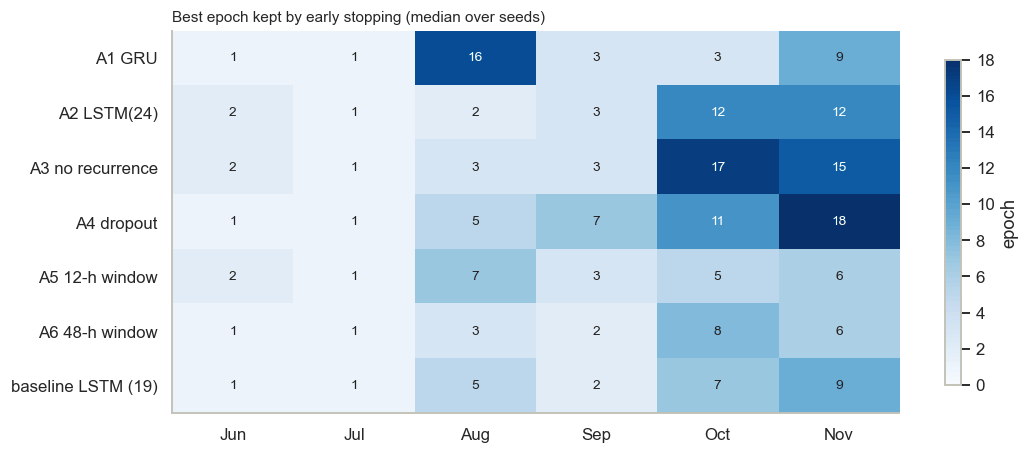

In [127]:
# --- Figure: the best epoch early stopping kept -------------------------------------------------
fg_best = pd.Series({k: float(np.median(v)) for k, v in best.items()}).unstack(0)[M]
fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(fg_best.to_numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=max(12, fg_best.to_numpy().max()))
for (i, j), v in np.ndenumerate(fg_best.to_numpy()):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white" if v > 10 else "#222")
ax.set_xticks(range(len(M)), M); ax.set_yticks(range(len(fg_best.index)), fg_best.index)
ax.set_title("Best epoch kept by early stopping (median over seeds)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.85, label="epoch")
plt.tight_layout(); plt.show()

## 22g. Months nothing was tuned on: January to March 2020

The reviewer suggested this check after seeing the confirmation results. The prediction was
written down and frozen before any network was trained for these months: the blend beats the bag
on the mean of section 21d's 8 clean array-months, and in at least 5 of the 8. The check is
descriptive only. The GRU and the bag are each refitted per month on data before it; no
corrections apply before June.

In [128]:
# --- 22g. Months nothing was tuned on: January to March 2020 (prediction frozen first) ---
def _janmar22():
    rows = {}
    for mon, win in PRE21.items():
        tr = train_day[train_day.index < win[0]]; caps = cap_of(tr)
        frame = month_frame(win)
        bag = np.mean([clean_pred(frame, fit_hgb(tr, caps, seed=s)(frame)) for s in range(5)], axis=0)
        r, mask, caps2 = ratio_inputs_ref(win[0], (), ref_linear)
        n3, _ = train_arch("GRU", seq_tr, stat_tr, r, mask, f"v22-GRU-{mon}-none")
        n2, _ = train_arch("GRU", seq_tr, stat_tr, r, mask, f"v22-GRU-{mon}-none-s34", seeds=(3, 4))
        _, _, ok = build_inputs(frame)
        assert ok.all(), f"{mon}: rows without a full input window would halve the blend"
        gru = clean_pred(frame, predict_with(n3 + n2, build_inputs, ALL, ref_linear, caps2)(frame))
        for lab, p in (("HGB bag", bag), ("GRU, 5 seeds", gru), ("GRU + HGB bag", (bag + gru) / 2)):
            s = score_vec(frame, p, win, CLEAN21[mon])
            for a in CLEAN21[mon]:
                rows[(mon, a, lab)] = s[a]
    return rows


jm = pd.Series(cached("janmar_22", _janmar22)).unstack(2)[["HGB bag", "GRU, 5 seeds", "GRU + HGB bag"]]
display(jm.round(4).rename_axis(["month", "array"]))
k = int((jm["GRU + HGB bag"] < jm["HGB bag"]).sum())
print(f"mean over the 8 clean array-months: bag {jm['HGB bag'].mean():.4f}, GRU {jm['GRU, 5 seeds'].mean():.4f}, "
      f"blend {jm['GRU + HGB bag'].mean():.4f}")
print(f"blend beats the bag in {k}/8 array-months; GRU alone in {int((jm['GRU, 5 seeds'] < jm['HGB bag']).sum())}/8")
guaranteed = jm.index[jm["GRU, 5 seeds"] < jm["HGB bag"]].tolist()
print("array-months where the GRU alone beats the bag (blend win guaranteed):", guaranteed)
print("blend's margin over the bag:", (jm["HGB bag"] - jm["GRU + HGB bag"]).round(4).to_dict())
print(f"averaging bound over the 8: {(jm['HGB bag'].mean() + jm['GRU, 5 seeds'].mean()) / 2:.4f}")
print("frozen prediction (blend mean below the bag's AND at least 5 of 8):",
      bool(jm["GRU + HGB bag"].mean() < jm["HGB bag"].mean() and k >= 5))

  [cache] loaded janmar_22


HGB bag  GRU, 5 seeds  GRU + HGB bag
month array                                       
Feb   Solar1   0.8796        0.8316         0.8438
      Solar2   0.7675        0.7503         0.7475
      Solar4   0.7442        0.7454         0.7348
Jan   Solar1   0.8550        0.8706         0.8453
      Solar2   0.7759        0.8168         0.7767
      Solar4   0.7248        0.7597         0.7261
Mar   Solar2   0.5746        0.6402         0.5875
      Solar4   0.5833        0.5638         0.5601

mean over the 8 clean array-months: bag 0.7381, GRU 0.7473, blend 0.7277
blend beats the bag in 5/8 array-months; GRU alone in 3/8
array-months where the GRU alone beats the bag (blend win guaranteed): [('Feb', 'Solar1'), ('Feb', 'Solar2'), ('Mar', 'Solar4')]
blend's margin over the bag: {('Feb', 'Solar1'): 0.0358, ('Feb', 'Solar2'): 0.02, ('Feb', 'Solar4'): 0.0094, ('Jan', 'Solar1'): 0.0096, ('Jan', 'Solar2'): -0.0008, ('Jan', 'Solar4'): -0.0013, ('Mar', 'Solar2'): -0.0129, ('Mar', 'Solar4'): 0.0232}
averaging bound over the 8: 0.7427
frozen prediction (blend mean below the bag's AND at least 5 of 8): True


**Figure.** January to March 2020: the bag, the GRU and their blend on each clean array-month.

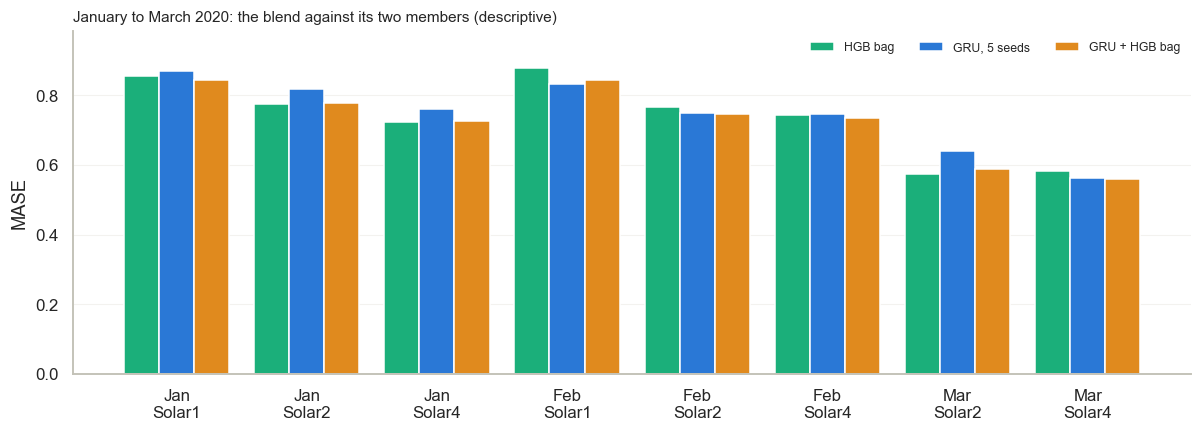

In [129]:
# --- Figure: section 22g, array-month by array-month -------------------------------------------
fg_cols = ["HGB bag", "GRU, 5 seeds", "GRU + HGB bag"]
jm_o = jm.loc[[(m, a) for m in ("Jan", "Feb", "Mar") for a in CLEAN21[m]]]
fg_col = {"HGB bag": "#1baf7a", "GRU, 5 seeds": "#2a78d6", "GRU + HGB bag": "#e08a1e"}
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(jm_o)); w = 0.27
for k, c in enumerate(fg_cols):
    ax.bar(x + (k - 1) * w, jm_o[c], w, color=fg_col[c], label=c)
ax.set_xticks(x, [f"{m}\n{a}" for m, a in jm_o.index]); ax.set_ylabel("MASE")
ax.set_ylim(0, jm_o[fg_cols].max().max() * 1.12)
ax.set_title("January to March 2020: the blend against its two members (descriptive)", loc="left")
ax.legend(fontsize=8, ncol=3, loc="upper right"); ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 22

**The GRU is adopted, and it is the first architecture change in this notebook to survive a
confirmation stage.**

- At three seeds it scored 0.5362, against the baseline's 0.5646.
- At five seeds it scores 0.5343, against 0.5649 for the five-seed baseline. It is better in five
  of six months and in 30 of 36 array-months (one-sided p < 0.0001).
- All five GRU seeds (0.5396–0.5570) beat all five baseline seeds (0.5653–0.5921; 22d). That
  includes the two new GRU seeds, which played no part in selecting it, against the baseline's own
  two new seeds (0.5873 and 0.5816).
- The code-path control rules out an artefact: retraining the baseline through this section's
  training function reproduces the cached network exactly (largest difference 0.0000 kW).

**Two others passed at three seeds, and the confirmation stage separated them.**

- **LSTM(24) was also confirmed** (0.5476; 4 of 6 months; 27 of 36 array-months, p = 0.002) but
  not adopted, since its mean is higher. It passed at the ensemble level only: its seeds range
  from 0.5456 to 0.6016, and one of them is worse than every baseline seed.
- **The 12-hour window lost its exploratory pass at five seeds.** Its month count fell from 4 to
  3, even though its p-value moved from 0.31 to 0.20. Catching that kind of fragile pass is what
  the confirmation stage was for.
- No recurrence, dropout and the 48-hour window all failed.

**How the predictions scored.** Two failed because this notebook's priors were wrong:

- The GRU was predicted to tie the LSTM (|Δ| ≤ 0.005). It was better by 0.028.
- The no-recurrence network was predicted to lose by more than 0.01. It was *better*, by 0.008.

Four held:

- LSTM(24) held all three parts of its scarce-data prediction, with the largest Solar0 gain of
  any variant (+0.145 over June to September).
- Dropout held its mechanism prediction (a gain concentrated in June to August and on Solar0)
  but failed the decision rule.
- The 12-hour and 48-hour windows held theirs. The 48-hour window's Solar0 Δ (−0.006) was the
  only negative one.

**The window ladder is flat for this LSTM.** Windows of 1, 12, 24 and 48 hours score 0.5568,
0.5561, 0.5646 and 0.5633 over six months, which is no measurable difference under this training
regime. So the prior that the weather *sequence* matters is falsified for this LSTM. But that does
not extend to sequence models in general: the GRU beats the no-recurrence network by 0.021 (an
unplanned comparison).

**Why the GRU wins is not established. A partial explanation is how early stopping behaves.**

- In June and July, every network, the baseline included, keeps its weights from epochs 1 to 3.
  The validation window (the last tenth of each training period) never improves after that,
  most likely because it differs from the rest of the training data: the cleaned April–May gap,
  Solar3's changeover and Solar0's new data all fall there.
- In those months the comparison is largely about what each architecture learns in its first
  few epochs, and a GRU may simply learn faster.
- From August to November the GRU sometimes trains much longer (best epochs as late as 16, 21
  and 22), so learning speed is at best part of the story.
- A different validation split or a fixed epoch budget would test this. That would need its own
  pre-registered section.

**The pre-registered blend passes: GRU + bagged boosting scores 0.5253, against 0.5327 for the
bag.**

- It is better in 4 of 6 months and in 27 of 36 array-months (one-sided p = 0.0020, under the
  0.05/6 threshold).
- Section 23 treats sections 22 and 23 as one family, with a stricter threshold of p < 0.05/9 =
  0.0056. Every section 22 verdict survives that too: the GRU (0.0020 at three seeds, below
  0.0001 at five), LSTM(24)'s confirmation (0.0020) and the blend (0.0020).
- The averaging bound, (0.5343 + 0.5327)/2 = 0.5335, sits *above* the bag. So beating the bag
  over six months was not guaranteed: the blend needed 0.0008 of diversity gain and got 0.0082.
- It survives all four scoring settings of section 21e, with the same month and array-month
  counts every time.

**Read that result with its caveats:**

- **Most of the gain is November.** November supplies about 82% of it (0.5691 against 0.6053).
  Over the other five months the blend beats the bag by only 0.0016 (0.5166 against 0.5182).
- **Two of its four winning months were guaranteed.** The GRU alone beats the bag in June and
  November, so the blend was bound to win those two. Of the other two, September is won by 0.0006
  and October by 0.0081.
- **The months are not fresh.** The blend is the end of a chain of choices made on these same six
  months: the corrections, the target, the loss, the bagging and now the architecture. Each step
  was controlled on its own, but the chain as a whole was not.
- **It costs five GRUs per month**, where section 19's boosting needed no neural network.

**The one test on months nothing was tuned on (22g, descriptive only).** January to March 2020
were never used to choose anything. The reviewer suggested the check, and the prediction was
written down and frozen before any network was trained for these months: the blend beats the bag
on the mean of the 8 clean array-months, *and* in at least 5 of the 8. **It held, but only just,
and it needs the same caveats as the backtest.** The blend scores 0.7277 against the bag's 0.7381
and wins exactly 5 of 8, the frozen threshold.

- Three of those five wins were guaranteed: the GRU alone already beats the bag in those three
  array-months.
- The two that were earned are by 0.0094 and 0.0096.
- Two of the losses are tiny (0.0008 and 0.0013).
- The *mean* win was not guaranteed. The averaging bound over the 8 is 0.7427, above the bag, so
  the blend's 0.7277 shows a real diversity gain of about 0.015.

The GRU on its own does not beat the bag there (0.7473; better in 3 of 8). So the gain again
comes from combining the two models rather than from the GRU itself. Eight array-months cannot
decide anything, and in January and February all five boosting seeds are identical (early
stopping is off below 10,000 rows). But this is the only evidence from months no choice was made
on, and it points the same way.

**The recommendation as of this section.** *Superseded in section 25: the F1 bag is now recommended.*
The blend of the five-seed GRU and the bagged boosting model is the best performer **on these
six months under a pre-registered sequence of tests**, at 0.5253. That is
not the same as "best model". The bagged boosting model alone (0.5327) remains the simpler
choice, and is only 0.0074 behind.

---

# 23. The literature's networks: CNN-LSTM, CNN-biLSTM and a dilated causal CNN

The literature review (section 6) cites a comparison of eight architectures for solar power
prediction. It found that "hybrid CNN-based models outperform individual architectures, with
CNN-LSTM and CNN-biLSTM leading", and that temporal convolutional networks are "competitive,
cheaper than recurrent models". None of these has been tried here. The notebook tested a CNN
alone (section 12) and an LSTM + CNN *blend* (section 14), never a convolution feeding an LSTM.

**Why the literature's result may not carry over.** Those studies forecast hours ahead with
*past solar output* among their inputs, and that is where a convolution's local-pattern
extraction pays off. This notebook forecasts a month ahead from weather and its recent history
alone, so the mechanism has less to act on. That was written down before running, whatever the
result.

**This plan was reviewed and frozen, with file hashes, before any section 23 network was
trained.** Section 22's June scores had been seen at that point, and nothing else from
section 22. Section 22's results do not change this plan.

The setup follows section 22 exactly: same months, corrected data, ratio target, 24-hour window,
schedule, callbacks, static branch and head, and a 3-seed ensemble. The baseline is again the
corrected LSTM (0.5646). Parameter counts are matched so that a gain cannot come from extra
capacity.

| # | Architecture | Parameters (sequence part) |
|---|---|---|
| baseline | LSTM(48) | 10,752 |
| L1 | Conv1D(32, kernel 3, causal) → LSTM(36) | 10,640 |
| L2 | Conv1D(32, kernel 3, causal) → Bidirectional(LSTM(24)) | 11,648 |
| L3 | a dilated causal CNN: five Conv1D(32, kernel 2) layers with dilations 1, 2, 4, 8, 16, then the last step | about 8,800 |

L3 is a plain dilated stack, not a full temporal convolutional network, which would add
residual blocks and normalisation. Its receptive field (32 hours) is wider than the 24-hour
window, so its first steps see zero padding.

**Predictions** (Δ = baseline minus variant six-month mean; positive means the variant is
better). The bins are disjoint:

| # | The literature predicts | This notebook's prior (sections 14, 20) predicts |
|---|---|---|
| L1, L2 | Δ > +0.005 | \|Δ\| ≤ 0.005 |
| L3 | Δ ≥ −0.005 (competitive), with fewer parameters **and** less training time than the baseline | — |

A Δ outside every bin supports neither.

**Decision rule.** Sections 22 and 23 test nine variants against the same baseline, so they
are treated as one family. The sign test uses p < 0.05/9 (at least 27 of 36 array-months), and
the rest of the rule is unchanged: a better six-month mean and at least four of six months.
Section 22's confirmation stage and single pre-registered blend apply here too.

In [130]:
# --- 23a. The literature's networks, trained on every backtest month ------------------
def make_lit(kind, seed, steps, n_static):
    """The literature's hybrids and a dilated causal CNN, with 13a's static branch and head."""
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(steps, len(SEQ_FEATURES)))
    t_in = keras.Input(shape=(n_static,))
    if kind == "cnnlstm":                                # LSTM(36): parameter-matched to the baseline
        x = layers.LSTM(36)(layers.Conv1D(32, 3, padding="causal", activation="relu")(s_in))
    elif kind == "cnnbilstm":
        x = layers.Bidirectional(layers.LSTM(24))(layers.Conv1D(32, 3, padding="causal", activation="relu")(s_in))
    elif kind == "tcn":
        h = s_in
        for d in (1, 2, 4, 8, 16):                       # receptive field 32 h >= the 24-h window
            h = layers.Conv1D(32, 2, dilation_rate=d, padding="causal", activation="relu")(h)
        x = layers.Flatten()(layers.Cropping1D((steps - 1, 0))(h))   # the last step
    else:
        raise ValueError(kind)
    z = layers.Concatenate()([x, layers.Dense(32, activation="relu")(t_in)])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
    return m


def train_lit(kind, y, mask, tag, seeds=(0, 1, 2)):
    """train_seeds (13a): same split, schedule and callbacks; records training time."""
    s_, t_, y_ = seq_tr[mask], stat_tr[mask], y[mask].astype("float32")
    cut = int(len(y_) * 0.9)

    def _fit():
        nets, hists = [], []
        for s in seeds:
            m = make_lit(kind, s, s_.shape[1], t_.shape[1])
            t0 = time.time()
            h = m.fit([s_[:cut], t_[:cut]], y_[:cut], validation_data=([s_[cut:], t_[cut:]], y_[cut:]),
                      epochs=150, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
            h.history["fit_seconds"] = [time.time() - t0]
            nets.append(m); hists.append(h.history)
        return nets, hists
    return cached_nets(f"seeds_{tag}", _fit)


LIT = {"L1 CNN-LSTM": "cnnlstm", "L2 CNN-biLSTM": "cnnbilstm", "L3 dilated causal CNN": "tcn"}
PRED23, SEEDP23, HIST23 = {}, {}, {}
for mon, win in FOLDS.items():
    arrays = FIXED[mon]
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    frame, cols = FRAME21[mon], {}
    for name, kind in LIT.items():
        nets, hists = train_lit(kind, r, mask, f"v23-{kind}-{mon}-{'-'.join(arrays) or 'none'}")
        HIST23[(mon, name)] = [(len(h["loss"]), h["fit_seconds"][0]) for h in hists]
        SEEDP23[(mon, name)] = [clean_pred(frame, predict_with([m], build_inputs, ALL, ref_linear, caps)(frame))
                                for m in nets]
        cols[name] = np.mean(SEEDP23[(mon, name)], axis=0)
    PRED23[mon] = pd.DataFrame(cols, index=frame.index)

# the baseline's training times were never recorded, so they are re-measured once on one fold
def _base_secs():
    r, mask, caps = ratio_inputs_ref(FOLDS["Nov"][0], FIXED["Nov"], ref_linear)
    s_, t_, y_ = seq_tr[mask], stat_tr[mask], r[mask]; cut = int(len(y_) * 0.9)
    secs = []
    for s in (0, 1, 2):
        m = make_lstm(s); t0 = time.time()
        m.fit([s_[:cut], t_[:cut]], y_[:cut], validation_data=([s_[cut:], t_[cut:]], y_[cut:]), epochs=150,
              batch_size=256, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                         keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
        secs.append(time.time() - t0)
    return secs


base_secs = cached("baseline_seconds_23", _base_secs)
cost = pd.DataFrame({
    "parameters": {**{"baseline LSTM(48)": make_lstm(0).count_params()},
                   **{n: make_lit(k, 0, WINDOW, len(STATIC_FEATURES)).count_params() for n, k in LIT.items()}},
    "mean seconds per network (November fold)": {**{"baseline LSTM(48)": np.mean(base_secs)},
                                                 **{n: np.mean([t for _, t in HIST23[("Nov", n)]]) for n in LIT}},
})
display(cost.round(1))

  [cache] loaded seeds_v23-cnnlstm-Jun-none (3 networks)


  [cache] loaded seeds_v23-cnnbilstm-Jun-none (3 networks)


  [cache] loaded seeds_v23-tcn-Jun-none (3 networks)


  [cache] loaded seeds_v23-cnnlstm-Jul-Solar3 (3 networks)


  [cache] loaded seeds_v23-cnnbilstm-Jul-Solar3 (3 networks)


...

  [cache] loaded seeds_v23-tcn-Oct-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v23-cnnlstm-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v23-cnnbilstm-Nov-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v23-tcn-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded baseline_seconds_23


,parameters,mean seconds per network (November fold)
baseline LSTM(48),13697,15.0
L1 CNN-LSTM,13201,14.6
L2 CNN-biLSTM,14593,20.4
L3 dilated causal CNN,11233,7.8


## 23b. The verdicts, and which prediction held

In [131]:
# --- 23b. The verdicts, and how each prediction scored -------------------------------
NAMES23 = list(LIT)
e23 = pd.DataFrame({**{(mon, BASE22): score_vec(FRAME21[mon], PRED21[mon]["LSTM"], FOLDS[mon]) for mon in M},
                    **{(mon, n): score_vec(FRAME21[mon], PRED23[mon][n], FOLDS[mon]) for mon in M for n in NAMES23}}).T
tab23m = e23[SOLAR].mean(axis=1).unstack(0)[M].loc[[BASE22] + NAMES23]
tab23 = tab23m.copy()
tab23["6-month mean"] = tab23m.mean(axis=1)
tab23["months beating baseline"] = [int((tab23m.loc[n] < tab23m.loc[BASE22]).sum()) for n in tab23m.index]
b23 = e23.xs(BASE22, level=1)[SOLAR]
kn = [(int(((b23 - e23.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum()), b23.size) for n in tab23m.index]
tab23["array-months beating baseline"] = [f"{k}/{m}" for k, m in kn]
tab23["one-sided sign p"] = [binomtest(k, m, 0.5, alternative="greater").pvalue for k, m in kn]
BONF23 = 0.05 / 9                                   # sections 22 and 23 are one family of nine


def verdict23(n, r):
    if n == BASE22:
        return "baseline"
    if not (r["6-month mean"] < tab23.loc[BASE22, "6-month mean"] and r["months beating baseline"] >= 4):
        return "fail"
    return "pass -> confirm" if r["one-sided sign p"] < BONF23 else "exploratory pass -> confirm"


tab23["verdict (3 seeds)"] = [verdict23(n, r) for n, r in tab23.iterrows()]
display(tab23.round(4))
print(f"Bonferroni over the nine variants of sections 22-23: p < {BONF23:.4f}")

d23 = tab23.loc[BASE22, "6-month mean"] - tab23["6-month mean"]


def bin23(n):
    d = d23[n]
    if n.startswith("L3"):
        cheaper = (cost.loc[n, "parameters"] < cost.loc["baseline LSTM(48)", "parameters"]
                   and cost.loc[n, "mean seconds per network (November fold)"]
                   < cost.loc["baseline LSTM(48)", "mean seconds per network (November fold)"])
        return f"competitive: {d >= -0.005}; cheaper: {cheaper}"
    if d > 0.005:
        return "literature (delta > +0.005)"
    if abs(d) <= 0.005:
        return "notebook prior (|delta| <= 0.005)"
    return "neither"


display(pd.DataFrame({"delta, 6-month (positive = variant better)": d23[NAMES23],
                      "which prediction held": [bin23(n) for n in NAMES23]}).round(4))

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating baseline,array-months beating baseline,one-sided sign p,verdict (3 seeds)
baseline LSTM (19),0.4696,0.4400,0.6686,0.6113,0.5946,0.6034,0.5646,0,0/36,1.0000,baseline
L1 CNN-LSTM,0.4381,0.4201,0.6441,0.5789,0.6205,0.6007,0.5504,5,20/36,0.3089,exploratory pass -> confirm
L2 CNN-biLSTM,0.5732,0.4302,0.6744,0.5963,0.6393,0.6170,0.5884,2,10/36,0.9980,fail
L3 dilated causal CNN,0.4693,0.4462,0.6640,0.5971,0.6335,0.6429,0.5755,3,10/36,0.9980,fail


Bonferroni over the nine variants of sections 22-23: p < 0.0056


,"delta, 6-month (positive = variant better)",which prediction held
L1 CNN-LSTM,0.0142,literature (delta > +0.005)
L2 CNN-biLSTM,-0.0238,neither
L3 dilated causal CNN,-0.0109,competitive: False; cheaper: True


**Figure.** Each literature network's gain over the baseline LSTM, month by month (three-seed ensembles).

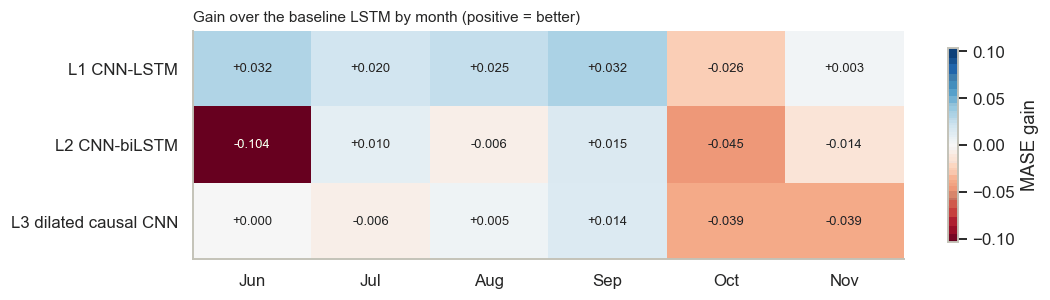

In [132]:
# --- Figure: section 23's gains over the baseline, by month ------------------------------------
fg_gain = (tab23m.loc[BASE22] - tab23m.loc[NAMES23])
fig, ax = plt.subplots(figsize=(10, 2.8))
fg_lim = np.abs(fg_gain.to_numpy()).max()
im = ax.imshow(fg_gain.to_numpy(), cmap="RdBu", vmin=-fg_lim, vmax=fg_lim, aspect="auto")
for (i, j), v in np.ndenumerate(fg_gain.to_numpy()):
    ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8.5,
            color="white" if abs(v) > 0.6 * fg_lim else "#222")
ax.set_xticks(range(len(M)), M); ax.set_yticks(range(len(NAMES23)), NAMES23)
ax.set_title("Gain over the baseline LSTM by month (positive = better)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.85, label="MASE gain")
plt.tight_layout(); plt.show()

## 23c. Seed by seed, alongside section 22

Every LSTM-family variant from sections 22 and 23 on one axis. Each dot is one network's
six-month mean, and each diamond is a 3-seed ensemble. The shaded band is the baseline's own
seed-to-seed range.

,seed 0,seed 1,seed 2,worst seed beats the baseline's best
"six-month mean MASE of each single seed, sections 22 and 23",,,,
baseline LSTM (19),0.5787,0.5653,0.5921,False
A1 GRU,0.5448,0.5463,0.5570,True
A2 LSTM(24),0.5548,0.5456,0.6016,False
A3 no recurrence,0.5611,0.5783,0.5700,False
A4 dropout,0.5725,0.5620,0.5735,False
A5 12-h window,0.5658,0.5551,0.5903,False
A6 48-h window,0.5807,0.5647,0.5944,False
L1 CNN-LSTM,0.5573,0.5680,0.5766,False
L2 CNN-biLSTM,0.6217,0.6059,0.5815,False


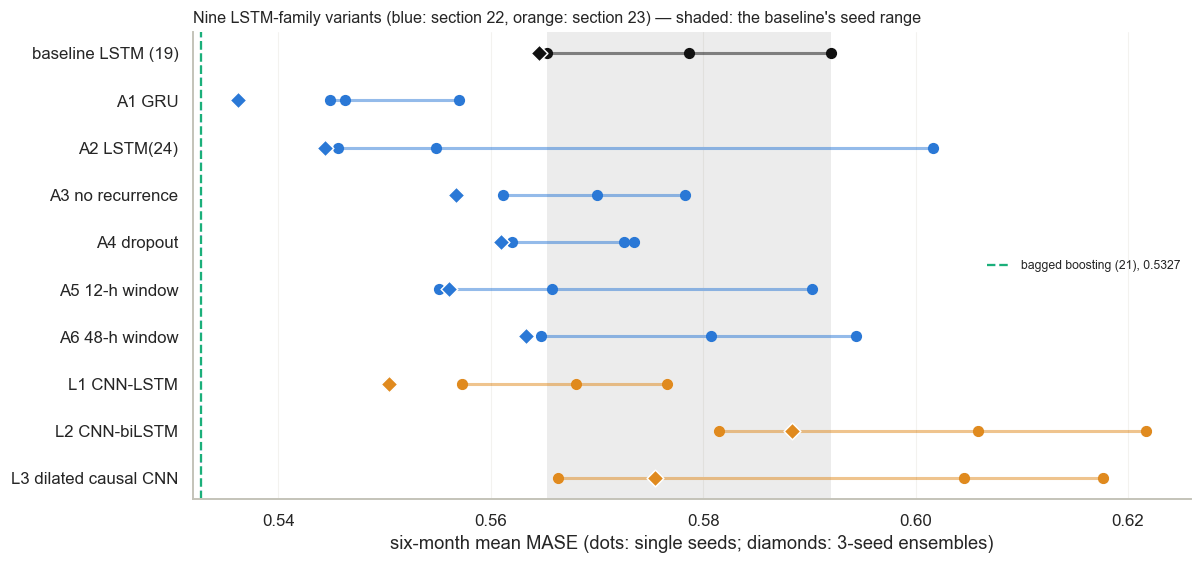

In [133]:
# --- 23c. Seed by seed, alongside section 22 ----------------------------------------------
seed23 = {n: np.mean([[score_vec(FRAME21[mon], p, FOLDS[mon]).mean() for p in SEEDP23[(mon, n)]] for mon in M],
                     axis=0) for n in NAMES23}
st23 = pd.concat([st22.drop(columns="worst seed beats the baseline's best"),
                  pd.DataFrame(seed23, index=["seed 0", "seed 1", "seed 2"]).T])
st23["worst seed beats the baseline's best"] = st23.max(axis=1) < st23.loc[BASE22].min()
display(st23.round(4).rename_axis("six-month mean MASE of each single seed, sections 22 and 23"))

ens_all = pd.concat([tab22["6-month mean"], tab23["6-month mean"].drop(BASE22)])
order = [BASE22] + NAMES22 + NAMES23
fig, ax = plt.subplots(figsize=(11, 5.2))
for i, n in enumerate(order):
    v = st23.loc[n, ["seed 0", "seed 1", "seed 2"]].to_numpy(dtype=float)
    col = "#111111" if n == BASE22 else ("#e08a1e" if n in NAMES23 else "#2a78d6")
    ax.plot([v.min(), v.max()], [i, i], color=col, lw=2, alpha=0.5)
    ax.scatter(v, [i] * 3, color=col, s=40, zorder=3)
    ax.scatter(ens_all[n], i, marker="D", color=col, edgecolor="white", s=60, zorder=4)
lo, hi = st23.loc[BASE22, ["seed 0", "seed 1", "seed 2"]].min(), st23.loc[BASE22, ["seed 0", "seed 1", "seed 2"]].max()
ax.axvspan(lo, hi, color="#111", alpha=0.08, lw=0)
bag = tab21.loc["E4 HGB, 5-seed bag", "6-month mean"]
ax.axvline(bag, color="#1baf7a", ls="--", lw=1.5, label=f"bagged boosting (21), {bag:.4f}")
ax.set_yticks(range(len(order)), order); ax.invert_yaxis()
ax.set_xlabel("six-month mean MASE (dots: single seeds; diamonds: 3-seed ensembles)")
ax.set_title("Nine LSTM-family variants (blue: section 22, orange: section 23) — shaded: the baseline's seed range",
             loc="left", fontsize=10.5)
ax.legend(fontsize=8, loc="center right"); ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 23d. Confirmation at five seeds

As in section 22d, every variant that passed or exploratory-passed gets seeds 3 and 4 and faces
the rule again against the five-seed baseline, now at section 23's threshold (p < 0.05/9). If a
variant is confirmed, the one pre-registered blend with the bagged boosting model follows.

In [134]:
# --- 23d. Confirmation at five seeds ------------------------------------------------------
to_confirm23 = [n for n in NAMES23 if tab23.loc[n, "verdict (3 seeds)"] != "fail"]
print("confirming:", to_confirm23)
if to_confirm23:
    P23 = {}
    for mon, win in FOLDS.items():
        arrays = FIXED[mon]; tag_a = "-".join(arrays) or "none"
        r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
        frame = FRAME21[mon]
        P23[(mon, "baseline, 5 seeds")] = C22[(mon, "baseline, 5 seeds")]        # section 22d's baseline
        for n in to_confirm23:
            kind = LIT[n]
            n3, _ = train_lit(kind, r, mask, f"v23-{kind}-{mon}-{tag_a}")
            n2, _ = train_lit(kind, r, mask, f"v23-{kind}-{mon}-{tag_a}-s34", seeds=(3, 4))
            P23[(mon, n)] = clean_pred(frame, predict_with(n3 + n2, build_inputs, ALL, ref_linear, caps)(frame))
            P23[(mon, n, "seeds")] = [clean_pred(frame, predict_with([m], build_inputs, ALL, ref_linear, caps)(frame))
                                      for m in n3 + n2]
    rows = ["baseline, 5 seeds"] + to_confirm23
    ce = pd.DataFrame({(mon, n): score_vec(FRAME21[mon], P23[(mon, n)], FOLDS[mon]) for mon in M for n in rows}).T
    ct = ce[SOLAR].mean(axis=1).unstack(0)[M].loc[rows]
    conf23 = ct.copy()
    conf23["6-month mean"] = ct.mean(axis=1)
    conf23["months beating baseline"] = [int((ct.loc[n] < ct.loc["baseline, 5 seeds"]).sum()) for n in rows]
    b5 = ce.xs("baseline, 5 seeds", level=1)[SOLAR]
    kn5 = [(int(((b5 - ce.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum()), b5.size) for n in rows]
    conf23["array-months beating baseline"] = [f"{k}/{m}" for k, m in kn5]
    conf23["one-sided sign p"] = [binomtest(k, m, 0.5, alternative="greater").pvalue for k, m in kn5]
    b5m = conf23.loc["baseline, 5 seeds", "6-month mean"]
    conf23["confirmed (p < 0.05/9)"] = [n != "baseline, 5 seeds" and r["6-month mean"] < b5m
                                        and r["months beating baseline"] >= 4 and r["one-sided sign p"] < BONF23
                                        for n, r in conf23.iterrows()]
    display(conf23.round(4).rename_axis("confirmation at five seeds"))
    display(pd.DataFrame({n: [np.mean([score_vec(FRAME21[mon], P23[(mon, n, "seeds")][s], FOLDS[mon]).mean()
                                       for mon in M]) for s in range(5)] for n in to_confirm23},
                         index=[f"seed {s}" for s in range(5)]).T.round(4).rename_axis("six-month mean of each seed"))
    confirmed23 = [n for n in to_confirm23 if conf23.loc[n, "confirmed (p < 0.05/9)"]]
    print("confirmed:", confirmed23 or "none - no variant is adopted and the pre-registered blend does not run")

confirming: ['L1 CNN-LSTM']
  [cache] loaded seeds_v23-cnnlstm-Jun-none (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Jun-none-s34 (2 networks)


  [cache] loaded seeds_v23-cnnlstm-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Jul-Solar3-s34 (2 networks)


  [cache] loaded seeds_v23-cnnlstm-Aug-Solar3 (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Aug-Solar3-s34 (2 networks)


  [cache] loaded seeds_v23-cnnlstm-Sep-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Sep-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v23-cnnlstm-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Oct-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v23-cnnlstm-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v23-cnnlstm-Nov-Solar3-Solar0-s34 (2 networks)


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating baseline,array-months beating baseline,one-sided sign p,confirmed (p < 0.05/9)
confirmation at five seeds,,,,,,,,,,,
"baseline, 5 seeds",0.4739,0.4470,0.6592,0.6233,0.5965,0.5898,0.5649,0,0/36,1.0000,False
L1 CNN-LSTM,0.4445,0.4303,0.6322,0.5899,0.6099,0.5881,0.5491,5,25/36,0.0144,False


,seed 0,seed 1,seed 2,seed 3,seed 4
six-month mean of each seed,,,,,
L1 CNN-LSTM,0.5573,0.568,0.5766,0.5603,0.5767


confirmed: none - no variant is adopted and the pre-registered blend does not run


### Reading 23

**None of the literature's networks is adopted.**

| Network | 3 seeds | 5 seeds | Verdict |
|---|---|---|---|
| L1 CNN-LSTM | 0.5504; 5 of 6 months; 20/36 (p = 0.31) | 0.5491; 5 of 6 months; 25/36 (p = 0.014) | not confirmed: misses p < 0.0056 |
| L2 CNN-biLSTM | 0.5884 | — | fails: worse than the baseline by 0.024 |
| L3 dilated causal CNN | 0.5755 | — | fails: worse by 0.011 |

The baseline is 0.5646 at three seeds and 0.5649 at five.

- **The CNN-LSTM points the literature's way, but it is not confirmed.** At three seeds it beats
  the baseline by more than 0.005 (Δ = +0.0142), the literature's bin. At five seeds it still wins
  five of six months, but its sign test (p = 0.014) misses the threshold. It would miss section
  22's threshold too (0.0083), so the choice to treat sections 22 and 23 as one family made no
  difference. Its seeds (0.5573–0.5767) overlap the baseline's (0.5653–0.5921). So this neither
  confirms nor refutes the literature, and no blend is run.
- **The literature's ranking is not reproduced.** Its top model, the CNN-biLSTM, is 0.024 *worse*
  than the baseline and falls in neither prediction bin. Its June score (0.5732, against the
  baseline's 0.4696) accounts for much of that. It is another fragile June fit, like the centred
  window's 0.626 in section 20.
- **The dilated causal CNN: "cheaper" held, "competitive" failed.** It uses 11,233 parameters
  against the baseline's 13,697, and trains in 7.8 seconds per network against 15.0 on the
  November fold. But at Δ = −0.0109 it misses the "competitive" bar of −0.005.
- **The GRU is still ahead** (descriptive only, not part of the frozen plan). Its three-seed score
  of 0.5362 is below every section 23 network; the best of them, the CNN-LSTM, scores 0.5504.

**Why the literature's result does not transfer here.** This was flagged before anything ran.
Those studies forecast hours ahead from *past solar output*, and that history is where a
convolution's local-pattern extraction pays off. Here the forecast is a month ahead from weather
alone, and section 22's no-recurrence network matched the 24-hour LSTM. So the weather history
gives a convolution little to extract. The networks were also judged under section 22's
training regime, where most folds keep weights from the first few epochs, so these verdicts are
about *this architecture under this harness*, not about its merit when fully trained.

**On the frozen tie-break gap.** The frozen rules applied section 22's blend to section 23 too,
without saying which blend would win if both passed. No section 23 network was confirmed, so the
question never arose. Replacing section 22's blend would in any case have needed its own
pre-registered head-to-head.

**Across sections 22 and 23**, nine changes were tested against the same LSTM. Two were confirmed
at five seeds, the GRU and LSTM(24), and only the GRU was adopted.

---

# 24. The competition winner's features: leading and lagging weather

Bean (2022) won the forecasting part of the IEEE-CIS challenge on this exact dataset, and the
literature review (section 7) read his paper in full. He reports that "temperature and solar
(leading and lagging) were the most critical predictor variables", and he also used cloud cover
at ±3 hours.

Section 10's features include radiation lagged by 1–3 hours and a 3-hour rolling mean, but
**no leading weather at all**. Section 11's pruning also dropped `temperature` itself
(permutation importance 0.002). So Bean's claim has not been tested here, and it applies to the
**recommended model**, the bagged boosting from section 21, not just the LSTM.

**This plan was reviewed and frozen, with file hashes, before any section 24 model was fitted.**

**Features.** They are built by absolute time, so daylight-saving changes are handled, from the
hourly ERA5 table that cell 57 already shifts onto the hour it describes.

- **Leads.** "+1 h" is the next hour. Using leading weather relies on the notebook's standing
  assumption that the month's weather is known, since ERA5 is treated as a perfect forecast
  (literature review, section 3). Leads that would run past the end of the data on
  1 December 2020 repeat the last available hour, so no scored row is lost. The code asserts
  that the scored rows match section 21 exactly.
- **Instantaneous variables.** Cell 57 applies the same shift to temperature and cloud, so
  "temperature at 0 h" and "cloud at ±3 h" are the values at the *end* of the labelled hour.
- **What is left out.** Bean's day-of-year Fourier terms are not added. With under two years of
  data they would mostly learn the dates of the Solar3 and Solar0 regime changes.
- **No direct comparison with Bean.** His MASE of 0.5166 used a different mix of series and
  different scoring, so it is not comparable with the numbers here.

**A nested ladder**, so that each step can be credited separately. Each is the section 21 bag
(five seeds, absolute-error loss, corrected ratio target), refitted per backtest month with
extra columns.

| # | Adds to section 11's feature list | Prediction |
|---|---|---|
| T0 | temperature at 0 h only (was §11 wrong to prune it?) | Δ > +0.005 |
| F1 | radiation leads at +1, +2, +3 h | Δ > +0.005 |
| F1+T | F1, plus temperature at 0 h and ±1..3 h | Δ > +0.005 |
| F2 | Bean's full set: F1+T, plus radiation lags at 1–3 h (lag 3 had been pruned), plus cloud cover at ±3 h | Δ > +0.005 |

Δ = the bag's six-month mean (0.5327) minus the variant's; positive means better.

**Decision rule.** This is section 21's rule, with Bonferroni over 4 (p < 0.0125). Both sides
are five-seed bags, so seed noise is small; the single-seed spread is reported anyway. The step
from one rung to the next is described but not tested.

**An alignment diagnostic, used for no decision.** A gain from F1 could come from Bean's
mechanism, weather moving in over the next few hours. It could also be a timing correction,
since ERA5 smooths over a 31 km cell and its instantaneous variables sit at the end of the hour.
The permutation importance of each lead column is computed on each test month. If +1 h carries
most of it, the gain reads as alignment; if +2 h and +3 h matter, it reads as weather dynamics.

In [135]:
# --- 24a. Leading and lagging weather, and the bagged boosting refitted with it ---------
from sklearn.inspection import permutation_importance

wx = solar_data.loc[solar_data["array"] == "Solar0",
                    ["surface_solar_radiation", "temperature", "total_cloud_cover"]].sort_index()
wx = wx[~wx.index.duplicated()]
assert (pd.Series(wx.index).diff().dropna() == pd.Timedelta(hours=1)).all(), "hourly grid must be complete"


def at_offset(col, k):
    """The value `k` hours later (k > 0) or earlier (k < 0), by absolute time (DST-safe).
    Leads that run past the end of the data (1 Dec 2020) repeat the last available hour."""
    s = wx[col]
    out = pd.Series(s.reindex(s.index + pd.Timedelta(hours=k)).to_numpy(), index=s.index)
    if k > 0:
        out.iloc[-k:] = s.iloc[-1]
    return out


LL = pd.DataFrame(index=wx.index)
for k in (1, 2, 3):
    LL[f"rad_lead_{k}h"] = at_offset("surface_solar_radiation", k)
    LL[f"rad_lag_{k}h"] = at_offset("surface_solar_radiation", -k)
    LL[f"temp_lead_{k}h"] = at_offset("temperature", k)
    LL[f"temp_lag_{k}h"] = at_offset("temperature", -k)
LL["temp_0h"] = wx["temperature"]
LL["cloud_lead_3h"] = at_offset("total_cloud_cover", 3)
LL["cloud_lag_3h"] = at_offset("total_cloud_cover", -3)

LEADS = [f"rad_lead_{k}h" for k in (1, 2, 3)]
TEMPS = ["temp_0h"] + [f"temp_lead_{k}h" for k in (1, 2, 3)] + [f"temp_lag_{k}h" for k in (1, 2, 3)]
FSETS = {
    "T0 temperature back": ["temp_0h"],
    "F1 leading radiation": LEADS,
    "F1+T leads and temperature": LEADS + TEMPS,
    "F2 Bean's full set": LEADS + [f"rad_lag_{k}h" for k in (1, 2, 3)] + TEMPS + ["cloud_lead_3h", "cloud_lag_3h"],
}
chk = solar_data.loc[solar_data["array"] == "Solar0", "radiation_lag_1h"].sort_index()
chk = chk[~chk.index.duplicated()]
assert np.allclose(chk.to_numpy(), LL["rad_lag_1h"].reindex(chk.index).to_numpy(), equal_nan=True)
assert np.allclose(LL["rad_lead_1h"].to_numpy()[:-1], wx["surface_solar_radiation"].to_numpy()[1:])
for d in ("2020-04-05", "2020-10-04"):                          # both 2020 DST changes
    t = wx.index[(wx.index >= pd.Timestamp(d, tz=LOCAL_TZ)) & (wx.index < pd.Timestamp(d, tz=LOCAL_TZ) + pd.Timedelta(hours=6))]
    assert np.allclose(LL.loc[t, "rad_lead_1h"], wx["surface_solar_radiation"].reindex(t + pd.Timedelta(hours=1)))
print("lead/lag checks passed: grid complete, lag matches section 10, both DST changes")


def X_with(frame, cols):
    X = make_x(frame)[PRUNED].copy()
    extra = LL.reindex(frame.index)[cols]
    for c in cols:
        X[c] = extra[c].to_numpy()
    return X


def fit_hgb_x(frame, caps, cols, seed):
    """fit_hgb (18b) with extra columns; returns (model, frame -> kW predictor)."""
    X, y = X_with(frame, cols), frame["production_kw"].to_numpy()
    ref = reference_with(frame, caps); ok = ref / frame["array"].map(caps).to_numpy() > 0.05
    m = HistGradientBoostingRegressor(loss="absolute_error", max_iter=400, learning_rate=0.06,
                                      min_samples_leaf=20, l2_regularization=1.0,
                                      random_state=seed).fit(X[ok], np.clip(y[ok] / ref[ok], 0, 1.5))
    return m, (lambda f: m.predict(X_with(f, cols)) * reference_with(f, caps))


def _features24():
    pred, seedp, pimp = {}, {}, {}
    for mon, win in FOLDS.items():
        arrays = FIXED[mon]
        tr = train_day[train_day.index < win[0]]
        fx, _ = corrected(tr, win[0], arrays); caps = cap_of(fx)
        frame, cols = FRAME21[mon], {}
        assert len(frame) == len(PRED21[mon]), "scored rows must match section 21"
        for name, fs in FSETS.items():
            assert not LL.reindex(frame.index)[fs].isna().any().any(), f"{mon} {name}: missing lead/lag values"
            fits = [fit_hgb_x(fx, caps, fs, s) for s in range(5)]
            seedp[(mon, name)] = [clean_pred(frame, fn(frame)) for _, fn in fits]
            cols[name] = np.mean(seedp[(mon, name)], axis=0)
            if name == "F1 leading radiation":           # alignment diagnostic, used for no decision
                tf = frame[frame["production_kw"].notna()]
                ref = reference_with(tf, caps); ok = ref / tf["array"].map(caps).to_numpy() > 0.05
                yr = np.clip(tf["production_kw"].to_numpy()[ok] / ref[ok], 0, 1.5)
                Xt = X_with(tf, fs)[ok]
                pi = permutation_importance(fits[0][0], Xt, yr, scoring="neg_mean_absolute_error",
                                            n_repeats=5, random_state=0)
                pimp[mon] = {c: pi.importances_mean[list(Xt.columns).index(c)] for c in LEADS}
        pred[mon] = pd.DataFrame(cols, index=frame.index)
    return pred, seedp, pimp


PRED24, SEEDP24, PIMP24 = cached("features_24", _features24)

lead/lag checks passed: grid complete, lag matches section 10, both DST changes
  [cache] loaded features_24


## 24b. The verdicts, the ladder, and the alignment diagnostic

,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean,months beating the bag,array-months beating the bag,one-sided sign p,delta vs the bag (positive = better),prediction delta > +0.005 held,verdict
HGB 5-seed bag (21),0.4480,0.3828,0.6190,0.5400,0.6010,0.6053,0.5327,0,0/36,1.0000,0.0000,None,reference
T0 temperature back,0.4397,0.3872,0.6279,0.5386,0.6019,0.6109,0.5344,2,12/36,0.9856,-0.0017,False,fail
F1 leading radiation,0.4299,0.3822,0.6140,0.5333,0.5878,0.5866,0.5223,6,33/36,0.0000,0.0104,True,adopt
F1+T leads and temperature,0.4267,0.3863,0.6225,0.5383,0.6012,0.5914,0.5277,3,17/36,0.6911,0.0050,False,fail
F2 Bean's full set,0.4290,0.3787,0.6171,0.5409,0.6008,0.5800,0.5244,5,31/36,0.0000,0.0083,True,"passes, not adopted (higher mean)"


Bonferroni over 4 rungs: p < 0.0125
unrounded delta vs the bag: {'T0 temperature back': '-0.00168', 'F1 leading radiation': '+0.01040', 'F1+T leads and temperature': '+0.00496', "F2 Bean's full set": '+0.00829'}


,"six-month gain of each step (descriptive, not tested)"
T0 vs the bag,-0.0017
F1 vs the bag,0.0104
F1+T vs F1,-0.0054
F2 vs F1+T,0.0033


,seed 0,seed 1,seed 2,seed 3,seed 4
six-month mean of each single seed,,,,,
T0 temperature back,0.5360,0.5426,0.5385,0.5316,0.5372
F1 leading radiation,0.5269,0.5244,0.5242,0.5260,0.5242
F1+T leads and temperature,0.5310,0.5321,0.5332,0.5276,0.5284
F2 Bean's full set,0.5279,0.5268,0.5277,0.5273,0.5264
HGB 5-seed bag (21),0.5361,0.5374,0.5361,0.5319,0.5354


,rad_lead_1h,rad_lead_2h,rad_lead_3h,share of lead importance at +1 h
"F1: permutation importance of each lead (MAE of the ratio, test month)",,,,
Jun,0.0128,0.0091,0.0037,0.4997
Jul,0.0098,0.0082,0.0001,0.5422
Aug,0.0156,0.0065,0.0026,0.6322
Sep,0.0250,0.0130,0.0040,0.5948
Oct,0.0117,0.0089,0.0005,0.5549
Nov,0.0135,0.0134,0.0035,0.4453


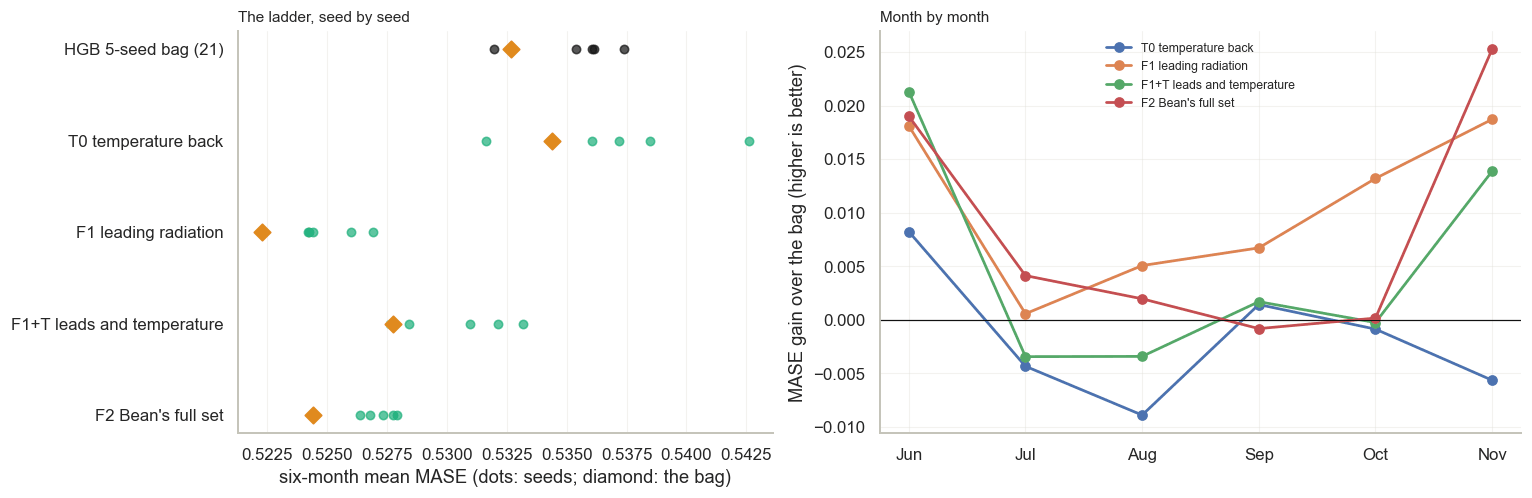

In [136]:
# --- 24b. The verdicts, the ladder, and the alignment diagnostic ------------------------
NAMES24 = list(FSETS)
BAG = "HGB 5-seed bag (21)"
bag_pred = {mon: PRED21[mon][[f"HGB s{s}" for s in range(5)]].mean(axis=1) for mon in M}
e24 = pd.DataFrame({**{(mon, BAG): score_vec(FRAME21[mon], bag_pred[mon], FOLDS[mon]) for mon in M},
                    **{(mon, n): score_vec(FRAME21[mon], PRED24[mon][n], FOLDS[mon]) for mon in M for n in NAMES24}}).T
tab24m = e24[SOLAR].mean(axis=1).unstack(0)[M].loc[[BAG] + NAMES24]
tab24 = tab24m.copy()
tab24["6-month mean"] = tab24m.mean(axis=1)
tab24["months beating the bag"] = [int((tab24m.loc[n] < tab24m.loc[BAG]).sum()) for n in tab24m.index]
b24 = e24.xs(BAG, level=1)[SOLAR]
kn = [(int(((b24 - e24.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum()), b24.size) for n in tab24m.index]
tab24["array-months beating the bag"] = [f"{k}/{m}" for k, m in kn]
tab24["one-sided sign p"] = [binomtest(k, m, 0.5, alternative="greater").pvalue for k, m in kn]
BONF24 = 0.05 / len(NAMES24)
bagm = tab24.loc[BAG, "6-month mean"]
tab24["delta vs the bag (positive = better)"] = bagm - tab24["6-month mean"]
tab24["prediction delta > +0.005 held"] = pd.Series(          # object dtype: the reference row has no prediction
    {n: (None if n == BAG else bool(v > 0.005)) for n, v in tab24["delta vs the bag (positive = better)"].items()},
    dtype=object)
tab24["verdict"] = ["reference" if n == BAG else
                    ("fail" if not (r["6-month mean"] < bagm and r["months beating the bag"] >= 4) else
                     "adopt" if r["one-sided sign p"] < BONF24 else "exploratory pass")
                    for n, r in tab24.iterrows()]
passing = [n for n in NAMES24 if tab24.loc[n, "verdict"] == "adopt"]
if passing:                                                  # at most one rung is adopted: the lowest mean
    ADOPT24 = min(passing, key=lambda n: tab24.loc[n, "6-month mean"])
    tab24.loc[[n for n in passing if n != ADOPT24], "verdict"] = "passes, not adopted (higher mean)"
else:
    ADOPT24 = None
display(tab24.round(4))
print(f"Bonferroni over {len(NAMES24)} rungs: p < {BONF24:.4f}")
print("unrounded delta vs the bag:", {n: f"{tab24.loc[n, 'delta vs the bag (positive = better)']:+.5f}" for n in NAMES24})

steps = pd.Series({"T0 vs the bag": tab24.loc[BAG, "6-month mean"] - tab24.loc["T0 temperature back", "6-month mean"],
                   "F1 vs the bag": tab24.loc[BAG, "6-month mean"] - tab24.loc["F1 leading radiation", "6-month mean"],
                   "F1+T vs F1": tab24.loc["F1 leading radiation", "6-month mean"] - tab24.loc["F1+T leads and temperature", "6-month mean"],
                   "F2 vs F1+T": tab24.loc["F1+T leads and temperature", "6-month mean"] - tab24.loc["F2 Bean's full set", "6-month mean"]})
display(steps.round(4).rename("six-month gain of each step (descriptive, not tested)").to_frame())

sp24 = pd.DataFrame({n: [np.mean([score_vec(FRAME21[mon], SEEDP24[(mon, n)][s], FOLDS[mon]).mean() for mon in M])
                         for s in range(5)] for n in NAMES24}, index=[f"seed {s}" for s in range(5)]).T
sp24.loc[BAG] = [np.mean([score_vec(FRAME21[mon], PRED21[mon][f"HGB s{s}"], FOLDS[mon]).mean() for mon in M])
                 for s in range(5)]
display(sp24.round(4).rename_axis("six-month mean of each single seed"))

pim = pd.DataFrame(PIMP24).T[LEADS]
pim["share of lead importance at +1 h"] = pim["rad_lead_1h"] / pim[LEADS].clip(lower=0).sum(axis=1)
display(pim.round(4).rename_axis("F1: permutation importance of each lead (MAE of the ratio, test month)"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.2]})
names = [BAG] + NAMES24
for i, n in enumerate(names):
    v = sp24.loc[n].to_numpy(dtype=float)
    col = "#111111" if n == BAG else "#1baf7a"
    a1.scatter(v, [i] * 5, color=col, s=30, alpha=0.7)
    a1.scatter(tab24.loc[n, "6-month mean"], i, marker="D", color="#e08a1e", s=60, zorder=4)
a1.set_yticks(range(len(names)), names); a1.invert_yaxis()
a1.set_xlabel("six-month mean MASE (dots: seeds; diamond: the bag)")
a1.set_title("The ladder, seed by seed", loc="left")
a1.grid(True, axis="x", alpha=0.4); a1.set_axisbelow(True)
for n in NAMES24:
    a2.plot(M, tab24m.loc[BAG] - tab24m.loc[n], marker="o", lw=1.8, label=n)
a2.axhline(0, color="#111", lw=0.8)
a2.set_ylabel("MASE gain over the bag (higher is better)")
a2.set_title("Month by month", loc="left")
a2.legend(fontsize=8); a2.grid(True, alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Figure.** How much each radiation lead matters to the F1 model, month by month (permutation importance on the test month; diagnostic only).

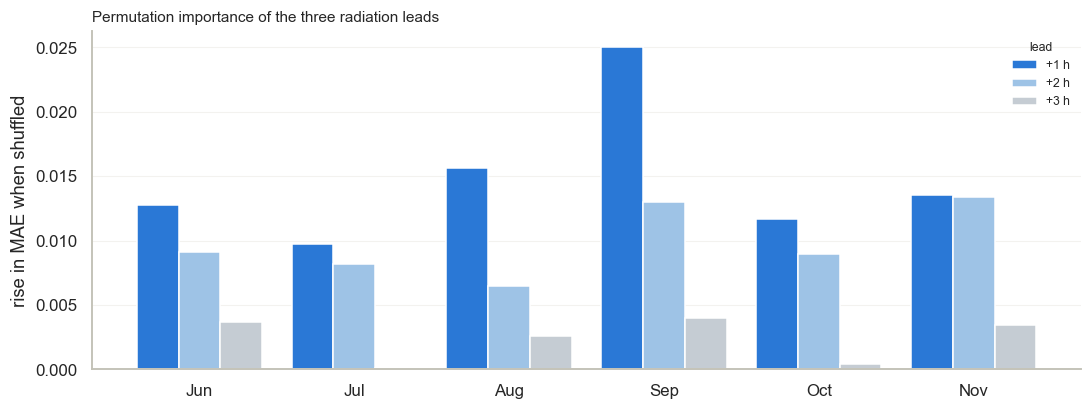

In [137]:
# --- Figure: the alignment diagnostic ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(pim.index)); w = 0.27
for k, (c, col) in enumerate(zip(LEADS, ["#2a78d6", "#9ec3e6", "#c5ccd3"])):
    ax.bar(x + (k - 1) * w, pim[c], w, color=col, label=c.replace("rad_lead_", "+").replace("h", " h"))
ax.set_xticks(x, pim.index); ax.set_ylabel("rise in MAE when shuffled")
ax.set_title("Permutation importance of the three radiation leads", loc="left")
ax.legend(fontsize=8, title="lead", title_fontsize=8); ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 24

**Leading radiation is adopted: the bagged boosting model with the next three hours of radiation
added (F1) scores 0.5223, against 0.5327 without them.**

- It is better in all six months and in 33 of 36 array-months (one-sided p < 0.0001).
- It helps all six arrays. The largest gain is Solar0's (+0.021); the others gain 0.006–0.010.
- All five of its seeds (0.5242–0.5269) beat all five seeds of the bag (0.5319–0.5374), so this
  is not seed noise.
- Bean's full set (F2) also passes (0.5244; 5 of 6 months; 31 of 36), but its mean is higher. Only
  the lowest-mean rung is adopted.

**Bean's claim holds for leading radiation and fails for temperature, on this data, with this
ratio target and this model.**

- Adding temperature back on its own (T0) makes the bag slightly *worse* (Δ = −0.0017; 2 of 6
  months). The bag is better in 24 of the 36 array-months, and T0 is worse on all six arrays.
  So section 11 was right to prune it.
- Dividing by clear-sky irradiance removes the daily and seasonal cycle that temperature partly
  stands in for in a kW-target model like Bean's quantile forest. That may be why it adds
  nothing here.
- Going from F1 to F1+T, adding temperature and its leads and lags, costs 0.0054, and F1+T fails
  (3 of 6 months; 17 of 36). The size of that step is descriptive, not tested.
- The radiation lags and cloud cover recover part of that loss (F2 against F1+T, +0.0033,
  descriptive), but never all of it.

His predictors were ranked on a different series mix with a different model, so the
disagreement over temperature is not a contradiction of his result. It is a finding about this
data.

**How the predictions scored** (each predicted Δ > +0.005 against the bag):

- T0 failed.
- F1 held (+0.0104).
- F2 held (+0.0083).
- F1+T failed, narrowly. It rounds to +0.0050, but its unrounded Δ is +0.00496 (printed below
  the table), just under the bar.

**The alignment diagnostic is mixed.**

- The +1-hour lead carries 45–63% of the three leads' permutation importance, depending on the
  month.
- The +2-hour lead carries most of the rest, and in November it is as important as +1 hour.
- The +3-hour lead carries little.

By the rule written in advance, a +1-hour-dominated pattern would point to a timing correction.
ERA5 smooths over a 31 km cell, and its instantaneous variables sit at the end of the hour.
Weight at +2 hours points to weather moving in. The +2-hour weight here suggests more than a
sub-hour timing fix. But the lead columns are correlated, so permutation importance splits credit
between them unreliably. The pattern is mixed, and this diagnostic cannot separate the two.

**One caveat about any leading feature.** The gain was measured with perfect knowledge of the
weather, since ERA5 is the notebook's stand-in for a forecast. In a month-ahead forecast, the next
hours' weather comes from the same forecast as the current hour's, so the leads lean on that
assumption no more than every other weather input does. Under a real forecast their gain could
be smaller, or larger if leads smooth over timing errors. The operational size is unknown.

**Where this leaves the models: the recommendation was unresolved here, and is resolved in section 25.** Two changes
have now each been adopted against the plain bag: section 22's GRU blend (0.5253) and this
section's F1 bag (0.5223). The F1 bag scores lower and needs no neural network. But that
comparison was not part of any frozen plan, so it is reported, not claimed. Section 25 tests
whether the two improvements add up, with the recommendation rule fixed before it runs.

---

# 25. Do the two improvements add up? The last model choice on this backtest

Two changes have each been adopted against the plain bagged boosting model, which scores 0.5327:

- **Section 22's blend** of the five-seed GRU and the bag: 0.5253.
- **Section 24's F1 bag**, the bag with the next three hours of radiation added: 0.5223.

They have never been tested against each other, and the recommendation is ambiguous until they
are. This section settles it.

**This is the last section that chooses a model on this backtest.** It would be the fourth
adoption stacked on the same six months. The frozen rules controlled each step, not the chain.
After this section, further model changes need fresh data.

**This plan was reviewed and frozen, with file hashes, before any section 25 model was fitted.**

| # | Candidate | Judged against |
|---|---|---|
| C1 | the five-seed GRU (section 22) + the F1 bag, equal weights | the F1 bag |
| C2 | the GRU given the three radiation leads as extra **static** inputs, at five seeds | the five-seed GRU |
| C3 | C2 + the F1 bag, equal weights | the F1 bag |

- **In C2**, the lead columns are standardised with a scaler fitted on the same rows as the
  static scaler. The weather sequence stays past-only, since section 20's forward-looking window
  failed. An assert checks that no forecast row lacks its input window.
- **A caveat for C2:** in June and July the networks keep their epoch 1–3 weights (section 22f),
  so the GRU may barely learn the new inputs, and C2 could understate their value.

**Known in advance about C1.** Its averaging bound is (0.5343 + 0.5223)/2 = 0.5283, above the F1
bag. So beating the F1 bag over six months needs more than 0.006 of diversity gain; section 22's
blend got 0.0082 against the plain bag. The GRU alone beats the F1 bag in June (0.4281 against
0.4299) and November (0.5602 against 0.5866). So C1 wins those two months by construction, and
needs at least two of July to October.

**Predictions** (Δ = reference minus candidate six-month mean; positive = candidate better):

| # | Prediction |
|---|---|
| C1 | Δ > 0 against the F1 bag |
| C2 | Δ > +0.005 against the five-seed GRU |
| C3 | C3's Δ > C1's Δ (descriptive, not a decision) |

**Decision rule.** This is section 21's rule, with Bonferroni over 3 (p < 0.0167). At most one
candidate is adopted: the lowest mean. The 21e rescoring (clean scales, flagged test days
removed, both) is run for any candidate that passes.

**The recommendation rule, fixed now:**

- If C1 or C3 passes against the F1 bag, the recommended model is whichever of those two passes
  with the lower mean.
- Otherwise, the F1 bag is recommended in place of section 22's blend. That replacement is a
  *judgement*, since it is simpler and descriptively better, not a test. The F1 bag against
  section 22's blend is deliberately **not** tested here, because both six-month means have
  already been seen.

**Checks on January to March 2020, where nothing was tuned (descriptive only).** These use the
8 clean array-months of section 21d, with every model refitted per month on data before it.

- The F1 bag against the plain bag. This is the only out-of-sample check section 24's adoption
  gets. Prediction: the F1 bag's mean is lower, and it wins at least 5 of the 8.
- C1 against the F1 bag. Prediction: C1's mean is lower, and it wins at least 5 of the 8.

In [138]:
# --- 25a. The candidates, on the six backtest months -------------------------------------
from sklearn.preprocessing import StandardScaler

# C2's extra static inputs: the three radiation leads, scaled on the rows static_scaler was fitted on
lead_scaler = StandardScaler().fit(LL.reindex(train_day.index)[LEADS].to_numpy())
stat_tr_lead = np.hstack([stat_tr, lead_scaler.transform(LL.reindex(td.index)[LEADS].to_numpy()).astype("float32")])
ALL_LEAD = list(range(stat_tr_lead.shape[1]))


def build_inputs_lead(frame):
    seq, static, ok = build_inputs(frame)
    lead = lead_scaler.transform(LL.reindex(frame.index[ok])[LEADS].to_numpy()).astype("float32")
    return seq, np.hstack([static, lead]), ok


P25 = {}
for mon, win in FOLDS.items():
    arrays = FIXED[mon]; tag_a = "-".join(arrays) or "none"
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    frame = FRAME21[mon]
    _, _, ok = build_inputs_lead(frame)
    assert ok.all(), f"{mon}: rows without a full input window"
    n3, _ = train_arch("GRU", seq_tr, stat_tr_lead, r, mask, f"v25-GRUlead-{mon}-{tag_a}")
    n2, _ = train_arch("GRU", seq_tr, stat_tr_lead, r, mask, f"v25-GRUlead-{mon}-{tag_a}-s34", seeds=(3, 4))
    c2 = clean_pred(frame, predict_with(n3 + n2, build_inputs_lead, ALL_LEAD, ref_linear, caps)(frame))
    f1 = PRED24[mon]["F1 leading radiation"].to_numpy()
    gru = C22[(mon, "A1 GRU")]
    P25[(mon, "F1 bag")] = f1
    P25[(mon, "GRU, 5 seeds")] = gru
    P25[(mon, "C1 GRU + F1 bag")] = (gru + f1) / 2
    P25[(mon, "C2 GRU with leads")] = c2
    P25[(mon, "C3 C2 + F1 bag")] = (c2 + f1) / 2

e25 = pd.DataFrame({k: score_vec(FRAME21[k[0]], p, FOLDS[k[0]]) for k, p in P25.items()}).T
tab25 = e25[SOLAR].mean(axis=1).unstack(0)[M]
tab25["6-month mean"] = tab25[M].mean(axis=1)
display(tab25.round(4))

rows = []
for cand, ref in [("C1 GRU + F1 bag", "F1 bag"), ("C2 GRU with leads", "GRU, 5 seeds"), ("C3 C2 + F1 bag", "F1 bag")]:
    d = (e25.xs(ref, level=1)[SOLAR] - e25.xs(cand, level=1)[SOLAR]).to_numpy().ravel(); k = int((d > 0).sum())
    rows.append({"candidate": cand, "judged against": ref, "six-month": tab25.loc[cand, "6-month mean"],
                 "reference": tab25.loc[ref, "6-month mean"],
                 "delta (positive = better)": tab25.loc[ref, "6-month mean"] - tab25.loc[cand, "6-month mean"],
                 "months better": int((tab25.loc[cand, M] < tab25.loc[ref, M]).sum()), "array-months": f"{k}/36",
                 "one-sided sign p": binomtest(k, 36, 0.5, alternative="greater").pvalue})
res25 = pd.DataFrame(rows).set_index("candidate")
res25["passes (p < 0.05/3)"] = ((res25["delta (positive = better)"] > 0) & (res25["months better"] >= 4)
                                & (res25["one-sided sign p"] < 0.05 / 3))
display(res25.round(5))
bound_c1 = (tab25.loc["GRU, 5 seeds", "6-month mean"] + tab25.loc["F1 bag", "6-month mean"]) / 2
print(f"C1's averaging bound: {bound_c1:.4f};  months where the GRU alone beats the F1 bag (C1 wins by construction): "
      f"{[m for m in M if tab25.loc['GRU, 5 seeds', m] < tab25.loc['F1 bag', m]]}")

passers = [c for c in ("C1 GRU + F1 bag", "C3 C2 + F1 bag") if res25.loc[c, "passes (p < 0.05/3)"]]
RECOMMENDED = min(passers, key=lambda c: tab25.loc[c, "6-month mean"]) if passers else "F1 bag"
print("recommended under the frozen rule:", RECOMMENDED,
      "" if passers else "(no blend passed; the F1 bag replaces section 22's blend as a judgement)")

  [cache] loaded seeds_v25-GRUlead-Jun-none (3 networks)
  [cache] loaded seeds_v25-GRUlead-Jun-none-s34 (2 networks)


  [cache] loaded seeds_v25-GRUlead-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v25-GRUlead-Jul-Solar3-s34 (2 networks)


  [cache] loaded seeds_v25-GRUlead-Aug-Solar3 (3 networks)
  [cache] loaded seeds_v25-GRUlead-Aug-Solar3-s34 (2 networks)


  [cache] loaded seeds_v25-GRUlead-Sep-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v25-GRUlead-Sep-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v25-GRUlead-Oct-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v25-GRUlead-Oct-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v25-GRUlead-Nov-Solar3-Solar0 (3 networks)
  [cache] loaded seeds_v25-GRUlead-Nov-Solar3-Solar0-s34 (2 networks)


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
C1 GRU + F1 bag,0.4229,0.3908,0.6241,0.5355,0.5863,0.5599,0.5199
C2 GRU with leads,0.5899,0.4578,0.6295,0.5242,0.6031,0.5609,0.5609
C3 C2 + F1 bag,0.4987,0.4100,0.6176,0.5206,0.5840,0.5543,0.5309
F1 bag,0.4299,0.3822,0.6140,0.5333,0.5878,0.5866,0.5223
"GRU, 5 seeds",0.4281,0.4140,0.6450,0.5549,0.6035,0.5602,0.5343


,judged against,six-month,reference,delta (positive = better),months better,array-months,one-sided sign p,passes (p < 0.05/3)
candidate,,,,,,,,
C1 GRU + F1 bag,F1 bag,0.51992,0.52230,0.00238,3,24/36,0.03262,False
C2 GRU with leads,"GRU, 5 seeds",0.56091,0.53428,-0.02663,3,19/36,0.43397,False
C3 C2 + F1 bag,F1 bag,0.53086,0.52230,-0.00856,3,21/36,0.20252,False


C1's averaging bound: 0.5283;  months where the GRU alone beats the F1 bag (C1 wins by construction): ['Jun', 'Nov']
recommended under the frozen rule: F1 bag (no blend passed; the F1 bag replaces section 22's blend as a judgement)


**Figure.** Section 25's candidates month by month, against the F1 bag and the GRU.

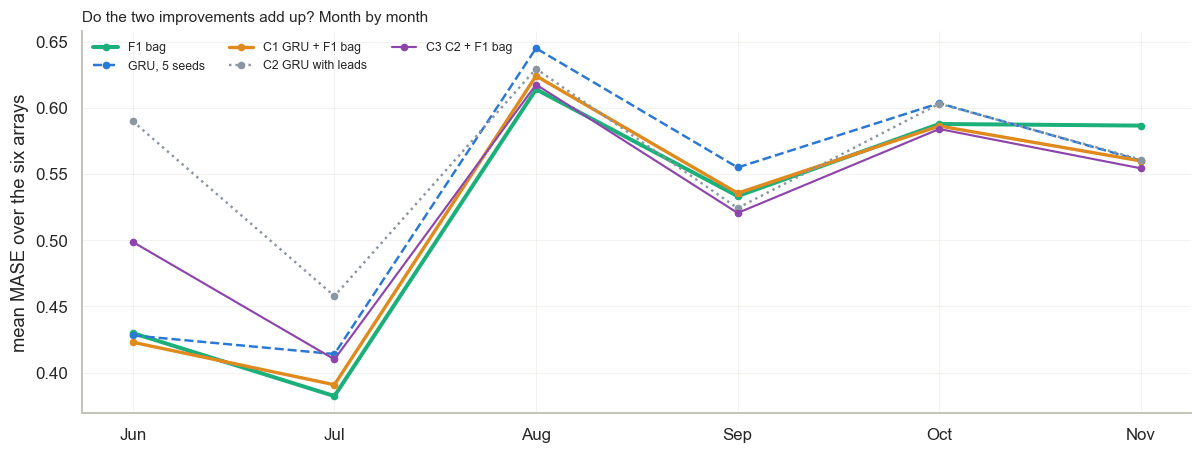

In [139]:
# --- Figure: section 25 by month ---------------------------------------------------------------
fg_style = {"F1 bag": ("#1baf7a", "-", 2.6), "GRU, 5 seeds": ("#2a78d6", "--", 1.6),
            "C1 GRU + F1 bag": ("#e08a1e", "-", 2.2), "C2 GRU with leads": ("#8c96a3", ":", 1.6),
            "C3 C2 + F1 bag": ("#8e44ad", "-", 1.4)}
fig, ax = plt.subplots(figsize=(11, 4.2))
for n, (c, ls, lw) in fg_style.items():
    ax.plot(M, tab25.loc[n, M], color=c, ls=ls, lw=lw, marker="o", ms=4, label=n)
ax.set_ylabel("mean MASE over the six arrays"); ax.set_title("Do the two improvements add up? Month by month", loc="left")
ax.legend(fontsize=8, ncol=3, loc="upper left"); ax.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 25b. Robustness, and January to March 2020

The 21e rescoring runs only for a candidate that passes, as pre-registered. The recommended F1 bag
is also rescored the four ways, against the plain bag. That was not part of section 24's frozen
plan: it is run after the recommendation was fixed, and cannot change it. The two January–March
checks run regardless.

In [140]:
# --- 25b. Robustness of any passer, and January to March 2020 -------------------------------
for cand in [c for c in res25.index if res25.loc[c, "passes (p < 0.05/3)"]]:
    ref = res25.loc[cand, "judged against"]
    rob = []
    for lab, (cs, dfl) in SETTINGS.items():
        e = pd.DataFrame({(mon, n): score_setting(FRAME21[mon], P25[(mon, n)], FOLDS[mon], mon, cs, dfl)
                          for mon in M for n in (cand, ref)}).T
        t = e[SOLAR].mean(axis=1).unstack(0)[M]
        d = (e.xs(ref, level=1)[SOLAR] - e.xs(cand, level=1)[SOLAR]).to_numpy().ravel(); k = int((d > 0).sum())
        rob.append({"setting": lab, "six-month": t.loc[cand].mean(), "reference": t.loc[ref].mean(),
                    "months better": int((t.loc[cand] < t.loc[ref]).sum()), "array-months": f"{k}/36",
                    "one-sided p": binomtest(k, 36, 0.5, alternative="greater").pvalue})
    display(pd.DataFrame(rob).set_index("setting").round(4).rename_axis(f"{cand} vs {ref}, four scoring settings"))


# The recommended F1 bag under 21e's four settings: descriptive, not in section 24's frozen plan,
# run after the recommendation was fixed, and unable to change it.
rob_f1 = []
for lab, (cs, dfl) in SETTINGS.items():
    e = pd.DataFrame({**{(mon, "F1 bag"): score_setting(FRAME21[mon], P25[(mon, "F1 bag")], FOLDS[mon], mon, cs, dfl)
                         for mon in M},
                      **{(mon, "plain bag"): score_setting(FRAME21[mon], BAGP[mon], FOLDS[mon], mon, cs, dfl)
                         for mon in M}}).T
    t = e[SOLAR].mean(axis=1).unstack(0)[M]
    d = (e.xs("plain bag", level=1)[SOLAR] - e.xs("F1 bag", level=1)[SOLAR]).to_numpy().ravel(); k = int((d > 0).sum())
    rob_f1.append({"setting": lab, "F1 bag": t.loc["F1 bag"].mean(), "plain bag": t.loc["plain bag"].mean(),
                   "months better": int((t.loc["F1 bag"] < t.loc["plain bag"]).sum()), "array-months": f"{k}/36",
                   "one-sided p": binomtest(k, 36, 0.5, alternative="greater").pvalue})
display(pd.DataFrame(rob_f1).set_index("setting").round(4)
        .rename_axis("the recommended F1 bag vs the plain bag, four scoring settings (descriptive)"))


def _janmar25():
    jr = {}
    for mon, win in PRE21.items():
        tr = train_day[train_day.index < win[0]]; caps = cap_of(tr)
        frame = month_frame(win)
        _, _, ok = build_inputs(frame); assert ok.all()
        bag = np.mean([clean_pred(frame, fit_hgb(tr, caps, seed=s)(frame)) for s in range(5)], axis=0)
        f1 = np.mean([clean_pred(frame, fit_hgb_x(tr, caps, LEADS, s)[1](frame)) for s in range(5)], axis=0)
        r, mask, caps2 = ratio_inputs_ref(win[0], (), ref_linear)
        n3, _ = train_arch("GRU", seq_tr, stat_tr, r, mask, f"v22-GRU-{mon}-none")
        n2, _ = train_arch("GRU", seq_tr, stat_tr, r, mask, f"v22-GRU-{mon}-none-s34", seeds=(3, 4))
        gru = clean_pred(frame, predict_with(n3 + n2, build_inputs, ALL, ref_linear, caps2)(frame))
        for lab, p in (("plain bag", bag), ("F1 bag", f1), ("C1 GRU + F1 bag", (gru + f1) / 2)):
            s = score_vec(frame, p, win, CLEAN21[mon])
            for a in CLEAN21[mon]:
                jr[(mon, a, lab)] = s[a]
    return jr


jt25 = pd.Series(cached("janmar_25", _janmar25)).unstack(2)[["plain bag", "F1 bag", "C1 GRU + F1 bag"]]
display(jt25.round(4).rename_axis(["month", "array"]))
for a, b in (("F1 bag", "plain bag"), ("C1 GRU + F1 bag", "F1 bag")):
    k = int((jt25[a] < jt25[b]).sum())
    print(f"{a} vs {b}: mean {jt25[a].mean():.4f} vs {jt25[b].mean():.4f}; wins {k}/8; "
          f"frozen prediction held: {bool(jt25[a].mean() < jt25[b].mean() and k >= 5)}")
gru_jm = jm["GRU, 5 seeds"]                                    # section 22g's GRU on the same array-months
print("array-months where the GRU alone beats the F1 bag (C1's win there is guaranteed):",
      jt25.index[gru_jm.reindex(jt25.index) < jt25["F1 bag"]].tolist())

,F1 bag,plain bag,months better,array-months,one-sided p
"the recommended F1 bag vs the plain bag, four scoring settings (descriptive)",,,,,
as reported,0.5223,0.5327,6,33/36,0.0
clean scales,0.6395,0.6520,6,33/36,0.0
flagged test days removed,0.5239,0.5344,5,33/36,0.0
both,0.6411,0.6537,6,33/36,0.0


  [cache] loaded janmar_25


plain bag  F1 bag  C1 GRU + F1 bag
month array                                     
Feb   Solar1     0.8796  0.8764           0.8373
      Solar2     0.7675  0.7707           0.7437
      Solar4     0.7442  0.7348           0.7274
Jan   Solar1     0.8550  0.8223           0.8266
      Solar2     0.7759  0.7434           0.7582
      Solar4     0.7248  0.6901           0.7051
Mar   Solar2     0.5746  0.5647           0.5823
      Solar4     0.5833  0.5716           0.5528

F1 bag vs plain bag: mean 0.7218 vs 0.7381; wins 7/8; frozen prediction held: True
C1 GRU + F1 bag vs F1 bag: mean 0.7167 vs 0.7218; wins 4/8; frozen prediction held: False
array-months where the GRU alone beats the F1 bag (C1's win there is guaranteed): [('Feb', 'Solar1'), ('Feb', 'Solar2'), ('Mar', 'Solar4')]


**Figure.** January to March 2020: the plain bag, the F1 bag and C1 on each clean array-month.

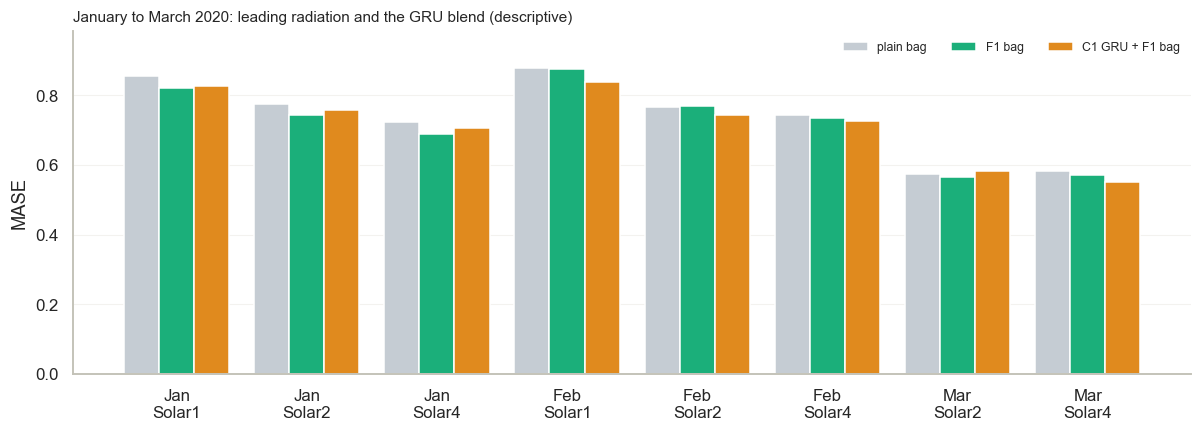

In [141]:
# --- Figure: section 25b, array-month by array-month -------------------------------------------
fg_cols = ["plain bag", "F1 bag", "C1 GRU + F1 bag"]
jt_o = jt25.loc[[(m, a) for m in ("Jan", "Feb", "Mar") for a in CLEAN21[m]]]
fg_col = {"plain bag": "#c5ccd3", "F1 bag": "#1baf7a", "C1 GRU + F1 bag": "#e08a1e"}
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(jt_o)); w = 0.27
for k, c in enumerate(fg_cols):
    ax.bar(x + (k - 1) * w, jt_o[c], w, color=fg_col[c], label=c)
ax.set_xticks(x, [f"{m}\n{a}" for m, a in jt_o.index]); ax.set_ylabel("MASE")
ax.set_ylim(0, jt_o[fg_cols].max().max() * 1.12)
ax.set_title("January to March 2020: leading radiation and the GRU blend (descriptive)", loc="left")
ax.legend(fontsize=8, ncol=3, loc="upper right"); ax.grid(True, axis="y", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 25

**No candidate passes. Under the recommendation rule fixed before this section ran, the
recommended model is section 24's F1 bag:** bagged absolute-error boosting on the corrected
ratio target, with the next three hours of radiation added. It scores 0.5223 over six months.
That it replaces section 22's GRU blend (0.5253) is a *judgement*, not a test: it is simpler,
needs no neural network, and is descriptively better. The two were deliberately never tested
head to head, because both six-month means had already been seen.

| Candidate | Six-month | Against | Δ | Months better | Array-months | Verdict |
|---|---|---|---|---|---|---|
| C1: GRU + F1 bag | **0.5199** | F1 bag, 0.5223 | +0.0024 | 3 of 6 | 24/36 (p = 0.033) | fails |
| C2: GRU given the leads | 0.5609 | GRU, 0.5343 | −0.0266 | 3 of 6 | 19/36 | fails |
| C3: C2 + F1 bag | 0.5309 | F1 bag, 0.5223 | −0.0086 | 3 of 6 | 21/36 | fails |

**C1 is a close second, not refuted.** It has the lowest mean of anything in this notebook, both on
the backtest (0.5199) and on January to March (0.7167 against the F1 bag's 0.7218). It fails
because its gain is concentrated:

- It wins only three months: June, October and November. June and November were won by
  construction, because the GRU alone beats the F1 bag there, and October by only 0.0015.
- November carries more than all of its six-month lead (0.5599 against 0.5866). Over the other
  five months it is slightly *worse* than the F1 bag (0.5119 against 0.5094).
- So the F1 bag is chosen by the frozen rule and by simplicity, not because C1 was shown to be
  worse.

**Why combining helped less this time.** The GRU still adds as much diversity as before: 0.0082
against the plain bag and 0.0084 against the F1 bag, measured over each blend's averaging bound.
What changed is the partner. The F1 bag is 0.012 better than the GRU alone, so averaging the GRU in
now costs almost everything that diversity gains. C1's prediction (Δ > 0) held; the decision rule
did not.

**Giving the GRU leading radiation made it much worse overall (C2), and its prediction failed.**

- The damage is all in June (0.5899 against 0.4281) and July (0.4578 against 0.4140). C2 actually
  *beats* the plain GRU in August (0.6295 against 0.6450) and September (0.5242 against 0.5549),
  and ties October and November.
- June and July are the months where the networks keep their epoch 1–3 weights (section 22f), so
  three extra inputs the GRU has no time to learn may disturb it. That fits the early-stopping
  hypothesis without proving it.
- The weakness carries into C3, which is worse than the F1 bag alone. C3's prediction, that it
  would gain more than C1, also failed.

**January to March 2020, where nothing was tuned (descriptive only):**

- **The F1 bag beats the plain bag in 7 of the 8 clean array-months** (0.7218 against 0.7381), so
  its frozen prediction held. This is the only out-of-sample check section 24's adoption gets,
  and it supports it clearly.
- **C1 against the F1 bag: the mean is lower (0.7167 against 0.7218), but C1 wins only 4 of the
  8.** The frozen prediction needed at least 5, so it failed. Three of those four wins were
  guaranteed, since the GRU alone beats the F1 bag in those array-months. Only one was earned.

**The recommended F1 bag survives all four scoring settings of section 21e** (descriptive; not
part of section 24's frozen plan, and run after the recommendation was fixed). With clean MASE
scales, with the flagged test days removed, or with both, it still beats the plain bag in 33 of
36 array-months. It wins all six months in three of the settings, and five of six with the
flagged test days removed. The absolute levels rise with clean scales (0.6395 against 0.6520),
as section 21e found for every model.

**A procedural note.** The first run of section 25's frozen script ended in 0.6 seconds, with no
output. It wrote no models: the section 25 cache count was 0 before and after. The likely cause is
that the log filter hid an error line, though that was not confirmed. The unchanged script, whose
hash matches the frozen copy, was then run again, and that run is the one reported here. Nothing
from the first attempt was seen. Training is deterministic (section 22f's control reproduced a
cached network exactly), so rerunning identical code could not produce a different draw, and a
rerun could not have been used to pick a result.

**This is the last model choice on this backtest.** Each of sections 17 to 25 was controlled on
its own, but the chain of choices was not: every step was judged on the same six months. The
January to March checks are the only evidence from months where nothing was chosen, and they
support the recommended model. Any further model change needs fresh data. The standing caveats
still apply:

- The weather is treated as a perfect forecast.
- The MASE scales include the flagged days (section 21e), which understates the error on
  Solar1–4 in every absolute MASE figure.
- As section 19 noted, the feature list, the model settings, the regime dates and the input
  scalers (now including C2's lead scaler) were all settled using data up to November.

---

## Where the solar modelling ends

Mean MASE over the six arrays, averaged over the six backtest months (June to November 2020),
with each month forecast only from data before it. Lower is better.

| Step | Model | Six-month MASE |
|---|---|---|
| reference | 28-day seasonal naive | 1.0448 |
| section 11 | random forest on raw kW, original data | 0.5693 |
| sections 17–19 | absolute-error boosting on the corrected ratio target, one seed | 0.5361 |
| section 21 | the same, bagged over five seeds | 0.5327 |
| section 22 | five-seed GRU + that bag (superseded) | 0.5253 |
| **sections 24–25** | **the bag with the next three hours of radiation added: recommended** | **0.5223** |

**What moved the error most.**

- Fixing the data: the Solar3 and Solar0 corrections, and cleaning the flagged days.
- Choosing a target and a loss that match the metric: the clear-sky ratio and absolute error.
- One genuinely useful input: leading radiation.

Thirteen changes to the neural networks were tested in sections 20, 22 and 23. Two were
confirmed at five seeds, the GRU and LSTM(24). Only the GRU was adopted, and it helps mainly as a
blend partner.

**How far to trust it.** Every step was chosen on the same six months. The recommended model
also beat the plain bag in 7 of 8 array-months from January to March 2020, which were never used
to choose anything. That is the strongest evidence in this notebook, and it is still only eight
array-months. The weather is ERA5 treated as a perfect forecast, so every figure here is
optimistic compared with real operation. *Section 26 restates every headline result on clean MASE scales, and section 27 tries further neural networks, as exploration only.*

---

# 26. Every headline result on clean MASE scales

Section 21e found that every MASE scale in this notebook includes cell 45's flagged days. On
those days a stuck counter reports output at night, and in the March–May 2020 spell the daytime
values are wrong as well. That inflates the seasonal-naive error that every MASE divides by, most
for Solar1 and Solar3, so the absolute MASE figures throughout understate the error on those
arrays.

**This notebook keeps its MASE as reported.** That matches the competition's definition, which
divides by the naive's error on the raw training series. This section adds the clean-scale version
alongside it. It changes no model and revisits no decision.

**How it works, and why it is exact.** For a given array and origin month, the forecast errors do
not change; only the denominator does. So

    clean MASE = reported MASE × (reported scale ÷ clean scale),

applied array by array before averaging over arrays. "Clean" means cell 45's flagged days are
removed from the benchmark's scale only; the scored test rows are unchanged. The re-scoring uses
live model functions and forecasts stored in sections 21–25, never cached scores, because those
were computed with the old scale.

**Stated before looking: no verdict is revisited.** The sign tests cannot change, because each
compares two models on the same array and month, with the same scale. The six-array means and the
month counts can change. Any flip is reported, but nothing is re-decided.

## 26a. The conversion factor

In [142]:
# --- 26a. The conversion factor: reported scale / clean scale, per array and origin month -------
FAC = {}
for mon in FOLDS:                                           # SCALE (21e) holds (raw, clean) per array and fold
    for n in SOLAR:
        FAC[(n, mon)] = SCALE[(n, mon)][0] / SCALE[(n, mon)][1]
for mon, w in PRE21.items():                                # the January-March origins used in 21d, 22g and 25b
    for n in SOLAR:
        raw, cl = mase_scale(n, w[0]), mase_scale_clean(n, w[0])
        FAC[(n, mon)] = raw / cl if (np.isfinite(raw) and np.isfinite(cl) and cl > 0) else np.nan
conv = pd.Series(FAC).unstack(1)[list(PRE21) + list(FOLDS)]
display(conv.round(3).rename_axis("clean-scale MASE = reported MASE x this factor"))
print("Clean means flagged night-output days (cell 45) are removed from the benchmark's scale only;"
      " the scored test rows are unchanged.")


def to_clean(scores, mon):
    """Per-array reported MASE for one month -> clean-scale MASE for the same forecasts."""
    return scores * pd.Series({n: FAC[(n, mon)] for n in scores.index})

,Jan,Feb,Mar,Jun,Jul,Aug,Sep,Oct,Nov
clean-scale MASE = reported MASE x this factor,,,,,,,,,
Solar0,NaN,NaN,NaN,1.035,0.889,0.873,0.918,0.905,0.920
Solar1,1.000,1.000,1.000,1.553,1.691,1.670,1.638,1.593,1.552
Solar2,1.047,1.035,1.024,1.250,1.332,1.331,1.317,1.290,1.266
Solar3,3.344,2.611,2.128,1.935,1.905,1.851,1.758,1.643,1.556
Solar4,1.000,1.000,1.000,1.146,1.166,1.168,1.163,1.149,1.137
Solar5,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Clean means flagged night-output days (cell 45) are removed from the benchmark's scale only; the scored test rows are unchanged.


**Figure.** The clean-scale conversion factor for each array and origin month. A factor above 1 means the reported MASE understates that array's error.

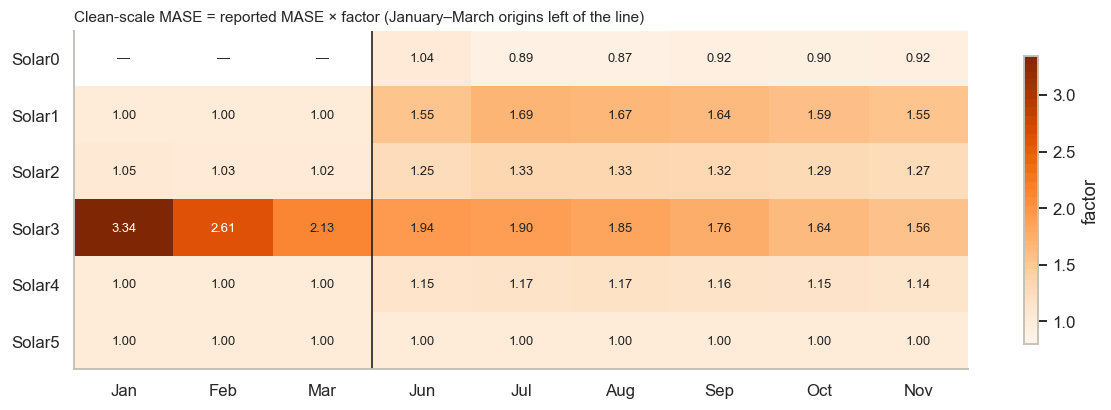

In [143]:
# --- Figure: the conversion factors -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 3.8))
fg_v = conv.to_numpy(dtype=float)
im = ax.imshow(np.ma.masked_invalid(fg_v), cmap="Oranges", aspect="auto", vmin=0.8, vmax=np.nanmax(fg_v))
for (i, j), v in np.ndenumerate(fg_v):
    ax.text(j, i, "—" if not np.isfinite(v) else f"{v:.2f}", ha="center", va="center", fontsize=8.5,
            color="white" if np.isfinite(v) and v > 2.2 else "#222")
ax.set_xticks(range(conv.shape[1]), conv.columns); ax.set_yticks(range(conv.shape[0]), conv.index)
ax.axvline(2.5, color="#111", lw=1)
ax.set_title("Clean-scale MASE = reported MASE × factor (January–March origins left of the line)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.85, label="factor")
plt.tight_layout(); plt.show()

## 26b. Every headline result, rescored

- **(1) November, sections 11–17.** These are called from the live model functions.
- **(2) The six-month backtest, sections 19–25.** These use the forecasts stored in sections
  21–25.
- **(3) The four comparisons behind the adoptions,** with their six-month means and month counts.
- **(4) January to March 2020,** from sections 22g and 25b.

In [144]:
# --- 26b. Every headline result, rescored array by array -------------------------------------
# (1) November only, sections 11-17: per-array scores from the live model functions
nov_models = {f"{n} (11-15)": fn for n, fn in REGISTRY.items() if not n.startswith("blend")}
nov_models.update({f"RF {k} (17)": POOLED[k] for k in POOLED})
nov_models["LSTM, corrected data (17)"] = nets_predict(lstms_fixed, capacity_fix)
nov_rows, stale = {}, []
for n, fn in nov_models.items():
    try:
        s = score_frame(fn, NOV)
    except (AttributeError, TypeError, KeyError, NameError):
        stale.append(n)                 # its function refers to a name a later section reused
        continue
    nov_rows[n] = {"reported": s.mean(), "clean scales": to_clean(s, "Nov").mean()}
if stale:
    print("left out: these registry entries refer to variables later sections reused, so they cannot be "
          "re-scored here:", stale)
# the "reported" column must equal what sections 11-17 displayed: proof no function picked up a reused name
DISPLAYED = {"LSTM, corrected data (17)": 0.6034, "RF Solar3 corrected only, ratio (17)": 0.6152,
             "RF corrected data, ratio (17)": 0.6158, "RF corrected data, kW (17)": 0.6402,
             "L2 + centred window (11-15)": 0.6657, "L3 + bidirectional (11-15)": 0.6699,
             "RF (pruned, ratio) (11-15)": 0.6775, "RF original data, ratio (17)": 0.6796,
             "L0 13a baseline (11-15)": 0.6832, "LSTM (ratio) (11-15)": 0.6832, "L1 + slower schedule (11-15)": 0.6876,
             "LSTM (raw kW) (11-15)": 0.6961, "RF original data, kW (17)": 0.6989, "RF (pruned, raw kW) (11-15)": 0.6989,
             "L4 + attention (11-15)": 0.7179, "HistGradientBoosting (11-15)": 0.7279, "CNN (raw kW) (11-15)": 0.7297,
             "CNN (ratio) (11-15)": 0.7340, "RF (per array) (11-15)": 0.7358, "Ridge (linear) (11-15)": 1.2127}
for n, v in DISPLAYED.items():
    if n in nov_rows:
        assert abs(nov_rows[n]["reported"] - v) < 5e-5, (n, nov_rows[n]["reported"], v)
print(f"all {sum(n in nov_rows for n in DISPLAYED)} re-scored November values match what sections 11-17 displayed")
nov_tab = pd.DataFrame(nov_rows).T
nov_tab["rank, reported"] = nov_tab["reported"].rank().astype(int)
nov_tab["rank, clean"] = nov_tab["clean scales"].rank().astype(int)
display(nov_tab.sort_values("reported").round(4).rename_axis("November MASE, sections 11-17"))

# (2) the six-month backtest, sections 19-25: per-array, per-month scores of the stored forecasts
BACKTEST = {"seasonal naive (19)": None}
BACKTEST.update({f"{n} (19)": (lambda mon, c=c: PRED21[mon][c]) for n, c in
                 [("RF, original data, kW", "RF kW"), ("RF, corrected, ratio", "RF ratio"),
                  ("HGB, one seed", "HGB s0"), ("LSTM, corrected", "LSTM")]})
BACKTEST["LSTM, 5 seeds (22)"] = lambda mon: C22[(mon, "baseline, 5 seeds")]
BACKTEST["HGB 5-seed bag (21)"] = lambda mon: BAGP[mon]
BACKTEST["GRU, 5 seeds (22)"] = lambda mon: C22[(mon, "A1 GRU")]
BACKTEST["GRU + HGB bag (22)"] = lambda mon: (BAGP[mon] + C22[(mon, "A1 GRU")]) / 2
BACKTEST.update({f"{n} (23)": (lambda mon, n=n: PRED23[mon][n]) for n in NAMES23})
BACKTEST.update({f"{n} (24)": (lambda mon, n=n: PRED24[mon][n]) for n in NAMES24})
BACKTEST["C1 GRU + F1 bag (25)"] = lambda mon: P25[(mon, "C1 GRU + F1 bag")]

per = {}
for n, f in BACKTEST.items():
    for mon in M:
        s = naive_scores(FOLDS[mon]) if f is None else score_vec(FRAME21[mon], f(mon), FOLDS[mon])
        per[(n, mon, "reported")] = s
        per[(n, mon, "clean")] = to_clean(s, mon)
month_mean = pd.Series({k: v.mean() for k, v in per.items()}).unstack(1)[M]
six_tab = pd.DataFrame({"reported": month_mean.xs("reported", level=1).mean(axis=1),
                        "clean scales": month_mean.xs("clean", level=1).mean(axis=1)})
six_tab["rank, reported"] = six_tab["reported"].rank().astype(int)
six_tab["rank, clean"] = six_tab["clean scales"].rank().astype(int)
display(six_tab.sort_values("reported").round(4).rename_axis("six-month mean MASE, sections 19-25"))

# (3) the comparisons behind the adoptions: means and month counts can move; sign tests cannot
KEY = [("GRU, 5 seeds (22)", "LSTM, 5 seeds (22)"), ("GRU + HGB bag (22)", "HGB 5-seed bag (21)"),
       ("F1 leading radiation (24)", "HGB 5-seed bag (21)"), ("C1 GRU + F1 bag (25)", "F1 leading radiation (24)")]
krows = []
for a, b in KEY:
    for sc in ("reported", "clean"):
        ta, tb = month_mean.loc[(a, sc)], month_mean.loc[(b, sc)]
        krows.append({"comparison": f"{a} vs {b}", "scale": sc, "six-month": ta.mean(), "reference": tb.mean(),
                      "months better": int((ta < tb).sum())})
display(pd.DataFrame(krows).set_index(["comparison", "scale"]).round(4))

# (4) January to March 2020 (22g and 25b), rescaled with the January-March factors
jm_all = pd.concat([jm, jt25.drop(columns="plain bag")], axis=1)
jm_clean = jm_all.mul([FAC[(a, m)] for m, a in jm_all.index], axis=0)
display(pd.DataFrame({"reported": jm_all.mean(), "clean scales": jm_clean.mean()}).round(4)
        .rename_axis("mean over the 8 clean January-March array-months"))

left out: these registry entries refer to variables later sections reused, so they cannot be re-scored here: ['RF (full features) (11-15)']
all 20 re-scored November values match what sections 11-17 displayed


,reported,clean scales,"rank, reported","rank, clean"
"November MASE, sections 11-17",,,,
"LSTM, corrected data (17)",0.6034,0.7214,1,1
"RF Solar3 corrected only, ratio (17)",0.6152,0.7354,2,2
"RF corrected data, ratio (17)",0.6158,0.7362,3,3
"RF corrected data, kW (17)",0.6402,0.7598,4,4
L2 + centred window (11-15),0.6657,0.8216,5,5
L3 + bidirectional (11-15),0.6699,0.8257,6,6
"RF (pruned, ratio) (11-15)",0.6775,0.8298,7,7
"RF original data, ratio (17)",0.6796,0.8322,8,8
L0 13a baseline (11-15),0.6832,0.8375,9,9


,reported,clean scales,"rank, reported","rank, clean"
"six-month mean MASE, sections 19-25",,,,
C1 GRU + F1 bag (25),0.5199,0.6353,1,1
F1 leading radiation (24),0.5223,0.6395,2,2
F2 Bean's full set (24),0.5244,0.6421,3,4
GRU + HGB bag (22),0.5253,0.6419,4,3
F1+T leads and temperature (24),0.5277,0.6465,5,5
HGB 5-seed bag (21),0.5327,0.6520,6,7
"GRU, 5 seeds (22)",0.5343,0.6513,7,6
T0 temperature back (24),0.5344,0.6542,8,8
"HGB, one seed (19)",0.5361,0.6565,9,9


six-month  reference  months better
comparison                                        scale                                        
GRU, 5 seeds (22) vs LSTM, 5 seeds (22)           reported     0.5343     0.5649              5
                                                  clean        0.6513     0.6890              5
GRU + HGB bag (22) vs HGB 5-seed bag (21)         reported     0.5253     0.5327              4
                                                  clean        0.6419     0.6520              4
F1 leading radiation (24) vs HGB 5-seed bag (21)  reported     0.5223     0.5327              6
                                                  clean        0.6395     0.6520              6
C1 GRU + F1 bag (25) vs F1 leading radiation (24) reported     0.5199     0.5223              3
                                                  clean        0.6353     0.6395              4

,reported,clean scales
mean over the 8 clean January-March array-months,,
HGB bag,0.7381,0.7477
"GRU, 5 seeds",0.7473,0.7573
GRU + HGB bag,0.7277,0.7373
F1 bag,0.7218,0.7312
C1 GRU + F1 bag,0.7167,0.7261


## 26c. Reported against clean

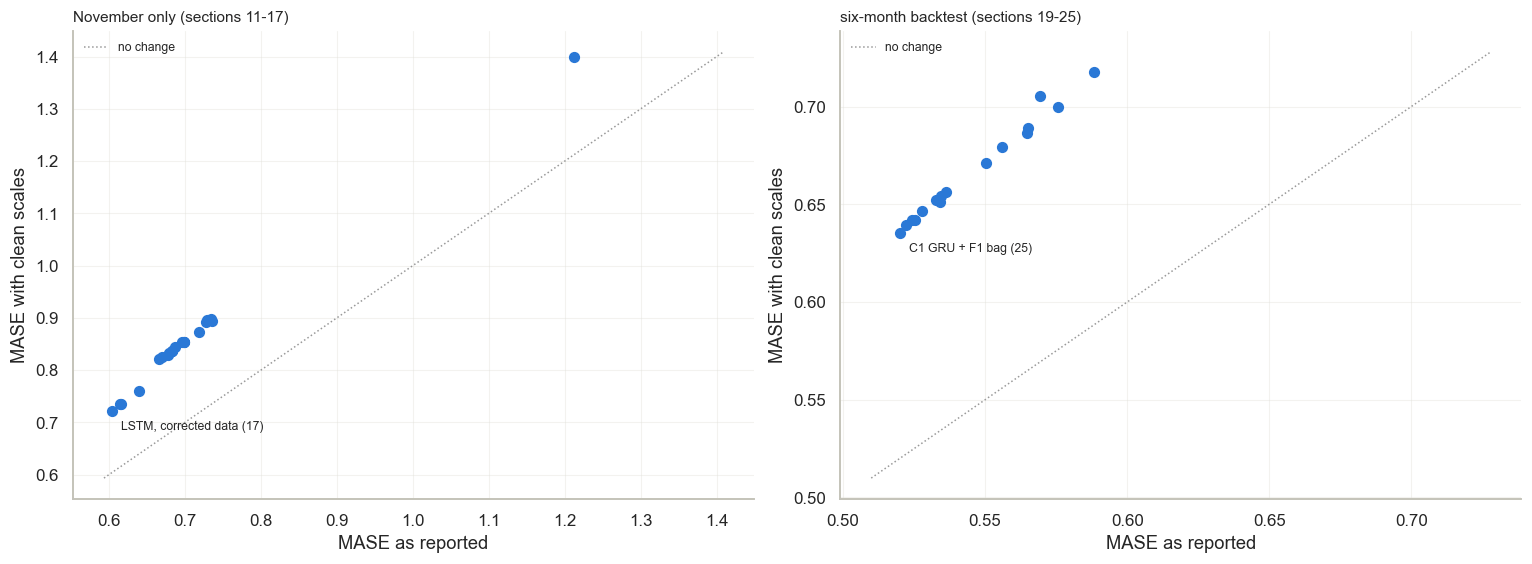

In [145]:
# --- 26c. Reported against clean ----------------------------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, t, title in [(a1, nov_tab, "November only (sections 11-17)"),
                     (a2, six_tab.drop("seasonal naive (19)"), "six-month backtest (sections 19-25)")]:
    ax.scatter(t["reported"], t["clean scales"], s=40, color="#2a78d6", zorder=3)
    lo = min(t["reported"].min(), t["clean scales"].min()) - 0.01
    hi = max(t["reported"].max(), t["clean scales"].max()) + 0.01
    ax.plot([lo, hi], [lo, hi], color="#999", ls=":", lw=1, label="no change")
    best = t["reported"].idxmin()
    ax.annotate(best, (t.loc[best, "reported"], t.loc[best, "clean scales"]), xytext=(6, -12),
                textcoords="offset points", fontsize=8)
    ax.set_xlabel("MASE as reported"); ax.set_ylabel("MASE with clean scales")
    ax.set_title(title, loc="left"); ax.grid(True, alpha=0.4); ax.set_axisbelow(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading 26

**The conversion factors are large where section 21e said they would be.**

| Array | Factor, June to November origins | Factor, January to March origins |
|---|---|---|
| Solar1 | 1.55–1.69 | 1.00 (no flagged days yet) |
| Solar2 | 1.25–1.33 | 1.02–1.05 |
| Solar3 | 1.56–1.94 | up to 3.34 (its 2019 flagged days weigh on a short history) |
| Solar4 | 1.14–1.17 | 1.00 |
| Solar5 | 1.00 | 1.00 |
| Solar0 | 0.87–1.04 | no history before April |

Solar1–4's factors are above 1, so on clean scales every model's error is larger relative to the
benchmark, by 0.115 to 0.136 on the six-month mean. The seasonal naive itself moves from 1.045 to
1.301. Solar0's factor is the exception: it is below 1 in some months, because removing its
flagged days *raises* its scale.

**The rankings barely move.**

- **November, sections 11–17:** the first eleven ranks are identical. Below that, a few models
  that were almost tied swap places: the raw-kW LSTM, the raw-kW forests, the CNNs and the
  per-array forest. The best November model is still the corrected LSTM from section 17 (0.6034
  reported, 0.7214 clean).
- **The six-month backtest, sections 19–25:** the first two places are unchanged, with C1
  (0.6353 clean) and the recommended F1 bag (0.6395 clean). Three pairs of neighbours swap:
  - Bean's full set and the section 22 blend;
  - the bagged boosting model and the five-seed GRU;
  - the raw-kW forest and the dilated causal CNN.
  The first two pairs were within 0.002 as reported, and the third within 0.007.
- One registry entry, "RF (full features)", could not be re-scored, because its function refers
  to a variable a later section reused. It is left out and named in the output.

**One comparison changes its month count, and it is the one closest to the recommendation.**
C1 against the F1 bag wins **4 of 6 months on clean scales**, against 3 as reported. So on clean
scales it meets the rule's first two parts: a lower six-month mean and at least 4 of 6 months.
Under section 21's labels it would be an **exploratory pass**, not a fail, and its failure rests
on the sign test alone (24 of 36 array-months, p = 0.033, against the threshold of 0.0167). That
test cannot change. The recommendation is unaffected, because section 25's rule required a full
pass, and nothing is re-decided.

The other three adoption comparisons keep their month counts:

- GRU against the LSTM: 5.
- The section 22 blend against the bag: 4.
- The F1 bag against the bag: 6.

**January to March keeps its order.** The means rise by about 0.01, and the F1 bag and C1 stay
ahead of the plain bag as before.

**Reading the notebook's numbers.** Every other MASE in this notebook is on the reported scale. For an
absolute statement about Solar1–4, such as "Solar3's forecast is X times the naive's error",
multiply by 26a's factor. For comparisons between models, every verdict is unchanged. One month
count changes (C1 against the F1 bag, from 3 to 4), and three near-tied pairs of ranks swap.

---

# 27. Training the networks differently (exploratory)

**This section is exploratory, and it cannot change the recommendation.** Reading 25 closed model
choice on this backtest, and January to March have since been looked at (22g, 25b), so no clean
confirmation set is left. A strong result here is a lead for future data, nothing more.

**The motivation is section 22f's finding.** In June and July every network keeps its
epoch 1–3 weights, because the validation window (the last 10% of each training period) is
unlike the rest of the data. So the networks may never have been trained properly. The
candidates below change *how* a network is trained, or give one the F1 bag's inputs.

**This plan was reviewed and frozen, with file hashes, before any section 27 network was
trained.** Every candidate is trained on the §19 folds and data, with the corrected ratio target
and MAE loss. Each starts at 3 seeds and is judged against the five-seed GRU from section 22
(0.5343) under section 21's rule, Bonferroni over 4 (p < 0.0125). A candidate that passes then
goes through the five-seed confirmation.

| # | Candidate | Training protocol |
|---|---|---|
| N1 | GRU(48), section 22's architecture | **fixed budget:** 30 epochs, no early stopping, learning rate cosine-decayed from 1e-3 to 0, last-epoch weights kept |
| N2 | GRU(48) | early stopping (patience 12, best weights restored) on a **blocked** validation split: about 10% of whole weeks, drawn at random (seed 0) across the training history, all arrays of a week held out together |
| N3 | **MLP** on the F1 bag's inputs (section 11's features plus the three radiation leads, standardised): Dense(64) → Dense(32) → output | N1's fixed budget |
| N4 | GRU(48) given the three radiation leads as static inputs (section 25's C2) | N1's fixed budget |

**Why these choices.**

- **The fixed-budget candidates (N1, N3, N4) train on all their rows.** With no early stopping
  there is nothing to validate on, so no rows are held out.
- **N1's 30 epochs were fixed before running, not tuned.** Taking the budget from past folds'
  best epochs would look ahead, since a later fold's validation window lies in earlier test
  months. 30 is roughly the length of section 22's longest runs. A budget of 15 or 60 epochs is
  reported as a descriptive sensitivity only.
- **N2 holds out whole weeks, not random hours.** Every array shares the same hour's weather, and
  neighbouring hours are nearly identical, so a random-hour split would put near-duplicates on
  both sides.
- **N3 and N4 use scalers fitted the same way as section 25's.** Like every scaler in this
  notebook, they were settled on data up to November.
- **N4 bundles two changes: the leads and N1's protocol.** The rule judges it against the GRU,
  but its mechanism is scored against N1, which has the same protocol without the leads.

**Predictions** (Δ = reference minus candidate six-month mean; positive = candidate better):

| # | Prediction |
|---|---|
| N1 | Δ > +0.005 against the GRU; the gain is concentrated in June and July, where the early-stopping problem is worst |
| N2 | Δ > 0 against the GRU |
| N3 | Δ > 0 against the GRU |
| N4 | Δ > 0 against **N1** (descriptive): the leads help once the epoch problem is removed |

**Reported whatever the verdicts:**

- every candidate's per-seed six-month means;
- N1's 15- and 60-epoch sensitivity;
- the lowest-mean confirmed candidate blended equal-weight with the F1 bag, against the F1 bag.
  This is descriptive only, with the guaranteed wins marked; it changes nothing.

In [146]:
import time, math
from scipy.stats import binomtest
from sklearn.preprocessing import StandardScaler
M = list(FOLDS)
EPOCHS = 30                                                   # fixed a priori (section 27 plan); not tuned


def cosine_adam(n_rows, epochs):
    steps = math.ceil(n_rows / 256) * epochs
    return keras.optimizers.Adam(keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=steps, alpha=0.0))


def make_gru27(seed, steps, n_static, opt):
    keras.utils.set_random_seed(seed)
    s_in = keras.Input(shape=(steps, len(SEQ_FEATURES))); t_in = keras.Input(shape=(n_static,))
    z = layers.Concatenate()([layers.GRU(48)(s_in), layers.Dense(32, activation="relu")(t_in)])
    z = layers.Dense(32, activation="relu")(z)
    m = keras.Model([s_in, t_in], layers.Dense(1)(z)); m.compile(optimizer=opt, loss="mae")
    return m


def make_mlp27(seed, n_in, opt):
    keras.utils.set_random_seed(seed)
    x_in = keras.Input(shape=(n_in,))
    z = layers.Dense(32, activation="relu")(layers.Dense(64, activation="relu")(x_in))
    m = keras.Model(x_in, layers.Dense(1)(z)); m.compile(optimizer=opt, loss="mae")
    return m


# N3's inputs: section 11's pruned features plus the three leads, standardised on train_day's rows
mlp_scaler = StandardScaler().fit(np.hstack([make_x(train_day)[PRUNED].to_numpy(),
                                             LL.reindex(train_day.index)[LEADS].to_numpy()]))


def mlp_x(frame):
    return mlp_scaler.transform(np.hstack([make_x(frame)[PRUNED].to_numpy(),
                                           LL.reindex(frame.index)[LEADS].to_numpy()])).astype("float32")


X_td_mlp = mlp_x(td)


def fit_fixed(kind, y, mask, tag, seeds=(0, 1, 2), epochs=EPOCHS):
    """N1/N3/N4: a fixed budget on all training rows, cosine-decayed learning rate, last weights kept."""
    def _fit():
        nets, hists = [], []
        for s in seeds:
            yy = y[mask].astype("float32")
            if kind == "mlp":
                xs = X_td_mlp[mask]; m = make_mlp27(s, xs.shape[1], cosine_adam(len(yy), epochs))
                h = m.fit(xs, yy, epochs=epochs, batch_size=256, verbose=0)
            else:
                st = stat_tr_lead if kind == "gru_lead" else stat_tr
                sq, tt = seq_tr[mask], st[mask]
                m = make_gru27(s, sq.shape[1], tt.shape[1], cosine_adam(len(yy), epochs))
                h = m.fit([sq, tt], yy, epochs=epochs, batch_size=256, verbose=0)
            nets.append(m); hists.append(h.history)
        return nets, hists
    return cached_nets(f"seeds_{tag}", _fit)[0]


def fit_blocked(y, mask, tag, seeds=(0, 1, 2)):
    """N2: early stopping on ~10% of whole weeks, drawn at random (seed 0), all arrays of a week together."""
    idx = td.index[mask]
    week = pd.Series(idx.tz_convert("UTC").strftime("%G-%V"), index=range(len(idx)))
    weeks = np.array(sorted(week.unique()))
    rng = np.random.default_rng(0)
    val_weeks = set(rng.choice(weeks, size=max(1, round(0.1 * len(weeks))), replace=False))
    is_val = week.isin(val_weeks).to_numpy()
    sq, tt, yy = seq_tr[mask], stat_tr[mask], y[mask].astype("float32")

    def _fit():
        nets, hists = [], []
        for s in seeds:
            m = make_gru27(s, sq.shape[1], tt.shape[1], keras.optimizers.Adam(1e-3))
            h = m.fit([sq[~is_val], tt[~is_val]], yy[~is_val], validation_data=([sq[is_val], tt[is_val]], yy[is_val]),
                      epochs=150, batch_size=256, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)])
            nets.append(m); hists.append(h.history)
        return nets, hists
    return cached_nets(f"seeds_{tag}", _fit)


def predict27(kind, nets, frame, caps):
    if kind == "mlp":
        raw = np.mean([np.asarray(m(mlp_x(frame), training=False)).ravel() for m in nets], axis=0)
        return clean_pred(frame, raw * ref_linear(frame, caps))
    bld, cols = (build_inputs_lead, ALL_LEAD) if kind == "gru_lead" else (build_inputs, ALL)
    return clean_pred(frame, predict_with(nets, bld, cols, ref_linear, caps)(frame))


CANDS27 = {"N1 GRU, fixed budget": "gru", "N2 GRU, blocked-week early stopping": "blocked",
           "N3 MLP on the F1 inputs": "mlp", "N4 GRU with leads, fixed budget": "gru_lead"}


def run_month(mon, win, seeds, suffix, epochs=EPOCHS, only=None):
    arrays = FIXED[mon]; tag_a = "-".join(arrays) or "none"
    r, mask, caps = ratio_inputs_ref(win[0], arrays, ref_linear)
    frame = FRAME21[mon]
    _, _, ok = build_inputs_lead(frame); assert ok.all()
    out = {}
    for name, kind in CANDS27.items():
        if only and name not in only:
            continue
        tag = f"v27-{kind}-e{epochs}-{mon}-{tag_a}{suffix}" if kind != "blocked" else f"v27-{kind}-{mon}-{tag_a}{suffix}"
        nets = fit_blocked(r, mask, tag, seeds)[0] if kind == "blocked" else fit_fixed(kind, r, mask, tag, seeds, epochs)
        out[name] = (kind, nets, caps)
    return out


# ---- 27a. Three seeds per candidate (every network cached) ------------------------------------------------------------------------
N27 = {}
for mon, win in FOLDS.items():
    t = time.time(); N27[mon] = run_month(mon, win, (0, 1, 2), "")
    print(f"{mon}: {time.time() - t:.0f}s", flush=True)

P27, S27 = {}, {}
for mon in M:
    frame = FRAME21[mon]
    for name, (kind, nets, caps) in N27[mon].items():
        P27[(mon, name)] = predict27(kind, nets, frame, caps)
        S27[(mon, name)] = [predict27(kind, [m], frame, caps) for m in nets]
    P27[(mon, "GRU, 5 seeds")] = C22[(mon, "A1 GRU")]
names = list(CANDS27)
e27 = pd.DataFrame({k: score_vec(FRAME21[k[0]], p, FOLDS[k[0]]) for k, p in P27.items()}).T
tm = e27[SOLAR].mean(axis=1).unstack(0)[M]
tab27 = tm.copy(); tab27["6-month mean"] = tm.mean(axis=1)
display(tab27.round(4))
ref = e27.xs("GRU, 5 seeds", level=1)[SOLAR]
rows = []
for n in names:
    d = (ref - e27.xs(n, level=1)[SOLAR]).to_numpy().ravel(); k = int((d > 0).sum())
    delta = tab27.loc["GRU, 5 seeds", "6-month mean"] - tab27.loc[n, "6-month mean"]
    months = int((tm.loc[n] < tm.loc["GRU, 5 seeds"]).sum())
    p = binomtest(k, 36, 0.5, alternative="greater").pvalue
    rows.append({"candidate": n, "delta vs GRU": delta, "months better": months, "array-months": f"{k}/36", "p": p,
                 "verdict (3 seeds)": "fail" if not (delta > 0 and months >= 4) else
                 ("pass -> confirm" if p < 0.05 / 4 else "exploratory pass -> confirm")})
res27 = pd.DataFrame(rows).set_index("candidate")
display(res27.round(5))
d_jj = {n: (tm.loc["GRU, 5 seeds", ["Jun", "Jul"]] - tm.loc[n, ["Jun", "Jul"]]).mean() for n in names}
d_rest = {n: (tm.loc["GRU, 5 seeds", ["Aug", "Sep", "Oct", "Nov"]] - tm.loc[n, ["Aug", "Sep", "Oct", "Nov"]]).mean() for n in names}
print("delta vs GRU, Jun-Jul:", {k: round(v, 4) for k, v in d_jj.items()})
print("delta vs GRU, Aug-Nov:", {k: round(v, 4) for k, v in d_rest.items()})
n4_vs_n1 = tab27.loc["N1 GRU, fixed budget", "6-month mean"] - tab27.loc["N4 GRU with leads, fixed budget", "6-month mean"]
print(f"N4 vs N1 (positive = leads help): {n4_vs_n1:+.4f}")
print("predictions: N1", bool(res27.loc['N1 GRU, fixed budget', 'delta vs GRU'] > 0.005 and d_jj['N1 GRU, fixed budget'] > d_rest['N1 GRU, fixed budget']),
      "| N2", bool(res27.loc['N2 GRU, blocked-week early stopping', 'delta vs GRU'] > 0),
      "| N3", bool(res27.loc['N3 MLP on the F1 inputs', 'delta vs GRU'] > 0), "| N4 vs N1", bool(n4_vs_n1 > 0))
seed_tab = pd.DataFrame({n: [np.mean([score_vec(FRAME21[mon], S27[(mon, n)][s], FOLDS[mon]).mean() for mon in M])
                             for s in range(3)] for n in names}, index=["seed 0", "seed 1", "seed 2"]).T
display(seed_tab.round(4).rename_axis("six-month mean of each single seed"))

  [cache] loaded seeds_v27-gru-e30-Jun-none (3 networks)
  [cache] loaded seeds_v27-blocked-Jun-none (3 networks)
  [cache] loaded seeds_v27-mlp-e30-Jun-none (3 networks)


  [cache] loaded seeds_v27-gru_lead-e30-Jun-none (3 networks)
Jun: 0s


  [cache] loaded seeds_v27-gru-e30-Jul-Solar3 (3 networks)
  [cache] loaded seeds_v27-blocked-Jul-Solar3 (3 networks)


  [cache] loaded seeds_v27-mlp-e30-Jul-Solar3 (3 networks)


  [cache] loaded seeds_v27-gru_lead-e30-Jul-Solar3 (3 networks)
Jul: 0s


...

  [cache] loaded seeds_v27-gru_lead-e30-Nov-Solar3-Solar0 (3 networks)
Nov: 0s


,Jun,Jul,Aug,Sep,Oct,Nov,6-month mean
"GRU, 5 seeds",0.4281,0.4140,0.6450,0.5549,0.6035,0.5602,0.5343
"N1 GRU, fixed budget",0.4430,0.3608,0.6172,0.5527,0.5926,0.5697,0.5227
"N2 GRU, blocked-week early stopping",0.4460,0.3805,0.6012,0.5209,0.5940,0.5709,0.5189
N3 MLP on the F1 inputs,0.4239,0.3637,0.6144,0.5302,0.5966,0.6048,0.5223
"N4 GRU with leads, fixed budget",0.4500,0.3661,0.5904,0.5467,0.5855,0.5647,0.5172


,delta vs GRU,months better,array-months,p,verdict (3 seeds)
candidate,,,,,
"N1 GRU, fixed budget",0.01160,4,22/36,0.12149,exploratory pass -> confirm
"N2 GRU, blocked-week early stopping",0.01537,4,23/36,0.06625,exploratory pass -> confirm
N3 MLP on the F1 inputs,0.01200,5,22/36,0.12149,exploratory pass -> confirm
"N4 GRU with leads, fixed budget",0.01704,4,21/36,0.20252,exploratory pass -> confirm


delta vs GRU, Jun-Jul: {'N1 GRU, fixed budget': 0.0191, 'N2 GRU, blocked-week early stopping': 0.0078, 'N3 MLP on the F1 inputs': 0.0272, 'N4 GRU with leads, fixed budget': 0.013}
delta vs GRU, Aug-Nov: {'N1 GRU, fixed budget': 0.0078, 'N2 GRU, blocked-week early stopping': 0.0192, 'N3 MLP on the F1 inputs': 0.0044, 'N4 GRU with leads, fixed budget': 0.0191}
N4 vs N1 (positive = leads help): +0.0054
predictions: N1 True | N2 True | N3 True | N4 vs N1 True


,seed 0,seed 1,seed 2
six-month mean of each single seed,,,
"N1 GRU, fixed budget",0.5295,0.5273,0.5351
"N2 GRU, blocked-week early stopping",0.5362,0.5252,0.5232
N3 MLP on the F1 inputs,0.5332,0.5332,0.5311
"N4 GRU with leads, fixed budget",0.5410,0.5217,0.5199


## 27b. N1's budget sensitivity, and confirmation at five seeds

N1's budget is re-run at 15 and 60 epochs, for description only. Any candidate that passed or
exploratory-passed at three seeds gets seeds 3 and 4, and faces the same rule against the
five-seed GRU. The lowest-mean confirmed candidate is then blended with the F1 bag for
description only; the blend changes nothing.

In [147]:
# ---- 27b. N1's budget sensitivity (descriptive), and confirmation at five seeds ---------------------
sens = {}
for ep in (15, 60):
    vals = []
    for mon, win in FOLDS.items():
        o = run_month(mon, win, (0, 1, 2), "", epochs=ep, only=["N1 GRU, fixed budget"])
        kind, nets, caps = o["N1 GRU, fixed budget"]
        vals.append(score_vec(FRAME21[mon], predict27(kind, nets, FRAME21[mon], caps), FOLDS[mon]).mean())
    sens[ep] = np.mean(vals)
sens[EPOCHS] = tab27.loc["N1 GRU, fixed budget", "6-month mean"]
display(pd.Series(dict(sorted(sens.items())), name="N1 six-month mean").rename_axis("epochs").round(4).to_frame())

conf = [n for n in names if res27.loc[n, "verdict (3 seeds)"] != "fail"]
print("confirming:", conf or "none")
C27 = {}
for mon, win in FOLDS.items():
    if not conf:
        break
    extra = run_month(mon, win, (3, 4), "-s34", only=conf)
    for n in conf:
        kind, nets2, caps = extra[n]
        _, nets3, _ = N27[mon][n]
        C27[(mon, n)] = predict27(kind, nets3 + nets2, FRAME21[mon], caps)
confirmed27 = []
if conf:
    ce = pd.DataFrame({**{(mon, n): score_vec(FRAME21[mon], C27[(mon, n)], FOLDS[mon]) for mon in M for n in conf},
                       **{(mon, "GRU, 5 seeds"): score_vec(FRAME21[mon], C22[(mon, "A1 GRU")], FOLDS[mon]) for mon in M}}).T
    ct = ce[SOLAR].mean(axis=1).unstack(0)[M]
    g = ce.xs("GRU, 5 seeds", level=1)[SOLAR]
    crow = []
    for n in conf:
        k = int(((g - ce.xs(n, level=1)[SOLAR]).to_numpy() > 0).sum())
        p = binomtest(k, 36, 0.5, alternative="greater").pvalue
        months = int((ct.loc[n] < ct.loc["GRU, 5 seeds"]).sum())
        ok_ = ct.loc[n].mean() < ct.loc["GRU, 5 seeds"].mean() and months >= 4 and p < 0.05 / 4
        crow.append({"candidate": n, "six-month (5 seeds)": ct.loc[n].mean(), "GRU (5 seeds)": ct.loc["GRU, 5 seeds"].mean(),
                     "months better": months, "array-months": f"{k}/36", "one-sided p": p, "confirmed": ok_})
        if ok_:
            confirmed27.append(n)
    display(pd.DataFrame(crow).set_index("candidate").round(4))

# descriptive only: the lowest-mean confirmed candidate blended with the F1 bag, against the F1 bag
if confirmed27:
    best27 = min(confirmed27, key=lambda n: np.mean([score_vec(FRAME21[mon], C27[(mon, n)], FOLDS[mon]).mean() for mon in M]))
    f1 = {mon: P25[(mon, "F1 bag")] for mon in M}
    bl = pd.DataFrame({**{(mon, "F1 bag"): score_vec(FRAME21[mon], f1[mon], FOLDS[mon]) for mon in M},
                       **{(mon, best27): score_vec(FRAME21[mon], C27[(mon, best27)], FOLDS[mon]) for mon in M},
                       **{(mon, "blend"): score_vec(FRAME21[mon], (f1[mon] + C27[(mon, best27)]) / 2, FOLDS[mon]) for mon in M}}).T
    bt_ = bl[SOLAR].mean(axis=1).unstack(0)[M]; bt_["6-month mean"] = bt_[M].mean(axis=1)
    display(bt_.round(4).rename_axis(f"descriptive: {best27} + F1 bag (changes nothing)"))
    print("months where the network alone beats the F1 bag (blend win guaranteed):",
          [m for m in M if bt_.loc[best27, m] < bt_.loc["F1 bag", m]])

  [cache] loaded seeds_v27-gru-e15-Jun-none (3 networks)


  [cache] loaded seeds_v27-gru-e15-Jul-Solar3 (3 networks)


  [cache] loaded seeds_v27-gru-e15-Aug-Solar3 (3 networks)


  [cache] loaded seeds_v27-gru-e15-Sep-Solar3-Solar0 (3 networks)


  [cache] loaded seeds_v27-gru-e15-Oct-Solar3-Solar0 (3 networks)


...

  [cache] loaded seeds_v27-gru-e30-Aug-Solar3-s34 (2 networks)
  [cache] loaded seeds_v27-blocked-Aug-Solar3-s34 (2 networks)
  [cache] loaded seeds_v27-mlp-e30-Aug-Solar3-s34 (2 networks)
  [cache] loaded seeds_v27-gru_lead-e30-Aug-Solar3-s34 (2 networks)


  [cache] loaded seeds_v27-gru-e30-Sep-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-blocked-Sep-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-mlp-e30-Sep-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-gru_lead-e30-Sep-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v27-gru-e30-Oct-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-blocked-Oct-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-mlp-e30-Oct-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-gru_lead-e30-Oct-Solar3-Solar0-s34 (2 networks)


  [cache] loaded seeds_v27-gru-e30-Nov-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-blocked-Nov-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-mlp-e30-Nov-Solar3-Solar0-s34 (2 networks)
  [cache] loaded seeds_v27-gru_lead-e30-Nov-Solar3-Solar0-s34 (2 networks)


,six-month (5 seeds),GRU (5 seeds),months better,array-months,one-sided p,confirmed
candidate,,,,,,
"N1 GRU, fixed budget",0.5211,0.5343,4,23/36,0.0662,False
"N2 GRU, blocked-week early stopping",0.5188,0.5343,4,24/36,0.0326,False
N3 MLP on the F1 inputs,0.5199,0.5343,5,21/36,0.2025,False
"N4 GRU with leads, fixed budget",0.5138,0.5343,5,22/36,0.1215,False


**Figure.** Left: section 27's networks month by month against the GRU. Right: N1's six-month mean at three training budgets (descriptive).

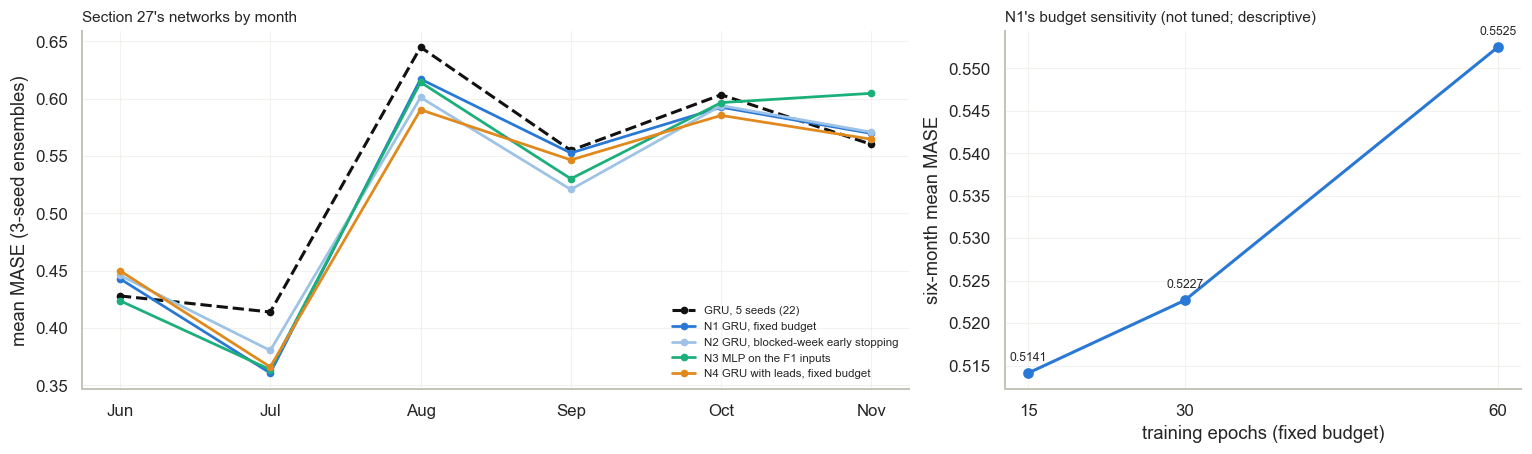

In [148]:
# --- Figure: section 27 by month, and N1's budget curve ------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
a1.plot(M, tab27.loc["GRU, 5 seeds", M], color="#111", ls="--", lw=2, marker="o", ms=4, label="GRU, 5 seeds (22)")
for n, c in zip(names, ["#2a78d6", "#9ec3e6", "#1baf7a", "#e08a1e"]):
    a1.plot(M, tab27.loc[n, M], color=c, lw=1.8, marker="o", ms=4, label=n)
a1.set_ylabel("mean MASE (3-seed ensembles)"); a1.set_title("Section 27's networks by month", loc="left")
a1.legend(fontsize=7.5, ncol=1, loc="lower right"); a1.grid(True, alpha=0.4); a1.set_axisbelow(True)
fg_ep = sorted(sens)
a2.plot(fg_ep, [sens[e] for e in fg_ep], color="#2a78d6", marker="o", lw=2)
for e in fg_ep:
    a2.annotate(f"{sens[e]:.4f}", (e, sens[e]), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
a2.set_xticks(fg_ep); a2.set_xlabel("training epochs (fixed budget)"); a2.set_ylabel("six-month mean MASE")
a2.set_title("N1's budget sensitivity (not tuned; descriptive)", loc="left")
a2.grid(True, alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 27c. Seed by seed, and by season

The prediction for N1 was that its gain would sit in June and July, where early stopping kept
epoch 1–3 weights. The right panel splits each candidate's gain over the GRU into June–July and
August–November.

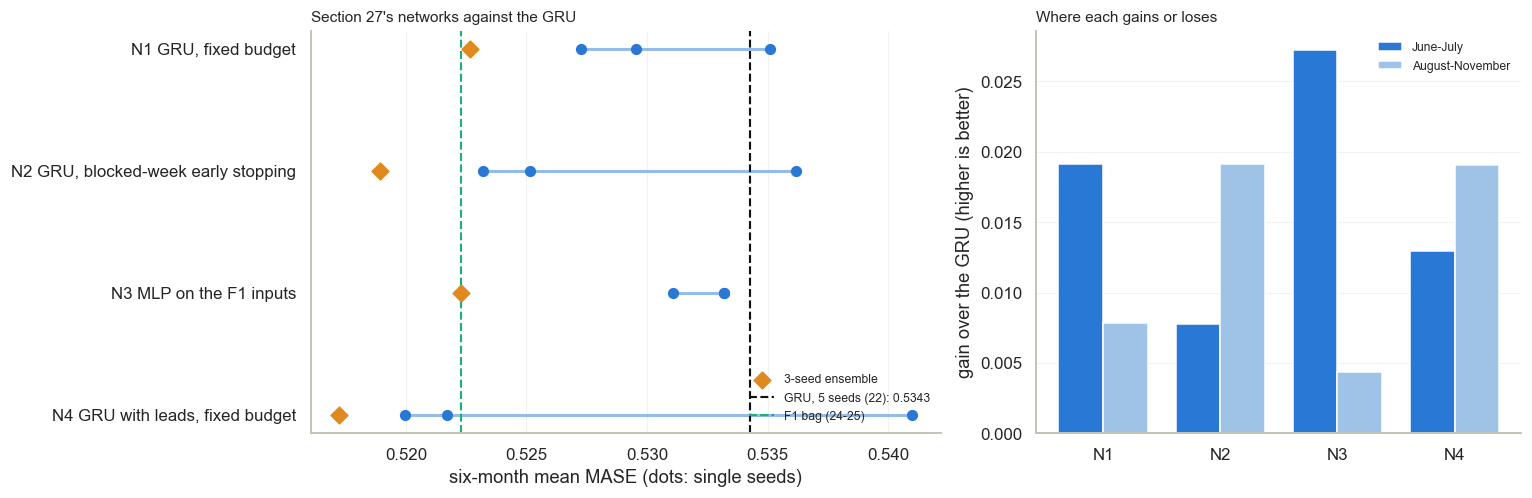

In [149]:
# ---- 27c. The candidates against the GRU, seed by seed and by season --------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
for i, n in enumerate(names):
    v = seed_tab.loc[n].to_numpy(dtype=float)
    a1.plot([v.min(), v.max()], [i, i], color="#2a78d6", lw=2, alpha=0.5)
    a1.scatter(v, [i] * 3, color="#2a78d6", s=40, zorder=3)
    a1.scatter(tab27.loc[n, "6-month mean"], i, marker="D", color="#e08a1e", s=60, zorder=4,
               label="3-seed ensemble" if i == 0 else None)
a1.axvline(tab27.loc["GRU, 5 seeds", "6-month mean"], color="#111", ls="--", lw=1.4,
           label=f"GRU, 5 seeds (22): {tab27.loc['GRU, 5 seeds', '6-month mean']:.4f}")
a1.axvline(np.mean([score_vec(FRAME21[mon], P25[(mon, "F1 bag")], FOLDS[mon]).mean() for mon in M]),
           color="#1baf7a", ls="--", lw=1.4, label="F1 bag (24-25)")
a1.set_yticks(range(len(names)), names); a1.invert_yaxis()
a1.set_xlabel("six-month mean MASE (dots: single seeds)")
a1.set_title("Section 27's networks against the GRU", loc="left")
a1.legend(fontsize=8, loc="lower right"); a1.grid(True, axis="x", alpha=0.4); a1.set_axisbelow(True)
x = np.arange(len(names)); w = 0.38
a2.bar(x - w / 2, [d_jj[n] for n in names], w, color="#2a78d6", label="June-July")
a2.bar(x + w / 2, [d_rest[n] for n in names], w, color="#9ec3e6", label="August-November")
a2.axhline(0, color="#111", lw=0.8)
a2.set_xticks(x, [n.split(" ")[0] for n in names])
a2.set_ylabel("gain over the GRU (higher is better)")
a2.set_title("Where each gains or loses", loc="left")
a2.legend(fontsize=8); a2.grid(True, axis="y", alpha=0.4); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Reading 27

**Training the networks differently improves their six-month mean every time, but none of the
four is confirmed.** At five seeds every candidate beats the five-seed GRU (0.5343) on the
six-month mean, by 0.013 to 0.021, and every one exploratory-passed at three seeds. But none
passes the five-seed sign test (p < 0.0125):

| Candidate | 3 seeds | 5 seeds | Months better | Array-months | p |
|---|---|---|---|---|---|
| N1 GRU, fixed 30 epochs | 0.5227 | 0.5211 | 4 of 6 | 23/36 | 0.066 |
| N2 GRU, blocked-week early stopping | 0.5189 | 0.5188 | 4 of 6 | 24/36 | 0.033 |
| N3 MLP on the F1 inputs | 0.5223 | 0.5199 | 5 of 6 | 21/36 | 0.20 |
| N4 GRU with leads, fixed budget | 0.5172 | 0.5138 | 5 of 6 | 22/36 | 0.12 |

The means move a lot, but the gains are uneven across arrays and months, so the paired test does
not support them. None of them is confirmed. In any case this section was exploratory, so the
recommendation (the F1 bag, section 25) stands. No blend was run, because it was reserved for a
confirmed candidate.

**All four predictions held.**

- **N1's prediction held on the two-month average, but July carries all of it.** N1 beats the GRU
  by 0.019 over June and July, against 0.008 from August to November. That average hides a split:
  +0.053 in July (0.3608 against 0.4140) and **−0.015 in June** (0.4430 against 0.4281). June is
  the fold where early stopping kept epoch-1 weights most consistently, yet training longer made
  it *worse*. N2 and N4 are also worse than the GRU in June (0.4460, 0.4500); only the MLP (N3,
  0.4239) improves there. So section 22f's diagnosis is supported for July, not for June.
- **N2 held (Δ > 0).** Choosing the validation weeks from across the history, rather than the
  last tenth, helps most from August to November (0.019).
- **N3 held (Δ > 0).** A plain MLP given the F1 bag's inputs matches the F1 bag's own six-month
  mean (0.5199 against 0.5223, descriptive). Its gain over the GRU is mostly in June and July
  (0.027).
- **N4 held: the leads help once the epoch problem is removed** (N4 against N1, +0.0054). The same
  inputs under the old protocol (section 25's C2) scored 0.5609. So C2's June–July damage was
  *largely* the training protocol. The leads still cost a little in June: N4 scores 0.4500 there,
  against N1's 0.4430.

**N1's budget sensitivity (descriptive) says the fixed budget is not settled.** At 15 epochs N1
scores 0.5141, better than at 30 (0.5227), and at 60 it is far worse (0.5525). Longer budgets did
worse. That is consistent with over-fitting, but the cosine schedule stretches to the budget, so
the learning-rate path changes along with the length. And 15 epochs is now the best of three
budgets *read off these months*, so adopting it would be tuning on the test months. It is a lead
only.

**What this section adds.**

- **The results suggest the training protocol matters.** Every change to it lowered the six-month
  mean. But no candidate was confirmed, and June, the fold with the least data, got worse under
  longer training. An MLP (N3) is about level with the GRU variants under the new protocol, which
  again suggests the architecture matters little here.
- **N4, the GRU with leading radiation on a fixed budget, has the lowest six-month mean of any
  model in the notebook (0.5138).** That includes the recommended F1 bag (0.5223), a comparison
  that was never planned and is reported only. Three things limit it:
  - it is not confirmed even against the GRU (22 of 36 array-months, p = 0.12);
  - it was never paired against the F1 bag;
  - N1 at 15 epochs (0.5141, three seeds, descriptive) is essentially tied with it.

  It stays a hypothesis.

**For future data.** The natural test is N4 (or N1 at a budget fixed in advance), alone and
blended with the F1 bag, on months that have never been looked at. The architecture comparisons
of sections 14, 20, 22 and 23 were all made under an early-stopping protocol that kept epoch 1–3
weights in June and July. Repeating them under a fixed budget would show whether their rankings
hold.

**Figure.** The whole solar-modelling chain on the six-month backtest, on the reported and the clean MASE scale. The recommended model is marked. The seasonal naive is left off the axis, and section 27's best network is shown hatched because it is exploratory and unconfirmed.

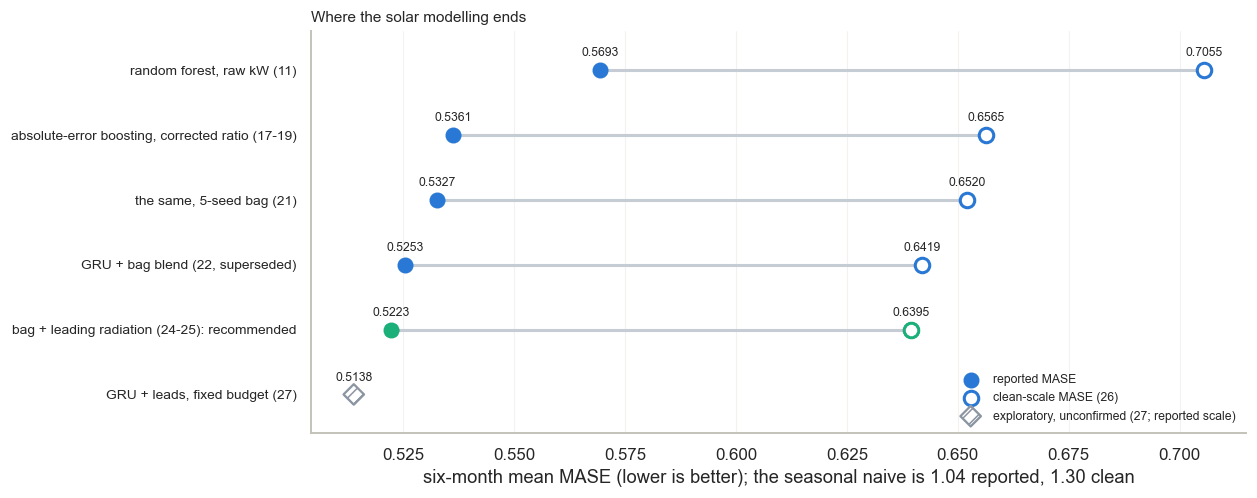

In [150]:
# --- Figure: the model chain, reported and clean --------------------------------------------------
fg_chain = [("RF, original data, kW (19)", "random forest, raw kW (11)"),
            ("HGB, one seed (19)", "absolute-error boosting, corrected ratio (17-19)"),
            ("HGB 5-seed bag (21)", "the same, 5-seed bag (21)"),
            ("GRU + HGB bag (22)", "GRU + bag blend (22, superseded)"),
            ("F1 leading radiation (24)", "bag + leading radiation (24-25): recommended")]
fig, ax = plt.subplots(figsize=(11.5, 4.6))
for i, (key, lab) in enumerate(fg_chain):
    rec = "recommended" in lab
    r_, c_ = six_tab.loc[key, "reported"], six_tab.loc[key, "clean scales"]
    ax.plot([r_, c_], [i, i], color="#c5ccd3", lw=2, zorder=1)
    ax.scatter(r_, i, s=90, color="#1baf7a" if rec else "#2a78d6", zorder=3, label="reported MASE" if i == 0 else None)
    ax.scatter(c_, i, s=90, facecolor="white", edgecolor="#1baf7a" if rec else "#2a78d6", lw=2, zorder=3,
               label="clean-scale MASE (26)" if i == 0 else None)
    ax.annotate(f"{r_:.4f}", (r_, i), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8)
    ax.annotate(f"{c_:.4f}", (c_, i), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8)
fg_n4 = pd.DataFrame(crow).set_index("candidate") if "crow" in globals() else None
if fg_n4 is not None and "N4 GRU with leads, fixed budget" in fg_n4.index:
    v = fg_n4.loc["N4 GRU with leads, fixed budget", "six-month (5 seeds)"]
    ax.scatter(v, len(fg_chain), s=90, marker="D", facecolor="white", edgecolor="#8c96a3", hatch="///", lw=1.5,
               zorder=3, label="exploratory, unconfirmed (27; reported scale)")
    ax.annotate(f"{v:.4f}", (v, len(fg_chain)), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8)
ax.set_yticks(range(len(fg_chain) + 1), [lab for _, lab in fg_chain] + ["GRU + leads, fixed budget (27)"], fontsize=9)
ax.set_ylim(len(fg_chain) + 0.6, -0.6)
ax.set_xlabel("six-month mean MASE (lower is better); the seasonal naive is 1.04 reported, 1.30 clean")
ax.set_title("Where the solar modelling ends", loc="left")
ax.legend(fontsize=8, loc="lower right"); ax.grid(True, axis="x", alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()